# 1. Define the objective

### What question are you trying to answer?
* Which pharmaceutical and medical device manufacturers account for the largest share of total financial transfers, and how has corporate spending shifted between 2019 and 2025?
* How are funds distributed across transaction categories (e.g., meals vs. research grants), and what proportion of transactions represent small-dollar disbursements versus high-value institutional funding?
* Which medical specialties and U.S. states receive the highest aggregate funding volumes or frequency of industry interactions?

### What is the target/outcome?
* Aggregated financial profiles by manufacturer, specialty, year, and nature of payment.
* Recipient behavioral metrics (frequency distribution of payments per physician profile ID).
* Percentage share breakdowns of total USD transfer volumes across all transaction categories.

### What decisions should the analysis support?
* Compliance and transparency auditing for outlier corporate spending and provider funding concentration.
* Commercial market research mapping life sciences industry engagement strategies across medical fields.
* Empirical baseline evaluation for academic health policy research and public transparency tracking.

# 2. Data Acquisition

### Context & Origin
- **Source:** Centers for Medicare & Medicaid Services (CMS) — Open Payments Program (Physician Payments Sunshine Act).
- **Purpose:** Publicly tracks financial relationships and "transfers of value" made by applicable drug and medical device manufacturers (and Group Purchasing Organizations) to covered healthcare recipients (physicians and teaching hospitals).
- **Temporal Scope:** Multi-year master dataset spanning 2019 through 2025 (49.6 GB raw CSV source).

### Core Entity Definitions
- **Covered Recipient:** Physicians, dentists, podiatrists, optometrists, chiropractors, or teaching hospitals legally registered to receive medical payments.
- **Applicable Manufacturer:** Pharmaceutical or medical device companies funding research, consulting, speaking engagements, meals, travel, or educational grants.
- **Nature of Payment:** The primary categorical classification describing *why* the financial transfer occurred (e.g., *Food and Beverage*, *Consulting Fee*, *Travel and Lodging*, *Honoraria*, *Research*).

# Open Payments General Dataset Sources (2019–2025)
- **2025** - https://openpaymentsdata.cms.gov/dataset/fb0b1734-1410-429d-92f6-3f4b35218e5e - [Size : 9.2GB]
- **2024** - https://openpaymentsdata.cms.gov/dataset/e6b17c6a-2534-4207-a4a1-6746a14911ff - [Size : 9GB]
- **2023** - https://openpaymentsdata.cms.gov/dataset/fb3a65aa-c901-4a38-a813-b04b00dfa2a9 - [Size : 8.2GB]
- **2022** - https://openpaymentsdata.cms.gov/dataset/df01c2f8-dc1f-4e79-96cb-8208beaf143c - [Size : 7.4GB]
- **2021** - https://openpaymentsdata.cms.gov/dataset/0380bbeb-aea1-58b6-b708-829f92a48202 - [Size : 6.5GB]
- **2020** - https://openpaymentsdata.cms.gov/dataset/a08c4b30-5cf3-4948-ad40-36f404619019 - [Size : 3.3GB]
- **2019** - https://openpaymentsdata.cms.gov/dataset/4e54dd6c-30f8-4f86-86a7-3c109a89528e - [Size : 6GB]

## Import Libraries and Ready the data
- **Load Libraries**
- **Load all 7 datasets in lazy loading**
- **Merge all datasets**
- **Check Schema, null values, analyse unwanted columns**
- **Convert them to parquet Formate**

In [ ]:
#Python 3.13.15
%pip install polars==1.42.1 numpy==2.5.3 scipy==1.18.1 matplotlib==3.11.2 geopandas==1.2.0

In [4]:
import warnings
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2
from polars.exceptions import PerformanceWarning
from pathlib import Path
import geopandas as gpd


# Suppress Polars warnings
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [25]:
# Load all datasets

lf_19 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2019_P06302026_06032026.csv',
    infer_schema=False
)

lf_20 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2020_P06302026_06032026.csv',
    infer_schema=False
)

lf_21 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2021_P06302026_06032026.csv',
    infer_schema=False
)

lf_22 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2022_P06302026_06032026.csv',
    infer_schema=False
)

lf_23 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2023_P06302026_06032026.csv',
    infer_schema=False
)

lf_24 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2024_P06302026_06032026.csv',
    infer_schema=False
)

lf_25 = pl.scan_csv(
    'Data/OP_DTL_GNRL_PGYR2025_P06302026_06032026.csv',
    infer_schema=False
)

lf_19.head().collect()

Change_Type,Covered_Recipient_Type,Teaching_Hospital_CCN,Teaching_Hospital_ID,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_NPI,Covered_Recipient_First_Name,Covered_Recipient_Middle_Name,Covered_Recipient_Last_Name,Covered_Recipient_Name_Suffix,Recipient_Primary_Business_Street_Address_Line1,Recipient_Primary_Business_Street_Address_Line2,Recipient_City,Recipient_State,Recipient_Zip_Code,Recipient_Country,Recipient_Province,Recipient_Postal_Code,Covered_Recipient_Primary_Type_1,Covered_Recipient_Primary_Type_2,Covered_Recipient_Primary_Type_3,Covered_Recipient_Primary_Type_4,Covered_Recipient_Primary_Type_5,Covered_Recipient_Primary_Type_6,Covered_Recipient_Specialty_1,Covered_Recipient_Specialty_2,Covered_Recipient_Specialty_3,Covered_Recipient_Specialty_4,Covered_Recipient_Specialty_5,Covered_Recipient_Specialty_6,Covered_Recipient_License_State_code1,Covered_Recipient_License_State_code2,Covered_Recipient_License_State_code3,Covered_Recipient_License_State_code4,Covered_Recipient_License_State_code5,Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name,…,Contextual_Information,Delay_in_Publication_Indicator,Record_ID,Dispute_Status_for_Publication,Related_Product_Indicator,Covered_or_Noncovered_Indicator_1,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1,Product_Category_or_Therapeutic_Area_1,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1,Associated_Drug_or_Biological_NDC_1,Associated_Device_or_Medical_Supply_PDI_1,Covered_or_Noncovered_Indicator_2,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2,Product_Category_or_Therapeutic_Area_2,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2,Associated_Drug_or_Biological_NDC_2,Associated_Device_or_Medical_Supply_PDI_2,Covered_or_Noncovered_Indicator_3,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_3,Product_Category_or_Therapeutic_Area_3,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3,Associated_Drug_or_Biological_NDC_3,Associated_Device_or_Medical_Supply_PDI_3,Covered_or_Noncovered_Indicator_4,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_4,Product_Category_or_Therapeutic_Area_4,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4,Associated_Drug_or_Biological_NDC_4,Associated_Device_or_Medical_Supply_PDI_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Product_Category_or_Therapeutic_Area_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Associated_Drug_or_Biological_NDC_5,Associated_Device_or_Medical_Supply_PDI_5,Program_Year,Payment_Publication_Date
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""UNCHANGED""","""Covered Recipient Physician""",null,null,null,"""616901""","""1902982192""","""Matthew""","""J""","""Maggio""",null,"""1099 Kenyon Rd""",null,"""Fort Dodge""","""IA""","""50501""","""United States""",null,null,"""Doctor of Dentistry""",null,null,null,null,null,"""Dental Providers|Dentist""","""""","""""","""""","""""","""""","""IA""",null,null,null,null,"""National Dentex LLC""",…,null,"""No""","""618890611""","""No""","""Yes""","""Covered""","""Device""","""DEVICE""","""Implantable Abutments""",null,"""N/A""",null,null,null,null,null,"""N/A""",null,null,null,null,null,"""N/A""",null,null,null,null,null,"""N/A""",null,null,null,null,null,"""N/A""","""2019""","""06/30/2026"""
"""CHANGED""","""Covered Recipient Physician""",null,null,null,"""101445""","""1245233949""","""STEPHEN""",null,"""COHEN""",null,"""450 SUTTER ST STE 1732""",null,"""SAN FRANCISCO""","""CA""","""94108""","""United States""",null,null,"""Doctor of Dentistry""",null,null,null,null,null,"""Dental Providers|Dentist|Endod…","""""","""""","""""","""""","""""","""CA""",null,null,null,null,"""Edge Endo LLC""",…,n

In [26]:
# Map years to the lazy frames
frame_mapping = {
    2019: lf_19,
    2020: lf_20,
    2021: lf_21,
    2022: lf_22,
    2023: lf_23,
    2024: lf_24,
    2025: lf_25,
}

lazy_frames = []

for year, lf in frame_mapping.items():

    existing_cols = lf.collect_schema().names()
    exprs = []

    # Ensure these columns are strings
    string_columns = [
        "Covered_Recipient_NPI",
        "Recipient_Postal_Code",
        "Associated_Device_or_Medical_Supply_PDI_1",
        "Associated_Device_or_Medical_Supply_PDI_2",
        "Associated_Device_or_Medical_Supply_PDI_3",
        "Associated_Device_or_Medical_Supply_PDI_4",
        "Associated_Device_or_Medical_Supply_PDI_5",
    ]

    for col_name in string_columns:
        if col_name in existing_cols:
            exprs.append(
                pl.col(col_name).cast(pl.Utf8, strict=False)
            )

    # Ensure Profile ID is Int64
    if "Covered_Recipient_Profile_ID" in existing_cols:
        exprs.append(
            pl.col("Covered_Recipient_Profile_ID")
            .cast(pl.Int64, strict=False)
        )

    # Add year
    exprs.append(
        pl.lit(year)
        .cast(pl.UInt16)
        .alias("Program_Year")
    )

    # Apply transformations lazily
    lf_transformed = lf.with_columns(exprs)

    lazy_frames.append(lf_transformed)

# Combine all years lazily
lf_all = pl.concat(
    lazy_frames,
    how="vertical_relaxed"
)

print("All lazy frames built successfully")

All lazy frames built successfully


In [27]:
# Convert columns to their intended datatypes before writing Parquet

lf_all = lf_all.with_columns([
    # -----------------------------
    # Numerical columns
    # -----------------------------
    pl.col("Total_Amount_of_Payment_USDollars")
        .cast(pl.Float64, strict=False),

    pl.col("Number_of_Payments_Included_in_Total_Amount")
        .cast(pl.Int64, strict=False),

    # -----------------------------
    # Identifier
    # -----------------------------
    pl.col("Covered_Recipient_Profile_ID")
        .cast(pl.Int64, strict=False),

    # -----------------------------
    # Temporal columns
    # -----------------------------
    pl.col("Date_of_Payment")
        .str.strptime(pl.Date, strict=False),

    pl.col("Payment_Publication_Date")
        .str.strptime(pl.Date, strict=False),

    # -----------------------------
    # Year
    # -----------------------------
    pl.col("Program_Year")
        .cast(pl.UInt16, strict=False),
])


# All remaining columns are kept as String.
# This includes IDs, codes, ZIP/postal codes,
# names, categorical variables, indicators, NDC/PDI, etc.


# Check the resulting schema
schema = lf_all.collect_schema()

for col, dtype in schema.items():
    print(f"{col:<70} {dtype}")

Change_Type                                                            String
Covered_Recipient_Type                                                 String
Teaching_Hospital_CCN                                                  String
Teaching_Hospital_ID                                                   String
Teaching_Hospital_Name                                                 String
Covered_Recipient_Profile_ID                                           Int64
Covered_Recipient_NPI                                                  String
Covered_Recipient_First_Name                                           String
Covered_Recipient_Middle_Name                                          String
Covered_Recipient_Last_Name                                            String
Covered_Recipient_Name_Suffix                                          String
Recipient_Primary_Business_Street_Address_Line1                        String
Recipient_Primary_Business_Street_Address_Line2                  

In [28]:
# Write all years into one Parquet file

output_path = "Data/open_payments_2019_2025-data.parquet"

lf_all.sink_parquet(
    output_path,
    compression="zstd",
    row_group_size=100_000
)

print(f"Successfully saved: {output_path}")

Successfully saved: Data/open_payments_2019_2025-data.parquet


# 3. Understand the dataset
- Number of rows/columns
- Column names
- Data types
- Unique values
- Categorical vs numerical variables
- Primary keys / identifiers

In [5]:
lf = pl.scan_parquet("Data/open_payments_2019_2025-data.parquet")
lf.head(10).collect()

Change_Type,Covered_Recipient_Type,Teaching_Hospital_CCN,Teaching_Hospital_ID,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_NPI,Covered_Recipient_First_Name,Covered_Recipient_Middle_Name,Covered_Recipient_Last_Name,Covered_Recipient_Name_Suffix,Recipient_Primary_Business_Street_Address_Line1,Recipient_Primary_Business_Street_Address_Line2,Recipient_City,Recipient_State,Recipient_Zip_Code,Recipient_Country,Recipient_Province,Recipient_Postal_Code,Covered_Recipient_Primary_Type_1,Covered_Recipient_Primary_Type_2,Covered_Recipient_Primary_Type_3,Covered_Recipient_Primary_Type_4,Covered_Recipient_Primary_Type_5,Covered_Recipient_Primary_Type_6,Covered_Recipient_Specialty_1,Covered_Recipient_Specialty_2,Covered_Recipient_Specialty_3,Covered_Recipient_Specialty_4,Covered_Recipient_Specialty_5,Covered_Recipient_Specialty_6,Covered_Recipient_License_State_code1,Covered_Recipient_License_State_code2,Covered_Recipient_License_State_code3,Covered_Recipient_License_State_code4,Covered_Recipient_License_State_code5,Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name,…,Contextual_Information,Delay_in_Publication_Indicator,Record_ID,Dispute_Status_for_Publication,Related_Product_Indicator,Covered_or_Noncovered_Indicator_1,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1,Product_Category_or_Therapeutic_Area_1,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1,Associated_Drug_or_Biological_NDC_1,Associated_Device_or_Medical_Supply_PDI_1,Covered_or_Noncovered_Indicator_2,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2,Product_Category_or_Therapeutic_Area_2,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2,Associated_Drug_or_Biological_NDC_2,Associated_Device_or_Medical_Supply_PDI_2,Covered_or_Noncovered_Indicator_3,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_3,Product_Category_or_Therapeutic_Area_3,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3,Associated_Drug_or_Biological_NDC_3,Associated_Device_or_Medical_Supply_PDI_3,Covered_or_Noncovered_Indicator_4,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_4,Product_Category_or_Therapeutic_Area_4,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4,Associated_Drug_or_Biological_NDC_4,Associated_Device_or_Medical_Supply_PDI_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Product_Category_or_Therapeutic_Area_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Associated_Drug_or_Biological_NDC_5,Associated_Device_or_Medical_Supply_PDI_5,Program_Year,Payment_Publication_Date
str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,u16,date
"""UNCHANGED""","""Covered Recipient Physician""",null,null,null,616901,"""1902982192""","""Matthew""","""J""","""Maggio""",null,"""1099 Kenyon Rd""",null,"""Fort Dodge""","""IA""","""50501""","""United States""",null,null,"""Doctor of Dentistry""",null,null,null,null,null,"""Dental Providers|Dentist""","""""","""""","""""","""""","""""","""IA""",null,null,null,null,"""National Dentex LLC""",…,null,"""No""","""618890611""","""No""","""Yes""","""Covered""","""Device""","""DEVICE""","""Implantable Abutments""",null,"""N/A""",null,null,null,null,null,"""N/A""",null,null,null,null,null,"""N/A""",null,null,null,null,null,"""N/A""",null,null,null,null,null,"""N/A""",2019,null
"""CHANGED""","""Covered Recipient Physician""",null,null,null,101445,"""1245233949""","""STEPHEN""",null,"""COHEN""",null,"""450 SUTTER ST STE 1732""",null,"""SAN FRANCISCO""","""CA""","""94108""","""United States""",null,null,"""Doctor of Dentistry""",null,null,null,null,null,"""Dental Providers|Dentist|Endod…","""""","""""","""""","""""","""""","""CA""",null,null,null,null,"""Edge Endo LLC""",…,null,"""No""","""618989313""",

In [30]:
# Shape of the Data
num_cols = len(lf.collect_schema())
num_rows = lf.select(pl.len()).collect().item()
dataset_shape = (num_rows, num_cols)
print(f"Dataset Shape: {dataset_shape}")


# Column Names, Data Types, unique values count
schema = lf.collect_schema()
print("Column Schema Breakdown:")
for i, (col, dtype) in enumerate(schema.items(), 1):
    unique_count = lf.select(pl.col(col).n_unique()).collect().item()
    print(f"{i:2d}. {col:<40} -> {dtype} | Unique: {unique_count:,}")

Dataset Shape: (87655770, 91)
Column Schema Breakdown:
 1. Change_Type                              -> String | Unique: 4
 2. Covered_Recipient_Type                   -> String | Unique: 3
 3. Teaching_Hospital_CCN                    -> String | Unique: 1,518
 4. Teaching_Hospital_ID                     -> String | Unique: 8,608
 5. Teaching_Hospital_Name                   -> String | Unique: 3,524
 6. Covered_Recipient_Profile_ID             -> Int64 | Unique: 1,691,886
 7. Covered_Recipient_NPI                    -> String | Unique: 1,677,175
 8. Covered_Recipient_First_Name             -> String | Unique: 171,290
 9. Covered_Recipient_Middle_Name            -> String | Unique: 150,298
10. Covered_Recipient_Last_Name              -> String | Unique: 500,111
11. Covered_Recipient_Name_Suffix            -> String | Unique: 825
12. Recipient_Primary_Business_Street_Address_Line1 -> String | Unique: 1,826,888
13. Recipient_Primary_Business_Street_Address_Line2 -> String | Unique: 208,770

In [32]:
# Date range

date_range = (
    lf.select(
        pl.col("Date_of_Payment")
        .min()
        .alias("earliest_date"),

        pl.col("Date_of_Payment")
        .max()
        .alias("latest_date"),
    )
    .collect()
)

print(date_range)

shape: (1, 2)
┌───────────────┬─────────────┐
│ earliest_date ┆ latest_date │
│ ---           ┆ ---         │
│ date          ┆ date        │
╞═══════════════╪═════════════╡
│ 2019-01-01    ┆ 2025-12-12  │
└───────────────┴─────────────┘


**Categorical vs. Numerical Variable Breakdown**

To properly direct our exploratory analysis, we segment our 40 optimized columns into two primary types:
- **Numerical Variables:** Continuous or discrete numeric values used for financial sums, counts, and distribution modeling.
- **Categorical / String Variables:** Text dimensions used for grouping, filtering, and studying entity distributions (e.g., specialties, payment types, manufacturers).

In [34]:
# Classify columns by their analytical meaning

numerical_cols = [
    "Total_Amount_of_Payment_USDollars",
    "Number_of_Payments_Included_in_Total_Amount",
]

temporal_cols = [
    "Date_of_Payment",
    "Payment_Publication_Date",
    "Program_Year",
]

identifier_cols = [
    "Teaching_Hospital_CCN",
    "Teaching_Hospital_ID",
    "Covered_Recipient_Profile_ID",
    "Covered_Recipient_NPI",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID",
    "Record_ID",

    "Associated_Drug_or_Biological_NDC_1",
    "Associated_Drug_or_Biological_NDC_2",
    "Associated_Drug_or_Biological_NDC_3",
    "Associated_Drug_or_Biological_NDC_4",
    "Associated_Drug_or_Biological_NDC_5",

    "Associated_Device_or_Medical_Supply_PDI_1",
    "Associated_Device_or_Medical_Supply_PDI_2",
    "Associated_Device_or_Medical_Supply_PDI_3",
    "Associated_Device_or_Medical_Supply_PDI_4",
    "Associated_Device_or_Medical_Supply_PDI_5",
]


# Everything else that is a String is treated as categorical/text
special_cols = set(numerical_cols + temporal_cols + identifier_cols)

categorical_cols = [
    col
    for col, dtype in schema.items()
    if dtype in (pl.String, pl.Utf8, pl.Boolean)
    and col not in special_cols
]


print(f"=== NUMERICAL VARIABLES ({len(numerical_cols)}) ===")
for col in numerical_cols:
    print(f" - {col}")

print(f"\n=== TEMPORAL VARIABLES ({len(temporal_cols)}) ===")
for col in temporal_cols:
    print(f" - {col}")

print(f"\n=== IDENTIFIER VARIABLES ({len(identifier_cols)}) ===")
for col in identifier_cols:
    print(f" - {col}")

print(f"\n=== CATEGORICAL / TEXT VARIABLES ({len(categorical_cols)}) ===")
for col in categorical_cols:
    print(f" - {col}")

=== NUMERICAL VARIABLES (2) ===
 - Total_Amount_of_Payment_USDollars
 - Number_of_Payments_Included_in_Total_Amount

=== TEMPORAL VARIABLES (3) ===
 - Date_of_Payment
 - Payment_Publication_Date
 - Program_Year

=== IDENTIFIER VARIABLES (16) ===
 - Teaching_Hospital_CCN
 - Teaching_Hospital_ID
 - Covered_Recipient_Profile_ID
 - Covered_Recipient_NPI
 - Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID
 - Record_ID
 - Associated_Drug_or_Biological_NDC_1
 - Associated_Drug_or_Biological_NDC_2
 - Associated_Drug_or_Biological_NDC_3
 - Associated_Drug_or_Biological_NDC_4
 - Associated_Drug_or_Biological_NDC_5
 - Associated_Device_or_Medical_Supply_PDI_1
 - Associated_Device_or_Medical_Supply_PDI_2
 - Associated_Device_or_Medical_Supply_PDI_3
 - Associated_Device_or_Medical_Supply_PDI_4
 - Associated_Device_or_Medical_Supply_PDI_5

=== CATEGORICAL / TEXT VARIABLES (70) ===
 - Change_Type
 - Covered_Recipient_Type
 - Teaching_Hospital_Name
 - Covered_Recipient_First_Name
 - Covered

In [35]:
 # Primary keys / identifiers 

id_cols = [
    "Record_ID",
    "Covered_Recipient_Profile_ID",
    "Covered_Recipient_NPI",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID"
]

# Compute row count, unique counts, and null counts efficiently
id_audit_df = lf.select(
    [
        pl.len().alias("Total_Rows"),
        *[pl.col(col).n_unique().alias(f"{col}_Unique") for col in id_cols],
        *[pl.col(col).null_count().alias(f"{col}_Nulls") for col in id_cols],
    ]
).collect()

# Transpose or display neatly
id_audit_df

Total_Rows,Record_ID_Unique,Covered_Recipient_Profile_ID_Unique,Covered_Recipient_NPI_Unique,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID_Unique,Record_ID_Nulls,Covered_Recipient_Profile_ID_Nulls,Covered_Recipient_NPI_Nulls,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID_Nulls
u32,u32,u32,u32,u32,u32,u32,u32,u32
87655770,87655770,1691886,1677175,2841,0,262411,301399,0


### Key Takeaway on Primary Keys:
- **Strict Row-Level Granularity:** `Record_ID` is 100% unique across the entire dataset, confirming it as our definitive primary key where every row represents an independent transaction.
- **Entity Identification (`Profile_ID` & `NPI`):** Identifiers like `Covered_Recipient_Profile_ID` and `Covered_Recipient_NPI` contain duplicate values because individual doctors, teaching hospitals, and manufacturers engage in multiple financial transactions over the years.

# 4. Data-quality analysis
- Missing values
- Duplicate records
- Invalid values
- Impossible values / Outliers
- Inconsistent categories
- Date/time problems

In [36]:
# Finding Missing values 

schema = lf.collect_schema()
cols = list(schema.keys())
results = {}

# Process 4 columns at a time using streaming execution
chunk_size = 4
for i in range(0, len(cols), chunk_size):
    chunk_cols = cols[i : i + chunk_size]
    exprs = []

    for col in chunk_cols:
        if schema[col] == pl.String:
            # Count true nulls or empty strings
            exprs.append(
                (pl.col(col).is_null() | (pl.col(col) == ""))
                .sum()
                .alias(col)
            )
        else:
            exprs.append(pl.col(col).null_count().alias(col))

    # Collect chunk safely via streaming
    chunk_res = lf.select(exprs).collect(streaming=True)
    for col in chunk_cols:
        results[col] = chunk_res[col][0]

# final counts
for col, count in results.items():
    print(f"{col}: {count:,}")

Change_Type: 0
Covered_Recipient_Type: 0
Teaching_Hospital_CCN: 87,393,359
Teaching_Hospital_ID: 87,393,359
Teaching_Hospital_Name: 87,393,359
Covered_Recipient_Profile_ID: 262,411
Covered_Recipient_NPI: 322,947
Covered_Recipient_First_Name: 262,411
Covered_Recipient_Middle_Name: 40,634,382
Covered_Recipient_Last_Name: 262,411
Covered_Recipient_Name_Suffix: 86,370,854
Recipient_Primary_Business_Street_Address_Line1: 0
Recipient_Primary_Business_Street_Address_Line2: 66,856,832
Recipient_City: 0
Recipient_State: 3,284
Recipient_Zip_Code: 3,284
Recipient_Country: 0
Recipient_Province: 87,652,959
Recipient_Postal_Code: 87,652,486
Covered_Recipient_Primary_Type_1: 262,411
Covered_Recipient_Primary_Type_2: 87,649,553
Covered_Recipient_Primary_Type_3: 87,652,395
Covered_Recipient_Primary_Type_4: 87,652,401
Covered_Recipient_Primary_Type_5: 87,652,402
Covered_Recipient_Primary_Type_6: 87,652,402
Covered_Recipient_Specialty_1: 262,411
Covered_Recipient_Specialty_2: 87,655,720
Covered_Recipient

### Missingness Insights

* **Complete Core Transaction Fields:** Several critical transaction-level fields have **0 missing values**, including `Total_Amount_of_Payment_USDollars`, `Number_of_Payments_Included_in_Total_Amount`, `Record_ID`, and `Program_Year`. This provides complete coverage for payment aggregation, record identification, and year-based analysis.

* **Strong Structural Split Between Recipient Types:** The recipient-related fields show a pronounced pattern of missingness. `Teaching_Hospital_CCN`, `Teaching_Hospital_ID`, and `Teaching_Hospital_Name` are missing in approximately **87.4 million of 87.7 million records**, while `Covered_Recipient_Profile_ID`, `Covered_Recipient_NPI`, and the recipient's first and last names are missing in only **262,411 records**. This indicates that the dataset contains substantially more records associated with individual covered recipients than with teaching-hospital-specific information.

* **Recipient Details Have Different Levels of Completeness:** Basic recipient information such as first name, last name, city, state, and country is largely complete, while optional fields have substantially more missing values. For example, `Covered_Recipient_Middle_Name` is missing in approximately **40.6 million records**, and `Recipient_Primary_Business_Street_Address_Line2` is missing in approximately **66.9 million records**.

* **Travel Information Is Highly Sparse:** `City_of_Travel`, `State_of_Travel`, and `Country_of_Travel` are missing in approximately **84.3–84.4 million records**. Therefore, travel-related analysis will apply only to a relatively small subset of payment records.

* **Third-Party and Contextual Information Is Often Missing:** `Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value` is missing in approximately **87.0 million records**, `Third_Party_Equals_Covered_Recipient_Indicator` in approximately **86.8 million**, and `Contextual_Information` in approximately **82.3 million records**. These fields therefore represent specialized information rather than universally populated transaction attributes.

* **Product Information Becomes Increasingly Sparse Across Product Slots:** The product-related fields show increasing missingness from product slot 1 through slot 5. For example, `Product_Category_or_Therapeutic_Area_1` is missing in approximately **6.6 million records**, compared with approximately **86.8 million records** for slot 5. The same pattern is visible for drug/device indicators, product names, NDCs, and PDI values. This suggests that the later product slots are populated for progressively fewer records.

* **Drug and Device Identifiers Have Substantial Missingness:** `Associated_Drug_or_Biological_NDC_1` is missing in approximately **25.1 million records**, while `Associated_Device_or_Medical_Supply_PDI_1` is missing in approximately **61.0 million records**. These fields should therefore be analyzed conditionally, rather than treating missing values as ordinary categorical values.

* **Several Fields Are Effectively Constant or Nearly Constant:** `Payment_Publication_Date` is missing in all **87,655,770 records**, according to the current missingness calculation, while `Program_Year` has no missing values. Several other fields have extremely high missingness, including `Covered_Recipient_Specialty_5` and `_6`, which are missing in essentially all records. Such columns should be reviewed for analytical usefulness before being included in further EDA.

In [37]:
# Duplicate records

# Total rows (Instant)
total_rows = lf.select(pl.len()).collect().item()

# Check unique Record_IDs (Safe global aggregation)
unique_record_ids = lf.select(pl.col("Record_ID").n_unique()).collect().item()
duplicate_ids = total_rows - unique_record_ids

print(f"Total Rows:           {total_rows:,}")
print(f"Duplicate Record_IDs: {duplicate_ids:,}")

Total Rows:           87,655,770
Duplicate Record_IDs: 0


In [38]:
# Invalid values / data integrity audit

audit = lf.select(
    [
        # Financial integrity
        (pl.col("Total_Amount_of_Payment_USDollars") < 0)
        .sum()
        .alias("Negative_Payments"),

        # Payment count integrity
        (pl.col("Number_of_Payments_Included_in_Total_Amount") < 0)
        .sum()
        .alias("Negative_Payment_Counts"),

        (pl.col("Number_of_Payments_Included_in_Total_Amount") == 0)
        .sum()
        .alias("Zero_Payment_Counts"),

        # Recipient identifiers
        pl.col("Covered_Recipient_Profile_ID")
        .is_null()
        .sum()
        .alias("Null_Profile_IDs"),

        pl.col("Covered_Recipient_NPI")
        .is_null()
        .sum()
        .alias("Null_NPIs"),

        # Date validity
        pl.col("Date_of_Payment")
        .is_null()
        .sum()
        .alias("Null_Payment_Dates"),

        # Record identifier
        pl.col("Record_ID")
        .is_null()
        .sum()
        .alias("Null_Record_IDs"),
    ]
).collect()

print(audit)

shape: (1, 7)
┌──────────────┬──────────────┬──────────────┬─────────────┬───────────┬─────────────┬─────────────┐
│ Negative_Pay ┆ Negative_Pay ┆ Zero_Payment ┆ Null_Profil ┆ Null_NPIs ┆ Null_Paymen ┆ Null_Record │
│ ments        ┆ ment_Counts  ┆ _Counts      ┆ e_IDs       ┆ ---       ┆ t_Dates     ┆ _IDs        │
│ ---          ┆ ---          ┆ ---          ┆ ---         ┆ u32       ┆ ---         ┆ ---         │
│ u32          ┆ u32          ┆ u32          ┆ u32         ┆           ┆ u32         ┆ u32         │
╞══════════════╪══════════════╪══════════════╪═════════════╪═══════════╪═════════════╪═════════════╡
│ 0            ┆ 0            ┆ 10           ┆ 262411      ┆ 301399    ┆ 53006069    ┆ 0           │
└──────────────┴──────────────┴──────────────┴─────────────┴───────────┴─────────────┴─────────────┘


### Invalid Value / Data Integrity Insights

* **No Negative Payment Amounts:** `Total_Amount_of_Payment_USDollars` contains **0 negative values**, indicating that no payment records have a negative reported payment amount.

* **No Negative Payment Counts:** `Number_of_Payments_Included_in_Total_Amount` contains **0 negative values**, so there are no records with an invalid negative payment count.

* **Very Few Zero Payment Counts:** Only **10 records** have `Number_of_Payments_Included_in_Total_Amount` equal to zero. This represents an extremely small fraction of the 87.7 million records and should be investigated separately to determine why these records report zero included payments.

* **Recipient Identifiers Have Some Missing Values:** `Covered_Recipient_Profile_ID` is missing in **262,411 records**, while `Covered_Recipient_NPI` is missing in **301,399 records**. These missing identifiers should be considered when performing recipient-level aggregation or deduplication.

* **Payment Dates Have Substantial Missingness:** `Date_of_Payment` is missing in **53,006,069 records**, meaning approximately **60.5%** of the dataset does not contain a payment date. Date-based analyses should therefore account for this substantial missing portion rather than assuming complete temporal coverage.

* **Record Identifiers Are Complete:** `Record_ID` has **0 missing values**, providing a complete unique record identifier across the dataset.

In [39]:
# Impossible values / outliers

outlier_audit = lf.select(
    [
        # Payment amount
        pl.col("Total_Amount_of_Payment_USDollars")
        .is_null()
        .sum()
        .alias("Null_Payment_Amounts"),

        (pl.col("Total_Amount_of_Payment_USDollars") == 0)
        .sum()
        .alias("Zero_Payment_Amounts"),

        (pl.col("Total_Amount_of_Payment_USDollars") < 0)
        .sum()
        .alias("Negative_Payment_Amounts"),

        pl.col("Total_Amount_of_Payment_USDollars")
        .max()
        .alias("Maximum_Payment_Amount"),

        # Payment count
        pl.col("Number_of_Payments_Included_in_Total_Amount")
        .is_null()
        .sum()
        .alias("Null_Payment_Counts"),

        (pl.col("Number_of_Payments_Included_in_Total_Amount") == 0)
        .sum()
        .alias("Zero_Payment_Counts"),

        (pl.col("Number_of_Payments_Included_in_Total_Amount") < 0)
        .sum()
        .alias("Negative_Payment_Counts"),

        pl.col("Number_of_Payments_Included_in_Total_Amount")
        .max()
        .alias("Maximum_Payment_Count"),
    ]
).collect()

print(outlier_audit)

shape: (1, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ Null_Payme ┆ Zero_Payme ┆ Negative_P ┆ Maximum_P ┆ Null_Paym ┆ Zero_Paym ┆ Negative_ ┆ Maximum_P │
│ nt_Amounts ┆ nt_Amounts ┆ ayment_Amo ┆ ayment_Am ┆ ent_Count ┆ ent_Count ┆ Payment_C ┆ ayment_Co │
│ ---        ┆ ---        ┆ unts       ┆ ount      ┆ s         ┆ s         ┆ ounts     ┆ unt       │
│ u32        ┆ u32        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆ u32        ┆ f64       ┆ u32       ┆ u32       ┆ u32       ┆ i64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0          ┆ 3          ┆ 0          ┆ 4e8       ┆ 0         ┆ 10        ┆ 0         ┆ 898       │
└────────────┴────────────┴────────────┴───────────┴───────────┴───────────┴───────────┴───────────┘


### Impossible Values / Outliers

* **Payment Amounts Are Structurally Valid:** There are **0 null values** and **0 negative payment amounts** across the dataset. Only **3 records** contain a payment amount of `$0`.

* **Extreme Payment Amount Identified:** The maximum reported payment amount is **$400 million**. This is an extreme observation and should be investigated as a potential outlier. However, its magnitude alone does not establish that the value is erroneous or invalid.

* **Payment Counts Are Structurally Valid:** `Number_of_Payments_Included_in_Total_Amount` contains **0 null values** and **0 negative values**. Only **10 records** have a value of zero.

* **High Payment Count:** The maximum number of payments included in a record is **898**. This represents a potentially extreme observation that should be examined against the distribution of payment counts.

* **Next Step — Statistical Outlier Analysis:** The extreme values should be evaluated using distributional statistics such as **median, quartiles, P95, P99, P99.9, and maximum**. This will distinguish genuine extreme observations from potential data-entry or reporting anomalies without automatically treating legitimate high-value transactions as errors.

In [43]:
# Check categorical/string columns and their most frequent values

string_cols = [
    col for col, dtype in lf.collect_schema().items()
    if dtype == pl.String
]

for col in string_cols:
    print(f"\n{'=' * 70}")
    print(f"Column: {col}")

    result = (
        lf
        .group_by(col)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .limit(30)
        .collect()
    )

    print(result)


Column: Change_Type
shape: (4, 2)
┌─────────────┬──────────┐
│ Change_Type ┆ count    │
│ ---         ┆ ---      │
│ str         ┆ u32      │
╞═════════════╪══════════╡
│ UNCHANGED   ┆ 70514264 │
│ NEW         ┆ 16458136 │
│ CHANGED     ┆ 678385   │
│ ADD         ┆ 4985     │
└─────────────┴──────────┘

Column: Covered_Recipient_Type
shape: (3, 2)
┌─────────────────────────────────┬──────────┐
│ Covered_Recipient_Type          ┆ count    │
│ ---                             ┆ ---      │
│ str                             ┆ u32      │
╞═════════════════════════════════╪══════════╡
│ Covered Recipient Physician     ┆ 63091867 │
│ Covered Recipient Non-Physicia… ┆ 24301492 │
│ Covered Recipient Teaching Hos… ┆ 262411   │
└─────────────────────────────────┴──────────┘

Column: Teaching_Hospital_CCN
shape: (30, 2)
┌───────────────────────┬──────────┐
│ Teaching_Hospital_CCN ┆ count    │
│ ---                   ┆ ---      │
│ str                   ┆ u32      │
╞═══════════════════════╪═══════

In [44]:
# Identify date/time columns

schema = lf.collect_schema()

datetime_cols = [
    col for col, dtype in schema.items()
    if dtype in (pl.Date, pl.Datetime)
]

print("Date/time columns:")
print(datetime_cols)

for col in datetime_cols:
    result = lf.select([
        pl.col(col).min().alias("min_date"),
        pl.col(col).max().alias("max_date"),
        pl.col(col).null_count().alias("null_count"),
        pl.len().alias("total_rows"),
    ]).collect()

    print(f"\n{'=' * 70}")
    print(f"Column: {col}")
    print(result)

Date/time columns:
['Date_of_Payment', 'Payment_Publication_Date']

Column: Date_of_Payment
shape: (1, 4)
┌────────────┬────────────┬────────────┬────────────┐
│ min_date   ┆ max_date   ┆ null_count ┆ total_rows │
│ ---        ┆ ---        ┆ ---        ┆ ---        │
│ date       ┆ date       ┆ u32        ┆ u32        │
╞════════════╪════════════╪════════════╪════════════╡
│ 2019-01-01 ┆ 2025-12-12 ┆ 53006069   ┆ 87655770   │
└────────────┴────────────┴────────────┴────────────┘

Column: Payment_Publication_Date
shape: (1, 4)
┌──────────┬──────────┬────────────┬────────────┐
│ min_date ┆ max_date ┆ null_count ┆ total_rows │
│ ---      ┆ ---      ┆ ---        ┆ ---        │
│ date     ┆ date     ┆ u32        ┆ u32        │
╞══════════╪══════════╪════════════╪════════════╡
│ null     ┆ null     ┆ 87655770   ┆ 87655770   │
└──────────┴──────────┴────────────┴────────────┘


# 5. Data cleaning
- Handle missing values
- Remove or resolve duplicates
- Correct invalid records
- Handle outliers without automatically deleting them

In [7]:
# Analyse schema and null values

# 1. Inspect schema lazily
schema = lf.collect_schema()

# 2. Build null-count expressions for every column
null_exprs = [
    pl.col(col).null_count().alias(col)
    for col in schema.names()
]

print("Executing streaming null-count analysis...")

# 3. Calculate null counts in one streaming pass
null_counts = (
    lf
    .select(null_exprs)
    .collect(engine="streaming")
)

# 4. Display formatted report
print(
    f"{'#':<3} | {'Column Name':<65} | {'Data Type':<12} | {'Null Count':>15} | {'Null %':>10}"
)
print("-" * 115)

total_rows = lf.select(pl.len()).collect(engine="streaming").item()

for idx, (col, dtype) in enumerate(schema.items(), 1):

    null_count = null_counts[col][0]
    null_percentage = (null_count / total_rows) * 100

    print(
        f"{idx:<3} | "
        f"{col:<65} | "
        f"{str(dtype):<12} | "
        f"{null_count:>15,} | "
        f"{null_percentage:>9.2f}%"
    )

print("-" * 115)
print(f"Total rows: {total_rows:,}")

Executing streaming null-count analysis...
#   | Column Name                                                       | Data Type    |      Null Count |     Null %
-------------------------------------------------------------------------------------------------------------------
1   | Change_Type                                                       | String       |               0 |      0.00%
2   | Covered_Recipient_Type                                            | String       |               0 |      0.00%
3   | Teaching_Hospital_CCN                                             | String       |      87,393,359 |     99.70%
4   | Teaching_Hospital_ID                                              | String       |      87,393,359 |     99.70%
5   | Teaching_Hospital_Name                                            | String       |      87,393,359 |     99.70%
6   | Covered_Recipient_Profile_ID                                      | Int64        |         262,411 |      0.30%
7   | Covered_R

In [11]:
# Prune columns with >= 90% missing values

NULL_THRESHOLD = 90.0

schema = lf.collect_schema()
columns = schema.names()

# Total number of rows
total_rows = (
    lf
    .select(pl.len())
    .collect(engine="streaming")
    .item()
)

# Calculate null counts
null_counts = (
    lf
    .select([
        pl.col(col).null_count().alias(col)
        for col in columns
    ])
    .collect(engine="streaming")
)

# Calculate null percentages
null_percentages = {
    col: (null_counts[col][0] / total_rows) * 100
    for col in columns
}

# Automatically identify columns to prune
prune_columns = [
    col
    for col, null_pct in null_percentages.items()
    if null_pct >= NULL_THRESHOLD
]

# Columns to keep
keep_columns = [
    col
    for col in columns
    if col not in prune_columns
]

# Report

print("=== COLUMNS TO PRUNE ===")

for col in prune_columns:
    print(f"{col:<70} {null_percentages[col]:>6.2f}% null")

print("\n" + "=" * 90)
print(f"Total columns      : {len(columns)}")
print(f"Columns to prune   : {len(prune_columns)}")
print(f"Columns to keep    : {len(keep_columns)}")
print(f"Null threshold     : {NULL_THRESHOLD}%")
print("=" * 90)

# Apply pruning

lf = lf.select(keep_columns)

=== COLUMNS TO PRUNE ===
Teaching_Hospital_CCN                                                   99.70% null
Teaching_Hospital_ID                                                    99.70% null
Teaching_Hospital_Name                                                  99.70% null
Covered_Recipient_Primary_Type_2                                        99.99% null
Covered_Recipient_Primary_Type_3                                       100.00% null
Covered_Recipient_Primary_Type_4                                       100.00% null
Covered_Recipient_Primary_Type_5                                       100.00% null
Covered_Recipient_Primary_Type_6                                       100.00% null
Covered_Recipient_License_State_code2                                   97.72% null
Covered_Recipient_License_State_code3                                   99.40% null
Covered_Recipient_License_State_code4                                   99.82% null
Covered_Recipient_License_State_code5              

### Duplicate handling

Duplicate records were checked across the dataset. No duplicate records were identified, so no records were removed or modified.

### Invalid Record handling

Records were checked for invalid or logically inconsistent values in key numerical and identifier fields. No invalid records requiring correction were identified. Valid extreme and zero-valued observations were retained where they represented legitimate recorded values.

### Outlier handling

Potential extreme values were previously examined for the numerical variables. No values were identified as erroneous outliers requiring removal. Legitimate extreme payment values were retained in the dataset.

# 6. Univariate analysis
### **Numerical :**

- Mean
- Median
- Mode
- Min/max
- Standard deviation
- Quantiles
- IQR
- Skewness
- Kurtosis

### **Categorical :**

- Frequency
- Percentage
- Rare categories

### **Visualizations :**

- Histogram
- Violin plot
- Bar chart

## Variable Classification

### Numerical Variables

Variables representing measurable quantities or counts.

- `Total_Amount_of_Payment_USDollars`
- `Number_of_Payments_Included_in_Total_Amount`

### Categorical Variables

Variables representing groups, labels, attributes, classifications, or descriptive categories.

- `Change_Type`
- `Covered_Recipient_Type`
- `Covered_Recipient_First_Name`
- `Covered_Recipient_Middle_Name`
- `Covered_Recipient_Last_Name`
- `Covered_Recipient_Name_Suffix`
- `Recipient_City`
- `Recipient_State`
- `Recipient_Country`
- `Recipient_Province`
- `Covered_Recipient_Primary_Type_1`
- `Covered_Recipient_Specialty_1`
- `Covered_Recipient_Specialty_2`
- `Covered_Recipient_Specialty_3`
- `Covered_Recipient_Specialty_4`
- `Covered_Recipient_Specialty_5`
- `Covered_Recipient_Specialty_6`
- `Covered_Recipient_License_State_code1`
- `Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name`
- `Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name`
- `Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State`
- `Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country`
- `Form_of_Payment_or_Transfer_of_Value`
- `Nature_of_Payment_or_Transfer_of_Value`
- `City_of_Travel`
- `State_of_Travel`
- `Physician_Ownership_Indicator`
- `Third_Party_Payment_Recipient_Indicator`
- `Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value`
- `Charity_Indicator`
- `Contextual_Information`
- `Delay_in_Publication_Indicator`
- `Dispute_Status_for_Publication`
- `Related_Product_Indicator`
- `Covered_or_Noncovered_Indicator_1`
- `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1`
- `Product_Category_or_Therapeutic_Area_1`
- `Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1`
- `Covered_or_Noncovered_Indicator_2`
- `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2`
- `Product_Category_or_Therapeutic_Area_2`
- `Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2`

### Identifier Variables

Identifiers should not be subjected to ordinary numerical or categorical distribution analysis.

- `Covered_Recipient_Profile_ID`
- `Covered_Recipient_NPI`
- `Recipient_Primary_Business_Street_Address_Line1`
- `Recipient_Primary_Business_Street_Address_Line2`
- `Recipient_Zip_Code`
- `Recipient_Postal_Code`
- `Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID`
- `Record_ID`
- `Associated_Drug_or_Biological_NDC_1`
- `Associated_Device_or_Medical_Supply_PDI_1`
- `Associated_Drug_or_Biological_NDC_2`
- `Associated_Device_or_Medical_Supply_PDI_2`
- `Associated_Device_or_Medical_Supply_PDI_3`
- `Associated_Device_or_Medical_Supply_PDI_4`
- `Associated_Device_or_Medical_Supply_PDI_5`

### Temporal Variables

Variables representing time.

- `Date_of_Payment`
- `Program_Year`

In [20]:
# Univariate Analysis - Numerical Variables

numerical_cols = [
    "Total_Amount_of_Payment_USDollars",
    "Number_of_Payments_Included_in_Total_Amount",
]

# Statistical calculations


stats = []

for col in numerical_cols:

    result = (
        lf
        .select([
            pl.col(col).mean().alias("Mean"),
            pl.col(col).median().alias("Median"),
            pl.col(col).mode().first().alias("Mode"),
            pl.col(col).min().alias("Min"),
            pl.col(col).max().alias("Max"),
            pl.col(col).std().alias("Standard Deviation"),

            # Quantiles
            pl.col(col).quantile(0.25).alias("Q1"),
            pl.col(col).quantile(0.50).alias("Q2"),
            pl.col(col).quantile(0.75).alias("Q3"),

            # Skewness and Kurtosis
            pl.col(col).skew().alias("Skewness"),
            pl.col(col).kurtosis().alias("Kurtosis"),
        ])
        .collect(engine="streaming")
    )

    row = result.row(0, named=True)

    # IQR = Q3 - Q1
    row["IQR"] = row["Q3"] - row["Q1"]

    stats.append(row)


# Create final summary table

summary = pl.DataFrame({
    "Analysis": [
        "Mean",
        "Median",
        "Mode",
        "Min",
        "Max",
        "Standard Deviation",
        "Q1 (25%)",
        "Q2 (50%)",
        "Q3 (75%)",
        "IQR",
        "Skewness",
        "Kurtosis",
    ],

    numerical_cols[0]: [
        stats[0]["Mean"],
        stats[0]["Median"],
        stats[0]["Mode"],
        stats[0]["Min"],
        stats[0]["Max"],
        stats[0]["Standard Deviation"],
        stats[0]["Q1"],
        stats[0]["Q2"],
        stats[0]["Q3"],
        stats[0]["IQR"],
        stats[0]["Skewness"],
        stats[0]["Kurtosis"],
    ],

    numerical_cols[1]: [
        stats[1]["Mean"],
        stats[1]["Median"],
        stats[1]["Mode"],
        stats[1]["Min"],
        stats[1]["Max"],
        stats[1]["Standard Deviation"],
        stats[1]["Q1"],
        stats[1]["Q2"],
        stats[1]["Q3"],
        stats[1]["IQR"],
        stats[1]["Skewness"],
        stats[1]["Kurtosis"],
    ],
})

with pl.Config(
    tbl_rows=-1,
    tbl_cols=-1,
):
    print(summary)

shape: (12, 3)
┌────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ Analysis           ┆ Total_Amount_of_Payment_USDoll… ┆ Number_of_Payments_Included_in… │
│ ---                ┆ ---                             ┆ ---                             │
│ str                ┆ f64                             ┆ f64                             │
╞════════════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ Mean               ┆ 270.431437                      ┆ 1.020938                        │
│ Median             ┆ 18.94                           ┆ 1.0                             │
│ Mode               ┆ 125.0                           ┆ 1.0                             │
│ Min                ┆ 0.0                             ┆ 0.0                             │
│ Max                ┆ 4e8                             ┆ 898.0                           │
│ Standard Deviation ┆ 84284.284352                    ┆ 0.65232           

1. **Payment amounts are extremely right-skewed.**
   The median payment is only **$18.94**, while the mean is **$270.43** and the maximum reaches **$400 million**. This indicates that a small number of very large payments substantially increase the mean.

2. **Payment amounts have very high variability.**
   The standard deviation (**$84,284**) is enormously larger than the median, consistent with a highly dispersed, heavy-tailed distribution.

3. **Most individual payment records involve very small amounts.**
   The Q1, median, and Q3 are **$14.08, $18.94, and $27.43**, respectively. Thus, the central 50% of payment amounts lie within a relatively narrow range.

4. **The number of payments included in a record is overwhelmingly 1.**
   Q1, median, mode, and Q3 are all **1**, with an IQR of **0**. The mean is only **1.0209**, although the maximum is **898**.

5. **Payment counts also have a strongly right-skewed distribution.**
   Skewness is **204.15**, with a maximum of 898, meaning that records containing many payments are rare compared with the dominant single-payment records.

6. **Both numerical variables have heavy-tailed distributions.**
   The extremely large skewness and kurtosis values indicate that ordinary averages alone do not represent the typical observation well.


In [21]:
# Univariate Analysis - Categorical Variables

categorical_cols = [
    "Change_Type",
    "Covered_Recipient_Type",
    "Covered_Recipient_First_Name",
    "Covered_Recipient_Middle_Name",
    "Covered_Recipient_Last_Name",
    "Covered_Recipient_Name_Suffix",
    "Recipient_City",
    "Recipient_State",
    "Recipient_Country",
    "Recipient_Province",
    "Covered_Recipient_Primary_Type_1",
    "Covered_Recipient_Specialty_1",
    "Covered_Recipient_Specialty_2",
    "Covered_Recipient_Specialty_3",
    "Covered_Recipient_Specialty_4",
    "Covered_Recipient_Specialty_5",
    "Covered_Recipient_Specialty_6",
    "Covered_Recipient_License_State_code1",
    "Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country",
    "Form_of_Payment_or_Transfer_of_Value",
    "Nature_of_Payment_or_Transfer_of_Value",
    "City_of_Travel",
    "State_of_Travel",
    "Physician_Ownership_Indicator",
    "Third_Party_Payment_Recipient_Indicator",
    "Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value",
    "Charity_Indicator",
    "Contextual_Information",
    "Delay_in_Publication_Indicator",
    "Dispute_Status_for_Publication",
    "Related_Product_Indicator",
    "Product_Category_or_Therapeutic_Area_1",
    "Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    "Covered_or_Noncovered_Indicator_1",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    "Covered_or_Noncovered_Indicator_2",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2",
    "Product_Category_or_Therapeutic_Area_2",
    "Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2",
]

# Settings
TOP_N = 10
RARE_THRESHOLD = 1.0       # Less than 1% = rare
FULL_DISTRIBUTION_LIMIT = 20


# Total number of rows

total_rows = (
    lf
    .select(pl.len())
    .collect(engine="streaming")
    .item()
)

print(f"Total rows: {total_rows:,}")


# Analyze each categorical variable

categorical_results = {}

for col in categorical_cols:

    print("\n" + "=" * 100)
    print(f"Column: {col}")
    print("=" * 100)

    # Cardinality

    cardinality = (
        lf
        .select(
            pl.col(col)
            .drop_nulls()
            .n_unique()
            .alias("Cardinality")
        )
        .collect(engine="streaming")
        .item()
    )

    print(f"Cardinality: {cardinality:,}")

    # Frequency distribution

    freq = (
        lf
        .select(pl.col(col))
        .drop_nulls()
        .group_by(col)
        .len(name="Frequency")
        .with_columns(
            (
                pl.col("Frequency") / total_rows * 100
            ).alias("Percentage")
        )
        .sort("Frequency", descending=True)
        .collect(engine="streaming")
    )

    # Rare categories

    rare = (
        freq
        .filter(
            pl.col("Percentage") < RARE_THRESHOLD
        )
        .sort("Frequency")
    )

    # Store results

    categorical_results[col] = {
        "cardinality": cardinality,
        "frequency": freq,
        "rare": rare,
    }

    # Display frequency distribution

    if cardinality <= FULL_DISTRIBUTION_LIMIT:

        print("\nFrequency Distribution:")

        print(
            freq
        )

    else:

        print(f"\nTop {TOP_N} Categories:")

        print(
            freq.head(TOP_N)
        )

    # Display rare categories

    print(
        f"\nRare Categories (< {RARE_THRESHOLD}%): "
        f"{rare.height:,}"
    )

    if rare.height > 0:

        print(
            rare.head(TOP_N)
        )

Total rows: 87,655,770

Column: Change_Type
Cardinality: 4

Frequency Distribution:
shape: (4, 3)
┌─────────────┬───────────┬────────────┐
│ Change_Type ┆ Frequency ┆ Percentage │
│ ---         ┆ ---       ┆ ---        │
│ str         ┆ u32       ┆ f64        │
╞═════════════╪═══════════╪════════════╡
│ UNCHANGED   ┆ 70514264  ┆ 80.444521  │
│ NEW         ┆ 16458136  ┆ 18.775873  │
│ CHANGED     ┆ 678385    ┆ 0.773919   │
│ ADD         ┆ 4985      ┆ 0.005687   │
└─────────────┴───────────┴────────────┘

Rare Categories (< 1.0%): 2
shape: (2, 3)
┌─────────────┬───────────┬────────────┐
│ Change_Type ┆ Frequency ┆ Percentage │
│ ---         ┆ ---       ┆ ---        │
│ str         ┆ u32       ┆ f64        │
╞═════════════╪═══════════╪════════════╡
│ ADD         ┆ 4985      ┆ 0.005687   │
│ CHANGED     ┆ 678385    ┆ 0.773919   │
└─────────────┴───────────┴────────────┘

Column: Covered_Recipient_Type
Cardinality: 3

Frequency Distribution:
shape: (3, 3)
┌─────────────────────────────────┬

1. **Covered recipient type is highly concentrated among physicians.**
   Covered Recipient Physicians account for **71.98%** of the records, followed by Covered Recipient Non-Physicians at **27.72%**. Teaching Hospitals account for only **0.30%** of the records.

2. **Change types are dominated by unchanged records.**
   The `UNCHANGED` category represents **80.44%** of records, while `NEW` accounts for **18.78%**. `CHANGED` and `ADD` are comparatively rare categories.

3. **Recipient names have very high cardinality.**
   First names have **171,289** unique values and last names have **500,110** unique values. The most common individual names represent only a small percentage of the entire dataset, indicating substantial diversity in recipient names.

4. **Recipient locations show substantial geographic diversity.**
   `Recipient_City` has **37,504** unique values, while `Recipient_State` has **60** unique values. The most frequent recipient states are Texas, California, Florida, and New York.

5. **Recipient country is overwhelmingly the United States.**
   The United States accounts for approximately **99.996%** of the non-null recipient-country records, with all other countries representing very small proportions.

6. **Healthcare recipient types are concentrated in a few major professional categories.**
   `Covered_Recipient_Primary_Type_1` has **12** categories, with Medical Doctors accounting for **59.52%**, followed by Nurse Practitioners at **18.12%** and Physician Assistants at **9.06%**.

7. **Payment forms are strongly concentrated in in-kind items and services.**
   `In-kind items and services` account for **85.87%** of records, while `Cash or cash equivalent` accounts for **14.12%**. Other payment forms occur very infrequently.

8. **The nature of payments is heavily concentrated in food and beverage.**
   `Food and Beverage` represents **90.70%** of records, followed by `Travel and Lodging` at **3.77%** and `Compensation for services other than consulting` at **1.86%**. The remaining categories each represent relatively small proportions.

9. **Several categorical variables have extremely high cardinality and many rare categories.**
   Variables such as recipient names, cities, and manufacturer names contain thousands of unique categories, with many categories occurring only a few times. This indicates that these variables are highly diverse and are not well represented by a small number of dominant categories.

10. **Some categorical fields are dominated by a single value.**
    For example, `Covered_Recipient_Specialty_5` and `Covered_Recipient_Specialty_6` each contain a single observed category across the entire dataset, while `Covered_Recipient_Specialty_2` and `Covered_Recipient_Specialty_3` are also overwhelmingly concentrated in one value.


## Visualization

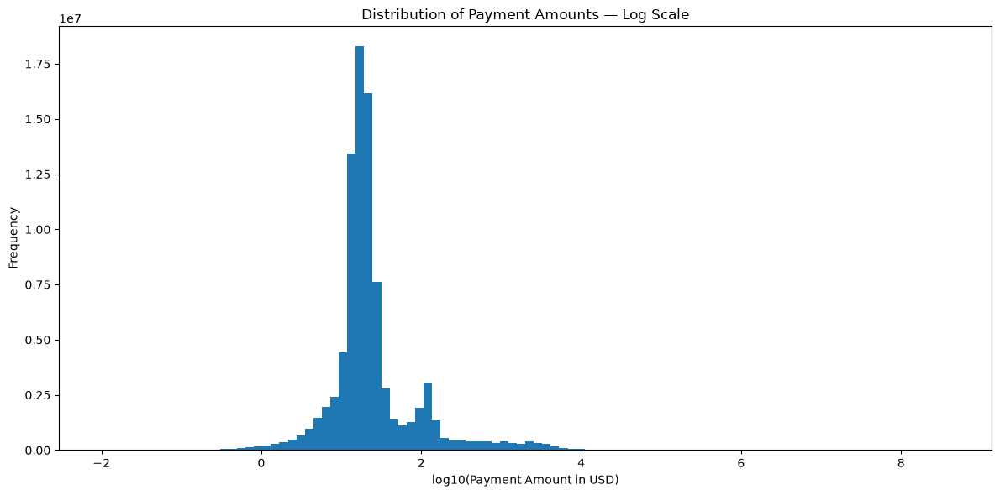


Payment Amount Percentiles:
shape: (1, 10)
┌──────┬──────┬──────┬───────┬───┬───────┬───────┬────────┬─────────┐
│ p1   ┆ p5   ┆ p10  ┆ p25   ┆ … ┆ p90   ┆ p95   ┆ p99    ┆ p99_9   │
│ ---  ┆ ---  ┆ ---  ┆ ---   ┆   ┆ ---   ┆ ---   ┆ ---    ┆ ---     │
│ f64  ┆ f64  ┆ f64  ┆ f64   ┆   ┆ f64   ┆ f64   ┆ f64    ┆ f64     │
╞══════╪══════╪══════╪═══════╪═══╪═══════╪═══════╪════════╪═════════╡
│ 1.49 ┆ 5.21 ┆ 8.83 ┆ 14.08 ┆ … ┆ 119.7 ┆ 300.0 ┆ 3200.0 ┆ 15120.0 │
└──────┴──────┴──────┴───────┴───┴───────┴───────┴────────┴─────────┘


In [32]:
# Histogram
column = "Total_Amount_of_Payment_USDollars"

data = (
    lf
    .select(pl.col(column))
    .filter(pl.col(column) > 0)
    .collect()
    .to_series()
    .to_numpy()
)

log_data = np.log10(data)

plt.figure(figsize=(12, 6))

plt.hist(log_data, bins=100)

plt.xlabel("log10(Payment Amount in USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Payment Amounts — Log Scale")

plt.tight_layout()
plt.show()


# Percentile analysis
percentiles = (
    lf
    .select([
        pl.col(column).quantile(0.01).alias("p1"),
        pl.col(column).quantile(0.05).alias("p5"),
        pl.col(column).quantile(0.10).alias("p10"),
        pl.col(column).quantile(0.25).alias("p25"),
        pl.col(column).quantile(0.50).alias("p50"),
        pl.col(column).quantile(0.75).alias("p75"),
        pl.col(column).quantile(0.90).alias("p90"),
        pl.col(column).quantile(0.95).alias("p95"),
        pl.col(column).quantile(0.99).alias("p99"),
        pl.col(column).quantile(0.999).alias("p99_9"),
    ])
    .collect()
)

print("\nPayment Amount Percentiles:")
print(percentiles)

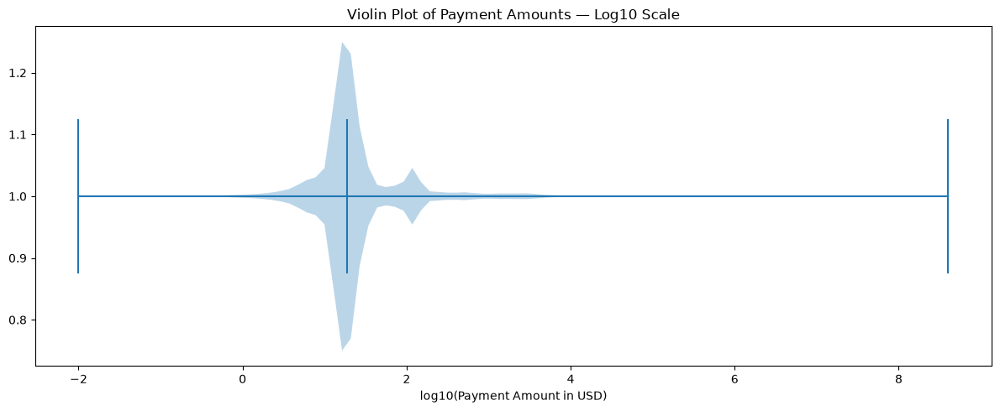

In [34]:
# Violin plot — Log10 Scale

column = "Total_Amount_of_Payment_USDollars"

data = (
    lf
    .select(pl.col(column))
    .filter(pl.col(column) > 0)
    .collect()
    .to_series()
    .to_numpy()
)

log_data = np.log10(data)

plt.figure(figsize=(12, 5))

plt.violinplot(
    log_data,
    vert=False,
    showmedians=True
)

plt.xlabel("log10(Payment Amount in USD)")
plt.title("Violin Plot of Payment Amounts — Log10 Scale")

plt.tight_layout()
plt.show()

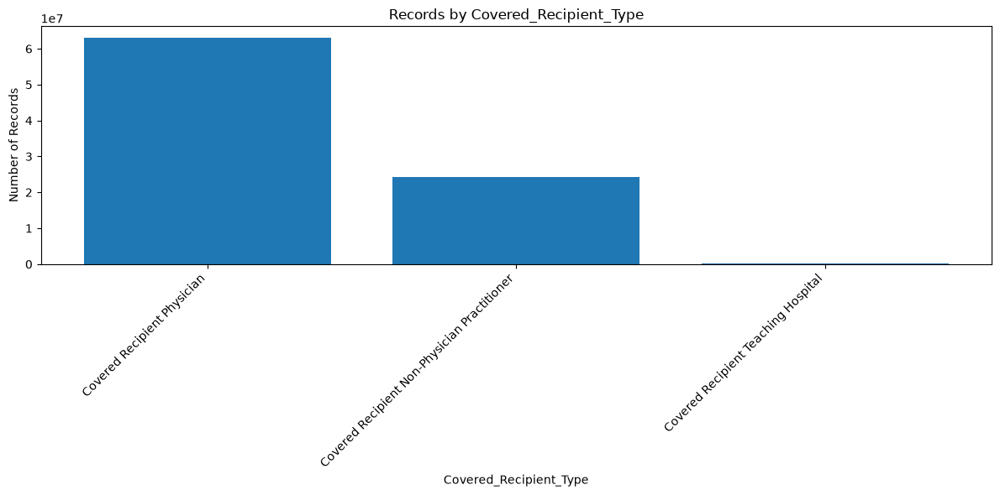

In [27]:
# Bar Chart
column = "Covered_Recipient_Type"

data = (
    lf
    .group_by(column)
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

plt.figure(figsize=(12, 6))
plt.bar(
    data[column].to_list(),
    data["count"].to_list()
)

plt.xlabel(column)
plt.ylabel("Number of Records")
plt.title(f"Records by {column}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Histogram

A histogram was used to examine the distribution of `Total_Amount_of_Payment_USDollars`.

The histogram on the original scale showed an extremely right-skewed distribution. Most payment amounts were concentrated near the lower end of the range, while a relatively small number of observations extended to very large payment amounts.

Because the extreme values compressed the majority of the distribution near zero, a `log10` transformation was applied to obtain a clearer view of the distribution.

The log-transformed histogram revealed a strong concentration of payment amounts in the lower range, along with additional smaller concentrations and a long upper tail.

Overall, the payment distribution is highly right-skewed and spans several orders of magnitude.

---

### Percentile Analysis

Percentile analysis was performed to quantify the distribution of payment amounts and examine the upper tail.

| Percentile | Payment Amount (USD) |
|---|---:|
| P1 | $1.49 |
| P5 | $5.21 |
| P10 | $8.83 |
| P25 | $14.08 |
| P50 (Median) | $27.43 |
| P75 | — |
| P90 | $119.70 |
| P95 | $300.00 |
| P99 | $3,200.00 |
| P99.9 | $15,120.00 |

The median payment amount is approximately `$27.43`.

The upper percentiles increase substantially:

- 90% of observations are at or below approximately `$119.70`.
- 95% are at or below approximately `$300`.
- 99% are at or below approximately `$3,200`.
- 99.9% are at or below approximately `$15,120`.

This demonstrates a substantial upper tail in the payment distribution.

---

### Violin Plot

A violin plot was used to examine the distribution shape and density of `Total_Amount_of_Payment_USDollars`.

The original-scale violin plot was heavily compressed because of the large range of payment values.

After applying the `log10` transformation, the distribution became much more visible.

The log-scale violin plot shows:

- A strong concentration of observations in the lower payment range.
- The highest density around approximately `log10(payment) ≈ 1–1.5`.
- A smaller concentration around approximately `log10(payment) ≈ 2`.
- A long right tail extending toward very large payment amounts.
- Some observations below `$1`, which appear at negative `log10` values.

The violin plot therefore provides additional evidence that the payment distribution is strongly right-skewed and contains multiple regions of higher density.

---

### Bar Chart

A bar chart was used to examine the frequency of records across the `Covered_Recipient_Type` categorical variable.

The dataset contains three recipient categories:

- `Covered Recipient Physician`
- `Covered Recipient Non-Physician Practitioner`
- `Covered Recipient Teaching Hospital`

The bar chart shows that `Covered Recipient Physician` is the largest category, followed by `Covered Recipient Non-Physician Practitioner`.

`Covered Recipient Teaching Hospital` represents a much smaller number of records compared with the other two categories.

Therefore, the records in this dataset are predominantly associated with physicians, followed by non-physician practitioners, while teaching-hospital records are comparatively uncommon.

---

### Visualization Summary

The visualizations provide complementary information about the dataset.

- **Histogram:** Shows the overall distribution and strong right skew of payment amounts.
- **Percentile analysis:** Quantifies the distribution and demonstrates the substantial upper tail.
- **Box plot:** Shows the median, interquartile range, and statistical outliers.
- **Violin plot:** Shows the density and shape of the payment distribution.
- **Bar chart:** Shows the frequency distribution of the `Covered_Recipient_Type` categories.

The analysis of `Total_Amount_of_Payment_USDollars` consistently indicates a highly right-skewed distribution with a long upper tail. Log transformation provides a more informative representation of the central distribution because payment values span several orders of magnitude.

The categorical analysis shows that `Covered Recipient Physician` records dominate the dataset, followed by `Covered Recipient Non-Physician Practitioner`, with `Covered Recipient Teaching Hospital` records occurring much less frequently.

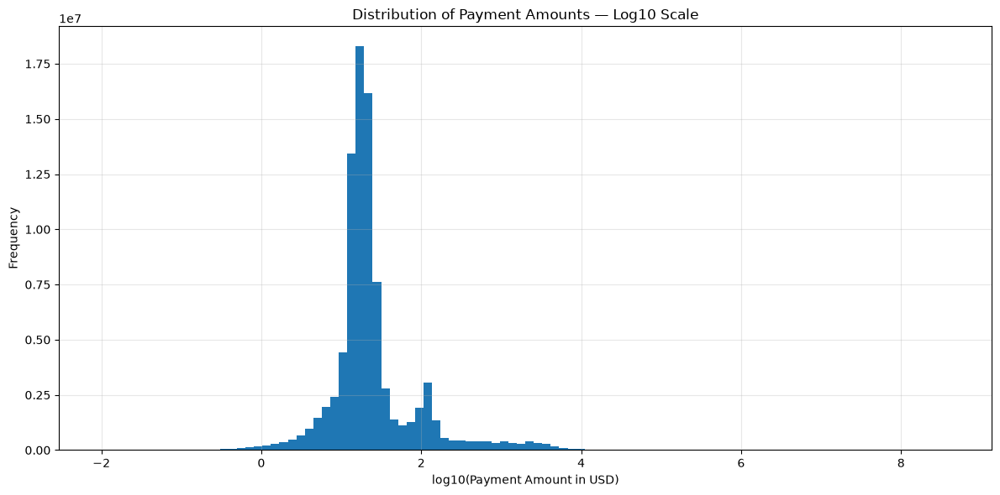

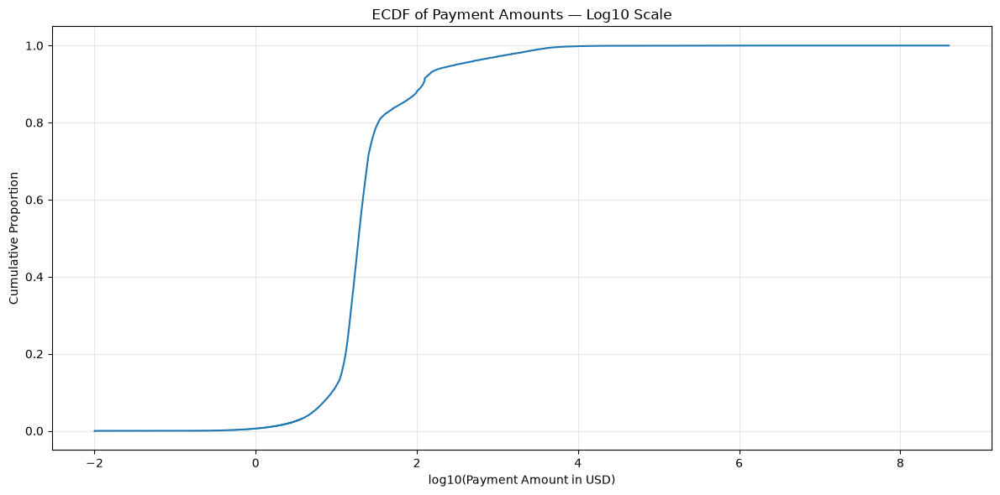

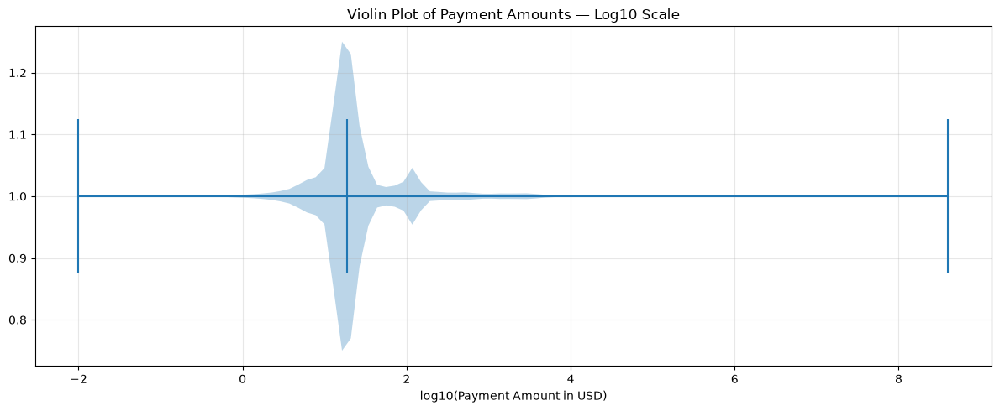

In [40]:
# UNIVARIATE ANALYSIS — NUMERICAL VARIABLES


# Total Amount of Payment — Continuous Variable

column = "Total_Amount_of_Payment_USDollars"


# Load positive payment amounts

data = (
    lf
    .select(pl.col(column))
    .filter(pl.col(column) > 0)
    .collect()
    .to_series()
    .to_numpy()
)

# Log10 transformation
log_data = np.log10(data)


# HISTOGRAM

plt.figure(figsize=(12, 6))

plt.hist(
    log_data,
    bins=100
)

plt.xlabel("log10(Payment Amount in USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Payment Amounts — Log10 Scale")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ECDF

sorted_data = np.sort(log_data)

y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

plt.figure(figsize=(12, 6))

plt.plot(
    sorted_data,
    y
)

plt.xlabel("log10(Payment Amount in USD)")
plt.ylabel("Cumulative Proportion")
plt.title("ECDF of Payment Amounts — Log10 Scale")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# VIOLIN PLOT

plt.figure(figsize=(12, 5))

plt.violinplot(
    log_data,
    vert=False,
    showmedians=True
)

plt.xlabel("log10(Payment Amount in USD)")
plt.title("Violin Plot of Payment Amounts — Log10 Scale")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observations — Payment Amount Distribution

1. **Payment amounts are highly concentrated at lower values.**
   The histogram shows a strong concentration of observations around `log10(1–2)`, corresponding approximately to payment amounts in the range of **$10–$100**.

2. **The distribution has a long right tail.**
   Although most payment records are concentrated at relatively small amounts, the distribution extends far to the right, indicating the presence of a small number of very large payments.

3. **A secondary concentration is visible at higher payment values.**
   Both the histogram and violin plot show another smaller concentration around `log10(2)`, corresponding to approximately **$100**. This indicates that payment amounts are not concentrated around a single narrow range.

4. **The ECDF confirms that most observations occur at relatively small payment amounts.**
   The ECDF rises very steeply in the lower range of the log-transformed payment amounts, showing that a large proportion of records are concentrated there. After this region, the curve increases more gradually as increasingly larger payments are encountered.

5. **Very large payments represent a small proportion of the observations.**
   The ECDF approaches 1 relatively quickly compared with the extremely long range of the x-axis. This indicates that the extreme high-value payments form only a small fraction of all records.

6. **The violin plot confirms the strongly concentrated and right-tailed structure.**
   The widest portion of the violin occurs around the lower payment range, while the distribution becomes increasingly narrow toward higher values, forming a long tail.

7. **The log transformation makes the distribution easier to visualize.**
   Because payment amounts span several orders of magnitude, the `log10` transformation compresses the extreme values and makes the underlying distribution and concentration of observations more visible.


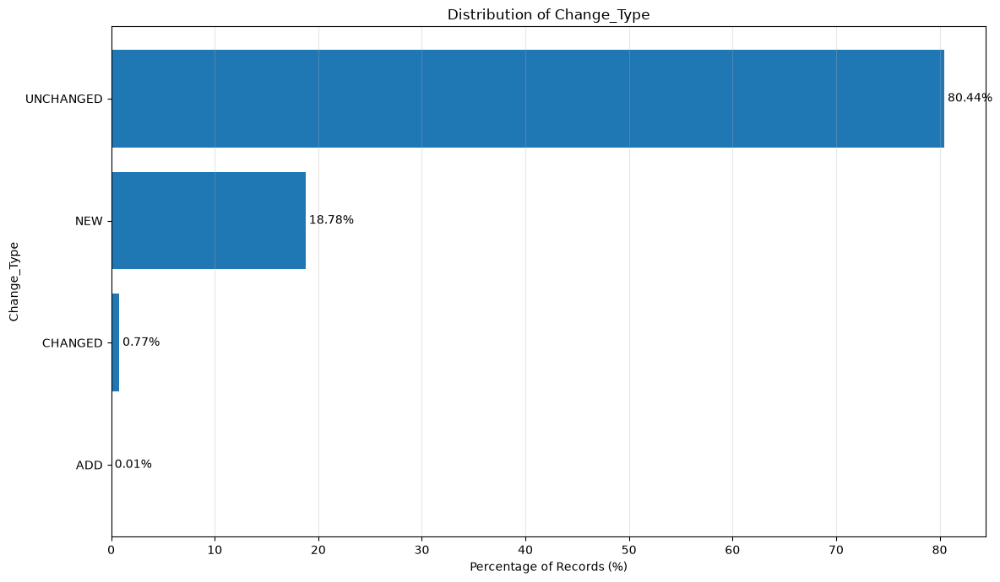

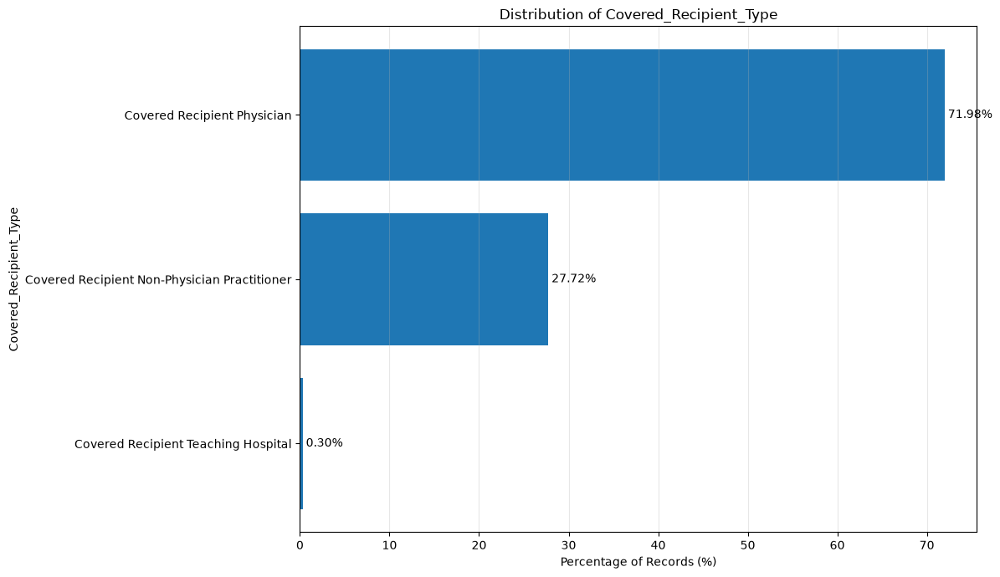

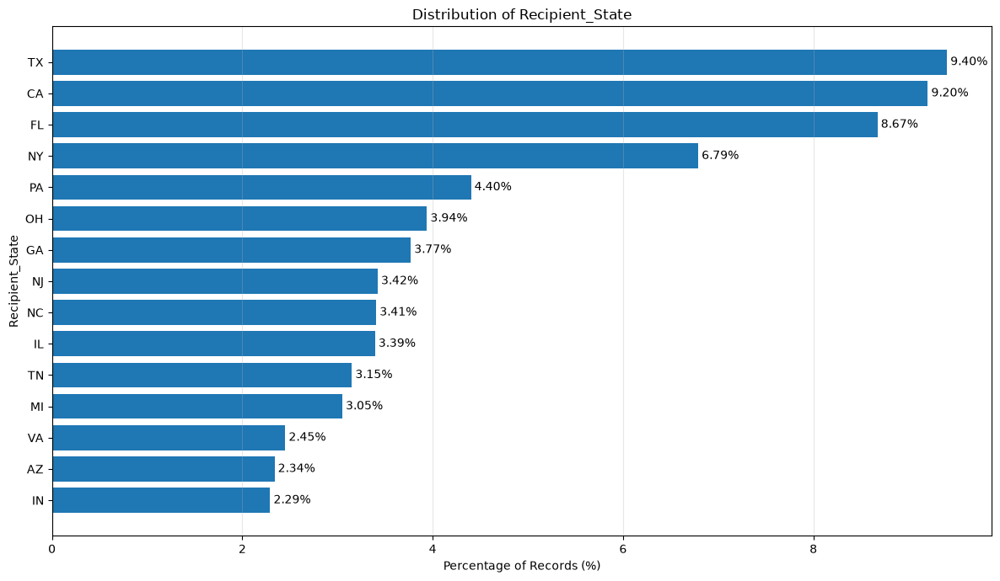

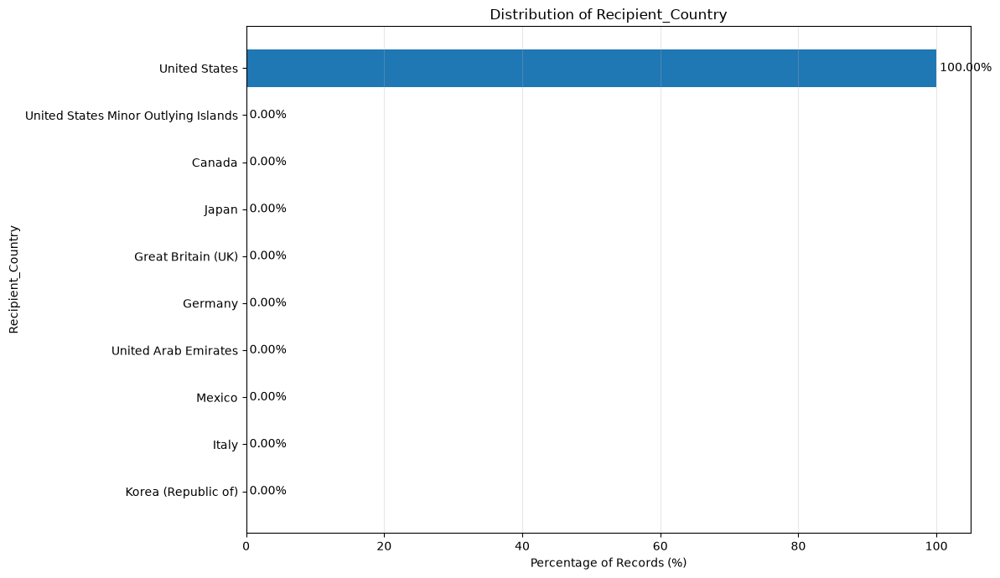

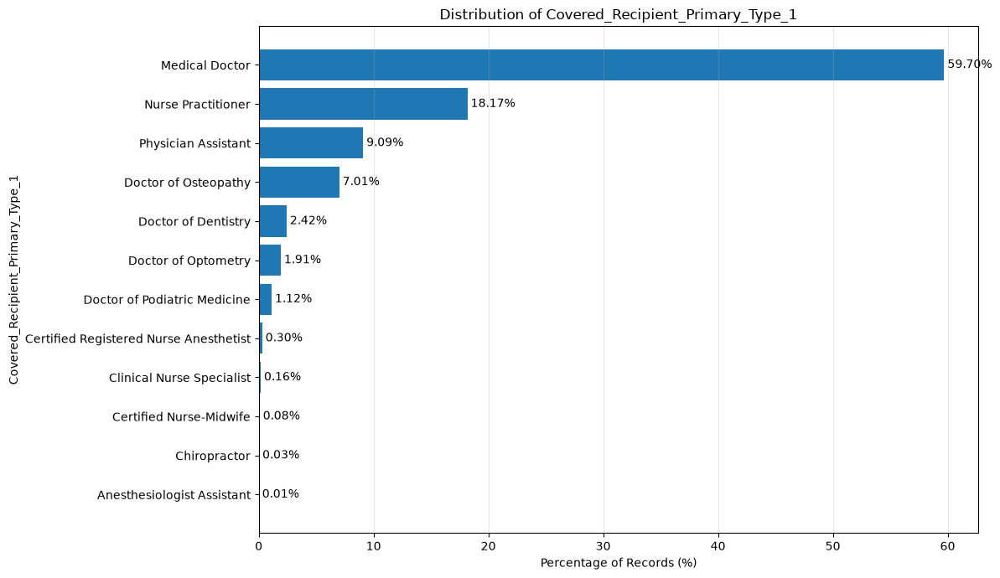

...

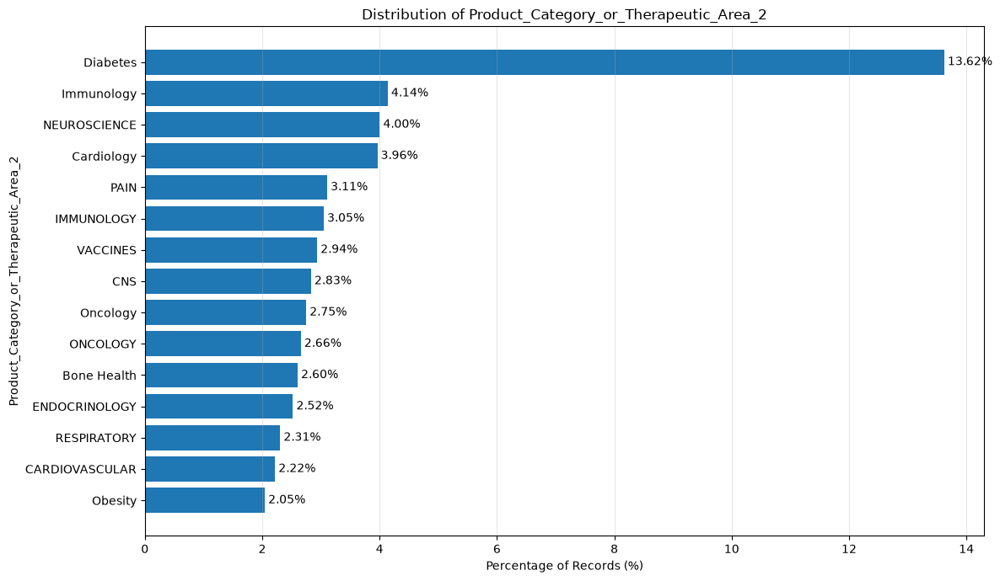

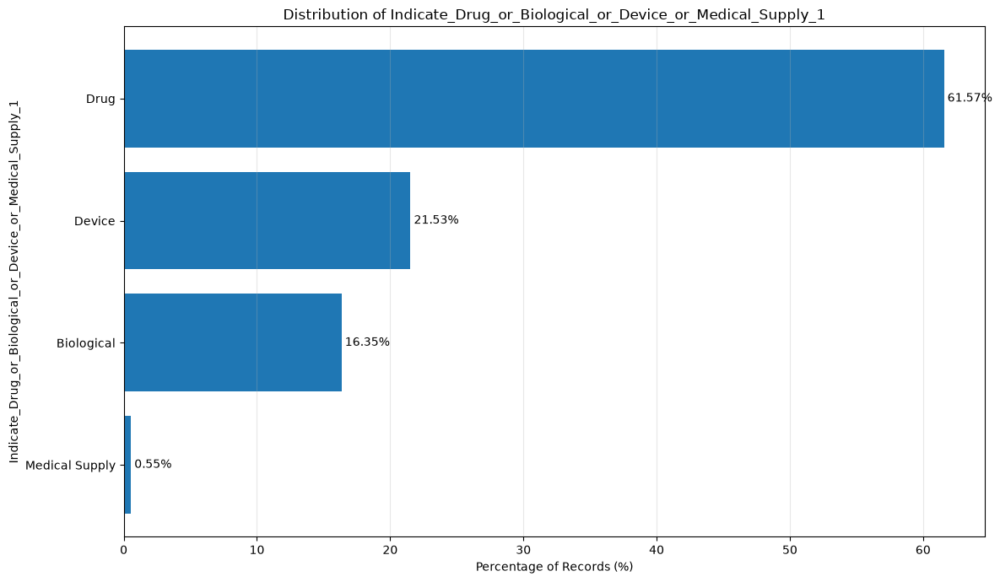

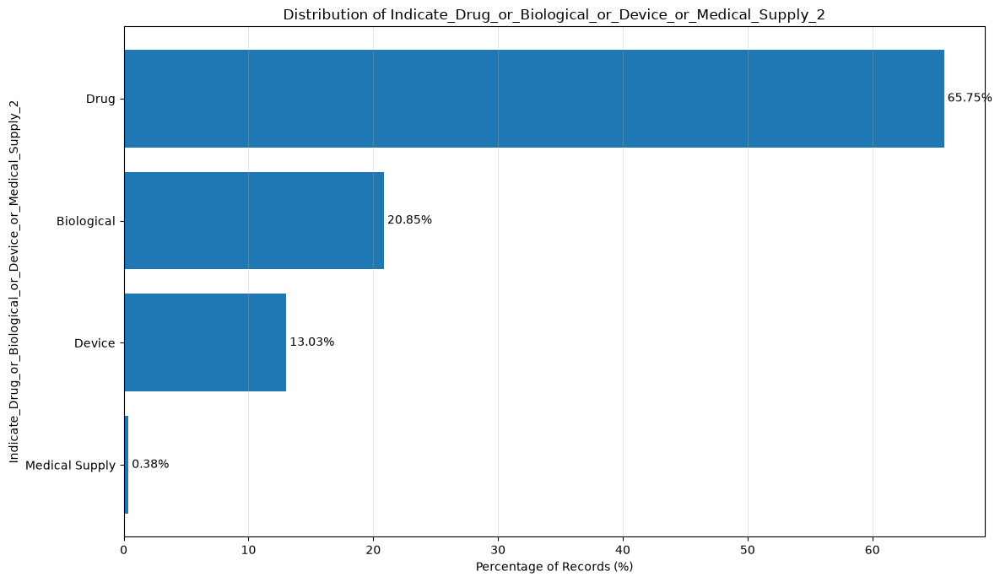

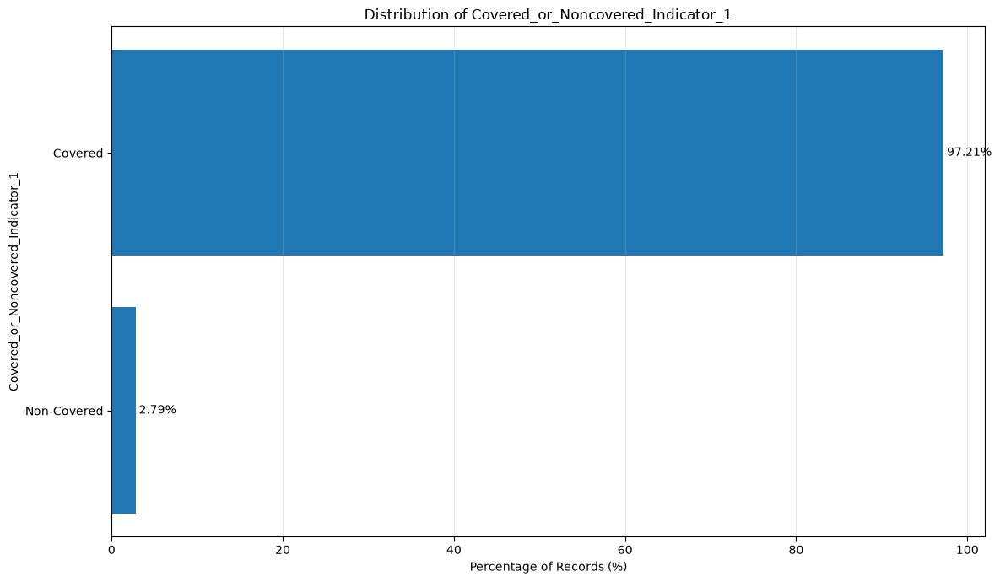

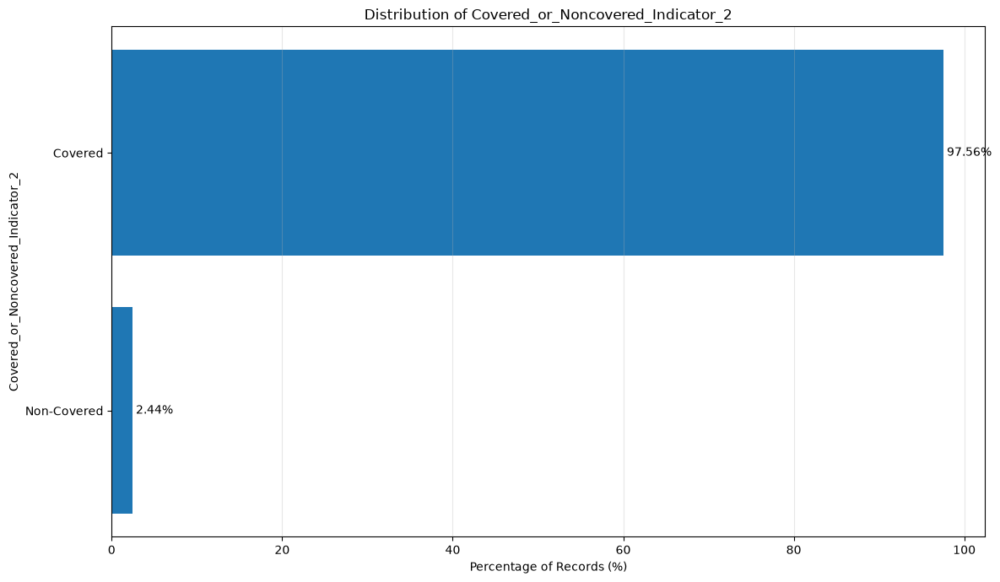

In [43]:
# UNIVARIATE ANALYSIS — CATEGORICAL VARIABLES

categorical_columns = [
    "Change_Type",
    "Covered_Recipient_Type",
    "Recipient_State",
    "Recipient_Country",
    "Covered_Recipient_Primary_Type_1",
    "Form_of_Payment_or_Transfer_of_Value",
    "Nature_of_Payment_or_Transfer_of_Value",
    "Physician_Ownership_Indicator",
    "Third_Party_Payment_Recipient_Indicator",
    "Charity_Indicator",
    "Delay_in_Publication_Indicator",
    "Dispute_Status_for_Publication",
    "Related_Product_Indicator",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country",
    "Covered_Recipient_License_State_code1",
    "Covered_Recipient_Specialty_1",
    "Covered_Recipient_Specialty_2",
    "Covered_Recipient_Specialty_3",
    "Covered_Recipient_Specialty_4",
    "Covered_Recipient_Specialty_5",
    "Covered_Recipient_Specialty_6",
    "Product_Category_or_Therapeutic_Area_1",
    "Product_Category_or_Therapeutic_Area_2",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2",
    "Covered_or_Noncovered_Indicator_1",
    "Covered_or_Noncovered_Indicator_2",
]

top_n_columns = {
    "Recipient_State": 15,
    "Recipient_Country": 10,
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State": 15,
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country": 10,
    "Covered_Recipient_License_State_code1": 15,
    "Covered_Recipient_Specialty_1": 15,
    "Covered_Recipient_Specialty_2": 15,
    "Covered_Recipient_Specialty_3": 15,
    "Covered_Recipient_Specialty_4": 15,
    "Covered_Recipient_Specialty_5": 15,
    "Covered_Recipient_Specialty_6": 15,
    "Product_Category_or_Therapeutic_Area_1": 15,
    "Product_Category_or_Therapeutic_Area_2": 15,
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1": 15,
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2": 15,
    "Covered_or_Noncovered_Indicator_1": 15,
    "Covered_or_Noncovered_Indicator_2": 15,
}

for column in categorical_columns:

    # Calculate frequencies
    frequency = (
        lf
        .filter(pl.col(column).is_not_null())
        .group_by(column)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

    # Calculate percentage using all non-null records
    total = frequency["count"].sum()

    frequency = frequency.with_columns(
        (pl.col("count") / total * 100).alias("percentage")
    )

    # Keep only Top-N when specified
    top_n = top_n_columns.get(column)

    if top_n is not None:
        frequency = frequency.head(top_n)

    frequency = frequency.sort("percentage")

    # Plot
    plt.figure(figsize=(12, 7))

    bars = plt.barh(
        frequency[column].cast(pl.String).to_list(),
        frequency["percentage"].to_list()
    )

    plt.xlabel("Percentage of Records (%)")
    plt.ylabel(column)
    plt.title(f"Distribution of {column}")

    for bar, percentage in zip(
        bars,
        frequency["percentage"].to_list()
    ):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {percentage:.2f}%",
            va="center"
        )

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [44]:
# UNIVARIATE ANALYSIS — CATEGORICAL VARIABLES

import os

output_dir = "categorical_plots"
os.makedirs(output_dir, exist_ok=True)

categorical_columns = [
    "Change_Type",
    "Covered_Recipient_Type",
    "Recipient_State",
    "Recipient_Country",
    "Covered_Recipient_Primary_Type_1",
    "Form_of_Payment_or_Transfer_of_Value",
    "Nature_of_Payment_or_Transfer_of_Value",
    "Physician_Ownership_Indicator",
    "Third_Party_Payment_Recipient_Indicator",
    "Charity_Indicator",
    "Delay_in_Publication_Indicator",
    "Dispute_Status_for_Publication",
    "Related_Product_Indicator",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country",
    "Covered_Recipient_License_State_code1",
    "Covered_Recipient_Specialty_1",
    "Covered_Recipient_Specialty_2",
    "Covered_Recipient_Specialty_3",
    "Covered_Recipient_Specialty_4",
    "Covered_Recipient_Specialty_5",
    "Covered_Recipient_Specialty_6",
    "Product_Category_or_Therapeutic_Area_1",
    "Product_Category_or_Therapeutic_Area_2",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2",
    "Covered_or_Noncovered_Indicator_1",
    "Covered_or_Noncovered_Indicator_2",
]

top_n_columns = {
    "Recipient_State": 15,
    "Recipient_Country": 10,
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State": 15,
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country": 10,
    "Covered_Recipient_License_State_code1": 15,
    "Covered_Recipient_Specialty_1": 15,
    "Covered_Recipient_Specialty_2": 15,
    "Covered_Recipient_Specialty_3": 15,
    "Covered_Recipient_Specialty_4": 15,
    "Covered_Recipient_Specialty_5": 15,
    "Covered_Recipient_Specialty_6": 15,
    "Product_Category_or_Therapeutic_Area_1": 15,
    "Product_Category_or_Therapeutic_Area_2": 15,
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1": 15,
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2": 15,
    "Covered_or_Noncovered_Indicator_1": 15,
    "Covered_or_Noncovered_Indicator_2": 15,
}

for column in categorical_columns:

    frequency = (
        lf
        .filter(pl.col(column).is_not_null())
        .group_by(column)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

    total = frequency["count"].sum()

    frequency = frequency.with_columns(
        (pl.col("count") / total * 100).alias("percentage")
    )

    top_n = top_n_columns.get(column)

    if top_n is not None:
        frequency = frequency.head(top_n)

    frequency = frequency.sort("percentage")

    plt.figure(figsize=(12, 7))

    bars = plt.barh(
        frequency[column].cast(pl.String).to_list(),
        frequency["percentage"].to_list()
    )

    plt.xlabel("Percentage of Records (%)")
    plt.ylabel(column)
    plt.title(f"Distribution of {column}")

    for bar, percentage in zip(
        bars,
        frequency["percentage"].to_list()
    ):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {percentage:.2f}%",
            va="center"
        )

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    # Save plot
    filename = column.replace("/", "_").replace("\\", "_") + ".png"
    plt.savefig(
        os.path.join(output_dir, filename),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print(f"Saved {len(categorical_columns)} plots to: {output_dir}/")

Saved 28 plots to: categorical_plots/


## Categorical Variables — Univariate Analysis

Categorical variables represent groups, labels, or distinct categories rather than numerical measurements.

For categorical variables, **frequency and percentage distributions** are used to understand how observations are distributed across categories.

### Visualization

**Horizontal bar charts** are used to visualize categorical distributions.

They are particularly useful because:

- Categories can be compared directly.
- Percentages make the relative distribution easier to interpret.
- Horizontal orientation improves readability for long category names.
- For variables with many categories, only the **top categories** are displayed to avoid overcrowding.

### Key Observations

- `Dispute_Status_for_Publication` is overwhelmingly **"No"**, accounting for essentially all records.
- `Form_of_Payment_or_Transfer_of_Value` is dominated by **"In-kind items and services" (85.87%)**, followed by **"Cash or cash equivalent" (14.12%)**.
- `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1` is primarily **Drug (61.57%)**, followed by **Device (21.53%)** and **Biological (16.35%)**.
- `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2` shows a similar distribution, with **Drug (65.75%)** being the largest category.
- `Nature_of_Payment_or_Transfer_of_Value` is highly concentrated in **Food and Beverage (90.70%)**. The remaining categories account for relatively small proportions.
- `Physician_Ownership_Indicator` is overwhelmingly **"No" (99.83%)**, with **"Yes" accounting for 0.17%**.
- `Related_Product_Indicator` is predominantly **"Yes (94.39%)**, while **"No" accounts for 5.61%**.
- `Third_Party_Payment_Recipient_Indicator` is dominated by **"No Third Party Payment (98.98%)**.
- `Recipient_Country` is almost entirely **United States**, indicating that the dataset is overwhelmingly domestic with respect to recipient country.
- `Recipient_State` shows variation across states, with **Texas, California, Florida, and New York** among the most frequently represented states.
- `Product_Category_or_Therapeutic_Area_1` and `Product_Category_or_Therapeutic_Area_2` contain several therapeutic categories. The distributions are relatively dispersed compared with the binary indicator variables.
- The therapeutic-area variables also show **inconsistent capitalization**, such as `Immunology` and `IMMUNOLOGY`, or `Neuroscience` and `NEUROSCIENCE`. These should be considered during data cleaning because they may represent the same category.

### Interpretation

The categorical variables show that many fields are **highly imbalanced**, with a small number of categories accounting for most observations. This is particularly evident in payment form, payment nature, ownership indicators, third-party payment indicators, and dispute status.

For high-cardinality variables, displaying every category can reduce readability. Therefore, **Top-N categories or grouped "Other" categories** are more appropriate for visualization, while the complete frequency table can be retained for detailed analysis.

# 7. Bivariate analysis

### Numerical ↔ Numerical:

- Scatter plot
- Correlation
- Covariance

### Categorical ↔ Numerical:

- Box/violin plot
- Grouped statistics

### Categorical ↔ Categorical:

- Cross-tabulation
- Stacked/grouped bar charts
- Chi-square analysis

Valid records: 87,655,757


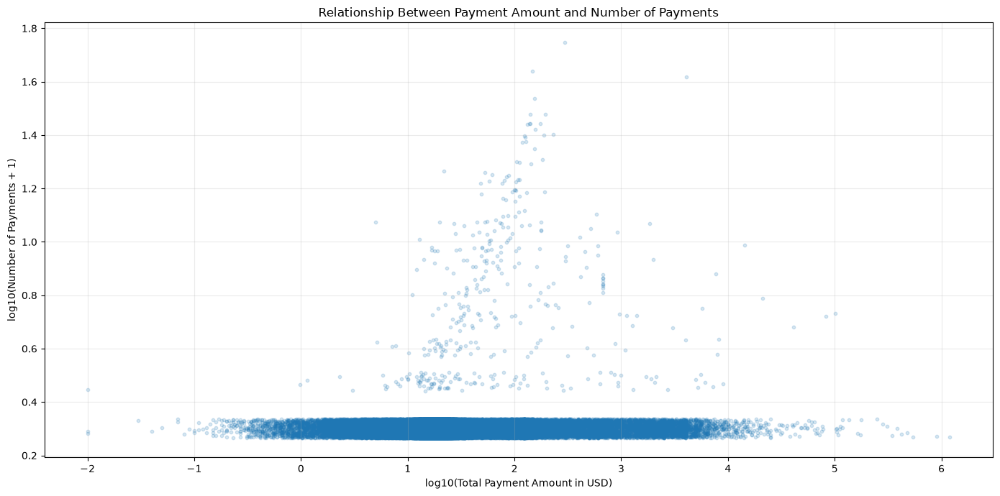


Pearson Correlation:
shape: (1, 1)
┌─────────────┐
│ Correlation │
│ ---         │
│ f64         │
╞═════════════╡
│ 0.000638    │
└─────────────┘

Pearson Correlation — Log Transformed:
shape: (1, 1)
┌─────────────────┐
│ Log Correlation │
│ ---             │
│ f64             │
╞═════════════════╡
│ 0.053348        │
└─────────────────┘

Covariance:
shape: (1, 1)
┌────────────┐
│ Covariance │
│ ---        │
│ f64        │
╞════════════╡
│ 35.051587  │
└────────────┘

Covariance — Log Transformed:
shape: (1, 1)
┌────────────────┐
│ Log Covariance │
│ ---            │
│ f64            │
╞════════════════╡
│ 0.000987       │
└────────────────┘


In [48]:
x_col = "Total_Amount_of_Payment_USDollars"
y_col = "Number_of_Payments_Included_in_Total_Amount"

data = (
    lf
    .select([
        pl.col(x_col),
        pl.col(y_col)
    ])
    .filter(
        (pl.col(x_col) > 0) &
        (pl.col(y_col) > 0)
    )
    .collect()
)

print(f"Valid records: {len(data):,}")

sample_size = min(100_000, len(data))

plot_data = data.sample(
    n=sample_size,
    seed=42
)

x = plot_data[x_col].to_numpy()
y = plot_data[y_col].to_numpy()

log_x = np.log10(x)
log_y = np.log10(y + 1)

rng = np.random.default_rng(42)

jitter = rng.uniform(
    -0.035,
    0.035,
    size=len(log_y)
)

log_y_jittered = log_y + jitter

plt.figure(figsize=(14, 7))

plt.scatter(
    log_x,
    log_y_jittered,
    s=10,
    alpha=0.18
)

plt.xlabel("log10(Total Payment Amount in USD)")
plt.ylabel("log10(Number of Payments + 1)")
plt.title("Relationship Between Payment Amount and Number of Payments")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

correlation = (
    data
    .select(
        pl.corr(x_col, y_col).alias("Correlation")
    )
)

print("\nPearson Correlation:")
print(correlation)

log_data = data.select([
    pl.col(x_col).log10().alias("log_payment"),
    (pl.col(y_col) + 1).log10().alias("log_payments")
])

log_correlation = (
    log_data
    .select(
        pl.corr(
            "log_payment",
            "log_payments"
        ).alias("Log Correlation")
    )
)

print("\nPearson Correlation — Log Transformed:")
print(log_correlation)

covariance = (
    data
    .select(
        pl.cov(x_col, y_col).alias("Covariance")
    )
)

print("\nCovariance:")
print(covariance)

log_covariance = (
    log_data
    .select(
        pl.cov(
            "log_payment",
            "log_payments"
        ).alias("Log Covariance")
    )
)

print("\nCovariance — Log Transformed:")
print(log_covariance)

## Numerical ↔ Numerical

Bivariate analysis examines the relationship between two numerical variables.

### Scatter Plot

A scatter plot is used to visualize the relationship between two numerical variables. Each point represents an observation, allowing patterns, clusters, trends, and potential relationships to be identified.

For the payment dataset, the relationship between `Total_Amount_of_Payment_USDollars` and `Number_of_Payments_Included_in_Total_Amount` was visualized using log-transformed values.

The payment amount was highly right-skewed, while the number of payments was a discrete count variable. Therefore, logarithmic transformations were used to improve visualization, with a small amount of jitter added to the number-of-payments axis to reduce overlapping points.

The scatter plot shows a very dense concentration around one payment, while higher numbers of payments occur much less frequently.

### Correlation

Pearson correlation measures the strength and direction of a linear relationship between two numerical variables.

The results were:

- **Raw Pearson correlation:** `0.000638`
- **Log-transformed Pearson correlation:** `0.053348`

The raw correlation is essentially zero, indicating almost no linear relationship between payment amount and number of payments.

After logarithmic transformation, the correlation becomes slightly positive, but remains very weak. This indicates that transforming the variables does not reveal a substantial linear relationship.

### Covariance

Covariance indicates whether two variables tend to increase or decrease together.

The results were:

- **Raw covariance:** `35.051587`
- **Log-transformed covariance:** `0.000987`

The positive covariance indicates a slight tendency for the variables to vary in the same direction. However, covariance is strongly dependent on the scale of the variables, so the correlation coefficient is more useful for interpreting the strength of the relationship.

### Conclusion

The scatter plot and correlation analysis indicate that **payment amount and number of payments have almost no linear relationship** in the dataset.

The large concentration of observations at one payment suggests that most records represent a single payment, while records containing multiple payments are considerably less common.


Covered_Recipient_Type

Grouped Statistics:
shape: (3, 7)
┌──────────────────────────────┬──────────┬────────┬──────────────┬──────────────┬──────┬──────────┐
│ Covered_Recipient_Type       ┆ Count    ┆ Median ┆ Mean         ┆ Std          ┆ Min  ┆ Max      │
│ ---                          ┆ ---      ┆ ---    ┆ ---          ┆ ---          ┆ ---  ┆ ---      │
│ str                          ┆ u32      ┆ f64    ┆ f64          ┆ f64          ┆ f64  ┆ f64      │
╞══════════════════════════════╪══════════╪════════╪══════════════╪══════════════╪══════╪══════════╡
│ Covered Recipient Teaching   ┆ 262411   ┆ 824.66 ┆ 24380.702448 ┆ 1.4710e6     ┆ 0.01 ┆ 4e8      │
│ Hos…                         ┆          ┆        ┆              ┆              ┆      ┆          │
│ Covered Recipient Physician  ┆ 63091864 ┆ 19.23  ┆ 258.181266   ┆ 29455.928295 ┆ 0.01 ┆ 1.1040e8 │
│ Covered Recipient            ┆ 24301492 ┆ 18.21  ┆ 41.889363    ┆ 450.846544   ┆ 0.01 ┆ 1.6193e6 │
│ Non-Physicia…                ┆

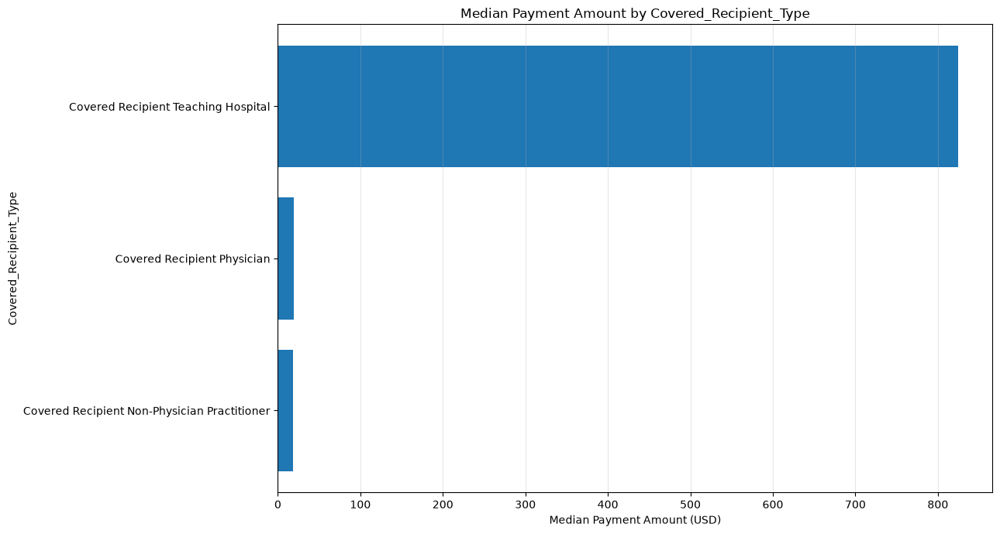

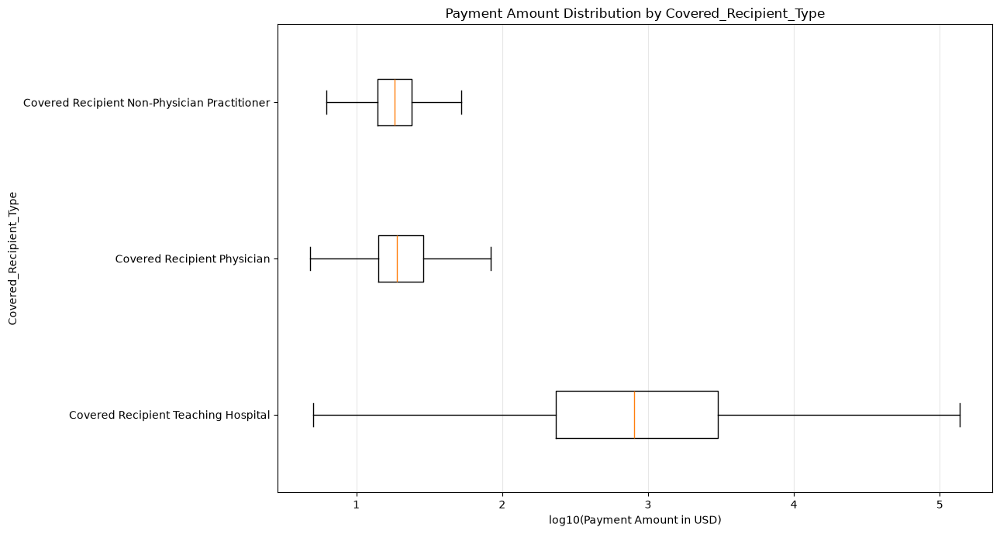


Recipient_State

Grouped Statistics:
shape: (15, 7)
┌─────────────────┬─────────┬────────┬────────────┬──────────────┬──────┬─────────────┐
│ Recipient_State ┆ Count   ┆ Median ┆ Mean       ┆ Std          ┆ Min  ┆ Max         │
│ ---             ┆ ---     ┆ ---    ┆ ---        ┆ ---          ┆ ---  ┆ ---         │
│ str             ┆ u32     ┆ f64    ┆ f64        ┆ f64          ┆ f64  ┆ f64         │
╞═════════════════╪═════════╪════════╪════════════╪══════════════╪══════╪═════════════╡
│ CA              ┆ 8066396 ┆ 21.96  ┆ 401.401309 ┆ 37589.127673 ┆ 0.01 ┆ 5.5070e7    │
│ NY              ┆ 5952215 ┆ 20.73  ┆ 243.316159 ┆ 10778.050905 ┆ 0.01 ┆ 1.2213e7    │
│ IL              ┆ 2975350 ┆ 20.05  ┆ 251.071272 ┆ 8165.906886  ┆ 0.01 ┆ 7.265357e6  │
│ FL              ┆ 7602880 ┆ 19.95  ┆ 203.500572 ┆ 41930.201123 ┆ 0.01 ┆ 9.1083e7    │
│ AZ              ┆ 2049900 ┆ 19.24  ┆ 212.610041 ┆ 16603.896994 ┆ 0.01 ┆ 1.6721999e7 │
│ …               ┆ …       ┆ …      ┆ …          ┆ …            ┆ 

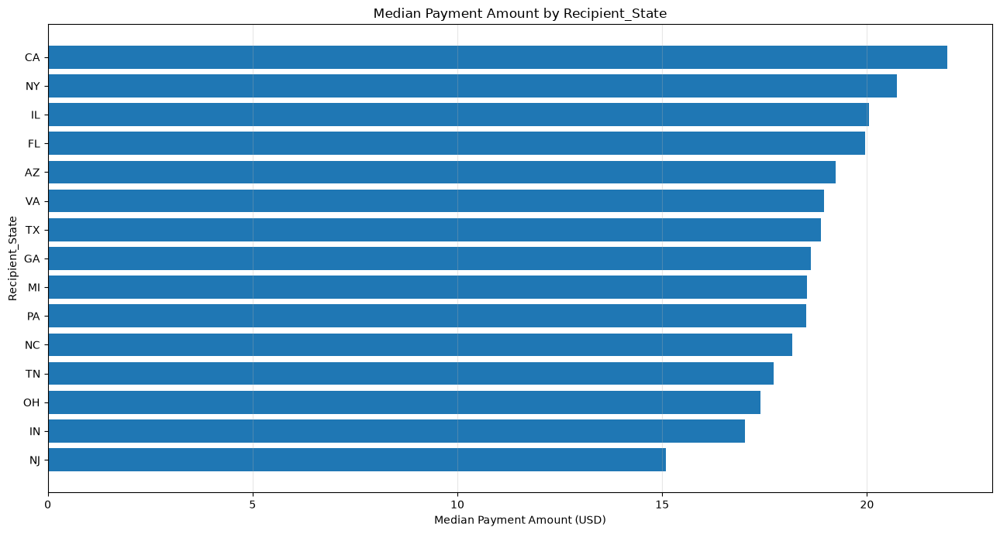

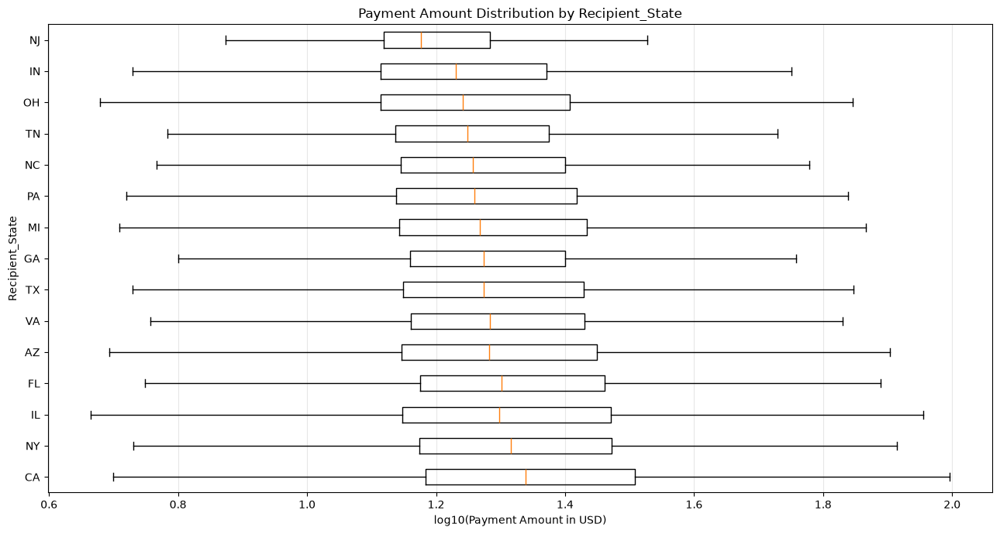


Form_of_Payment_or_Transfer_of_Value

Grouped Statistics:
shape: (6, 7)
┌──────────────────────┬──────────┬──────────┬───────────────┬───────────────┬───────┬─────────────┐
│ Form_of_Payment_or_T ┆ Count    ┆ Median   ┆ Mean          ┆ Std           ┆ Min   ┆ Max         │
│ ransfer_of…          ┆ ---      ┆ ---      ┆ ---           ┆ ---           ┆ ---   ┆ ---         │
│ ---                  ┆ u32      ┆ f64      ┆ f64           ┆ f64           ┆ f64   ┆ f64         │
│ str                  ┆          ┆          ┆               ┆               ┆       ┆             │
╞══════════════════════╪══════════╪══════════╪═══════════════╪═══════════════╪═══════╪═════════════╡
│ Stock, stock option, ┆ 1393     ┆ 6735.0   ┆ 52162.220524  ┆ 135617.273461 ┆ 15.25 ┆ 3.5259e6    │
│ or any ot…           ┆          ┆          ┆               ┆               ┆       ┆             │
│ Dividend, profit or  ┆ 1478     ┆ 4079.855 ┆ 58983.786069  ┆ 210848.35214  ┆ 4.0   ┆ 6.7919e6    │
│ other retu…     

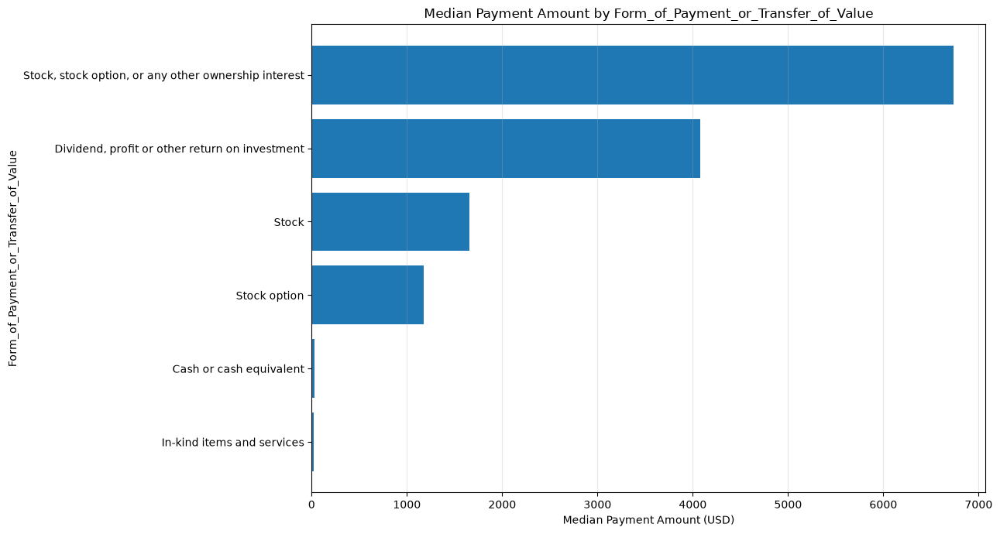

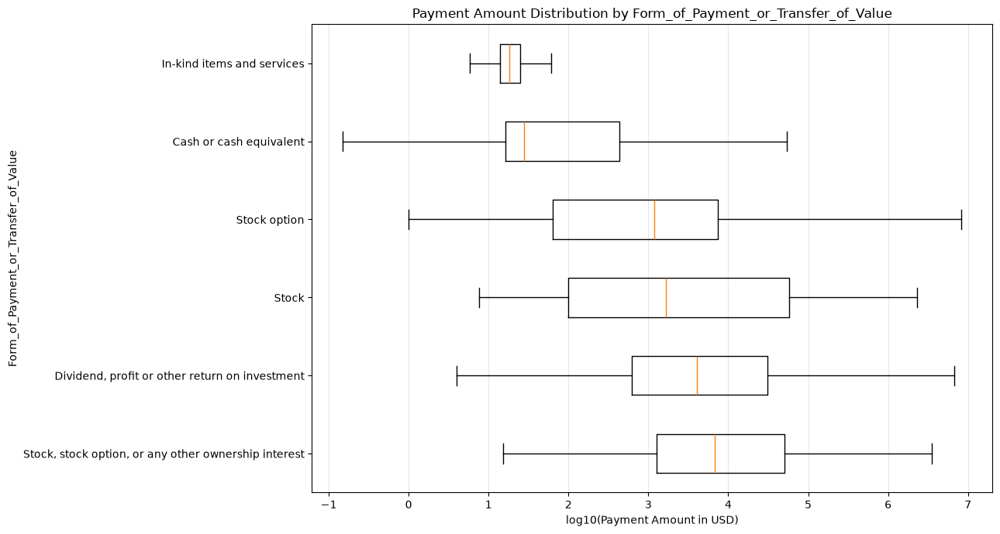


Nature_of_Payment_or_Transfer_of_Value

Grouped Statistics:
shape: (10, 7)
┌────────────────────────────┬──────────┬────────┬──────────────┬──────────────┬──────┬────────────┐
│ Nature_of_Payment_or_Trans ┆ Count    ┆ Median ┆ Mean         ┆ Std          ┆ Min  ┆ Max        │
│ fer_…                      ┆ ---      ┆ ---    ┆ ---          ┆ ---          ┆ ---  ┆ ---        │
│ ---                        ┆ u32      ┆ f64    ┆ f64          ┆ f64          ┆ f64  ┆ f64        │
│ str                        ┆          ┆        ┆              ┆              ┆      ┆            │
╞════════════════════════════╪══════════╪════════╪══════════════╪══════════════╪══════╪════════════╡
│ Royalty or License         ┆ 110031   ┆ 4417.7 ┆ 77299.746563 ┆ 2.2831e6     ┆ 0.01 ┆ 4e8        │
│ Honoraria                  ┆ 141181   ┆ 1750.0 ┆ 2594.066711  ┆ 7636.197692  ┆ 0.01 ┆ 1e6        │
│ Compensation for services  ┆ 1629827  ┆ 1745.0 ┆ 2549.961493  ┆ 50650.28482  ┆ 0.01 ┆ 4.9922e7   │
│ othe…        

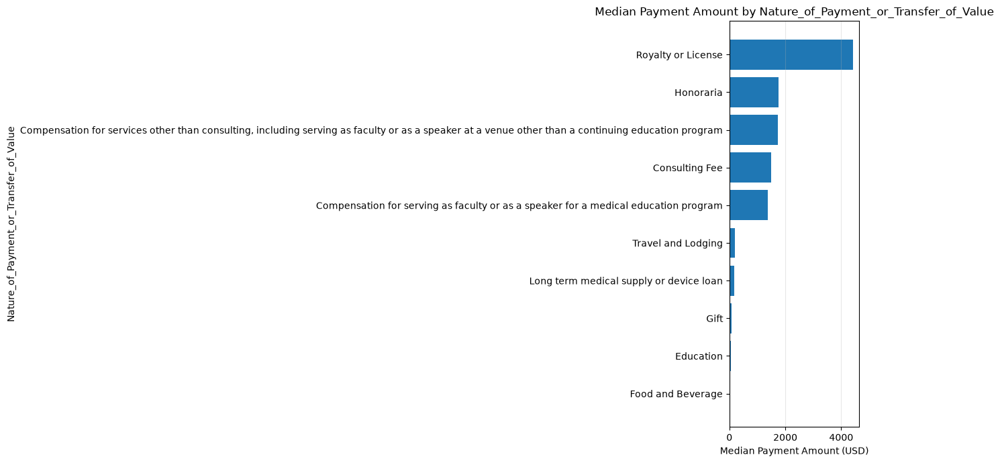

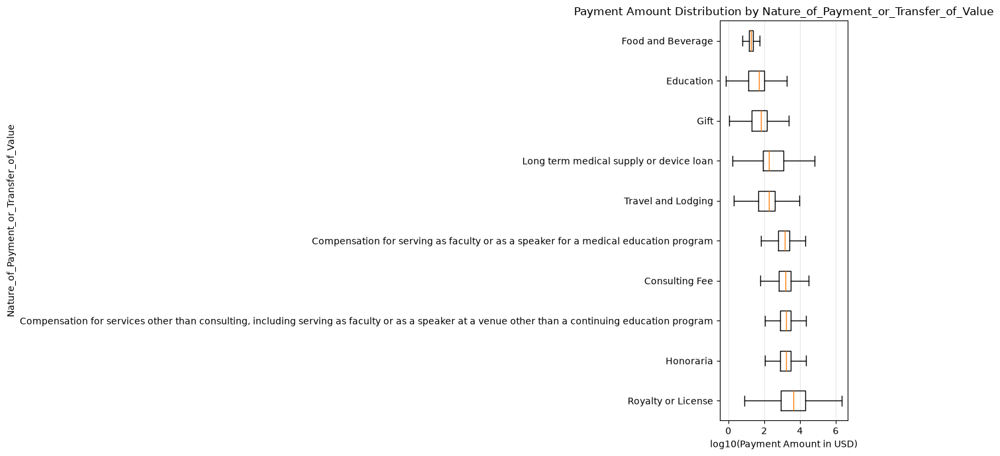


Physician_Ownership_Indicator

Grouped Statistics:
shape: (2, 7)
┌──────────────────────────────┬──────────┬────────┬─────────────┬───────────────┬──────┬──────────┐
│ Physician_Ownership_Indicato ┆ Count    ┆ Median ┆ Mean        ┆ Std           ┆ Min  ┆ Max      │
│ r                            ┆ ---      ┆ ---    ┆ ---         ┆ ---           ┆ ---  ┆ ---      │
│ ---                          ┆ u32      ┆ f64    ┆ f64         ┆ f64           ┆ f64  ┆ f64      │
│ str                          ┆          ┆        ┆             ┆               ┆      ┆          │
╞══════════════════════════════╪══════════╪════════╪═════════════╪═══════════════╪══════╪══════════╡
│ Yes                          ┆ 131956   ┆ 21.65  ┆ 2925.006402 ┆ 257036.555076 ┆ 0.01 ┆ 9.1083e7 │
│ No                           ┆ 77737381 ┆ 18.91  ┆ 216.940838  ┆ 24736.649644  ┆ 0.01 ┆ 1.1040e8 │
└──────────────────────────────┴──────────┴────────┴─────────────┴───────────────┴──────┴──────────┘


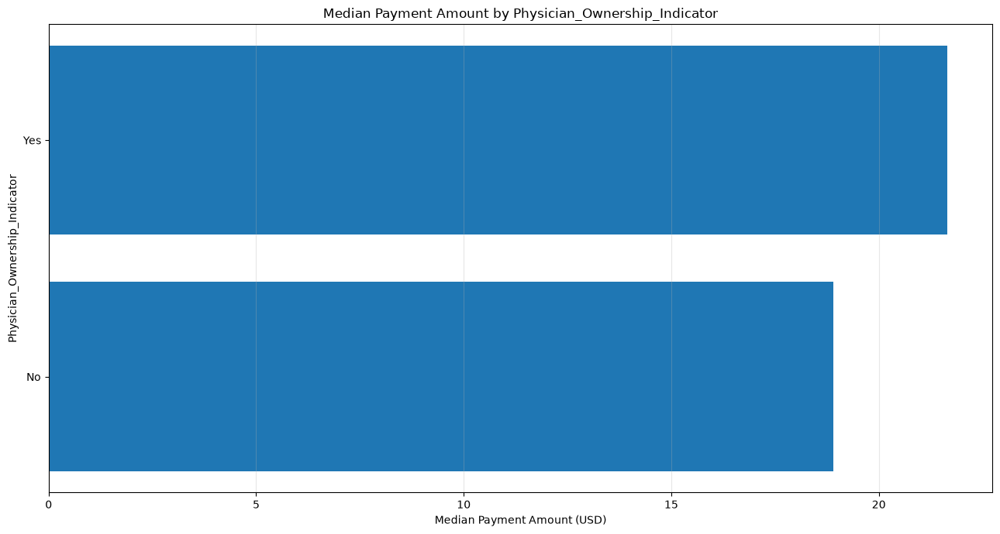

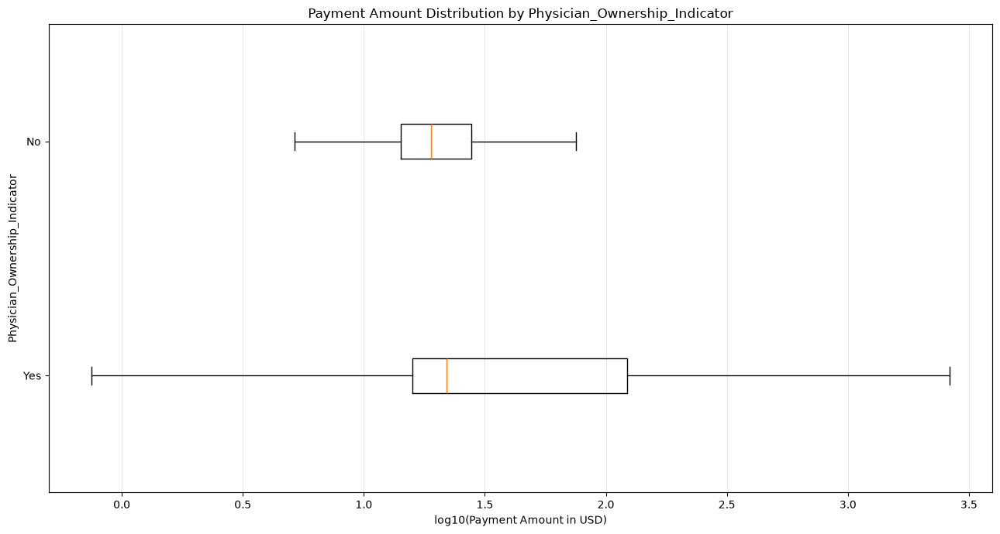


Third_Party_Payment_Recipient_Indicator

Grouped Statistics:
shape: (3, 7)
┌───────────────────────────────┬──────────┬────────┬─────────────┬──────────────┬──────┬──────────┐
│ Third_Party_Payment_Recipient ┆ Count    ┆ Median ┆ Mean        ┆ Std          ┆ Min  ┆ Max      │
│ _…                            ┆ ---      ┆ ---    ┆ ---         ┆ ---          ┆ ---  ┆ ---      │
│ ---                           ┆ u32      ┆ f64    ┆ f64         ┆ f64          ┆ f64  ┆ f64      │
│ str                           ┆          ┆        ┆             ┆              ┆      ┆          │
╞═══════════════════════════════╪══════════╪════════╪═════════════╪══════════════╪══════╪══════════╡
│ Entity                        ┆ 686457   ┆ 881.25 ┆ 3934.078776 ┆ 85013.615794 ┆ 0.01 ┆ 2.6746e7 │
│ Individual                    ┆ 209927   ┆ 24.76  ┆ 706.112295  ┆ 31560.171347 ┆ 0.01 ┆ 1.4e7    │
│ No Third Party Payment        ┆ 86759383 ┆ 18.85  ┆ 240.389767  ┆ 84365.485361 ┆ 0.01 ┆ 4e8      │
└──────────────

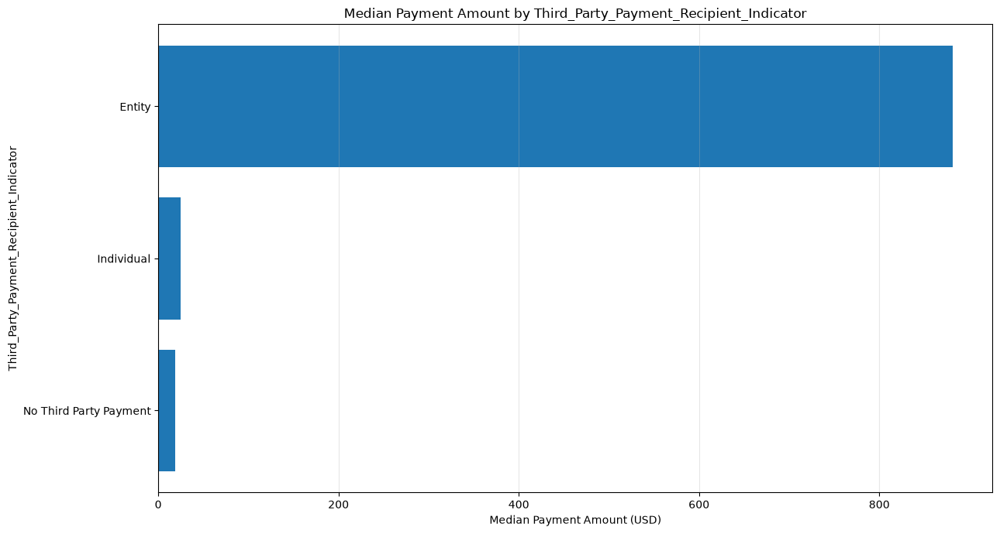

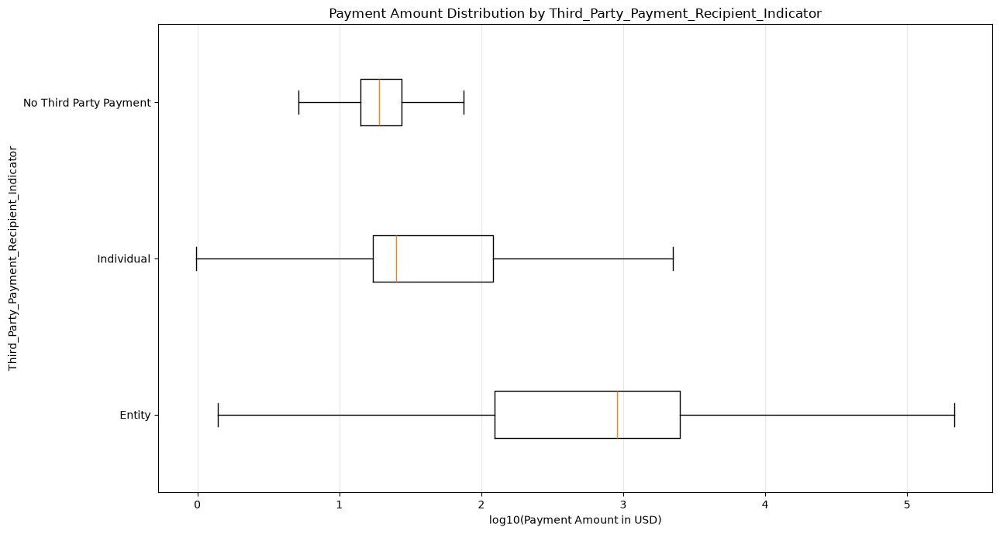


Related_Product_Indicator

Grouped Statistics:
shape: (2, 7)
┌───────────────────────────┬──────────┬────────┬─────────────┬───────────────┬──────┬──────────┐
│ Related_Product_Indicator ┆ Count    ┆ Median ┆ Mean        ┆ Std           ┆ Min  ┆ Max      │
│ ---                       ┆ ---      ┆ ---    ┆ ---         ┆ ---           ┆ ---  ┆ ---      │
│ str                       ┆ u32      ┆ f64    ┆ f64         ┆ f64           ┆ f64  ┆ f64      │
╞═══════════════════════════╪══════════╪════════╪═════════════╪═══════════════╪══════╪══════════╡
│ No                        ┆ 4915143  ┆ 29.74  ┆ 1199.773237 ┆ 247515.055197 ┆ 0.01 ┆ 4e8      │
│ Yes                       ┆ 82740624 ┆ 18.7   ┆ 215.224613  ┆ 62341.497701  ┆ 0.01 ┆ 2.5302e8 │
└───────────────────────────┴──────────┴────────┴─────────────┴───────────────┴──────┴──────────┘


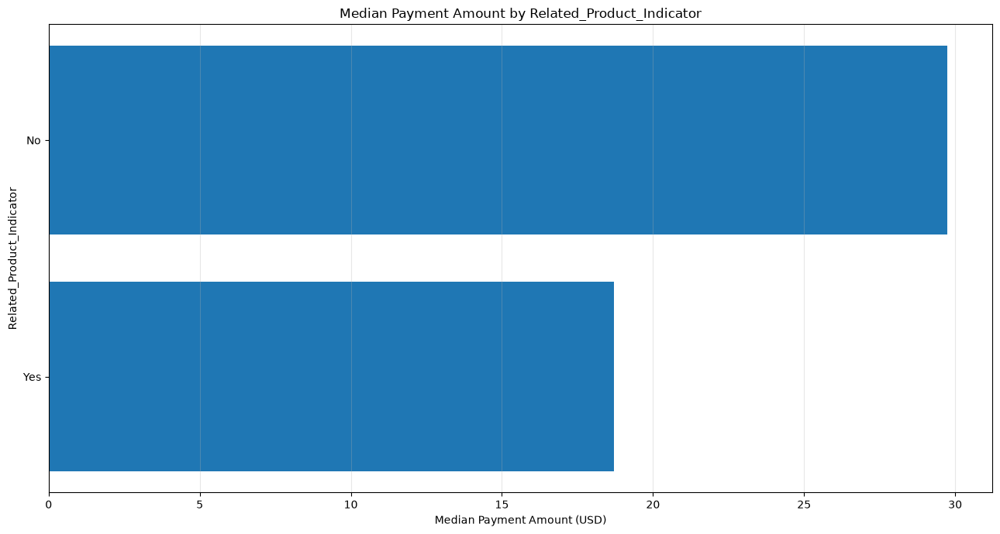

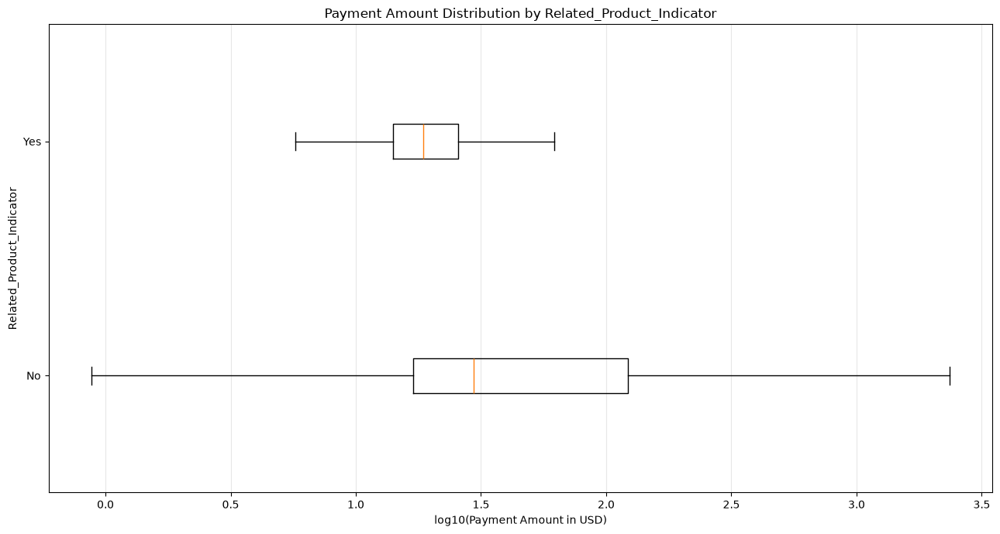


Charity_Indicator

Grouped Statistics:
shape: (2, 7)
┌───────────────────┬──────────┬────────┬─────────────┬──────────────┬──────┬───────────┐
│ Charity_Indicator ┆ Count    ┆ Median ┆ Mean        ┆ Std          ┆ Min  ┆ Max       │
│ ---               ┆ ---      ┆ ---    ┆ ---         ┆ ---          ┆ ---  ┆ ---       │
│ str               ┆ u32      ┆ f64    ┆ f64         ┆ f64          ┆ f64  ┆ f64       │
╞═══════════════════╪══════════╪════════╪═════════════╪══════════════╪══════╪═══════════╡
│ Yes               ┆ 3757     ┆ 1700.0 ┆ 7298.880828 ┆ 64265.26117  ┆ 1.0  ┆ 2641593.5 │
│ No                ┆ 28394083 ┆ 18.26  ┆ 274.88926   ┆ 66149.652734 ┆ 0.01 ┆ 3e8       │
└───────────────────┴──────────┴────────┴─────────────┴──────────────┴──────┴───────────┘


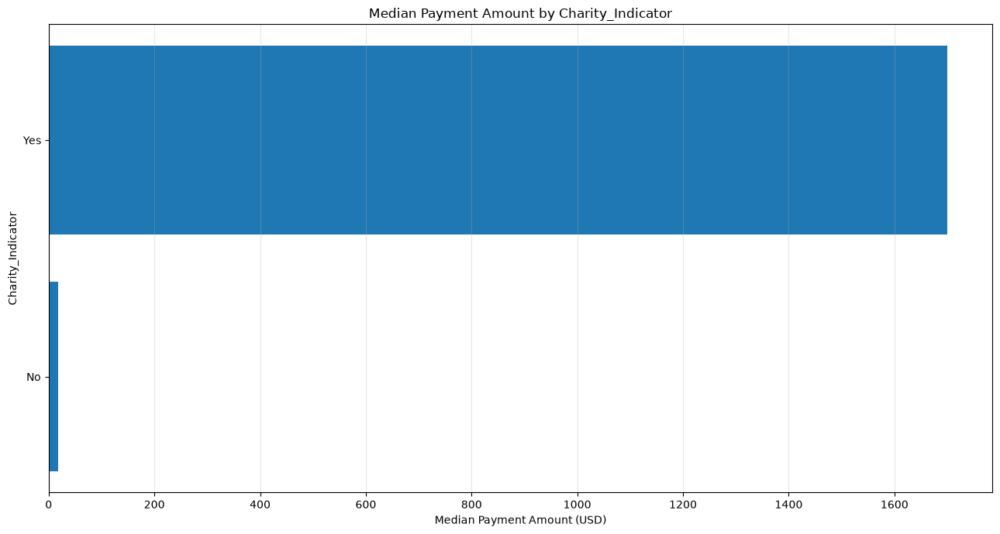

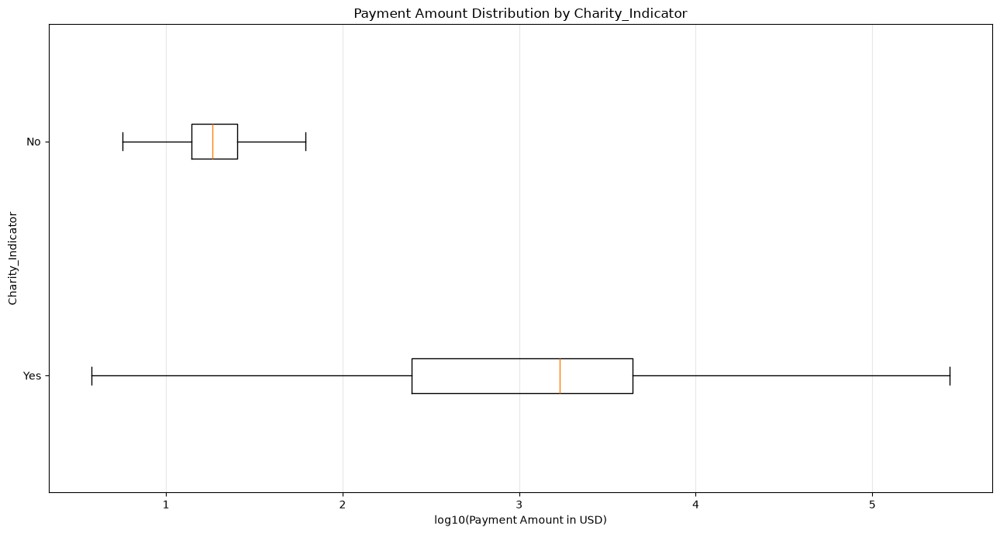


Dispute_Status_for_Publication

Grouped Statistics:
shape: (2, 7)
┌───────────────────────────────┬──────────┬────────┬─────────────┬──────────────┬──────┬──────────┐
│ Dispute_Status_for_Publicatio ┆ Count    ┆ Median ┆ Mean        ┆ Std          ┆ Min  ┆ Max      │
│ n                             ┆ ---      ┆ ---    ┆ ---         ┆ ---          ┆ ---  ┆ ---      │
│ ---                           ┆ u32      ┆ f64    ┆ f64         ┆ f64          ┆ f64  ┆ f64      │
│ str                           ┆          ┆        ┆             ┆              ┆      ┆          │
╞═══════════════════════════════╪══════════╪════════╪═════════════╪══════════════╪══════╪══════════╡
│ Yes                           ┆ 2581     ┆ 127.83 ┆ 4111.647284 ┆ 21375.958416 ┆ 0.83 ┆ 356700.3 │
│ No                            ┆ 87653186 ┆ 18.94  ┆ 270.318339  ┆ 84285.444323 ┆ 0.01 ┆ 4e8      │
└───────────────────────────────┴──────────┴────────┴─────────────┴──────────────┴──────┴──────────┘


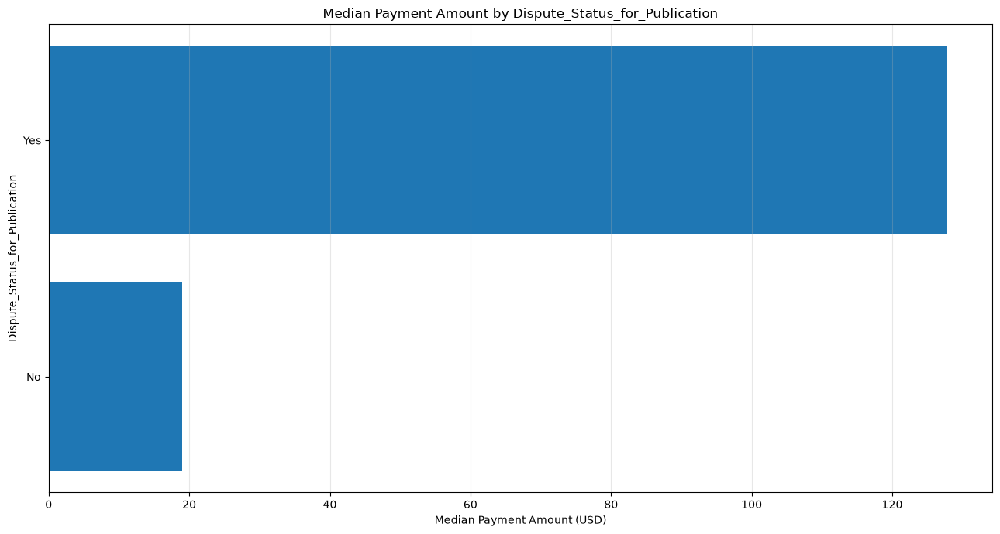

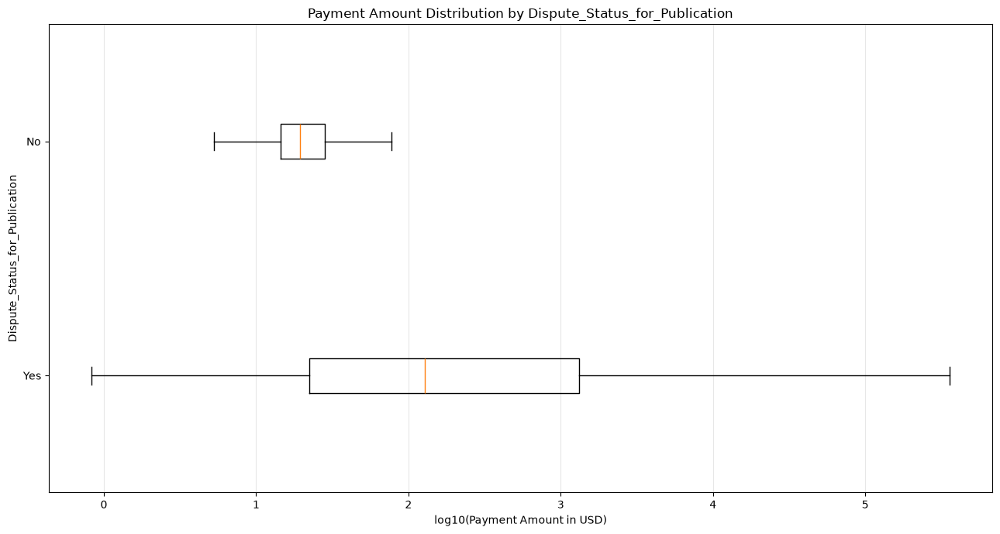


Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1

Grouped Statistics:
shape: (4, 7)
┌────────────────────────────────┬──────────┬────────┬────────────┬──────────────┬──────┬──────────┐
│ Indicate_Drug_or_Biological_or ┆ Count    ┆ Median ┆ Mean       ┆ Std          ┆ Min  ┆ Max      │
│ …                              ┆ ---      ┆ ---    ┆ ---        ┆ ---          ┆ ---  ┆ ---      │
│ ---                            ┆ u32      ┆ f64    ┆ f64        ┆ f64          ┆ f64  ┆ f64      │
│ str                            ┆          ┆        ┆            ┆              ┆      ┆          │
╞════════════════════════════════╪══════════╪════════╪════════════╪══════════════╪══════╪══════════╡
│ Device                         ┆ 17465434 ┆ 25.91  ┆ 469.963927 ┆ 51179.337085 ┆ 0.01 ┆ 1.925e8  │
│ Medical Supply                 ┆ 443430   ┆ 19.92  ┆ 101.042565 ┆ 4933.637442  ┆ 0.09 ┆ 3.124e6  │
│ Biological                     ┆ 13266372 ┆ 18.98  ┆ 189.549641 ┆ 24330.887047 ┆ 0.01 ┆ 1.6067e7

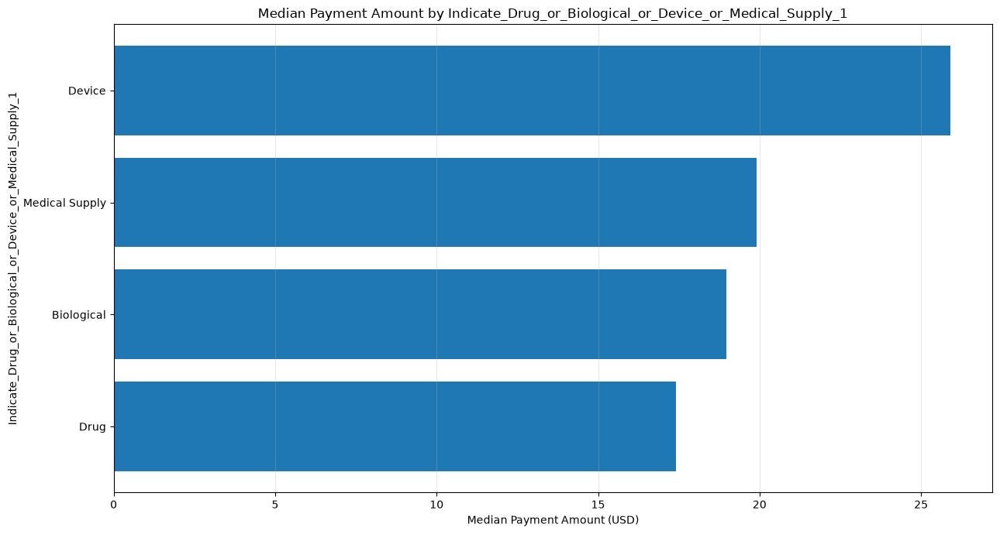

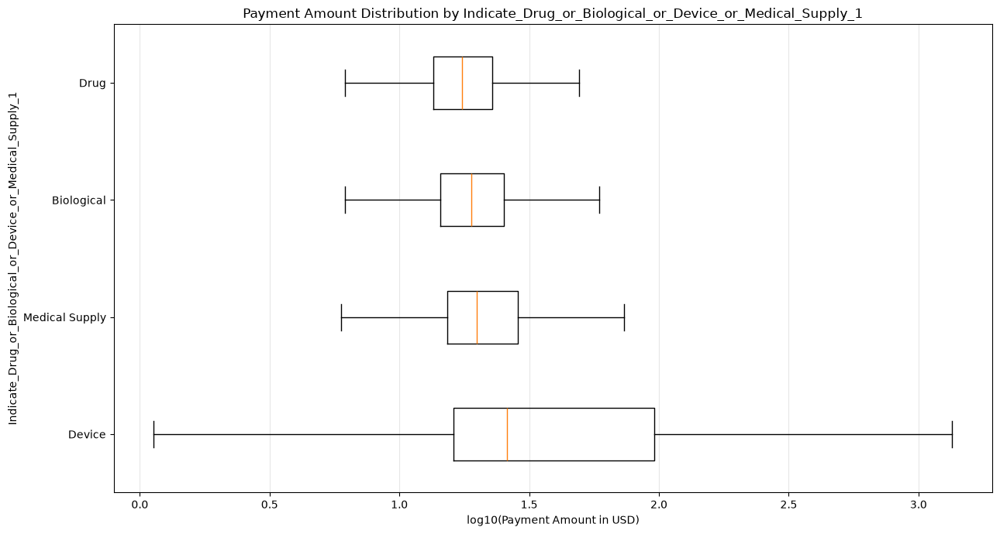


Product_Category_or_Therapeutic_Area_1

Grouped Statistics:
shape: (15, 7)
┌────────────────────────────────┬─────────┬────────┬────────────┬──────────────┬──────┬───────────┐
│ Product_Category_or_Therapeuti ┆ Count   ┆ Median ┆ Mean       ┆ Std          ┆ Min  ┆ Max       │
│ …                              ┆ ---     ┆ ---    ┆ ---        ┆ ---          ┆ ---  ┆ ---       │
│ ---                            ┆ u32     ┆ f64    ┆ f64        ┆ f64          ┆ f64  ┆ f64       │
│ str                            ┆         ┆        ┆            ┆              ┆      ┆           │
╞════════════════════════════════╪═════════╪════════╪════════════╪══════════════╪══════╪═══════════╡
│ Ophthalmology                  ┆ 1189935 ┆ 22.1   ┆ 147.398708 ┆ 7619.116775  ┆ 0.01 ┆ 5.6599e6  │
│ Oncology                       ┆ 2436432 ┆ 20.47  ┆ 285.669025 ┆ 18996.927386 ┆ 0.01 ┆ 1.6e7     │
│ ONCOLOGY                       ┆ 1441792 ┆ 20.42  ┆ 171.495115 ┆ 1255.145942  ┆ 0.01 ┆ 540967.82 │
│ Neurology    

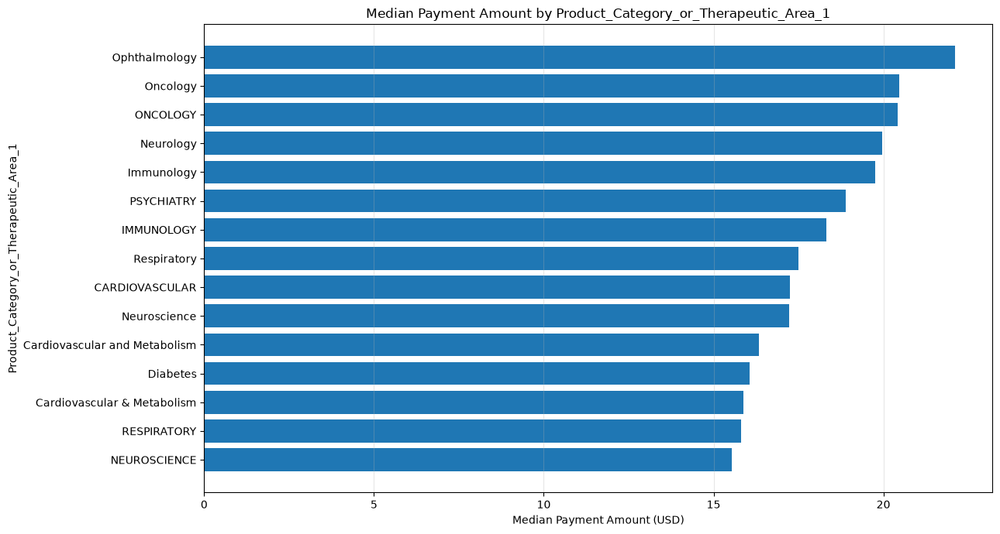

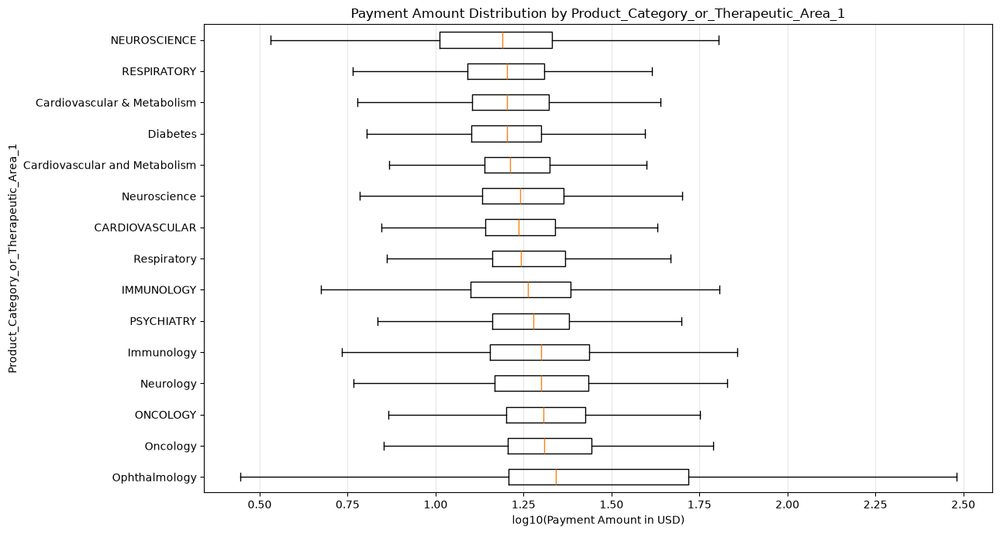


Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2

Grouped Statistics:
shape: (4, 7)
┌──────────────────────────────┬─────────┬────────┬────────────┬───────────────┬──────┬────────────┐
│ Indicate_Drug_or_Biological_ ┆ Count   ┆ Median ┆ Mean       ┆ Std           ┆ Min  ┆ Max        │
│ or…                          ┆ ---     ┆ ---    ┆ ---        ┆ ---           ┆ ---  ┆ ---        │
│ ---                          ┆ u32     ┆ f64    ┆ f64        ┆ f64           ┆ f64  ┆ f64        │
│ str                          ┆         ┆        ┆            ┆               ┆      ┆            │
╞══════════════════════════════╪═════════╪════════╪════════════╪═══════════════╪══════╪════════════╡
│ Device                       ┆ 1911157 ┆ 28.15  ┆ 970.27556  ┆ 144195.325977 ┆ 0.01 ┆ 1.925e8    │
│ Medical Supply               ┆ 55400   ┆ 23.11  ┆ 119.701034 ┆ 1075.56909    ┆ 0.23 ┆ 120000.0   │
│ Biological                   ┆ 3059219 ┆ 17.0   ┆ 37.418563  ┆ 399.164721    ┆ 0.01 ┆ 216810.07 

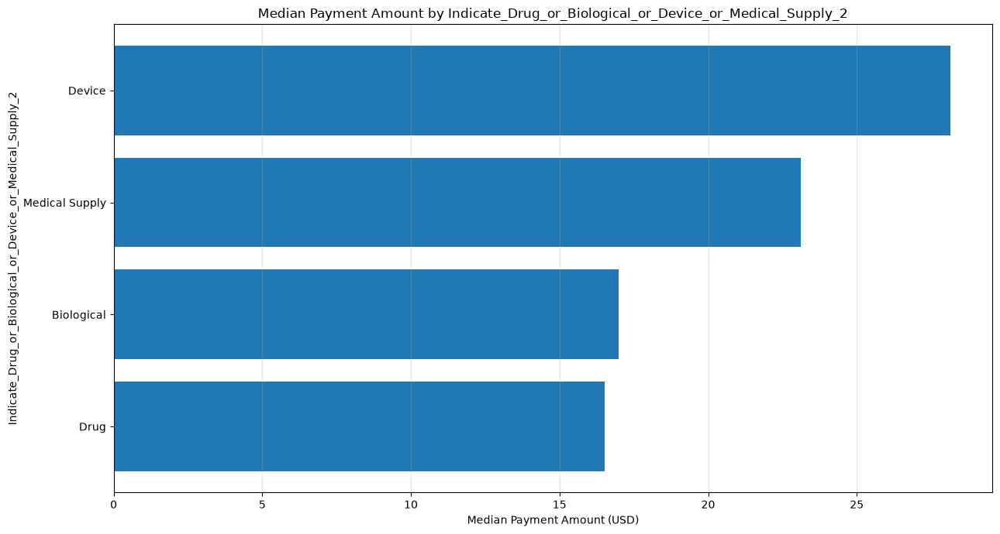

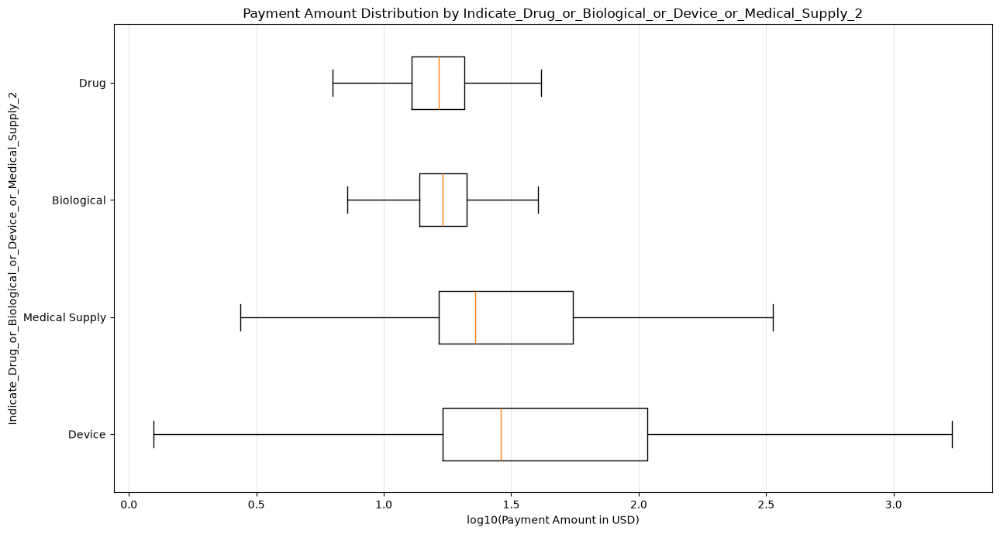


Product_Category_or_Therapeutic_Area_2

Grouped Statistics:
shape: (15, 7)
┌─────────────────────────────────┬─────────┬────────┬───────────┬────────────┬──────┬──────────┐
│ Product_Category_or_Therapeuti… ┆ Count   ┆ Median ┆ Mean      ┆ Std        ┆ Min  ┆ Max      │
│ ---                             ┆ ---     ┆ ---    ┆ ---       ┆ ---        ┆ ---  ┆ ---      │
│ str                             ┆ u32     ┆ f64    ┆ f64       ┆ f64        ┆ f64  ┆ f64      │
╞═════════════════════════════════╪═════════╪════════╪═══════════╪════════════╪══════╪══════════╡
│ CNS                             ┆ 418876  ┆ 20.58  ┆ 121.48516 ┆ 521.927735 ┆ 0.01 ┆ 28500.0  │
│ Oncology                        ┆ 406865  ┆ 19.52  ┆ 69.627218 ┆ 579.520728 ┆ 0.01 ┆ 87699.0  │
│ ONCOLOGY                        ┆ 393173  ┆ 18.55  ┆ 36.109842 ┆ 280.353287 ┆ 0.04 ┆ 50000.0  │
│ Immunology                      ┆ 612252  ┆ 18.43  ┆ 70.857379 ┆ 420.299604 ┆ 0.01 ┆ 30000.0  │
│ IMMUNOLOGY                      ┆ 450967

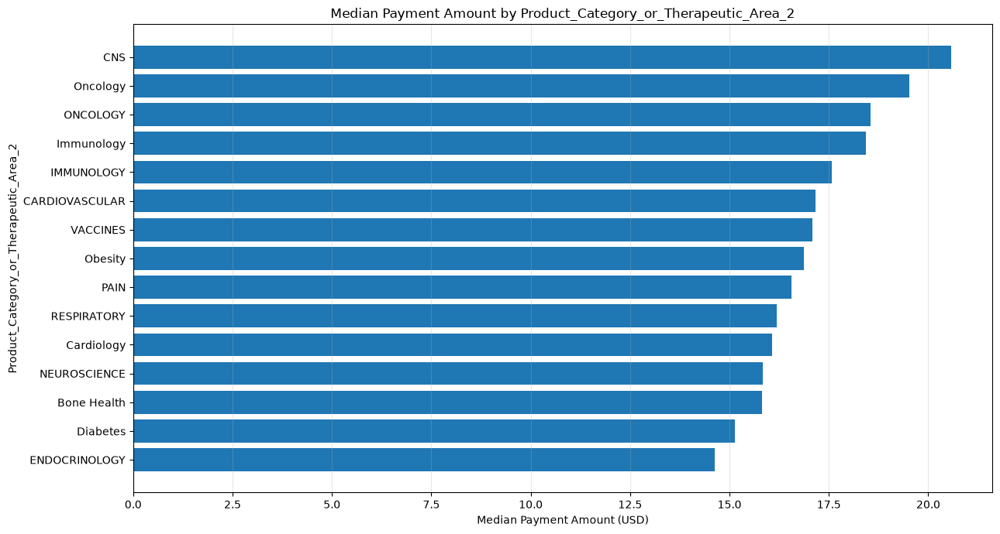

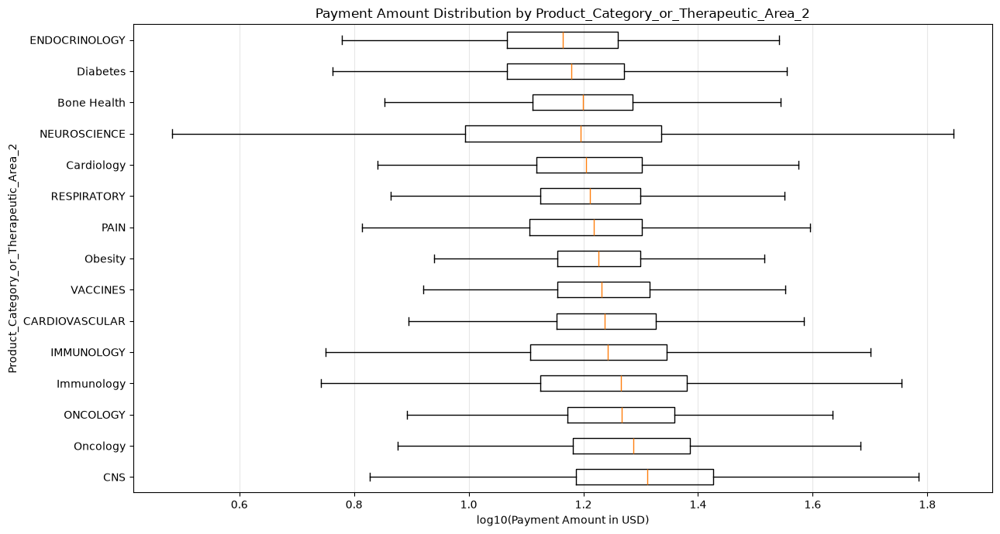


Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State

Grouped Statistics:
shape: (15, 7)
┌────────────────────────────┬──────────┬────────┬────────────┬───────────────┬──────┬─────────────┐
│ Applicable_Manufacturer_or ┆ Count    ┆ Median ┆ Mean       ┆ Std           ┆ Min  ┆ Max         │
│ _App…                      ┆ ---      ┆ ---    ┆ ---        ┆ ---           ┆ ---  ┆ ---         │
│ ---                        ┆ u32      ┆ f64    ┆ f64        ┆ f64           ┆ f64  ┆ f64         │
│ str                        ┆          ┆        ┆            ┆               ┆      ┆             │
╞════════════════════════════╪══════════╪════════╪════════════╪═══════════════╪══════╪═════════════╡
│ MI                         ┆ 1213763  ┆ 35.42  ┆ 717.925845 ┆ 34542.68401   ┆ 0.01 ┆ 3.1047764e7 │
│ FL                         ┆ 1393519  ┆ 25.53  ┆ 781.045257 ┆ 35968.233324  ┆ 0.01 ┆ 1.5681401e7 │
│ MN                         ┆ 2834027  ┆ 25.0   ┆ 410.774319 ┆ 25675.680321  ┆ 0.01 ┆ 2e7  

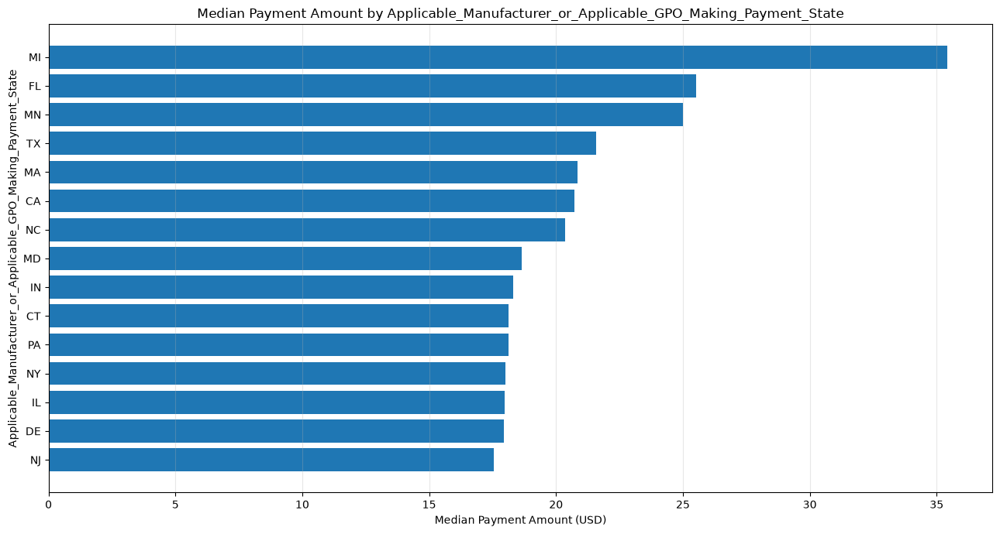

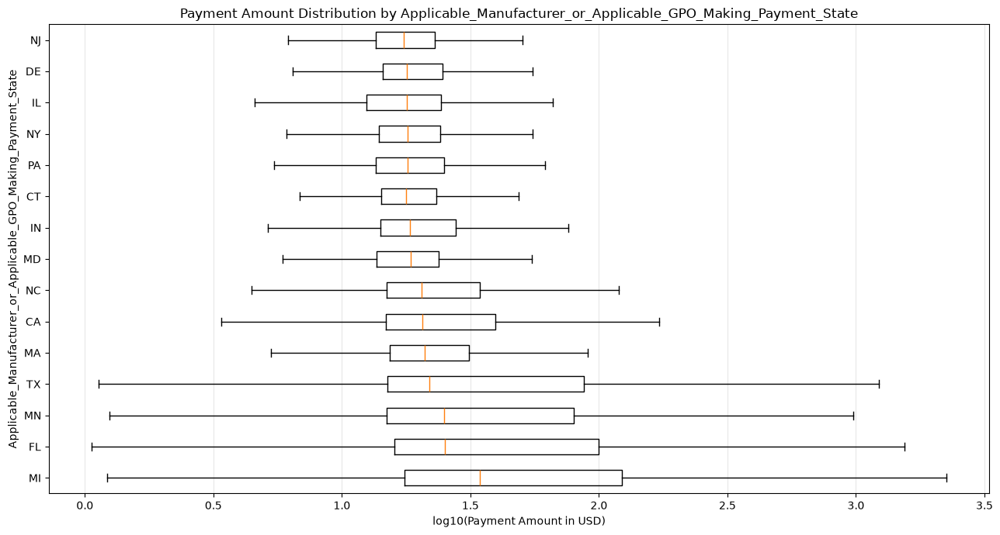


Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country

Grouped Statistics:
shape: (10, 7)
┌───────────────────────────┬──────────┬─────────┬──────────────┬───────────────┬──────┬───────────┐
│ Applicable_Manufacturer_o ┆ Count    ┆ Median  ┆ Mean         ┆ Std           ┆ Min  ┆ Max       │
│ r_App…                    ┆ ---      ┆ ---     ┆ ---          ┆ ---           ┆ ---  ┆ ---       │
│ ---                       ┆ u32      ┆ f64     ┆ f64          ┆ f64           ┆ f64  ┆ f64       │
│ str                       ┆          ┆         ┆              ┆               ┆      ┆           │
╞═══════════════════════════╪══════════╪═════════╪══════════════╪═══════════════╪══════╪═══════════╡
│ Japan                     ┆ 7653     ┆ 550.0   ┆ 3289.48225   ┆ 38781.665142  ┆ 0.01 ┆ 1.74999e6 │
│ Denmark                   ┆ 10392    ┆ 447.145 ┆ 8147.43676   ┆ 541562.054371 ┆ 0.43 ┆ 5.5070e7  │
│ Switzerland               ┆ 36820    ┆ 426.16  ┆ 1762.171699  ┆ 10788.161331  ┆ 0.2  ┆ 1

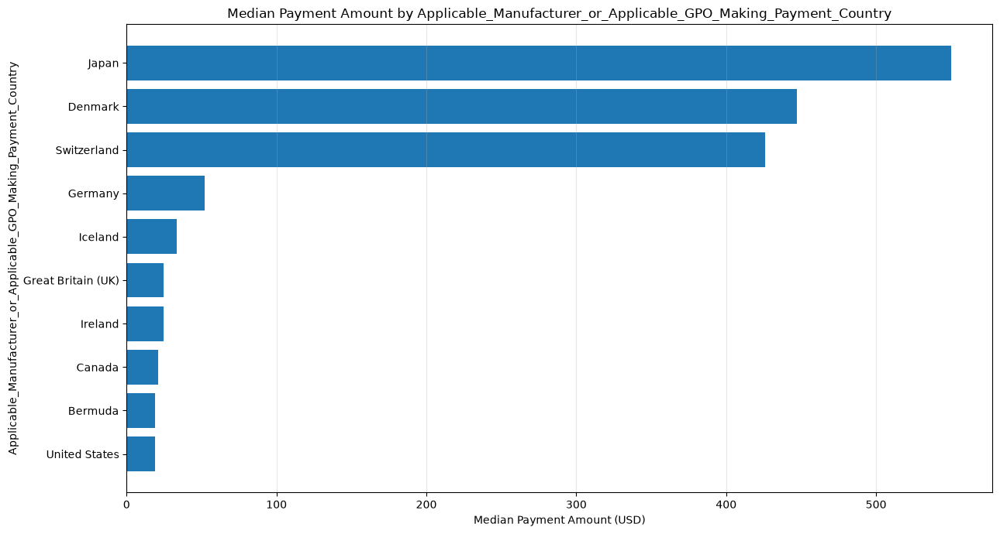

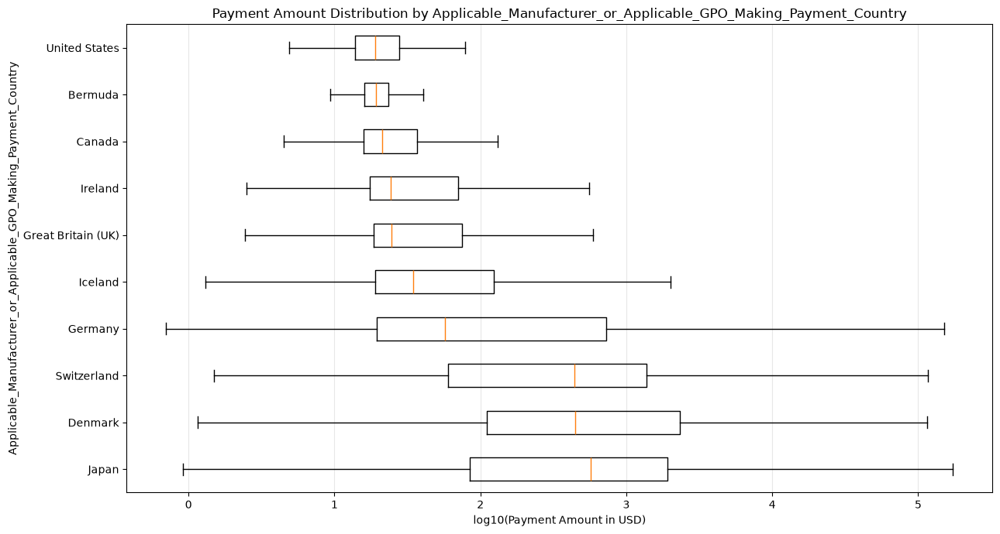


State_of_Travel

Grouped Statistics:
shape: (15, 7)
┌─────────────────┬──────────┬────────┬────────────┬──────────────┬──────┬───────────┐
│ State_of_Travel ┆ Count    ┆ Median ┆ Mean       ┆ Std          ┆ Min  ┆ Max       │
│ ---             ┆ ---      ┆ ---    ┆ ---        ┆ ---          ┆ ---  ┆ ---       │
│ str             ┆ u32      ┆ f64    ┆ f64        ┆ f64          ┆ f64  ┆ f64       │
╞═════════════════╪══════════╪════════╪════════════╪══════════════╪══════╪═══════════╡
│ FL              ┆ 394163   ┆ 207.92 ┆ 286.839697 ┆ 369.745166   ┆ 0.01 ┆ 20250.0   │
│ TN              ┆ 99177    ┆ 203.88 ┆ 294.823781 ┆ 375.884667   ┆ 0.01 ┆ 17271.0   │
│ MA              ┆ 91056    ┆ 202.3  ┆ 319.748535 ┆ 579.233185   ┆ 0.01 ┆ 81015.0   │
│ AZ              ┆ 99497    ┆ 198.97 ┆ 290.64753  ┆ 555.09009    ┆ 0.01 ┆ 128222.99 │
│ NY              ┆ 128971   ┆ 197.74 ┆ 336.040555 ┆ 677.511286   ┆ 0.01 ┆ 48222.95  │
│ …               ┆ …        ┆ …      ┆ …          ┆ …            ┆ …    ┆ … 

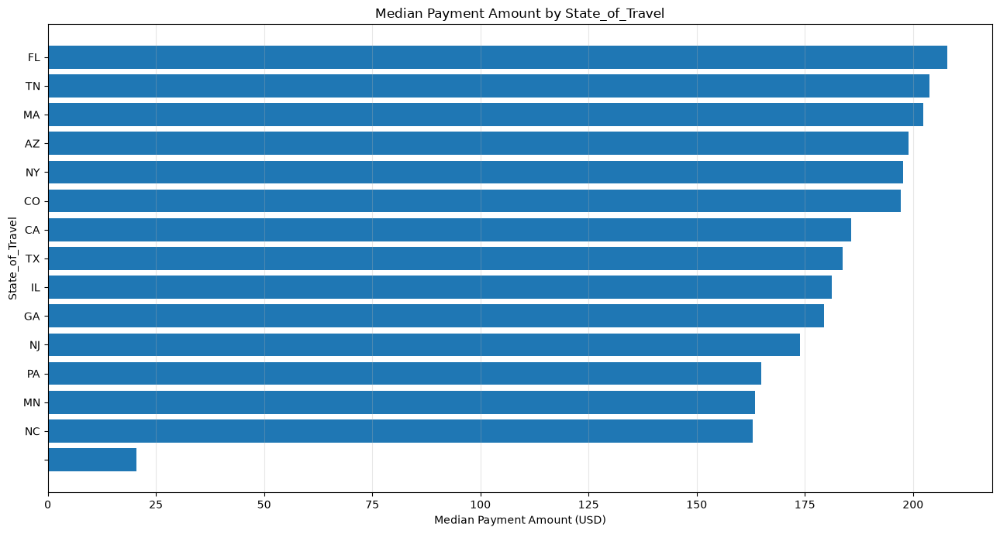

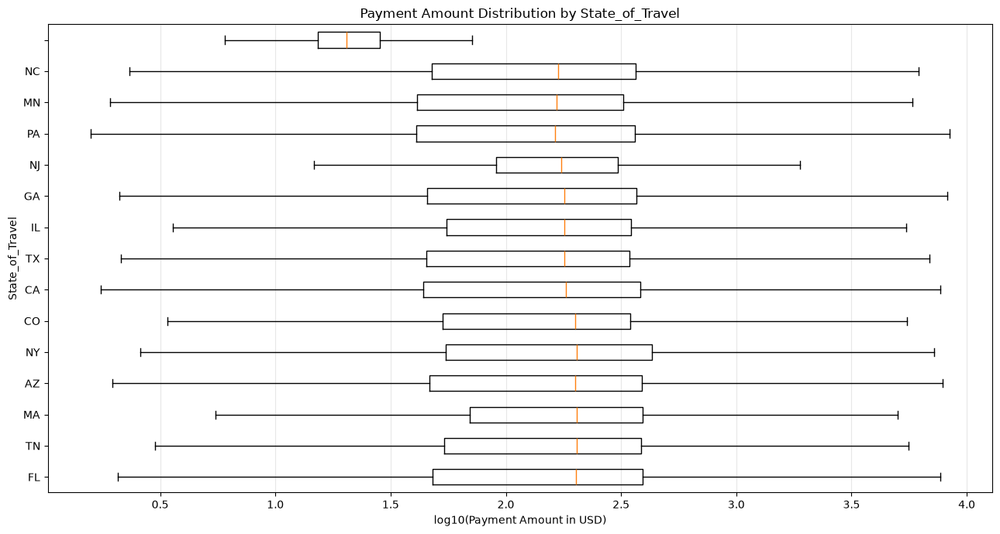


Recipient_City

Grouped Statistics:
shape: (15, 7)
┌────────────────┬─────────┬────────┬─────────────┬───────────────┬──────┬───────────┐
│ Recipient_City ┆ Count   ┆ Median ┆ Mean        ┆ Std           ┆ Min  ┆ Max       │
│ ---            ┆ ---     ┆ ---    ┆ ---         ┆ ---           ┆ ---  ┆ ---       │
│ str            ┆ u32     ┆ f64    ┆ f64         ┆ f64           ┆ f64  ┆ f64       │
╞════════════════╪═════════╪════════╪═════════════╪═══════════════╪══════╪═══════════╡
│ LOS ANGELES    ┆ 539184  ┆ 25.7   ┆ 576.405761  ┆ 24434.23136   ┆ 0.01 ┆ 1.3626e7  │
│ CHICAGO        ┆ 593000  ┆ 24.26  ┆ 400.579755  ┆ 8287.640559   ┆ 0.01 ┆ 4.5262e6  │
│ NEW YORK       ┆ 1047946 ┆ 24.05  ┆ 572.26081   ┆ 16702.645278  ┆ 0.01 ┆ 1.0263e7  │
│ PHILADELPHIA   ┆ 486786  ┆ 22.33  ┆ 3795.336191 ┆ 721810.749938 ┆ 0.01 ┆ 2.5302e8  │
│ MIAMI          ┆ 504300  ┆ 22.07  ┆ 247.606372  ┆ 6579.182935   ┆ 0.01 ┆ 3.37075e6 │
│ …              ┆ …       ┆ …      ┆ …           ┆ …             ┆ …    ┆ …  

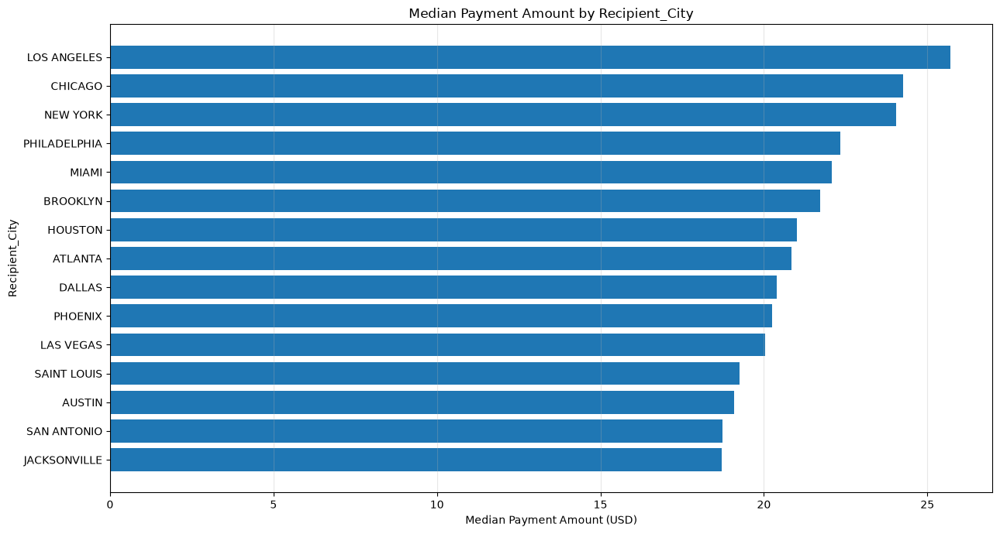

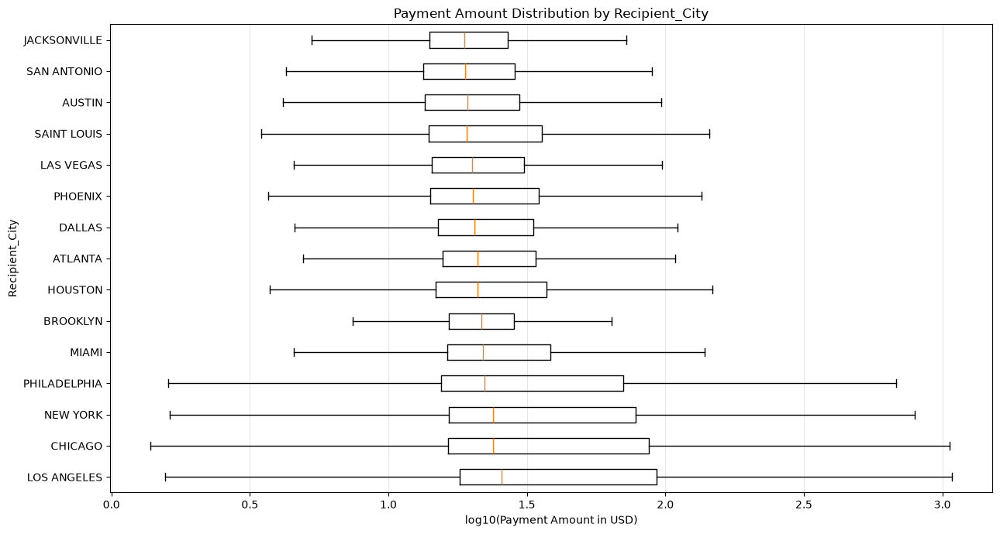


City_of_Travel

Grouped Statistics:
shape: (15, 7)
┌────────────────┬──────────┬─────────┬────────────┬──────────────┬──────┬──────────┐
│ City_of_Travel ┆ Count    ┆ Median  ┆ Mean       ┆ Std          ┆ Min  ┆ Max      │
│ ---            ┆ ---      ┆ ---     ┆ ---        ┆ ---          ┆ ---  ┆ ---      │
│ str            ┆ u32      ┆ f64     ┆ f64        ┆ f64          ┆ f64  ┆ f64      │
╞════════════════╪══════════╪═════════╪════════════╪══════════════╪══════╪══════════╡
│ Naples         ┆ 40247    ┆ 244.2   ┆ 310.612088 ┆ 290.767333   ┆ 0.21 ┆ 18977.26 │
│ Denver         ┆ 41472    ┆ 230.34  ┆ 275.569989 ┆ 333.417711   ┆ 0.3  ┆ 12156.57 │
│ Dallas         ┆ 75008    ┆ 222.605 ┆ 282.179642 ┆ 359.809802   ┆ 0.01 ┆ 29825.77 │
│ Nashville      ┆ 38783    ┆ 222.21  ┆ 289.219368 ┆ 330.95007    ┆ 0.41 ┆ 12250.0  │
│ DALLAS         ┆ 52044    ┆ 195.7   ┆ 267.513663 ┆ 381.288334   ┆ 0.02 ┆ 21585.27 │
│ …              ┆ …        ┆ …       ┆ …          ┆ …            ┆ …    ┆ …        │
│ 

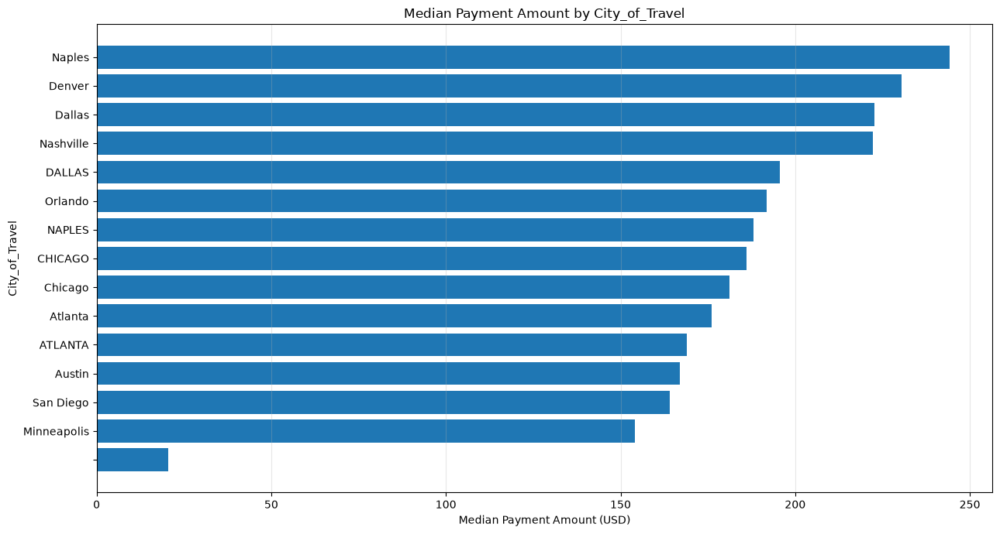

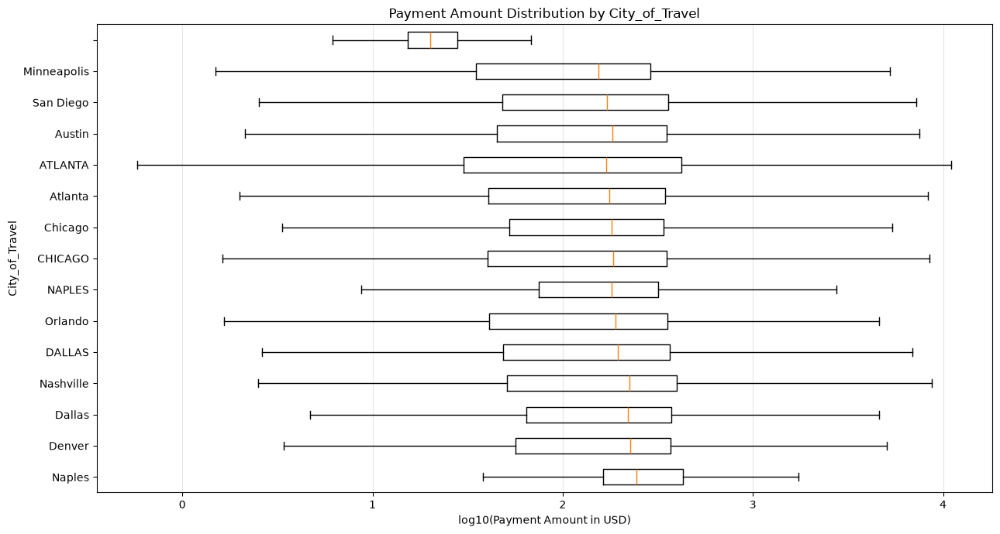

In [51]:
# BIVARIATE ANALYSIS — CATEGORICAL ↔ NUMERICAL

payment_col = "Total_Amount_of_Payment_USDollars"

categorical_columns = [
    "Covered_Recipient_Type",
    "Recipient_State",
    "Form_of_Payment_or_Transfer_of_Value",
    "Nature_of_Payment_or_Transfer_of_Value",
    "Physician_Ownership_Indicator",
    "Third_Party_Payment_Recipient_Indicator",
    "Related_Product_Indicator",
    "Charity_Indicator",
    "Dispute_Status_for_Publication",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    "Product_Category_or_Therapeutic_Area_1",
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2",
    "Product_Category_or_Therapeutic_Area_2",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State",
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country",
    "State_of_Travel",
    "Recipient_City",
    "City_of_Travel"
]

top_n = {
    "Recipient_State": 15,
    "Recipient_City": 15,
    "City_of_Travel": 15,
    "State_of_Travel": 15,
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State": 15,
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country": 10,
    "Nature_of_Payment_or_Transfer_of_Value": 10,
    "Product_Category_or_Therapeutic_Area_1": 15,
    "Product_Category_or_Therapeutic_Area_2": 15,
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1": 15,
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2": 15
}

for category_col in categorical_columns:

    print(f"\n{category_col}")

    data = (
        lf
        .select([
            pl.col(category_col),
            pl.col(payment_col)
        ])
        .filter(
            pl.col(category_col).is_not_null() &
            pl.col(payment_col).is_not_null() &
            (pl.col(payment_col) > 0)
        )
    )

    if category_col in top_n:

        n = top_n[category_col]

        categories = (
            data
            .group_by(category_col)
            .agg(pl.len().alias("count"))
            .sort("count", descending=True)
            .limit(n)
            .collect()
            [category_col]
            .to_list()
        )

        data = data.filter(
            pl.col(category_col).is_in(categories)
        )

    stats = (
        data
        .group_by(category_col)
        .agg([
            pl.len().alias("Count"),
            pl.col(payment_col).median().alias("Median"),
            pl.col(payment_col).mean().alias("Mean"),
            pl.col(payment_col).std().alias("Std"),
            pl.col(payment_col).min().alias("Min"),
            pl.col(payment_col).max().alias("Max")
        ])
        .sort("Median", descending=True)
        .collect()
    )

    print("\nGrouped Statistics:")
    print(stats)

    categories_plot = (
        stats[category_col]
        .cast(pl.String)
        .to_list()
    )

    medians = stats["Median"].to_list()

    # Median bar chart
    plt.figure(figsize=(13, 7))

    plt.barh(
        categories_plot[::-1],
        medians[::-1]
    )

    plt.xlabel("Median Payment Amount (USD)")
    plt.ylabel(category_col)
    plt.title(
        f"Median Payment Amount by {category_col}"
    )

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Collect data for box plot
    plot_data = (
        data
        .select([
            pl.col(category_col),
            pl.col(payment_col)
        ])
        .collect()
    )

    box_data = []
    box_labels = []

    for category in categories_plot:

        values = (
            plot_data
            .filter(
                pl.col(category_col).cast(pl.String) == category
            )
            .get_column(payment_col)
            .to_numpy()
        )

        if len(values) > 5000:

            rng = np.random.default_rng(42)

            values = rng.choice(
                values,
                size=5000,
                replace=False
            )

        if len(values) > 0:

            box_data.append(
                np.log10(values)
            )

            box_labels.append(category)

    # Box plot
    plt.figure(figsize=(13, 7))

    plt.boxplot(
        box_data,
        vert=False,
        tick_labels=box_labels,
        showfliers=False
    )

    plt.xlabel("log10(Payment Amount in USD)")
    plt.ylabel(category_col)
    plt.title(
        f"Payment Amount Distribution by {category_col}"
    )

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Bivariate Analysis — Categorical ↔ Numerical

The relationship between categorical variables and `Total_Amount_of_Payment_USDollars` was examined using median payment bar charts and box plots. Since payment amounts are highly right-skewed, box plots were displayed on a `log10` scale, while median payment amounts were shown in their original USD scale.

### `State_of_Travel`

- Payment distributions across the major travel states show substantial overlap.
- Most states have similar median payment amounts, generally around the $160–$210 range.
- `FL`, `TN`, and `MA` have relatively higher median payments, while `NC`, `MN`, and `PA` have relatively lower medians among the displayed states.
- The box plots show considerable variation within each state, indicating that travel location alone does not determine the payment amount.
- Overall, `State_of_Travel` shows relatively moderate differences in payment amounts between categories.

### `Third_Party_Payment_Recipient_Indicator`

- There is a pronounced difference in payment distributions between the three categories: `Entity`, `Individual`, and `No Third Party Payment`.
- `Entity` has a substantially higher median payment than the other two categories.
- The median payment for `Entity` is approximately $880, compared with roughly $20–$25 for `Individual` and `No Third Party Payment`.
- The box plot also shows a much wider payment distribution for `Entity`.
- This indicates a strong association between the type of third-party recipient and payment amount.
- The large difference suggests that payments involving entities represent substantially different transaction structures from payments made directly to individuals or without a third-party recipient.

### `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2`

- Payment amounts differ across `Drug`, `Biological`, `Medical Supply`, and `Device`.
- `Device` has the highest median payment, at approximately $28.
- `Medical Supply` follows with a median around $23.
- `Biological` and `Drug` have lower median payments, approximately $17 and $16 respectively.
- The box plot shows that `Device` payments also have a considerably wider distribution.
- Therefore, the type of medical product associated with the payment is related to differences in both typical payment size and payment variability.

### `Nature_of_Payment_or_Transfer_of_Value`

- This variable shows one of the clearest differences in payment amounts among the categorical variables analyzed.
- `Royalty or License` has a substantially higher median payment than the other payment types, exceeding $4,000.
- `Honoraria`, compensation for services, and consulting-related payments also have relatively high median amounts.
- `Travel and Lodging`, `Gift`, `Education`, and especially `Food and Beverage` have much smaller median payments.
- The box plots demonstrate that the distributions are also different in spread, not merely in their medians.
- This indicates that the purpose or nature of a payment is strongly associated with its monetary value.
- The large differences are consistent with these categories representing fundamentally different types of transfers of value.

### `Physician_Ownership_Indicator`

- The median payment amounts for `Yes` and `No` are relatively close.
- The median for `Yes` is approximately $22, while the median for `No` is approximately $19.
- Despite the similar medians, the box plot shows that the `Yes` category has a substantially wider distribution.
- This indicates that ownership status is associated with greater variability in payment amounts, even though the typical payment is relatively similar.
- Therefore, examining only the median would not fully capture the difference between the two groups.

### `Product_Category_or_Therapeutic_Area_1`

- Payment amounts vary across the different therapeutic areas.
- `Ophthalmology` has the highest median payment among the displayed categories.
- `Oncology`, `Neurology`, and `Immunology` also show relatively high median payments.
- `Neuroscience`, `Respiratory`, and some cardiovascular categories have somewhat lower median values.
- The box plots show considerable overlap between many therapeutic areas, indicating that the differences are not completely separated.
- A major data-quality issue is visible in the category names: several therapeutic areas occur with inconsistent capitalization, such as `Oncology` and `ONCOLOGY`, `Immunology` and `IMMUNOLOGY`, and `Neuroscience` and `NEUROSCIENCE`.
- These capitalization differences cause the same conceptual therapeutic area to appear as separate categories and should be standardized before further analysis.

### `Product_Category_or_Therapeutic_Area_2`

- The second product-category field also shows differences in median payment amounts.
- `CNS` has the highest median among the displayed categories.
- `Oncology`, `Immunology`, and `Cardiovascular` also have relatively high median payments.
- `Endocrinology` and `Diabetes` have comparatively lower medians.
- The box plots show overlapping distributions across most categories, although some categories have noticeably wider ranges.
- Similar capitalization inconsistencies are present, including `Oncology`/`ONCOLOGY`, `Immunology`/`IMMUNOLOGY`, and `Neuroscience`/`NEUROSCIENCE`.
- These inconsistencies should be normalized because they artificially split a single therapeutic category into multiple groups.

### `Recipient_City`

- The analysis used the most frequent recipient cities rather than every city because the variable has high cardinality.
- The displayed cities show relatively similar median payment amounts compared with variables such as payment nature or third-party recipient type.
- `Los Angeles`, `Chicago`, and `New York` have relatively higher median payments.
- `Jacksonville` and `San Antonio` have relatively lower medians among the displayed cities.
- The box plots show substantial overlap between cities, indicating that city alone does not strongly separate payment distributions.
- Therefore, recipient city appears to have a moderate association with payment amount rather than a dominant one.

### `Recipient_State`

- The major recipient states show relatively similar payment distributions.
- `California` has the highest median among the displayed states, followed by `New York`, `Illinois`, and `Florida`.
- `New Jersey` has the lowest median among the displayed states.
- Despite these differences in median payment, the box plots show considerable overlap between states.
- This suggests that the recipient's state is associated with some variation in payment amount, but it does not produce strong separation between payment distributions.
- The results are broadly similar to the `State_of_Travel` analysis, although these two variables represent different geographic concepts.

### `Related_Product_Indicator`

- A noticeable difference exists between `Yes` and `No`.
- The `No` category has a median payment of approximately $30, while `Yes` has a median of approximately $19.
- The `No` category also has a substantially wider payment distribution in the box plot.
- This indicates an association between whether a payment is related to a product and the amount of the payment.
- However, this is an observed association and does not establish that product relationship itself causes the difference in payment amount.

### Overall Observations

- The categorical variables do not all have the same strength of relationship with payment amount.
- `Nature_of_Payment_or_Transfer_of_Value` and `Third_Party_Payment_Recipient_Indicator` show particularly large differences between categories.
- Product type and therapeutic-area variables also show meaningful differences in median payments.
- Geographic variables such as `Recipient_State`, `Recipient_City`, and `State_of_Travel` generally show smaller differences and substantial overlap between categories.
- `Physician_Ownership_Indicator` has relatively similar medians but noticeably different distributional spreads.
- Because payment amounts are strongly right-skewed, the median provides a more robust measure of the typical payment than the mean.
- The box plots provide additional information about the spread of payments that cannot be observed from the median bar charts alone.
- Several therapeutic-area variables contain capitalization inconsistencies. Standardizing these category labels is an important data-cleaning step before performing further statistical analysis or machine-learning modeling.
- Overall, the analysis indicates that **the characteristics and nature of the transaction are more strongly associated with payment amount than the geographic location of the recipient or travel activity**.


Nature_of_Payment_or_Transfer_of_Value × Form_of_Payment_or_Transfer_of_Value

Cross-tabulation — Counts:
shape: (11, 7)
┌───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────┐
│ Nature_of_Pay ┆ In-kind   ┆ Cash or cash  ┆ Stock option ┆ Dividend,     ┆ Stock, stock  ┆ Stock │
│ ment_or_Trans ┆ items and ┆ equivalent    ┆ ---          ┆ profit or     ┆ option, or    ┆ ---   │
│ fer_…         ┆ services  ┆ ---           ┆ i64          ┆ other retu…   ┆ any ot…       ┆ i64   │
│ ---           ┆ ---       ┆ i64           ┆              ┆ ---           ┆ ---           ┆       │
│ str           ┆ i64       ┆               ┆              ┆ i64           ┆ i64           ┆       │
╞═══════════════╪═══════════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════╡
│ Food and      ┆ 71668993  ┆ 7831568       ┆ 41           ┆ 2             ┆ 4             ┆ 12    │
│ Beverage      ┆           ┆               ┆              ┆          

/home/me/prog/EDA/OpenPaymentsData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


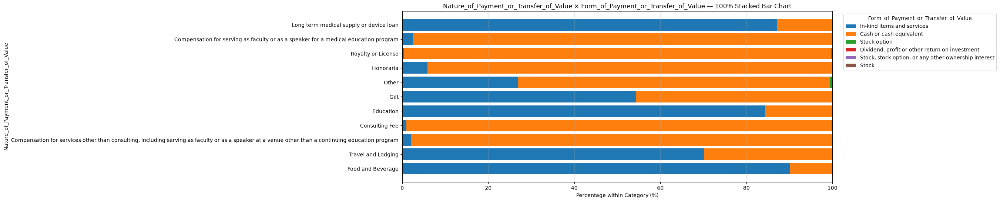


Nature_of_Payment_or_Transfer_of_Value × Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1

Cross-tabulation — Counts:
shape: (11, 5)
┌─────────────────────────────────┬──────────┬──────────┬────────────┬────────────────┐
│ Nature_of_Payment_or_Transfer_… ┆ Drug     ┆ Device   ┆ Biological ┆ Medical Supply │
│ ---                             ┆ ---      ┆ ---      ┆ ---        ┆ ---            │
│ str                             ┆ i64      ┆ i64      ┆ i64        ┆ i64            │
╞═════════════════════════════════╪══════════╪══════════╪════════════╪════════════════╡
│ Food and Beverage               ┆ 47467157 ┆ 14561055 ┆ 12453737   ┆ 404845         │
│ Travel and Lodging              ┆ 847432   ┆ 1531446  ┆ 312604     ┆ 12021          │
│ Compensation for services othe… ┆ 862870   ┆ 263996   ┆ 271559     ┆ 1929           │
│ Education                       ┆ 412079   ┆ 258818   ┆ 99911      ┆ 732            │
│ Consulting Fee                  ┆ 212444   ┆ 440623   ┆ 100705 

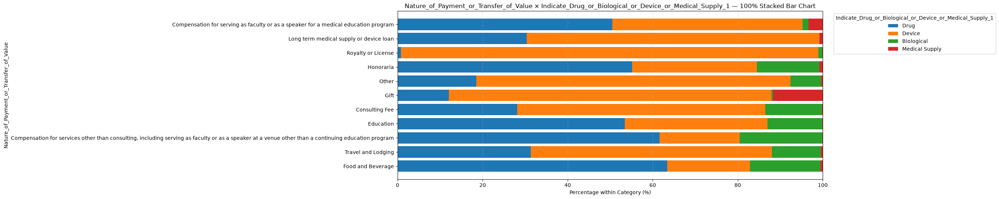


Product_Category_or_Therapeutic_Area_1 × Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1

Cross-tabulation — Counts:
shape: (11, 5)
┌─────────────────────────────────┬──────────┬──────────┬────────────┬────────────────┐
│ Product_Category_or_Therapeuti… ┆ Drug     ┆ Device   ┆ Biological ┆ Medical Supply │
│ ---                             ┆ ---      ┆ ---      ┆ ---        ┆ ---            │
│ str                             ┆ i64      ┆ i64      ┆ i64        ┆ i64            │
╞═════════════════════════════════╪══════════╪══════════╪════════════╪════════════════╡
│ Other                           ┆ 30804485 ┆ 16966587 ┆ 6721727    ┆ 428417         │
│ NEUROSCIENCE                    ┆ 4973962  ┆ 0        ┆ 98351      ┆ 0              │
│ Diabetes                        ┆ 3852229  ┆ 22763    ┆ 0          ┆ 0              │
│ Immunology                      ┆ 1844821  ┆ 239      ┆ 1695013    ┆ 1              │
│ IMMUNOLOGY                      ┆ 226496   ┆ 0        ┆ 2996682

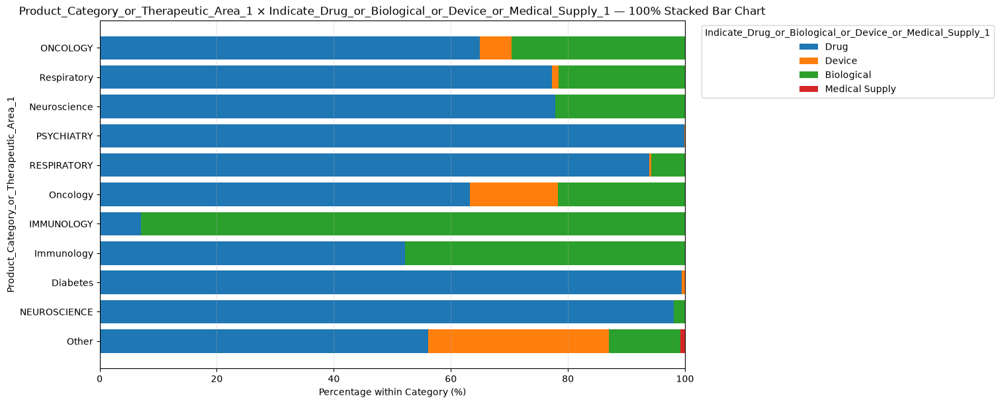


Product_Category_or_Therapeutic_Area_2 × Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2

Cross-tabulation — Counts:
shape: (11, 5)
┌─────────────────────────────────┬─────────┬────────────┬─────────┬────────────────┐
│ Product_Category_or_Therapeuti… ┆ Drug    ┆ Biological ┆ Device  ┆ Medical Supply │
│ ---                             ┆ ---     ┆ ---        ┆ ---     ┆ ---            │
│ str                             ┆ i64     ┆ i64        ┆ i64     ┆ i64            │
╞═════════════════════════════════╪═════════╪════════════╪═════════╪════════════════╡
│ Other                           ┆ 5227553 ┆ 1110369    ┆ 1894121 ┆ 55400          │
│ Diabetes                        ┆ 2014497 ┆ 0          ┆ 6       ┆ 0              │
│ Immunology                      ┆ 150662  ┆ 461553     ┆ 37      ┆ 0              │
│ NEUROSCIENCE                    ┆ 588047  ┆ 4011       ┆ 0       ┆ 0              │
│ Cardiology                      ┆ 105877  ┆ 474910     ┆ 5141    ┆ 0             

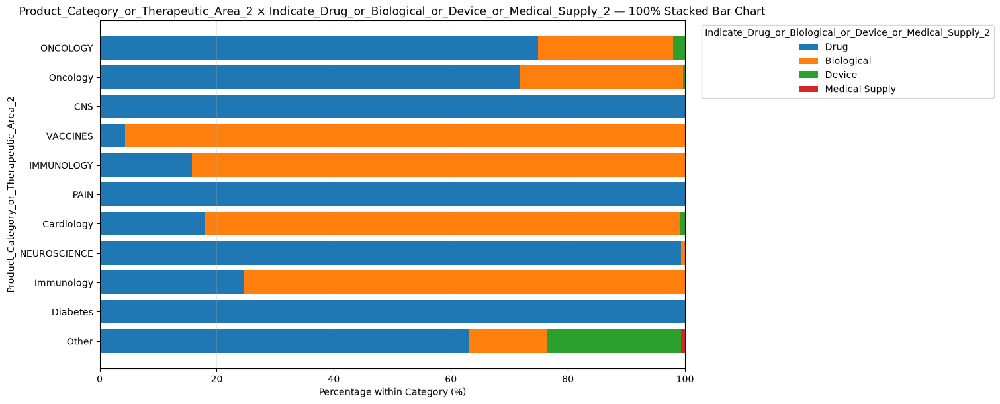


Related_Product_Indicator × Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1

Cross-tabulation — Counts:
shape: (1, 5)
┌───────────────────────────┬──────────┬──────────┬────────────┬────────────────┐
│ Related_Product_Indicator ┆ Drug     ┆ Device   ┆ Biological ┆ Medical Supply │
│ ---                       ┆ ---      ┆ ---      ┆ ---        ┆ ---            │
│ str                       ┆ i64      ┆ i64      ┆ i64        ┆ i64            │
╞═══════════════════════════╪══════════╪══════════╪════════════╪════════════════╡
│ Yes                       ┆ 49954345 ┆ 17465434 ┆ 13266373   ┆ 443430         │
└───────────────────────────┴──────────┴──────────┴────────────┴────────────────┘

Cross-tabulation — Row Percentages:
shape: (1, 5)
┌───────────────────────────┬───────┬────────┬────────────┬────────────────┐
│ Related_Product_Indicator ┆ Drug  ┆ Device ┆ Biological ┆ Medical Supply │
│ ---                       ┆ ---   ┆ ---    ┆ ---        ┆ ---            │
│ str          

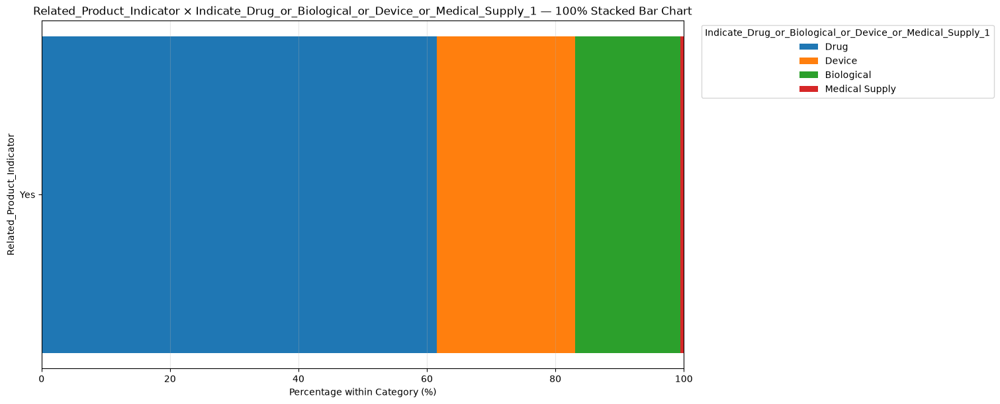


Third_Party_Payment_Recipient_Indicator × Nature_of_Payment_or_Transfer_of_Value

Cross-tabulation — Counts:
shape: (3, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Third_Par ┆ Food and  ┆ Travel    ┆ Compensat ┆ … ┆ Honoraria ┆ Royalty   ┆ Compensat ┆ Long     │
│ ty_Paymen ┆ Beverage  ┆ and       ┆ ion for   ┆   ┆ ---       ┆ or        ┆ ion for   ┆ term     │
│ t_Recipie ┆ ---       ┆ Lodging   ┆ services  ┆   ┆ i64       ┆ License   ┆ serving   ┆ medical  │
│ nt_…      ┆ i64       ┆ ---       ┆ othe…     ┆   ┆           ┆ ---       ┆ as fa…    ┆ supply   │
│ ---       ┆           ┆ i64       ┆ ---       ┆   ┆           ┆ i64       ┆ ---       ┆ or de…   │
│ str       ┆           ┆           ┆ i64       ┆   ┆           ┆           ┆ i64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪══

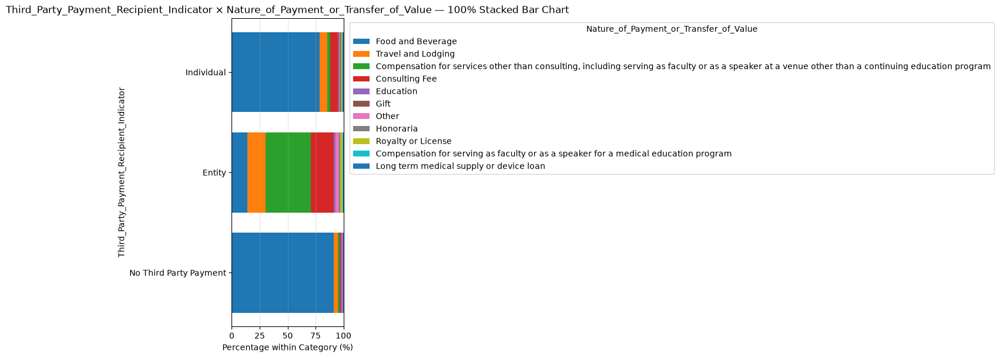


Physician_Ownership_Indicator × Covered_Recipient_Type

Cross-tabulation — Counts:
shape: (2, 4)
┌─────────────────────────────┬───────────────────┬───────────────────┬────────────────────────────┐
│ Physician_Ownership_Indicat ┆ Covered Recipient ┆ Covered Recipient ┆ Covered Recipient Teaching │
│ or                          ┆ Physician         ┆ Non-Physicia…     ┆ Hos…                       │
│ ---                         ┆ ---               ┆ ---               ┆ ---                        │
│ str                         ┆ i64               ┆ i64               ┆ i64                        │
╞═════════════════════════════╪═══════════════════╪═══════════════════╪════════════════════════════╡
│ No                          ┆ 62964666          ┆ 14746918          ┆ 25800                      │
│ Yes                         ┆ 127201            ┆ 4722              ┆ 33                         │
└─────────────────────────────┴───────────────────┴───────────────────┴───────────────────────

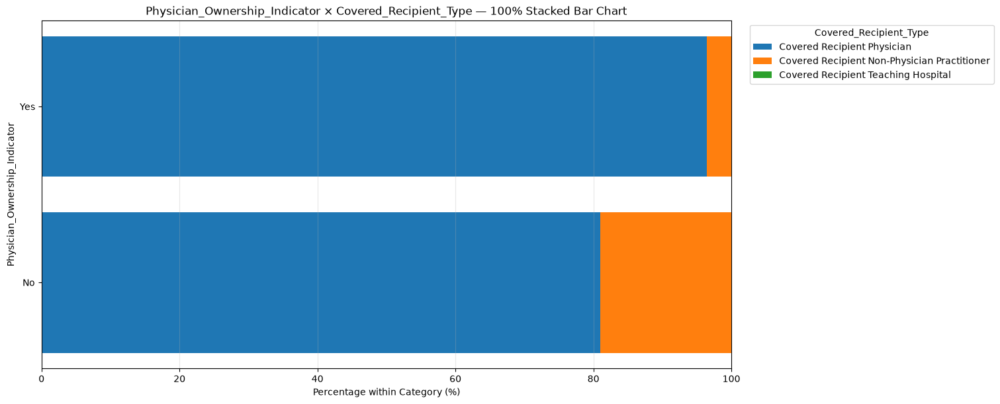


Physician_Ownership_Indicator × Nature_of_Payment_or_Transfer_of_Value

Cross-tabulation — Counts:
shape: (2, 12)
┌────────────┬────────────┬───────────┬───────────┬───┬────────┬───────────┬───────────┬───────────┐
│ Physician_ ┆ Food and   ┆ Travel    ┆ Compensat ┆ … ┆ Other  ┆ Royalty   ┆ Compensat ┆ Entertain │
│ Ownership_ ┆ Beverage   ┆ and       ┆ ion for   ┆   ┆ ---    ┆ or        ┆ ion for   ┆ ment      │
│ Indicator  ┆ ---        ┆ Lodging   ┆ services  ┆   ┆ i64    ┆ License   ┆ serving   ┆ ---       │
│ ---        ┆ i64        ┆ ---       ┆ othe…     ┆   ┆        ┆ ---       ┆ as fa…    ┆ i64       │
│ str        ┆            ┆ i64       ┆ ---       ┆   ┆        ┆ i64       ┆ ---       ┆           │
│            ┆            ┆           ┆ i64       ┆   ┆        ┆           ┆ i64       ┆           │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪════════╪═══════════╪═══════════╪═══════════╡
│ No         ┆ 70214709   ┆ 3141078   ┆ 1510287   ┆ … ┆ 119040 ┆ 95171     ┆ 

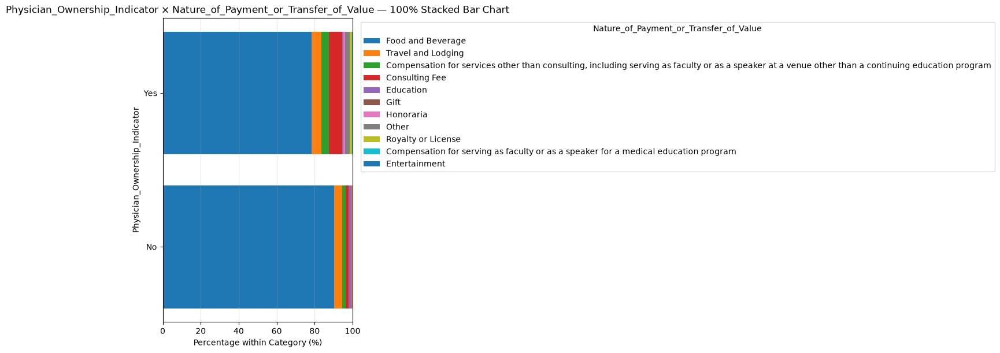


Charity_Indicator × Nature_of_Payment_or_Transfer_of_Value

Cross-tabulation — Counts:
shape: (2, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ Charity_In ┆ Food and   ┆ Travel and ┆ Compensat ┆ … ┆ Royalty   ┆ Honoraria ┆ Space     ┆ Grant │
│ dicator    ┆ Beverage   ┆ Lodging    ┆ ion for   ┆   ┆ or        ┆ ---       ┆ rental or ┆ ---   │
│ ---        ┆ ---        ┆ ---        ┆ services  ┆   ┆ License   ┆ i64       ┆ facility  ┆ i64   │
│ str        ┆ i64        ┆ i64        ┆ othe…     ┆   ┆ ---       ┆           ┆ fees …    ┆       │
│            ┆            ┆            ┆ ---       ┆   ┆ i64       ┆           ┆ ---       ┆       │
│            ┆            ┆            ┆ i64       ┆   ┆           ┆           ┆ i64       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ No         ┆ 25640260   ┆ 987157     ┆ 740186    ┆ … ┆ 33746     ┆ 26469     ┆ 25497   

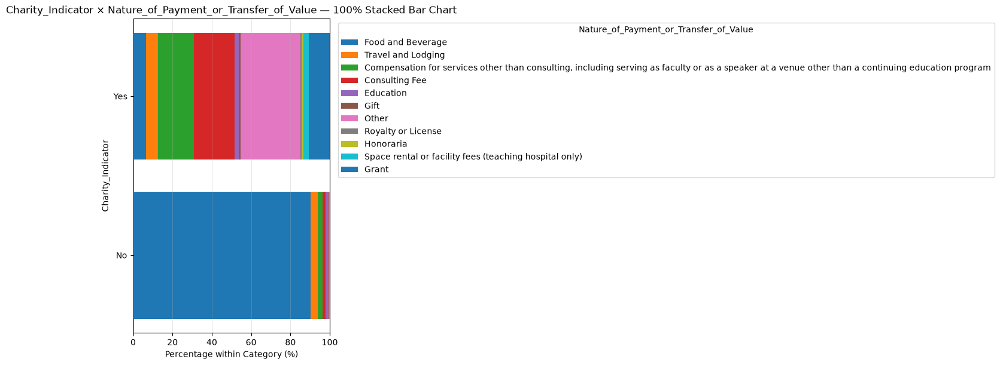


Dispute_Status_for_Publication × Change_Type

Cross-tabulation — Counts:
shape: (2, 5)
┌────────────────────────────────┬───────────┬──────────┬─────────┬──────┐
│ Dispute_Status_for_Publication ┆ UNCHANGED ┆ NEW      ┆ CHANGED ┆ ADD  │
│ ---                            ┆ ---       ┆ ---      ┆ ---     ┆ ---  │
│ str                            ┆ i64       ┆ i64      ┆ i64     ┆ i64  │
╞════════════════════════════════╪═══════════╪══════════╪═════════╪══════╡
│ No                             ┆ 70511998  ┆ 16457871 ┆ 678376  ┆ 4944 │
│ Yes                            ┆ 2266      ┆ 265      ┆ 9       ┆ 41   │
└────────────────────────────────┴───────────┴──────────┴─────────┴──────┘

Cross-tabulation — Row Percentages:
shape: (2, 5)
┌────────────────────────────────┬───────────┬───────┬─────────┬──────┐
│ Dispute_Status_for_Publication ┆ UNCHANGED ┆ NEW   ┆ CHANGED ┆ ADD  │
│ ---                            ┆ ---       ┆ ---   ┆ ---     ┆ ---  │
│ str                            ┆ f64       

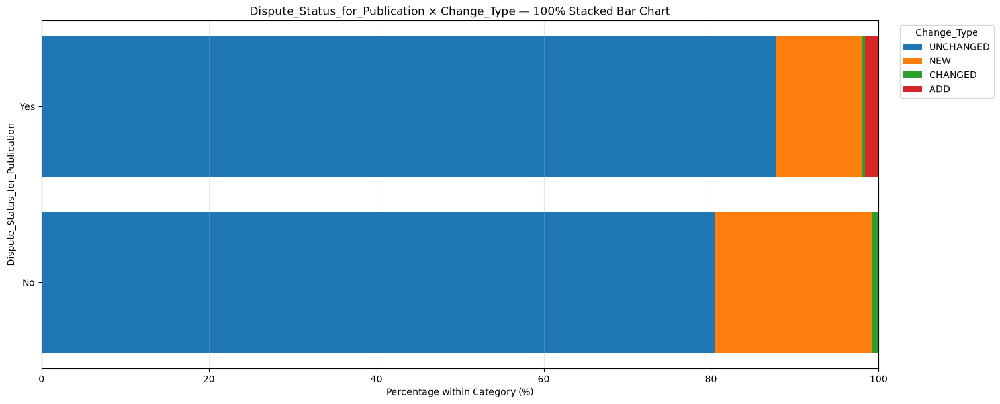


Covered_Recipient_Type × Nature_of_Payment_or_Transfer_of_Value

Cross-tabulation — Counts:
shape: (3, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Covered_R ┆ Food and  ┆ Travel    ┆ Compensat ┆ … ┆ Honoraria ┆ Royalty   ┆ Compensat ┆ Long     │
│ ecipient_ ┆ Beverage  ┆ and       ┆ ion for   ┆   ┆ ---       ┆ or        ┆ ion for   ┆ term     │
│ Type      ┆ ---       ┆ Lodging   ┆ services  ┆   ┆ i64       ┆ License   ┆ serving   ┆ medical  │
│ ---       ┆ i64       ┆ ---       ┆ othe…     ┆   ┆           ┆ ---       ┆ as fa…    ┆ supply   │
│ str       ┆           ┆ i64       ┆ ---       ┆   ┆           ┆ i64       ┆ ---       ┆ or de…   │
│           ┆           ┆           ┆ i64       ┆   ┆           ┆           ┆ i64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════

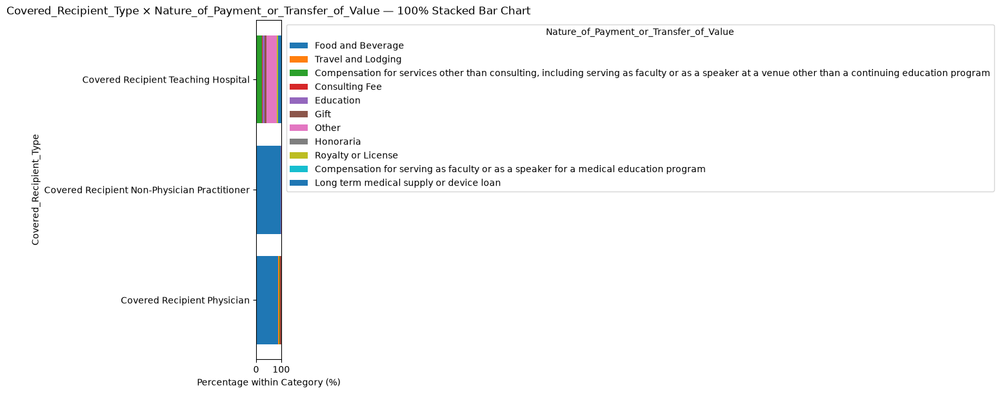


Recipient_State × Covered_Recipient_Primary_Type_1

Cross-tabulation — Counts:
shape: (11, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ Recipient_ ┆ Medical    ┆ Nurse Prac ┆ Physician ┆ … ┆ Certified ┆ Clinical  ┆ Certified ┆ Other │
│ State      ┆ Doctor     ┆ titioner   ┆ Assistant ┆   ┆ Registere ┆ Nurse Spe ┆ Nurse-Mid ┆ ---   │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ d Nurse   ┆ cialist   ┆ wife      ┆ i64   │
│ str        ┆ i64        ┆ i64        ┆ i64       ┆   ┆ Ane…      ┆ ---       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆ ---       ┆ i64       ┆ i64       ┆       │
│            ┆            ┆            ┆           ┆   ┆ i64       ┆           ┆           ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ Other      ┆ 21886167   ┆ 8005393    ┆ 3230603   ┆ … ┆ 131129    ┆ 75142     ┆ 31767     ┆ 924

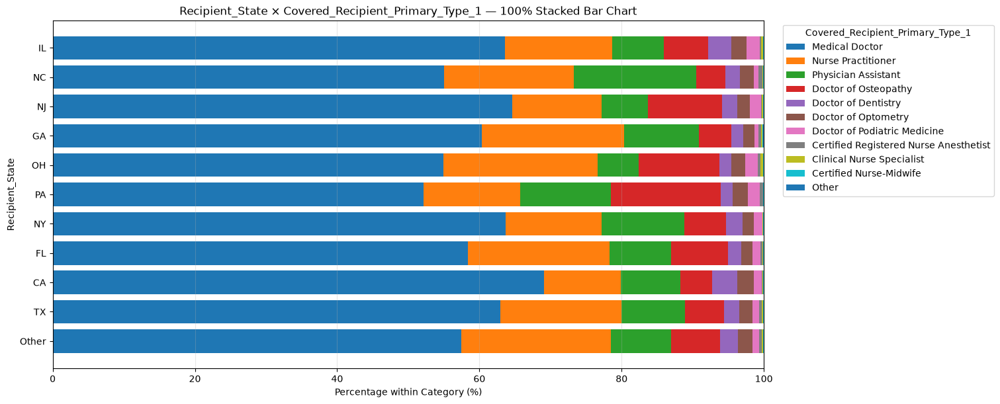



CHI-SQUARE AND CRAMER'S V SUMMARY
shape: (12, 7)
┌──────────────────┬─────────────────┬──────────────┬────────────┬─────────┬────────────┬──────────┐
│ Variable 1       ┆ Variable 2      ┆ Chi-square   ┆ Degrees of ┆ p-value ┆ Cramer's V ┆ Records  │
│ ---              ┆ ---             ┆ ---          ┆ Freedom    ┆ ---     ┆ ---        ┆ ---      │
│ str              ┆ str             ┆ f64          ┆ ---        ┆ f64     ┆ f64        ┆ i64      │
│                  ┆                 ┆              ┆ i64        ┆         ┆            ┆          │
╞══════════════════╪═════════════════╪══════════════╪════════════╪═════════╪════════════╪══════════╡
│ Related_Product_ ┆ Indicate_Drug_o ┆ NaN          ┆ 0          ┆ NaN     ┆ NaN        ┆ 81129582 │
│ Indicator        ┆ r_Biological_or ┆              ┆            ┆         ┆            ┆          │
│                  ┆ …               ┆              ┆            ┆         ┆            ┆          │
│ Product_Category ┆ Indicate_Drug_o ┆ 3

In [61]:
from scipy.stats import chi2

pairs = [
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Form_of_Payment_or_Transfer_of_Value"
    ),
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
    ),
    (
        "Product_Category_or_Therapeutic_Area_1",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
    ),
    (
        "Product_Category_or_Therapeutic_Area_2",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2"
    ),
    (
        "Related_Product_Indicator",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
    ),
    (
        "Third_Party_Payment_Recipient_Indicator",
        "Nature_of_Payment_or_Transfer_of_Value"
    ),
    (
        "Physician_Ownership_Indicator",
        "Covered_Recipient_Type"
    ),
    (
        "Physician_Ownership_Indicator",
        "Nature_of_Payment_or_Transfer_of_Value"
    ),
    (
        "Charity_Indicator",
        "Nature_of_Payment_or_Transfer_of_Value"
    ),
    (
        "Dispute_Status_for_Publication",
        "Change_Type"
    ),
    (
        "Covered_Recipient_Type",
        "Nature_of_Payment_or_Transfer_of_Value"
    ),
    (
        "Recipient_State",
        "Covered_Recipient_Primary_Type_1"
    )
]

TOP_N = 10
chi_results = []

for col1, col2 in pairs:

    print("\n" + "=" * 100)
    print(f"{col1} × {col2}")
    print("=" * 100)

    counts = (
        lf
        .select([
            pl.col(col1).cast(pl.String),
            pl.col(col2).cast(pl.String)
        ])
        .drop_nulls()
        .group_by([col1, col2])
        .agg(pl.len().alias("count"))
        .collect()
    )

    if len(counts) == 0:
        print("No valid records.")
        continue

    row_values = counts[col1].unique().to_list()
    col_values = counts[col2].unique().to_list()

    row_index = {
        value: i
        for i, value in enumerate(row_values)
    }

    col_index = {
        value: i
        for i, value in enumerate(col_values)
    }

    matrix = np.zeros(
        (len(row_values), len(col_values)),
        dtype=np.float64
    )

    for row in counts.iter_rows():
        r, c, value = row
        matrix[row_index[r], col_index[c]] = value

    total = matrix.sum()

    row_totals = matrix.sum(axis=1)
    col_totals = matrix.sum(axis=0)

    if matrix.shape[0] < 2 or matrix.shape[1] < 2:

        chi_square = np.nan
        degrees_of_freedom = 0
        p_value = np.nan
        cramers_v = np.nan

        test_applicable = False

    else:

        expected = (
            np.outer(row_totals, col_totals) /
            total
        )

        valid_expected = expected > 0

        chi_square = np.sum(
            (
                (matrix - expected) ** 2
            )[valid_expected]
            /
            expected[valid_expected]
        )

        degrees_of_freedom = (
            (matrix.shape[0] - 1) *
            (matrix.shape[1] - 1)
        )

        p_value = chi2.sf(
            chi_square,
            degrees_of_freedom
        )

        min_dimension = min(
            matrix.shape[0] - 1,
            matrix.shape[1] - 1
        )

        if min_dimension > 0 and total > 0:
            cramers_v = np.sqrt(
                chi_square /
                (total * min_dimension)
            )
        else:
            cramers_v = np.nan

        test_applicable = True

    chi_results.append({
        "Variable 1": col1,
        "Variable 2": col2,
        "Chi-square": chi_square,
        "Degrees of Freedom": degrees_of_freedom,
        "p-value": p_value,
        "Cramer's V": cramers_v,
        "Records": int(total)
    })

    # Select top categories
    top_rows = (
        counts
        .group_by(col1)
        .agg(pl.col("count").sum().alias("total"))
        .sort("total", descending=True)
        .head(TOP_N)[col1]
        .to_list()
    )

    top_cols = (
        counts
        .group_by(col2)
        .agg(pl.col("count").sum().alias("total"))
        .sort("total", descending=True)
        .head(TOP_N)[col2]
        .to_list()
    )

    # Group remaining categories into Other
    display_data = (
        counts
        .with_columns([
            pl.when(pl.col(col1).is_in(top_rows))
            .then(pl.col(col1))
            .otherwise(pl.lit("Other"))
            .alias("_row"),

            pl.when(pl.col(col2).is_in(top_cols))
            .then(pl.col(col2))
            .otherwise(pl.lit("Other"))
            .alias("_col")
        ])
        .group_by(["_row", "_col"])
        .agg(pl.col("count").sum().alias("count"))
    )

    row_totals_display = (
        display_data
        .group_by("_row")
        .agg(pl.col("count").sum().alias("row_total"))
    )

    display_data = (
        display_data
        .join(
            row_totals_display,
            on="_row"
        )
        .with_columns(
            (
                pl.col("count") /
                pl.col("row_total") *
                100
            ).alias("percentage")
        )
    )

    ordered_rows = (
        display_data
        .group_by("_row")
        .agg(pl.col("count").sum().alias("total"))
        .sort("total", descending=True)["_row"]
        .to_list()
    )

    ordered_cols = (
        display_data
        .group_by("_col")
        .agg(pl.col("count").sum().alias("total"))
        .sort("total", descending=True)["_col"]
        .to_list()
    )

    lookup_count = {
        (r, c): value
        for r, c, value in display_data.select(
            ["_row", "_col", "count"]
        ).iter_rows()
    }

    lookup_percentage = {
        (r, c): value
        for r, c, value in display_data.select(
            ["_row", "_col", "percentage"]
        ).iter_rows()
    }

    count_table = pl.DataFrame({
        col1: ordered_rows,
        **{
            str(c): [
                lookup_count.get(
                    (r, c),
                    0
                )
                for r in ordered_rows
            ]
            for c in ordered_cols
        }
    })

    percentage_table = pl.DataFrame({
        col1: ordered_rows,
        **{
            str(c): [
                round(
                    lookup_percentage.get(
                        (r, c),
                        0
                    ),
                    2
                )
                for r in ordered_rows
            ]
            for c in ordered_cols
        }
    })

    print("\nCross-tabulation — Counts:")
    print(count_table)

    print("\nCross-tabulation — Row Percentages:")
    print(percentage_table)

    if test_applicable:

        print(
            f"\nChi-square statistic: "
            f"{chi_square:,.4f}"
        )

        print(
            f"Degrees of freedom: "
            f"{degrees_of_freedom:,}"
        )

        print(
            f"p-value: "
            f"{p_value:.6e}"
        )

        print(
            f"Cramer's V: "
            f"{cramers_v:.6f}"
        )

    else:

        print("\nChi-square test: Not applicable")
        print("Degrees of freedom: 0")
        print("p-value: Not applicable")
        print("Cramer's V: Not applicable")

    # Prepare percentage matrix
    percentage_matrix = np.array([
        [
            lookup_percentage.get(
                (r, c),
                0
            )
            for c in ordered_cols
        ]
        for r in ordered_rows
    ])

    # Plot
    fig, ax = plt.subplots(
        figsize=(
            15,
            max(
                6,
                len(ordered_rows) * 0.5
            )
        ),
        constrained_layout=True
    )

    bottom = np.zeros(
        len(ordered_rows)
    )

    for j, category in enumerate(ordered_cols):

        values = percentage_matrix[:, j]

        ax.barh(
            ordered_rows,
            values,
            left=bottom,
            label=str(category)
        )

        bottom += values

    ax.set_xlabel(
        "Percentage within Category (%)"
    )

    ax.set_ylabel(col1)

    ax.set_title(
        f"{col1} × {col2} — "
        f"100% Stacked Bar Chart"
    )

    ax.set_xlim(0, 100)

    ax.grid(
        axis="x",
        alpha=0.3
    )

    ax.legend(
        title=col2,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.show()


results = (
    pl.DataFrame(chi_results)
    .sort(
        "Cramer's V",
        descending=True,
        nulls_last=True
    )
)

print("\n")
print("=" * 100)
print("CHI-SQUARE AND CRAMER'S V SUMMARY")
print("=" * 100)

print(results)

# Categorical ↔ Categorical Analysis

Categorical ↔ categorical analysis examines the relationship between two categorical variables. The analysis uses cross-tabulations, 100% stacked bar charts, the Chi-square test of independence, and Cramér's V.

The 100% stacked bar charts show the distribution of the second categorical variable within each category of the first variable. This makes it possible to identify differences in category composition across groups.

## 1. Charity Indicator × Nature of Payment

The distribution of payment types differs substantially between charity and non-charity records.

- Records with `Charity_Indicator = No` are overwhelmingly dominated by **Food and Beverage** payments.
- Records with `Charity_Indicator = Yes` have a considerably more diverse distribution of payment types.
- For charity records, **Other**, **Consulting Fee**, and **Compensation for services other than consulting** represent substantial portions of the distribution.
- Travel, Education, Royalty or License, Honoraria, and other payment categories are also more visible among charity records.

### Observation

`Charity_Indicator` is associated with the composition of `Nature_of_Payment_or_Transfer_of_Value`.

The payment-type distribution is substantially different between charity and non-charity records.

---

## 2. Covered Recipient Type × Nature of Payment

The payment distribution differs across recipient types.

### Covered Recipient Physician

- The distribution is strongly dominated by **Food and Beverage**.
- Other payment categories represent comparatively small portions.

### Covered Recipient Non-Physician Practitioner

- This category is also strongly dominated by **Food and Beverage**.
- The remaining payment categories occupy relatively small portions.

### Covered Recipient Teaching Hospital

- The distribution is considerably more diverse.
- Compensation, Consulting Fee, Education, and Other payments represent meaningful portions.
- The distribution differs noticeably from the physician and non-physician practitioner categories.

### Observation

`Covered_Recipient_Type` has a clear association with `Nature_of_Payment_or_Transfer_of_Value`.

Teaching hospitals have a substantially different payment-type composition compared with physicians and non-physician practitioners.

---

## 3. Dispute Status × Change Type

The distribution of `Change_Type` differs between disputed and non-disputed records.

### Dispute Status = Yes

The distribution is approximately:

- **UNCHANGED:** ~87%
- **NEW:** ~10%
- **CHANGED:** very small proportion
- **ADD:** small proportion

### Dispute Status = No

The distribution is approximately:

- **UNCHANGED:** ~80%
- **NEW:** ~19%
- **CHANGED:** small proportion

### Observation

`Dispute_Status_for_Publication` and `Change_Type` are associated.

The most visible difference is the larger proportion of **NEW** records among records without a dispute, while **UNCHANGED** records form a larger proportion among disputed records.

This indicates that the two categorical variables do not have the same distribution.

---

## 4. Nature of Payment × Form of Payment

This is one of the clearest categorical relationships in the analysis.

Different payment types have substantially different forms of payment.

Examples include:

- **Food and Beverage:** predominantly **In-kind items and services**, with a smaller cash component.
- **Travel and Lodging:** largely in-kind, with a substantial cash component.
- **Education:** predominantly in-kind.
- **Gift:** predominantly in-kind.
- **Honoraria:** overwhelmingly **Cash or cash equivalent**.
- **Royalty or License:** almost entirely **Cash or cash equivalent**.
- **Consulting Fee:** overwhelmingly cash or cash equivalent.
- **Long term medical supply or device loan:** predominantly in-kind.
- **Compensation for serving as faculty or speaker for a medical education program:** overwhelmingly cash or cash equivalent.

### Observation

`Nature_of_Payment_or_Transfer_of_Value` has a strong relationship with `Form_of_Payment_or_Transfer_of_Value`.

The nature of the transaction is closely associated with the way the transfer is made.

---

## 5. Nature of Payment × Drug/Biological/Device/Medical Supply

The distribution of product types also varies considerably across payment types.

Examples:

- **Royalty or License:** overwhelmingly associated with **Device**.
- **Long term medical supply or device loan:** predominantly **Device**.
- **Honoraria:** primarily **Drug**, with a substantial Biological component.
- **Food and Beverage:** predominantly Drug, followed by Biological.
- **Travel and Lodging:** predominantly Drug, with substantial Device and Biological components.
- **Compensation for services:** contains substantial Drug and Biological proportions.
- **Gift:** has a relatively larger Device and Medical Supply component compared with several other payment categories.

### Observation

`Nature_of_Payment_or_Transfer_of_Value` is strongly associated with `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1`.

Different payment categories have noticeably different distributions of associated product or item types.

---

## 6. Physician Ownership × Covered Recipient Type

The distribution of recipient types differs between physician ownership categories.

### Physician Ownership = Yes

- Approximately **96%** are Covered Recipient Physicians.
- Approximately **4%** are Covered Recipient Non-Physician Practitioners.
- Teaching Hospitals represent essentially none of the records.

### Physician Ownership = No

- Approximately **81%** are Covered Recipient Physicians.
- Approximately **19%** are Covered Recipient Non-Physician Practitioners.
- Teaching Hospitals represent only a very small proportion.

### Observation

`Physician_Ownership_Indicator` is associated with `Covered_Recipient_Type`.

The most noticeable difference is the larger proportion of non-physician practitioners when physician ownership is `No`.

---

## 7. Physician Ownership × Nature of Payment

The distribution of payment types also differs between physician ownership categories.

### Physician Ownership = No

- Approximately **78%** of records are Food and Beverage.
- Travel and Lodging is the next visible category.
- Other payment categories represent relatively small proportions.

### Physician Ownership = Yes

- Food and Beverage remains the dominant payment category.
- However, the remaining payment types are somewhat more diverse.
- Consulting Fee, compensation, education, and other categories have more visible proportions.

### Observation

There is an association between `Physician_Ownership_Indicator` and `Nature_of_Payment_or_Transfer_of_Value`.

However, the visual difference is smaller than the relationships observed for Nature of Payment versus Form of Payment or Product Type.

---

## 8. Product Category 1 × Product/Item Type 1

This analysis reveals a strong relationship between therapeutic area and product type.

Examples:

- **ONCOLOGY:** predominantly Drug with a substantial Biological component.
- **Respiratory:** heavily Drug, with smaller Device and Biological components.
- **Neuroscience:** primarily Drug and Biological.
- **PSYCHIATRY:** almost entirely Drug.
- **RESPIRATORY:** predominantly Drug with a Biological component.
- **Oncology:** substantial Drug, Device, and Biological components.
- **IMMUNOLOGY:** predominantly Biological.
- **Immunology:** approximately divided between Drug and Biological.
- **Diabetes:** almost entirely Drug.
- **NEUROSCIENCE:** overwhelmingly Drug.

### Observation

`Product_Category_or_Therapeutic_Area_1` has a strong relationship with `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1`.

Different therapeutic areas have noticeably different distributions of Drugs, Biologicals, Devices, and Medical Supplies.

### Data Quality Observation

Several categories appear in different capitalization forms:

- `ONCOLOGY` / `Oncology`
- `NEUROSCIENCE` / `Neuroscience`
- `IMMUNOLOGY` / `Immunology`
- `RESPIRATORY` / `Respiratory`

These appear to represent the same conceptual categories with inconsistent capitalization.

This should be normalized before further statistical analysis or machine-learning modeling.

---

## 9. Product Category 2 × Product/Item Type 2

The second product fields show a similar relationship.

Examples:

- **CNS:** essentially entirely Drug.
- **PAIN:** essentially entirely Drug.
- **Diabetes:** essentially entirely Drug.
- **Vaccines:** predominantly Biological.
- **Immunology:** predominantly Biological.
- **Cardiology:** predominantly Biological with a very small Device component.
- **Oncology:** mainly Drug and Biological.
- **NEUROSCIENCE:** almost entirely Drug.

### Observation

`Product_Category_or_Therapeutic_Area_2` is strongly associated with `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2`.

The therapeutic area provides substantial information about the associated product or item type.

### Data Quality Observation

The same capitalization inconsistency observed in the first product fields also appears here.

Categories should be standardized before treating them as unique categorical levels.

---

## 10. Recipient State × Primary Recipient Type

The relationship between state and recipient professional type is more moderate than the product-related relationships.

Medical Doctors are the largest category across the major states shown, but their proportions differ.

Examples include approximately:

- **IL:** 64% Medical Doctor
- **NC:** 55%
- **NJ:** 65%
- **GA:** 60%
- **OH:** 55%
- **PA:** 52%
- **NY:** 64%
- **FL:** 58%
- **CA:** 69%
- **TX:** 63%

The remaining proportions are mainly distributed among:

- Nurse Practitioner
- Physician Assistant
- Doctor of Osteopathy
- Doctor of Dentistry
- Doctor of Optometry
- Doctor of Podiatric Medicine
- Other professional categories

### Observation

`Recipient_State` and `Covered_Recipient_Primary_Type_1` show an association.

The professional composition varies across states, although Medical Doctor remains the dominant category across the states shown.

The differences are therefore primarily **distributional**, rather than representing completely different professional structures.

---

## 11. Related Product Indicator × Product/Item Type 1

This pair requires special interpretation.

Only:

`Related_Product_Indicator = Yes`

appears in the cross-tabulation.

There is no `No` category available for comparison in the analyzed records.

Among the `Yes` records:

- Drug represents approximately **62%**.
- Device represents approximately **21%**.
- Biological represents approximately **16%**.
- Medical Supply represents only a very small proportion.

### Observation

This plot describes the product-type composition of records marked as related to a product.

It does **not** establish an association between `Related_Product_Indicator` and product type because there is no second level of `Related_Product_Indicator` available for comparison.

Consequently, the Chi-square test and Cramér's V are **not applicable** for this pair.

---

## 12. Third-Party Payment Recipient × Nature of Payment

This analysis shows a strong difference in payment composition across third-party recipient categories.

### Individual

- Strongly dominated by **Food and Beverage**.
- Travel and Lodging is the next visible category.
- Other payment categories represent relatively small proportions.

### Entity

The distribution is substantially different:

- Food and Beverage represents a much smaller proportion.
- Compensation for services represents a substantial proportion.
- Consulting Fee is also substantial.
- Travel and Lodging has a noticeable share.
- Several other payment categories are present.

### No Third Party Payment

- Extremely dominated by **Food and Beverage**.
- Other payment categories occupy comparatively small proportions.

### Observation

`Third_Party_Payment_Recipient_Indicator` is strongly associated with `Nature_of_Payment_or_Transfer_of_Value`.

The **Entity** category has a markedly different payment composition from both Individual and No Third Party Payment.

---

# Overall Findings

The categorical ↔ categorical analysis reveals several important relationships in the dataset.

## Strong Structural Relationships

### Nature of Payment ↔ Form of Payment

Different types of payments are associated with substantially different transfer mechanisms.

### Nature of Payment ↔ Product/Item Type

Different payment categories have different distributions of Drugs, Biologicals, Devices, and Medical Supplies.

### Product/Therapeutic Area ↔ Product/Item Type

Therapeutic areas have characteristic distributions of associated product types.

### Third-Party Recipient ↔ Nature of Payment

Entity, Individual, and No Third Party Payment records have substantially different payment-type distributions.

---

## Clear Relationships

### Covered Recipient Type ↔ Nature of Payment

Teaching Hospitals have a substantially different payment composition from Physicians and Non-Physician Practitioners.

### Charity Indicator ↔ Nature of Payment

Charity and non-charity records have substantially different payment-type distributions.

### Dispute Status ↔ Change Type

Disputed and non-disputed records have different proportions of `UNCHANGED`, `NEW`, and other change types.

### Physician Ownership ↔ Covered Recipient Type

Ownership status corresponds to different distributions of recipient professional types.

---

## More Moderate Relationship

### Recipient State ↔ Primary Recipient Type

The professional composition varies across states, although Medical Doctors remain the dominant category across the states shown.

### Physician Ownership ↔ Nature of Payment

There is a visible difference in payment composition, but it is smaller than several of the stronger relationships identified above.

---

## Special Case

### Related Product Indicator ↔ Product Type

Only `Yes` appears for `Related_Product_Indicator` in the analyzed data.

Therefore, this pair cannot provide a meaningful two-group association test. The product-type distribution can be described, but Chi-square and Cramér's V are not applicable.

---

# Important Data Quality Finding

A recurring issue appears in the product/therapeutic-area variables.

The same conceptual categories occur with inconsistent capitalization:

- `Oncology` / `ONCOLOGY`
- `Immunology` / `IMMUNOLOGY`
- `Neuroscience` / `NEUROSCIENCE`
- `Respiratory` / `RESPIRATORY`

This creates separate categorical levels for what appear to be the same underlying category.

For subsequent analysis, these values should be standardized, for example by applying consistent capitalization before calculating category frequencies, cross-tabulations, Chi-square statistics, Cramér's V, or building machine-learning features.

---

# Overall Interpretation

The categorical variables in this dataset are **not independent**. Many describe different aspects of the same underlying payment transaction, so substantial relationships are expected.

A general structural pattern is visible:

**Nature of Payment**  
↓  
**Form of Payment**

and

**Product/Therapeutic Area**  
↓  
**Drug / Biological / Device / Medical Supply**

while recipient-related characteristics such as:

**Recipient Type**  
**Physician Ownership**  
**Third-Party Recipient**  
**Charity Status**

are also associated with different payment compositions.

Therefore, the categorical analysis demonstrates that the dataset contains several meaningful dependencies between transaction, recipient, payment, and product-related variables.

# 8. Multivariate analysis

- Nature of Payment × Covered Recipient Type → Payment Amount
- Nature of Payment × Product Type → Payment Amount
- Nature of Payment × Covered Recipient Type × Product Type
- Recipient State × Nature of Payment → Payment Amount
- Year × Nature of Payment × Covered Recipient Type → Payment Amount



1. NATURE OF PAYMENT × COVERED RECIPIENT TYPE → PAYMENT AMOUNT
shape: (52, 9)
┌────────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ Nature_of_ ┆ Covered_R ┆ Count    ┆ Total_Pay ┆ … ┆ Median_Pa ┆ Std_Payme ┆ Q1       ┆ Q3        │
│ Payment_or ┆ ecipient_ ┆ ---      ┆ ment      ┆   ┆ yment     ┆ nt        ┆ ---      ┆ ---       │
│ _Transfer_ ┆ Type      ┆ u32      ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64      ┆ f64       │
│ …          ┆ ---       ┆          ┆ f64       ┆   ┆ f64       ┆ f64       ┆          ┆           │
│ ---        ┆ str       ┆          ┆           ┆   ┆           ┆           ┆          ┆           │
│ str        ┆           ┆          ┆           ┆   ┆           ┆           ┆          ┆           │
╞════════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ Acquisitio ┆ Covered   ┆ 6        ┆ 1.0370e7  ┆ … ┆ 1.2292e6  ┆ 1.7276e6  ┆ 402692.0 ┆ 3.5067e6  │
│ ns        

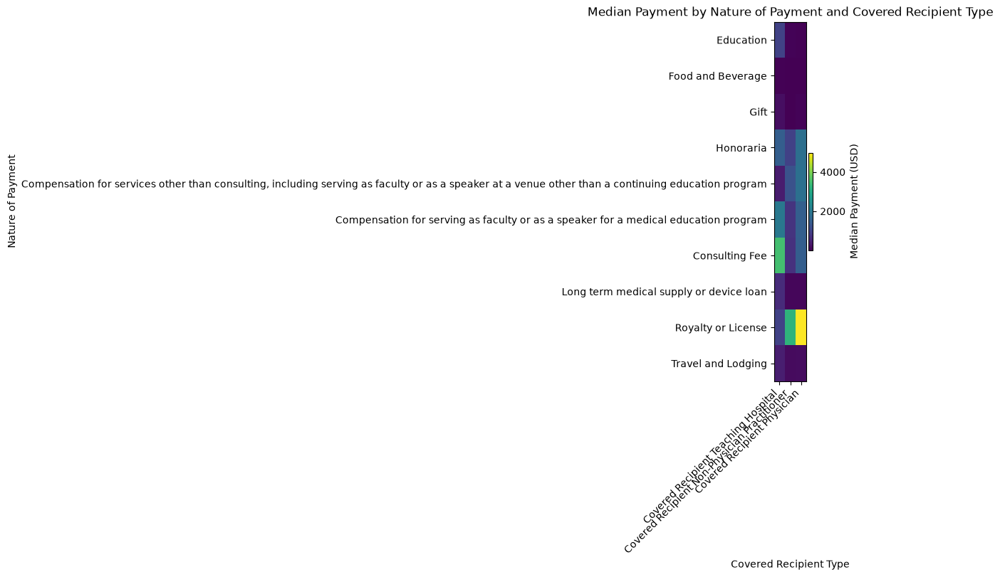


2. NATURE OF PAYMENT × PRODUCT TYPE → PAYMENT AMOUNT
shape: (71, 9)
┌────────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ Nature_of_ ┆ Indicate_ ┆ Count    ┆ Total_Pay ┆ … ┆ Median_Pa ┆ Std_Payme ┆ Q1       ┆ Q3        │
│ Payment_or ┆ Drug_or_B ┆ ---      ┆ ment      ┆   ┆ yment     ┆ nt        ┆ ---      ┆ ---       │
│ _Transfer_ ┆ iological ┆ u32      ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64      ┆ f64       │
│ …          ┆ _or…      ┆          ┆ f64       ┆   ┆ f64       ┆ f64       ┆          ┆           │
│ ---        ┆ ---       ┆          ┆           ┆   ┆           ┆           ┆          ┆           │
│ str        ┆ str       ┆          ┆           ┆   ┆           ┆           ┆          ┆           │
╞════════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ Acquisitio ┆ Drug      ┆ 2        ┆ 107113.14 ┆ … ┆ 53556.57  ┆ 37216.033 ┆ 27240.86 ┆ 79872.28  │
│ ns         ┆        

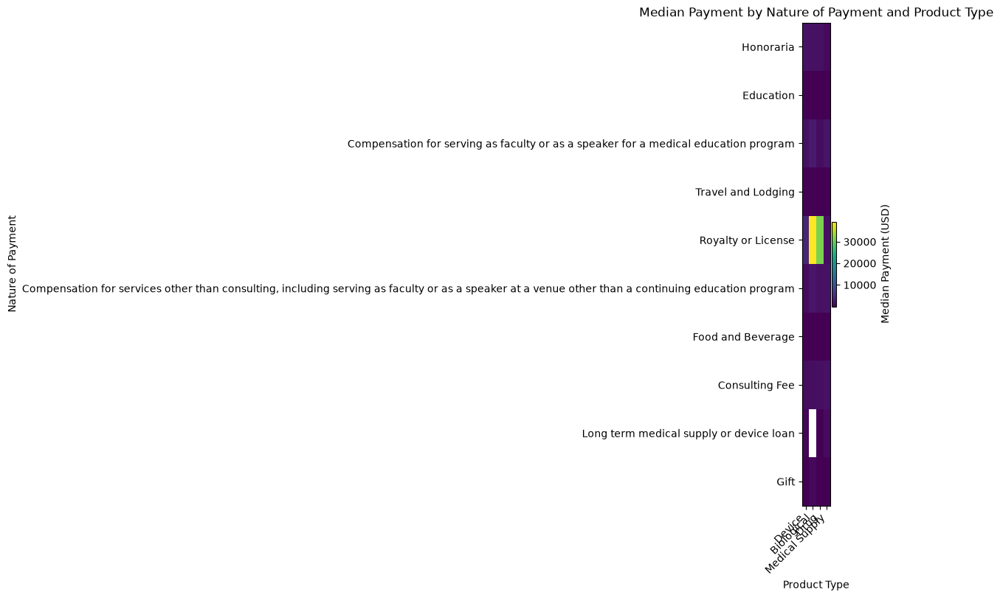


3. NATURE OF PAYMENT × COVERED RECIPIENT TYPE × PRODUCT TYPE
shape: (50, 4)
┌─────────────────────────────┬────────────────────────────┬────────────────────────────┬──────────┐
│ Nature_of_Payment_or_Transf ┆ Covered_Recipient_Type     ┆ Indicate_Drug_or_Biologica ┆ Count    │
│ er_…                        ┆ ---                        ┆ l_or…                      ┆ ---      │
│ ---                         ┆ str                        ┆ ---                        ┆ u32      │
│ str                         ┆                            ┆ str                        ┆          │
╞═════════════════════════════╪════════════════════════════╪════════════════════════════╪══════════╡
│ Food and Beverage           ┆ Covered Recipient          ┆ Drug                       ┆ 31405298 │
│                             ┆ Physician                  ┆                            ┆          │
│ Food and Beverage           ┆ Covered Recipient          ┆ Drug                       ┆ 16061629 │
│             

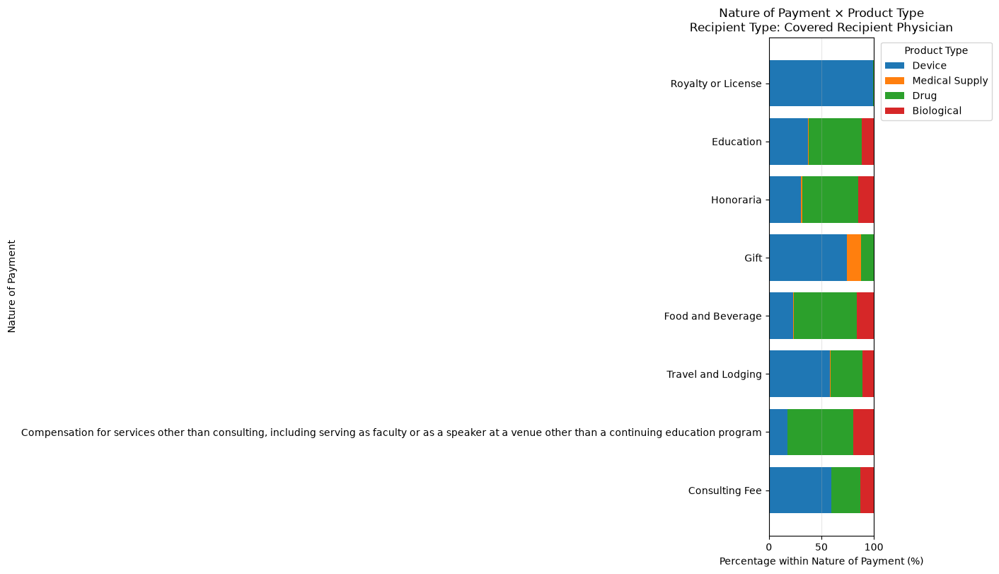

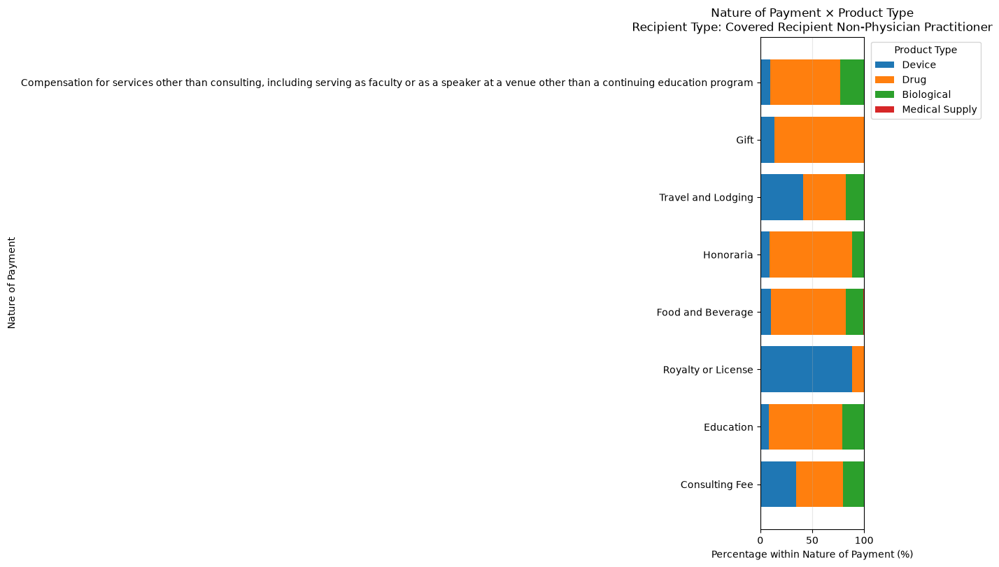

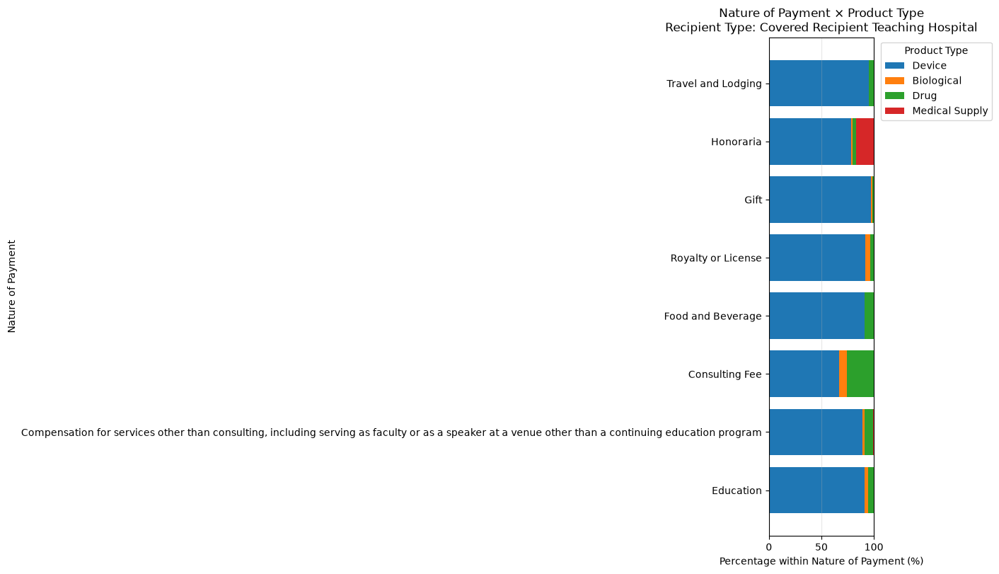


4. RECIPIENT STATE × NATURE OF PAYMENT → PAYMENT AMOUNT
shape: (50, 6)
┌─────────────────┬───────────────────────┬───────┬───────────────┬────────────────┬───────────────┐
│ Recipient_State ┆ Nature_of_Payment_or_ ┆ Count ┆ Total_Payment ┆ Median_Payment ┆ Mean_Payment  │
│ ---             ┆ Transfer_…            ┆ ---   ┆ ---           ┆ ---            ┆ ---           │
│ str             ┆ ---                   ┆ u32   ┆ f64           ┆ f64            ┆ f64           │
│                 ┆ str                   ┆       ┆               ┆                ┆               │
╞═════════════════╪═══════════════════════╪═══════╪═══════════════╪════════════════╪═══════════════╡
│ HI              ┆ Acquisitions          ┆ 2     ┆ 2.6759e7      ┆ 1.3379e7       ┆ 1.3379e7      │
│ ND              ┆ Current or            ┆ 1     ┆ 797705.66     ┆ 797705.66      ┆ 797705.66     │
│                 ┆ prospective ownersh…  ┆       ┆               ┆                ┆               │
│ ND              ┆

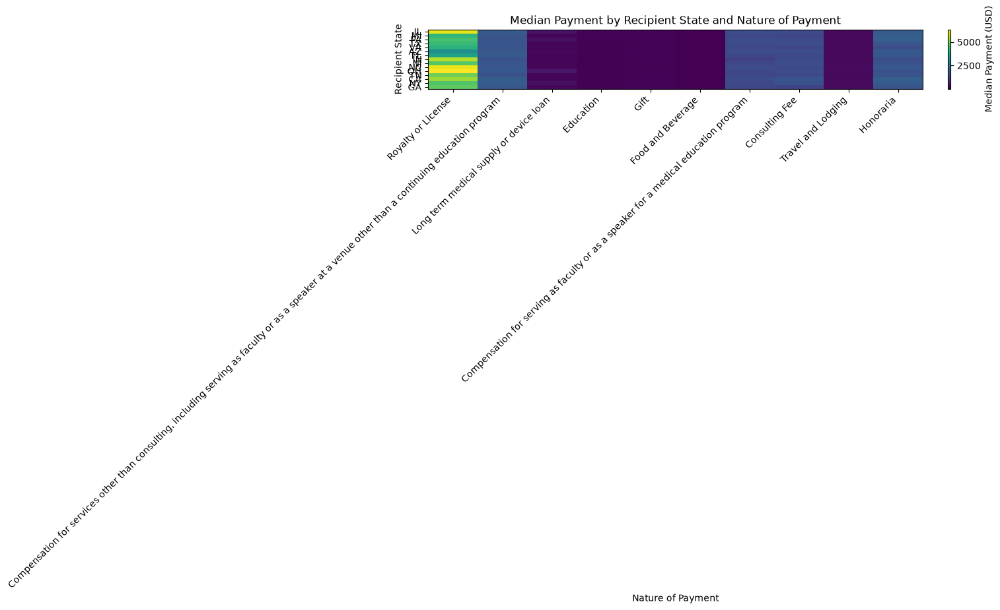


5. YEAR × NATURE OF PAYMENT × COVERED RECIPIENT TYPE → PAYMENT AMOUNT
shape: (289, 7)
┌──────────────┬──────────────┬──────────────┬─────────┬──────────────┬──────────────┬─────────────┐
│ Program_Year ┆ Nature_of_Pa ┆ Covered_Reci ┆ Count   ┆ Total_Paymen ┆ Mean_Payment ┆ Median_Paym │
│ ---          ┆ yment_or_Tra ┆ pient_Type   ┆ ---     ┆ t            ┆ ---          ┆ ent         │
│ u16          ┆ nsfer_…      ┆ ---          ┆ u32     ┆ ---          ┆ f64          ┆ ---         │
│              ┆ ---          ┆ str          ┆         ┆ f64          ┆              ┆ f64         │
│              ┆ str          ┆              ┆         ┆              ┆              ┆             │
╞══════════════╪══════════════╪══════════════╪═════════╪══════════════╪══════════════╪═════════════╡
│ 2019         ┆ Current or   ┆ Covered      ┆ 1       ┆ 3.5259e6     ┆ 3.5259e6     ┆ 3.5259e6    │
│              ┆ prospective  ┆ Recipient    ┆         ┆              ┆              ┆             │
│   

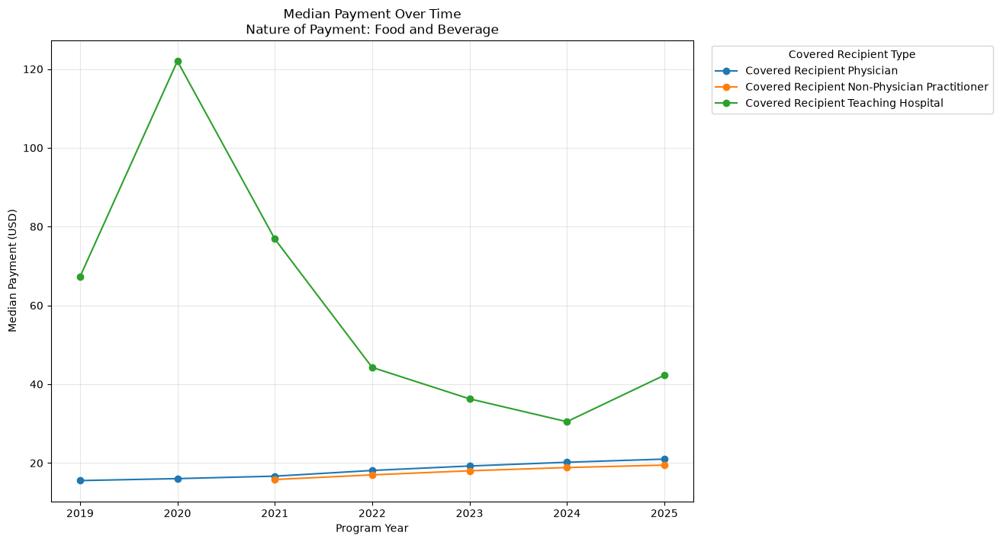

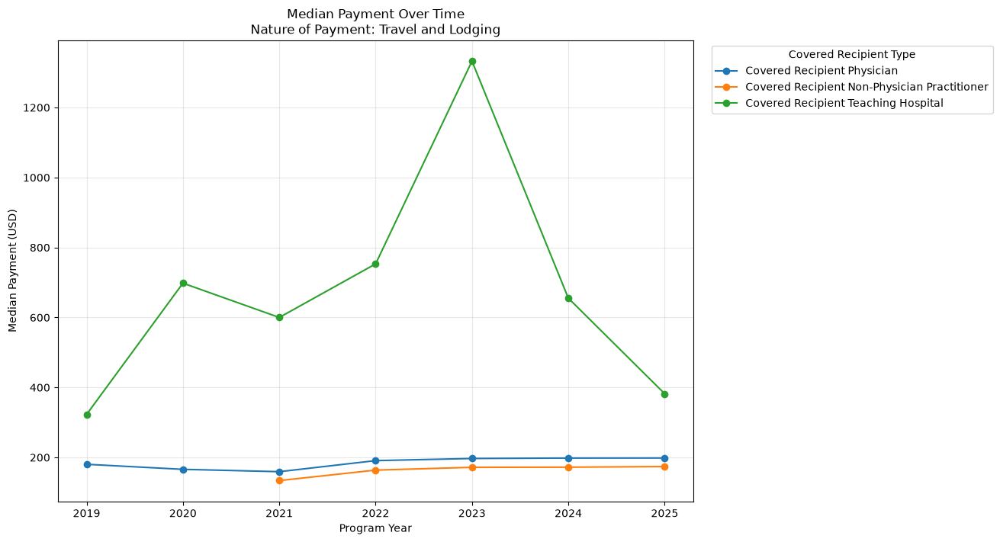

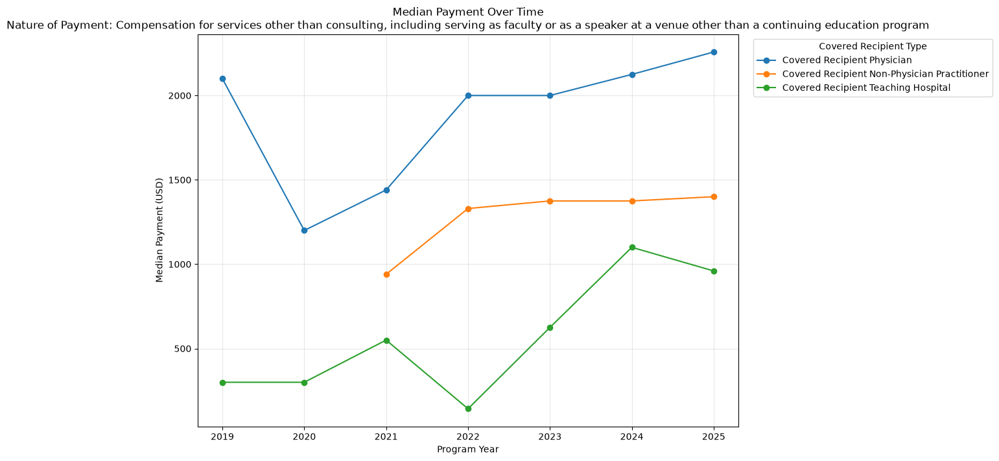

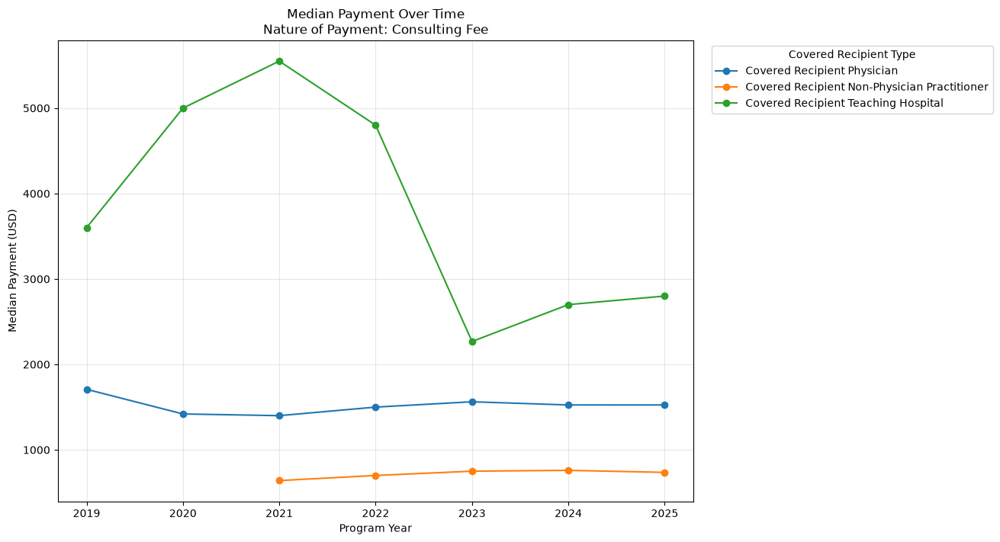

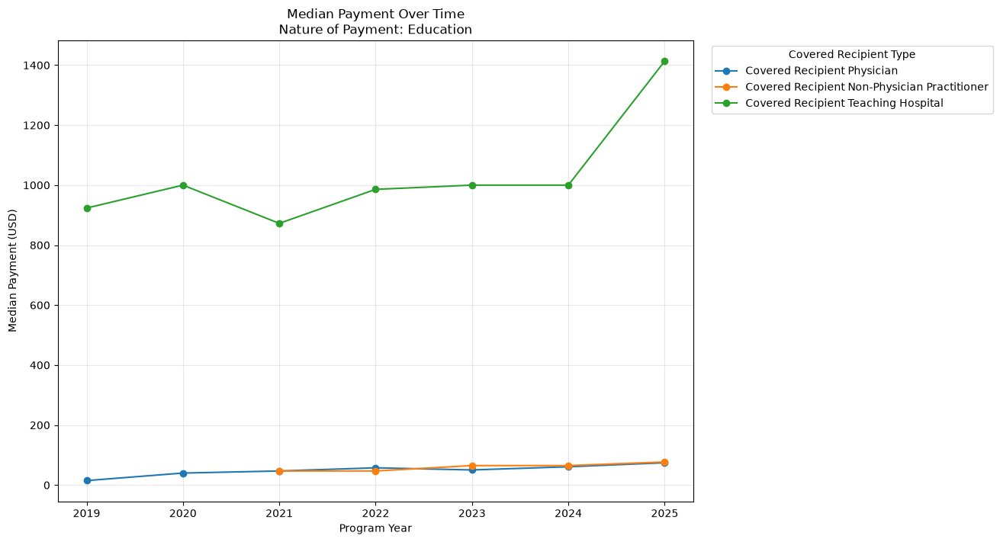

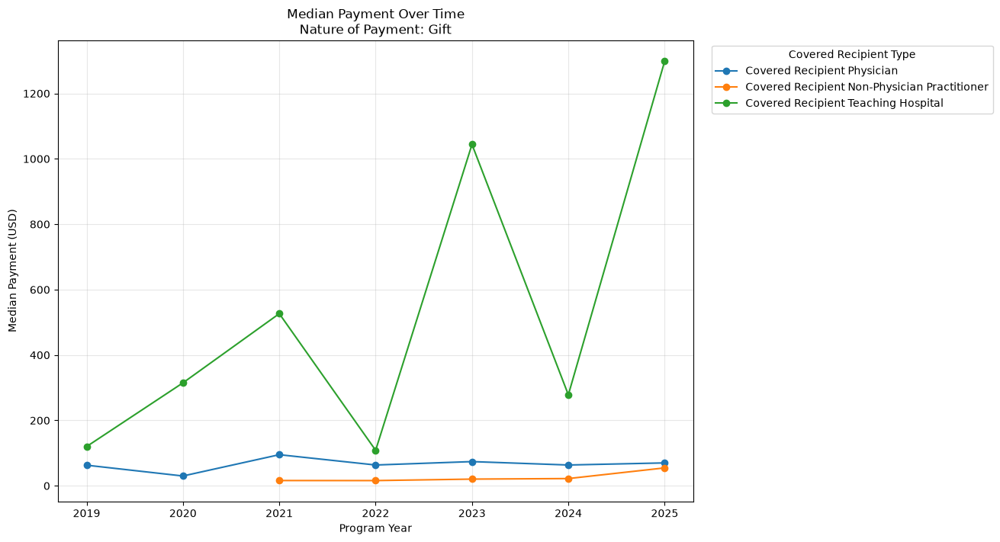

In [64]:
# 1. Nature of Payment × Covered Recipient Type → Payment Amount

nature_col = "Nature_of_Payment_or_Transfer_of_Value"
recipient_col = "Covered_Recipient_Type"
payment_col = "Total_Amount_of_Payment_USDollars"

data = (
    lf
    .select([
        pl.col(nature_col).cast(pl.String),
        pl.col(recipient_col).cast(pl.String),
        pl.col(payment_col)
    ])
    .filter(pl.col(payment_col) > 0)
    .drop_nulls()
    .group_by([nature_col, recipient_col])
    .agg([
        pl.len().alias("Count"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.col(payment_col).mean().alias("Mean_Payment"),
        pl.col(payment_col).median().alias("Median_Payment"),
        pl.col(payment_col).std().alias("Std_Payment"),
        pl.col(payment_col).quantile(0.25).alias("Q1"),
        pl.col(payment_col).quantile(0.75).alias("Q3")
    ])
    .collect()
)

print("\n" + "=" * 100)
print("1. NATURE OF PAYMENT × COVERED RECIPIENT TYPE → PAYMENT AMOUNT")
print("=" * 100)

print(data.sort("Median_Payment", descending=True))

top_natures = (
    data
    .group_by(nature_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(10)[nature_col]
    .to_list()
)

plot_data = data.filter(
    pl.col(nature_col).is_in(top_natures)
)

pivot = (
    plot_data
    .pivot(
        on=recipient_col,
        index=nature_col,
        values="Median_Payment",
        aggregate_function="first"
    )
)

matrix = pivot.drop(nature_col).to_numpy()

fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

im = ax.imshow(
    matrix,
    aspect="auto"
)

ax.set_xticks(range(len(pivot.columns) - 1))
ax.set_xticklabels(
    pivot.columns[1:],
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(
    pivot[nature_col].to_list()
)

ax.set_xlabel("Covered Recipient Type")
ax.set_ylabel("Nature of Payment")
ax.set_title(
    "Median Payment by Nature of Payment and Covered Recipient Type"
)

fig.colorbar(
    im,
    ax=ax,
    label="Median Payment (USD)"
)

plt.show()
plt.close(fig)


# 2. Nature of Payment × Product Type → Payment Amount

product_type_col = (
    "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
)

data = (
    lf
    .select([
        pl.col(nature_col).cast(pl.String),
        pl.col(product_type_col).cast(pl.String),
        pl.col(payment_col)
    ])
    .filter(pl.col(payment_col) > 0)
    .drop_nulls()
    .group_by([nature_col, product_type_col])
    .agg([
        pl.len().alias("Count"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.col(payment_col).mean().alias("Mean_Payment"),
        pl.col(payment_col).median().alias("Median_Payment"),
        pl.col(payment_col).std().alias("Std_Payment"),
        pl.col(payment_col).quantile(0.25).alias("Q1"),
        pl.col(payment_col).quantile(0.75).alias("Q3")
    ])
    .collect()
)

print("\n" + "=" * 100)
print("2. NATURE OF PAYMENT × PRODUCT TYPE → PAYMENT AMOUNT")
print("=" * 100)

print(data.sort("Median_Payment", descending=True))

top_natures = (
    data
    .group_by(nature_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(10)[nature_col]
    .to_list()
)

plot_data = data.filter(
    pl.col(nature_col).is_in(top_natures)
)

pivot = (
    plot_data
    .pivot(
        on=product_type_col,
        index=nature_col,
        values="Median_Payment",
        aggregate_function="first"
    )
)

matrix = pivot.drop(nature_col).to_numpy()

fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

im = ax.imshow(
    matrix,
    aspect="auto"
)

ax.set_xticks(range(len(pivot.columns) - 1))
ax.set_xticklabels(
    pivot.columns[1:],
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(
    pivot[nature_col].to_list()
)

ax.set_xlabel("Product Type")
ax.set_ylabel("Nature of Payment")
ax.set_title(
    "Median Payment by Nature of Payment and Product Type"
)

fig.colorbar(
    im,
    ax=ax,
    label="Median Payment (USD)"
)

plt.show()
plt.close(fig)


# 3. Nature of Payment × Covered Recipient Type × Product Type

data = (
    lf
    .select([
        pl.col(nature_col).cast(pl.String),
        pl.col(recipient_col).cast(pl.String),
        pl.col(product_type_col).cast(pl.String)
    ])
    .drop_nulls()
    .group_by([
        nature_col,
        recipient_col,
        product_type_col
    ])
    .agg(
        pl.len().alias("Count")
    )
    .collect()
)

print("\n" + "=" * 100)
print("3. NATURE OF PAYMENT × COVERED RECIPIENT TYPE × PRODUCT TYPE")
print("=" * 100)

print(
    data
    .sort("Count", descending=True)
    .head(50)
)

top_natures = (
    data
    .group_by(nature_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(8)[nature_col]
    .to_list()
)

top_recipients = (
    data
    .group_by(recipient_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(5)[recipient_col]
    .to_list()
)

plot_data = data.filter(
    pl.col(nature_col).is_in(top_natures) &
    pl.col(recipient_col).is_in(top_recipients)
)

for recipient in top_recipients:

    subset = plot_data.filter(
        pl.col(recipient_col) == recipient
    )

    if len(subset) == 0:
        continue

    totals = (
        subset
        .group_by(nature_col)
        .agg(pl.col("Count").sum().alias("Total"))
    )

    subset = (
        subset
        .join(totals, on=nature_col)
        .with_columns(
            (
                pl.col("Count") /
                pl.col("Total") *
                100
            ).alias("Percentage")
        )
    )

    pivot = (
        subset
        .pivot(
            on=product_type_col,
            index=nature_col,
            values="Percentage",
            aggregate_function="first"
        )
        .fill_null(0)
    )

    categories = pivot[nature_col].to_list()

    fig, ax = plt.subplots(
        figsize=(14, 8),
        constrained_layout=True
    )

    bottom = np.zeros(
        len(categories)
    )

    for product_type in pivot.columns[1:]:

        values = pivot[product_type].to_numpy()

        ax.barh(
            categories,
            values,
            left=bottom,
            label=str(product_type)
        )

        bottom += values

    ax.set_xlabel(
        "Percentage within Nature of Payment (%)"
    )

    ax.set_ylabel(
        "Nature of Payment"
    )

    ax.set_title(
        f"Nature of Payment × Product Type\n"
        f"Recipient Type: {recipient}"
    )

    ax.set_xlim(0, 100)

    ax.grid(
        axis="x",
        alpha=0.3
    )

    ax.legend(
        title="Product Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.show()
    plt.close(fig)


# 4. Recipient State × Nature of Payment → Payment Amount

state_col = "Recipient_State"

data = (
    lf
    .select([
        pl.col(state_col).cast(pl.String),
        pl.col(nature_col).cast(pl.String),
        pl.col(payment_col)
    ])
    .filter(pl.col(payment_col) > 0)
    .drop_nulls()
    .group_by([
        state_col,
        nature_col
    ])
    .agg([
        pl.len().alias("Count"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.col(payment_col).median().alias("Median_Payment"),
        pl.col(payment_col).mean().alias("Mean_Payment")
    ])
    .collect()
)

print("\n" + "=" * 100)
print("4. RECIPIENT STATE × NATURE OF PAYMENT → PAYMENT AMOUNT")
print("=" * 100)

print(
    data
    .sort("Median_Payment", descending=True)
    .head(50)
)

top_states = (
    data
    .group_by(state_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(15)[state_col]
    .to_list()
)

top_natures = (
    data
    .group_by(nature_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(10)[nature_col]
    .to_list()
)

plot_data = data.filter(
    pl.col(state_col).is_in(top_states) &
    pl.col(nature_col).is_in(top_natures)
)

pivot = (
    plot_data
    .pivot(
        on=nature_col,
        index=state_col,
        values="Median_Payment",
        aggregate_function="first"
    )
)

matrix = pivot.drop(state_col).to_numpy()

fig, ax = plt.subplots(
    figsize=(15, 9),
    constrained_layout=True
)

im = ax.imshow(
    matrix,
    aspect="auto"
)

ax.set_xticks(range(len(pivot.columns) - 1))
ax.set_xticklabels(
    pivot.columns[1:],
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(
    pivot[state_col].to_list()
)

ax.set_xlabel("Nature of Payment")
ax.set_ylabel("Recipient State")

ax.set_title(
    "Median Payment by Recipient State and Nature of Payment"
)

fig.colorbar(
    im,
    ax=ax,
    label="Median Payment (USD)"
)

plt.show()
plt.close(fig)


# 5. Year × Nature of Payment × Covered Recipient Type → Payment Amount

year_col = "Program_Year"

data = (
    lf
    .select([
        pl.col(year_col),
        pl.col(nature_col).cast(pl.String),
        pl.col(recipient_col).cast(pl.String),
        pl.col(payment_col)
    ])
    .filter(pl.col(payment_col) > 0)
    .drop_nulls()
    .group_by([
        year_col,
        nature_col,
        recipient_col
    ])
    .agg([
        pl.len().alias("Count"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.col(payment_col).mean().alias("Mean_Payment"),
        pl.col(payment_col).median().alias("Median_Payment")
    ])
    .collect()
)

print("\n" + "=" * 100)
print("5. YEAR × NATURE OF PAYMENT × COVERED RECIPIENT TYPE → PAYMENT AMOUNT")
print("=" * 100)

print(
    data
    .sort(
        ["Year" if "Year" in data.columns else year_col, "Median_Payment"],
        descending=[False, True]
    )
)

# Select the most common payment natures
top_natures = (
    data
    .group_by(nature_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(6)[nature_col]
    .to_list()
)

# Select major recipient types
top_recipients = (
    data
    .group_by(recipient_col)
    .agg(pl.col("Count").sum().alias("Total_Count"))
    .sort("Total_Count", descending=True)
    .head(4)[recipient_col]
    .to_list()
)

plot_data = data.filter(
    pl.col(nature_col).is_in(top_natures) &
    pl.col(recipient_col).is_in(top_recipients)
)

# Create one line for each Nature × Recipient combination
for nature in top_natures:

    fig, ax = plt.subplots(
        figsize=(13, 7),
        constrained_layout=True
    )

    for recipient in top_recipients:

        subset = (
            plot_data
            .filter(
                (pl.col(nature_col) == nature) &
                (pl.col(recipient_col) == recipient)
            )
            .sort(year_col)
        )

        if len(subset) == 0:
            continue

        ax.plot(
            subset[year_col].to_list(),
            subset["Median_Payment"].to_list(),
            marker="o",
            label=str(recipient)
        )

    ax.set_xlabel("Program Year")
    ax.set_ylabel("Median Payment (USD)")

    ax.set_title(
        f"Median Payment Over Time\n"
        f"Nature of Payment: {nature}"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        title="Covered Recipient Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.show()
    plt.close(fig)

# Multivariate Analysis

Multivariate analysis examines the relationship between multiple variables simultaneously.  
In this analysis, payment amount was studied together with payment nature, recipient type, product type, recipient state, and program year.

---

## 1. Nature of Payment × Covered Recipient Type

Median payment amounts were compared across different **Nature of Payment** categories and **Covered Recipient Types**.

### Observations

- **Royalty or License** has substantially higher median payments than most other payment categories.
- **Consulting Fee** and compensation-related payments also show relatively high median payments.
- **Honoraria** occupies an intermediate range.
- **Gift, Food and Beverage, Education, and Travel and Lodging** generally have much lower median payments.
- The median payment for the same payment nature differs across recipient types.
- The differences are particularly noticeable for higher-value payment categories.

### Interpretation

Payment amount is associated with both the **nature of payment** and the **type of recipient**.  
Therefore, examining either variable independently would hide some of the variation in payment amounts.

---

## 2. Nature of Payment × Product Type

Median payment amounts were examined across payment nature and product type.

### Observations

- **Royalty or License** again shows substantially higher median payments.
- Different product types show different median payment levels within the same payment category.
- Most lower-value payment categories remain concentrated at relatively small median amounts.
- Some combinations of payment nature and product type have considerably higher medians than others.

### Interpretation

The relationship between payment nature and payment amount depends partly on the **type of product involved**.

This demonstrates an interaction between:

**Nature of Payment → Product Type → Payment Amount**

---

## 3. Nature of Payment × Product Type × Non-Physician Practitioner

The product composition of payments was examined specifically for **Covered Recipient Non-Physician Practitioners**.

### Observations

- **Drug** represents a large proportion of several payment categories.
- **Gift** is predominantly associated with Drug.
- **Royalty or License** is predominantly associated with Device.
- **Travel and Lodging** contains substantial Device, Drug, and Biological components.
- **Consulting Fee** has a more mixed composition involving Drug, Device, and Biological products.
- **Food and Beverage** is primarily associated with Drug.
- **Honoraria** is also strongly dominated by Drug.

### Interpretation

The product type associated with a payment varies considerably according to the **nature of payment**.

For example:

- Royalty or License → predominantly Device
- Gift → predominantly Drug
- Honoraria → predominantly Drug

---

## 4. Nature of Payment × Product Type × Physician

The same relationship was examined for **Covered Recipient Physicians**.

### Observations

- **Drug** dominates many payment categories.
- Honoraria, Education, and compensation-related payments contain large Drug proportions.
- **Gift** contains a large Device component.
- **Consulting Fee** has a substantial Device component.
- **Royalty or License** is predominantly associated with Device.
- Food and Beverage contains substantial Drug and Device components.
- Travel and Lodging contains both Drug and Device components.

### Interpretation

The product composition differs from that observed for non-physician practitioners.

Thus, the relationship between **Nature of Payment and Product Type changes according to Recipient Type**.

---

## 5. Nature of Payment × Product Type × Teaching Hospital

The product composition was also examined for **Covered Recipient Teaching Hospitals**.

### Observations

- **Device** dominates most of the displayed payment categories.
- Travel and Lodging, Gift, and Royalty or License have particularly large Device proportions.
- Several compensation-related categories are also strongly Device-oriented.
- Drug and Biological components are generally much smaller than Device.
- Food and Beverage is also predominantly associated with Device.

### Interpretation

Teaching hospitals have a substantially different product composition compared with physicians and non-physician practitioners.

This demonstrates that:

**Recipient Type + Nature of Payment → Product Type Composition**

---

## 6. Recipient State × Nature of Payment

Median payment amounts were compared across recipient states and payment categories.

### Observations

- **Royalty or License** has the highest median payments across most states.
- Some states show noticeably higher Royalty or License medians than others.
- Honoraria, Consulting Fee, and compensation-related payments occupy intermediate ranges.
- Gift, Travel and Lodging, and Food and Beverage generally have lower medians.
- Differences between states exist, but the differences between payment categories are generally much larger.

### Interpretation

Recipient geography contributes to variation in payment amounts, but **Nature of Payment appears to produce a stronger separation in median payment amounts than state** in this comparison.

---

# 7. Median Payment Over Time — Compensation for Services

Median payments from 2019–2025 were compared across recipient types.

### Observations

- Physician payments start relatively high in 2019, decline in 2020, and recover afterward.
- Physician median payments increase notably around 2022 and remain relatively high through 2025.
- Non-physician practitioner payments are lower and become relatively stable after 2022.
- Teaching hospital payments show much larger year-to-year variation.
- Teaching hospital payments decline substantially in 2022 before increasing again in subsequent years.

### Interpretation

The effect of **Recipient Type** is substantial, while payment levels also vary over time.

---

# 8. Median Payment Over Time — Consulting Fee

### Observations

- Teaching hospitals have substantially higher median Consulting Fee payments than the other recipient types.
- Teaching hospital medians increase strongly from 2019 to 2021.
- A substantial decline occurs around 2023.
- Values increase again during 2024–2025.
- Physician median payments remain comparatively stable.
- Non-physician practitioner payments are considerably lower than teaching hospital payments.

### Interpretation

Consulting Fee payments show a strong interaction between **Recipient Type and Program Year**, with teaching hospitals showing particularly large temporal variation.

---

# 9. Median Payment Over Time — Education

### Observations

- Teaching hospitals have substantially higher median Education payments.
- Teaching hospital medians remain around $900–$1,000 for most years.
- A noticeable increase occurs in 2025.
- Physician and non-physician practitioner medians remain much lower.
- The physician and non-physician practitioner series are relatively close compared with the teaching-hospital series.

### Interpretation

Recipient type produces a strong difference in Education payment amounts, particularly between teaching hospitals and individual recipients.

---

# 10. Median Payment Over Time — Food and Beverage

### Observations

- Physician median payments increase gradually from 2019 to 2025.
- Non-physician practitioner payments follow a similar low and relatively stable pattern.
- Teaching hospital payments are substantially higher.
- Teaching hospital payments peak around 2020 and then decline considerably.
- A small increase is visible again in 2025.

### Interpretation

Food and Beverage payments show relatively stable behavior for physicians and non-physician practitioners, while teaching hospitals exhibit greater variation over time.

---

# 11. Median Payment Over Time — Gift

### Observations

- Physician and non-physician practitioner medians remain relatively low.
- Teaching hospital medians are substantially higher.
- Teaching hospital payments fluctuate considerably across the years.
- Large increases are visible around 2023 and 2025.
- The teaching hospital series also shows substantial decreases between some consecutive years.

### Interpretation

Gift payments show a strong difference between recipient types, with teaching hospitals displaying considerably greater temporal variation.

---

# 12. Median Payment Over Time — Travel and Lodging

### Observations

- Physician median payments remain relatively stable, generally around the same range throughout the period.
- Non-physician practitioner payments are slightly lower but follow a similar stable pattern.
- Teaching hospital payments are substantially higher.
- Teaching hospital payments increase strongly through 2023.
- A substantial decline occurs during 2024 and 2025.

### Interpretation

Travel and Lodging payments show a strong association with Recipient Type, with teaching hospitals having substantially higher and more variable median payments.

---

# Overall Multivariate Findings

The multivariate analysis reveals several important patterns.

### 1. Nature of Payment is strongly associated with payment amount

High-value categories such as **Royalty or License, Consulting Fee, and compensation-related payments** have substantially different median payments from categories such as **Gift, Food and Beverage, Education, and Travel and Lodging**.

### 2. Recipient Type modifies payment patterns

The same payment category can have very different median payments for:

- Covered Recipient Physician
- Covered Recipient Non-Physician Practitioner
- Covered Recipient Teaching Hospital

Teaching hospitals are particularly distinct in several payment categories.

### 3. Product Type depends on both payment nature and recipient type

The product associated with a payment is not distributed uniformly.

The relationship between **Nature of Payment and Product Type changes depending on Recipient Type**.

### 4. Geographic variation exists

Recipient State contributes to differences in median payments, but the variation between payment categories is generally much larger than the state-to-state variation within a payment category.

### 5. Payment patterns change over time

Median payments vary across Program Years, with teaching hospitals showing particularly large year-to-year changes for several payment categories.

### 6. Multivariate analysis reveals relationships hidden by univariate analysis

Looking at one variable at a time would not reveal the combined patterns between:

**Payment Nature + Recipient Type + Product Type + State + Program Year**

These interactions provide a more complete view of how payments vary across the dataset.

---

## Important Consideration

The temporal plots show changes in median payment, but a change in median does not by itself establish why the change occurred.

Large differences may also be affected by the number of observations in each combination of:

**Program Year × Recipient Type × Nature of Payment**

Therefore, group counts should be considered alongside medians when interpreting unusually large year-to-year changes.

# 9. Time-series analysis

- Trend
- Seasonality
- Cycles
- Growth rates
- Rolling averages
- Rolling volatility
- Year/month/quarter comparisons
- Before/after events

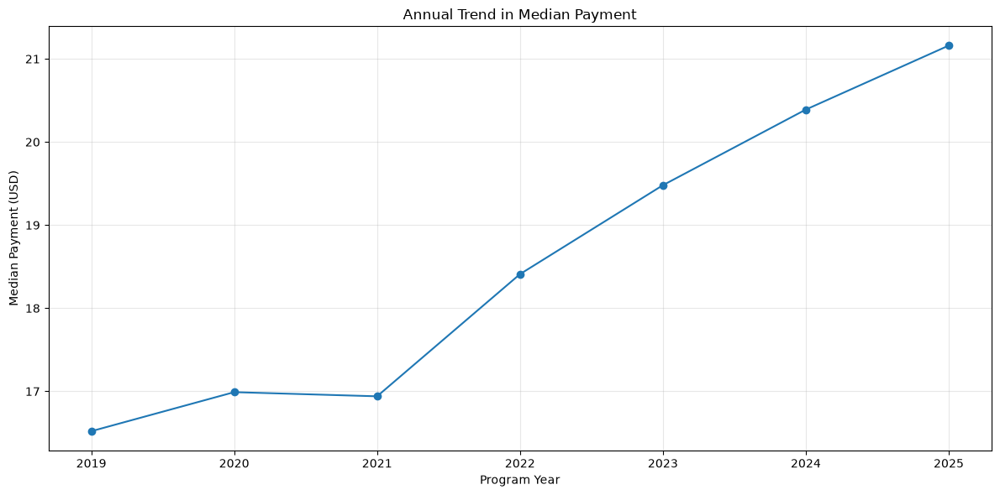

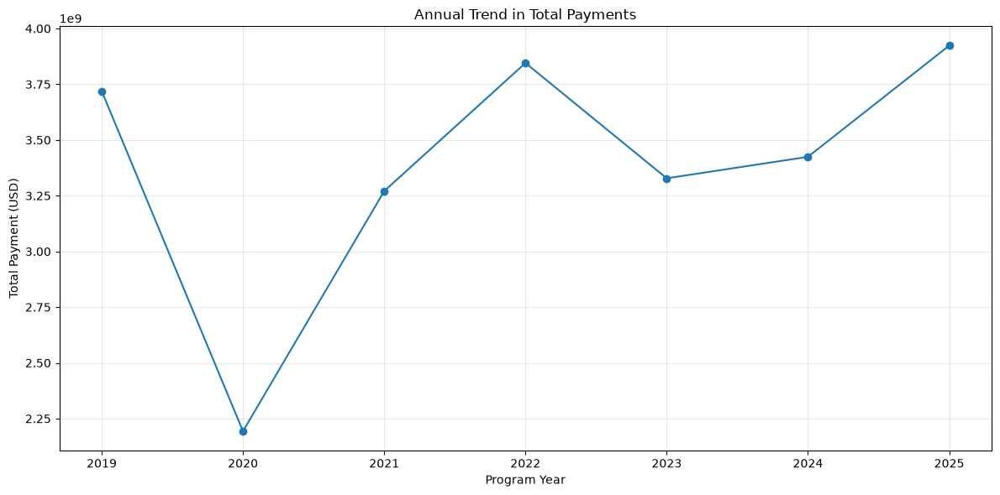

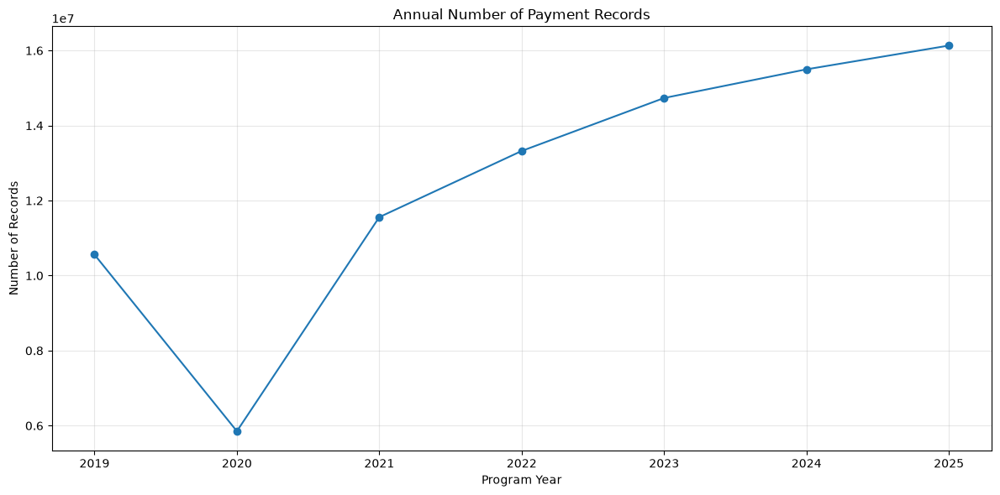

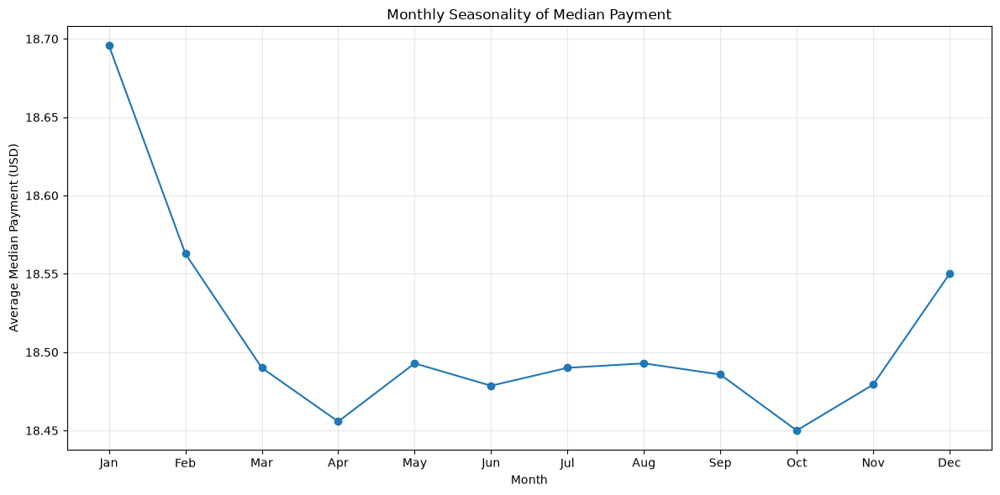

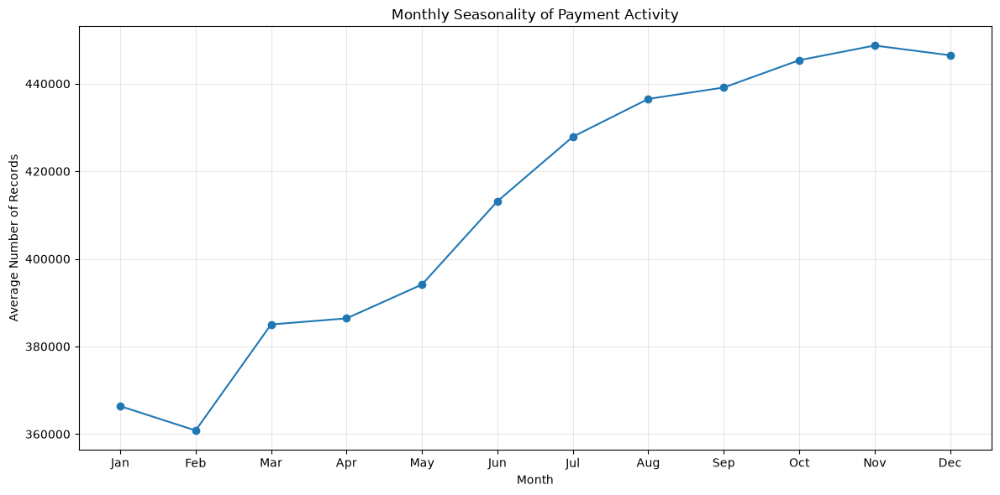

...

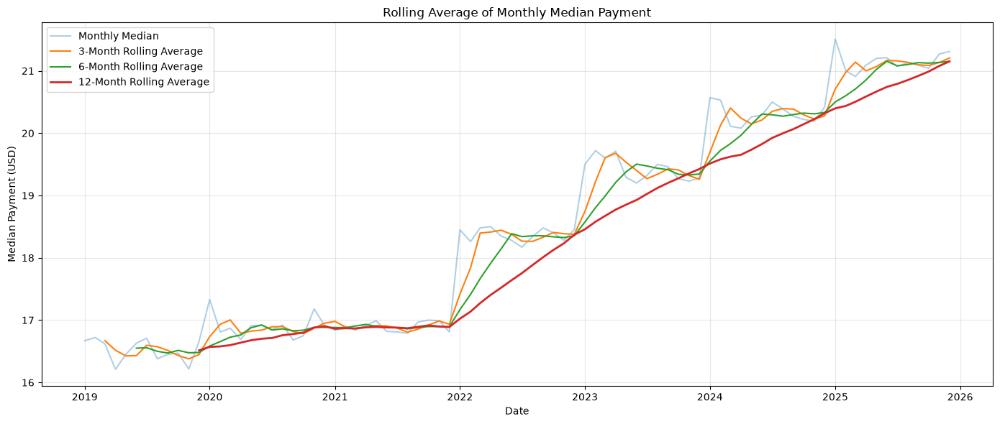

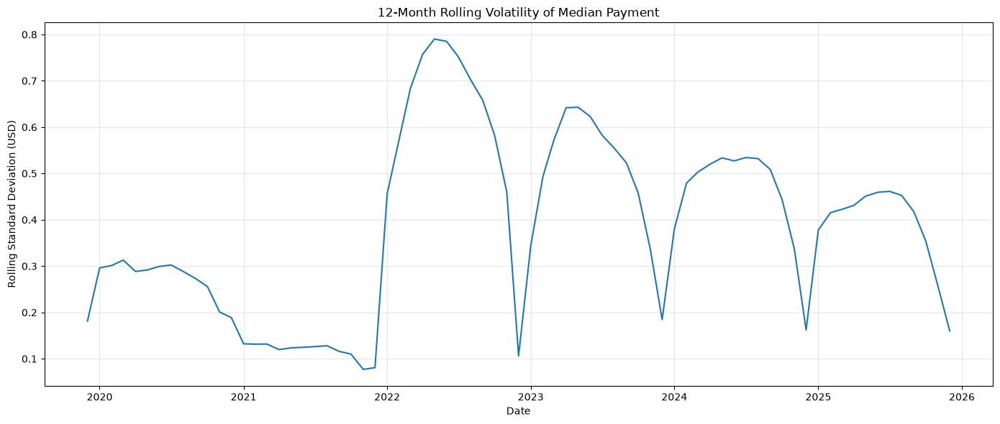

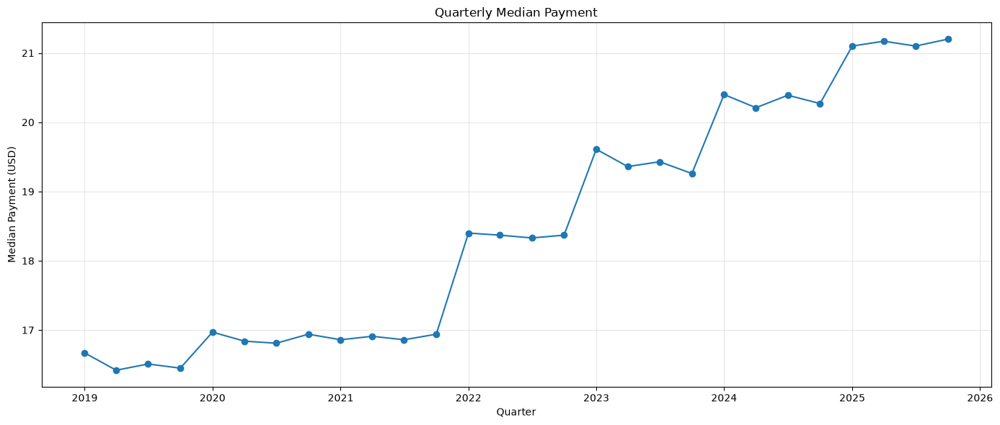

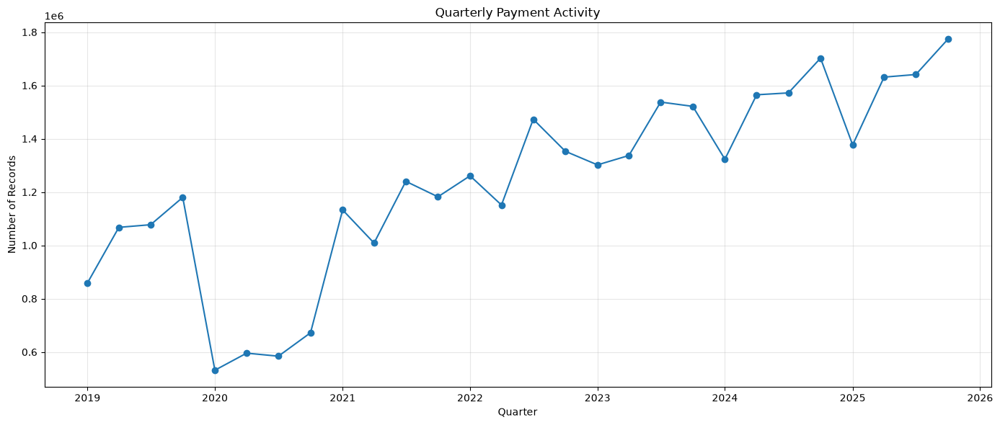

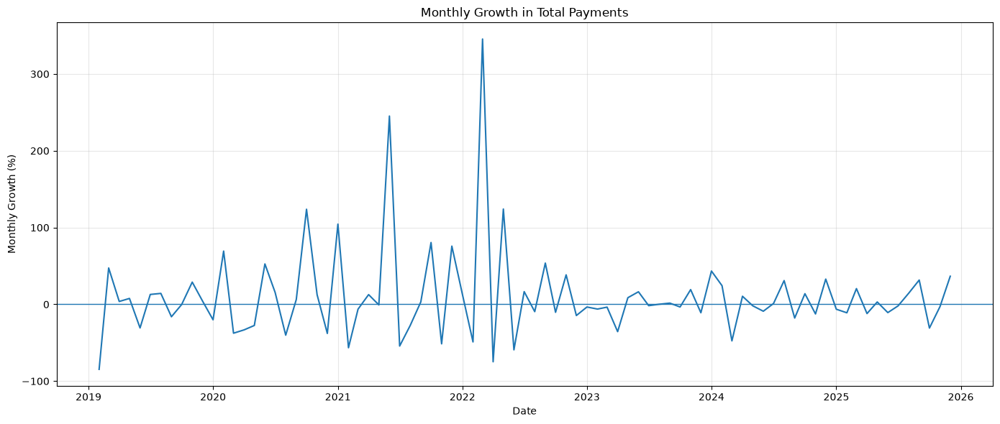


YEARLY TIME-SERIES SUMMARY
shape: (7, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ Program_Year ┆ Median_Paym ┆ Total_Payme ┆ Number_of_P ┆ Median_Paym ┆ Total_Payme ┆ Number_of_P │
│ ---          ┆ ent         ┆ nt          ┆ ayments     ┆ ent_Growth_ ┆ nt_Growth_% ┆ ayments_Gro │
│ u16          ┆ ---         ┆ ---         ┆ ---         ┆ %           ┆ ---         ┆ wth_%       │
│              ┆ f64         ┆ f64         ┆ u32         ┆ ---         ┆ f64         ┆ ---         │
│              ┆             ┆             ┆             ┆ f64         ┆             ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 2019         ┆ 16.52       ┆ 3.7193e9    ┆ 10558933    ┆ null        ┆ null        ┆ null        │
│ 2020         ┆ 16.99       ┆ 2.1934e9    ┆ 5851438     ┆ 2.845036    ┆ -41.026036  ┆ -44.583056  │
│ 2021         ┆ 16.94       ┆ 3.2707e9    ┆ 1155

In [66]:
# TIME-SERIES ANALYSIS

payment_col = "Total_Amount_of_Payment_USDollars"
date_col = "Date_of_Payment"
year_col = "Program_Year"

# Prepare monthly data
monthly = (
    lf
    .select([
        pl.col(date_col).cast(pl.Date, strict=False).alias("Date"),
        pl.col(payment_col)
    ])
    .filter(
        pl.col("Date").is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .with_columns(
        pl.col("Date").dt.truncate("1mo").alias("Month")
    )
    .group_by("Month")
    .agg([
        pl.col(payment_col).median().alias("Median_Payment"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.len().alias("Number_of_Payments")
    ])
    .sort("Month")
    .collect()
)

# Prepare quarterly data
quarterly = (
    lf
    .select([
        pl.col(date_col).cast(pl.Date, strict=False).alias("Date"),
        pl.col(payment_col)
    ])
    .filter(
        pl.col("Date").is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .with_columns(
        pl.col("Date").dt.truncate("3mo").alias("Quarter")
    )
    .group_by("Quarter")
    .agg([
        pl.col(payment_col).median().alias("Median_Payment"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.len().alias("Number_of_Payments")
    ])
    .sort("Quarter")
    .collect()
)

# Prepare yearly data
yearly = (
    lf
    .select([
        pl.col(year_col),
        pl.col(payment_col)
    ])
    .filter(
        pl.col(year_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .group_by(year_col)
    .agg([
        pl.col(payment_col).median().alias("Median_Payment"),
        pl.col(payment_col).sum().alias("Total_Payment"),
        pl.len().alias("Number_of_Payments")
    ])
    .sort(year_col)
    .collect()
)

# Add growth rates
yearly = yearly.with_columns([
    (
        pl.col("Median_Payment").pct_change() * 100
    ).alias("Median_Payment_Growth_%"),

    (
        pl.col("Total_Payment").pct_change() * 100
    ).alias("Total_Payment_Growth_%"),

    (
        pl.col("Number_of_Payments").pct_change() * 100
    ).alias("Number_of_Payments_Growth_%")
])

monthly = monthly.with_columns([
    (
        pl.col("Median_Payment").pct_change() * 100
    ).alias("Median_Payment_Growth_%"),

    (
        pl.col("Total_Payment").pct_change() * 100
    ).alias("Total_Payment_Growth_%")
])

# Rolling averages and volatility
monthly = monthly.with_columns([
    pl.col("Median_Payment")
    .rolling_mean(window_size=3)
    .alias("Median_3M_Rolling_Average"),

    pl.col("Median_Payment")
    .rolling_mean(window_size=6)
    .alias("Median_6M_Rolling_Average"),

    pl.col("Median_Payment")
    .rolling_mean(window_size=12)
    .alias("Median_12M_Rolling_Average"),

    pl.col("Median_Payment")
    .rolling_std(window_size=12)
    .alias("Median_12M_Rolling_Volatility")
])

# 1. Overall yearly trend — median payment
plt.figure(figsize=(12, 6))

plt.plot(
    yearly[year_col].to_list(),
    yearly["Median_Payment"].to_list(),
    marker="o"
)

plt.xlabel("Program Year")
plt.ylabel("Median Payment (USD)")
plt.title("Annual Trend in Median Payment")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Overall yearly trend — total payment
plt.figure(figsize=(12, 6))

plt.plot(
    yearly[year_col].to_list(),
    yearly["Total_Payment"].to_list(),
    marker="o"
)

plt.xlabel("Program Year")
plt.ylabel("Total Payment (USD)")
plt.title("Annual Trend in Total Payments")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Number of payments over time
plt.figure(figsize=(12, 6))

plt.plot(
    yearly[year_col].to_list(),
    yearly["Number_of_Payments"].to_list(),
    marker="o"
)

plt.xlabel("Program Year")
plt.ylabel("Number of Records")
plt.title("Annual Number of Payment Records")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Monthly seasonality — median payment
monthly_seasonality = (
    monthly
    .with_columns(
        pl.col("Month").dt.month().alias("Month_Number")
    )
    .group_by("Month_Number")
    .agg(
        pl.col("Median_Payment").mean().alias("Average_Median_Payment")
    )
    .sort("Month_Number")
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality["Month_Number"].to_list(),
    monthly_seasonality["Average_Median_Payment"].to_list(),
    marker="o"
)

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.xlabel("Month")
plt.ylabel("Average Median Payment (USD)")
plt.title("Monthly Seasonality of Median Payment")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Monthly seasonality — number of payments
monthly_count_seasonality = (
    monthly
    .with_columns(
        pl.col("Month").dt.month().alias("Month_Number")
    )
    .group_by("Month_Number")
    .agg(
        pl.col("Number_of_Payments").mean().alias("Average_Number_of_Payments")
    )
    .sort("Month_Number")
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_count_seasonality["Month_Number"].to_list(),
    monthly_count_seasonality["Average_Number_of_Payments"].to_list(),
    marker="o"
)

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.xlabel("Month")
plt.ylabel("Average Number of Records")
plt.title("Monthly Seasonality of Payment Activity")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Year-over-year growth
plt.figure(figsize=(12, 6))

plt.plot(
    yearly[year_col].to_list(),
    yearly["Total_Payment_Growth_%"].to_list(),
    marker="o",
    label="Total Payment"
)

plt.plot(
    yearly[year_col].to_list(),
    yearly["Median_Payment_Growth_%"].to_list(),
    marker="o",
    label="Median Payment"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Program Year")
plt.ylabel("Growth Rate (%)")
plt.title("Year-over-Year Growth in Payments")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Rolling averages
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["Month"].to_list(),
    monthly["Median_Payment"].to_list(),
    alpha=0.35,
    label="Monthly Median"
)

plt.plot(
    monthly["Month"].to_list(),
    monthly["Median_3M_Rolling_Average"].to_list(),
    label="3-Month Rolling Average"
)

plt.plot(
    monthly["Month"].to_list(),
    monthly["Median_6M_Rolling_Average"].to_list(),
    label="6-Month Rolling Average"
)

plt.plot(
    monthly["Month"].to_list(),
    monthly["Median_12M_Rolling_Average"].to_list(),
    linewidth=2,
    label="12-Month Rolling Average"
)

plt.xlabel("Date")
plt.ylabel("Median Payment (USD)")
plt.title("Rolling Average of Monthly Median Payment")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Rolling volatility
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["Month"].to_list(),
    monthly["Median_12M_Rolling_Volatility"].to_list()
)

plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation (USD)")
plt.title("12-Month Rolling Volatility of Median Payment")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Quarterly comparison — median payment
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly["Quarter"].to_list(),
    quarterly["Median_Payment"].to_list(),
    marker="o"
)

plt.xlabel("Quarter")
plt.ylabel("Median Payment (USD)")
plt.title("Quarterly Median Payment")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Quarterly comparison — payment activity
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly["Quarter"].to_list(),
    quarterly["Number_of_Payments"].to_list(),
    marker="o"
)

plt.xlabel("Quarter")
plt.ylabel("Number of Records")
plt.title("Quarterly Payment Activity")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11. Monthly growth rate
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["Month"].to_list(),
    monthly["Total_Payment_Growth_%"].to_list()
)

plt.axhline(0, linewidth=1)

plt.xlabel("Date")
plt.ylabel("Monthly Growth (%)")
plt.title("Monthly Growth in Total Payments")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12. Before / after analysis
# Set an event date only when a specific event is being investigated.
EVENT_DATE = None

if EVENT_DATE is not None:

    event_date = pl.lit(EVENT_DATE).cast(pl.Date)

    before = (
        monthly
        .filter(pl.col("Month") < event_date)
        .select([
            pl.col("Median_Payment").mean().alias("Average_Median_Payment"),
            pl.col("Total_Payment").mean().alias("Average_Total_Payment"),
            pl.col("Number_of_Payments").mean().alias("Average_Number_of_Payments")
        ])
        .with_columns(pl.lit("Before").alias("Period"))
    )

    after = (
        monthly
        .filter(pl.col("Month") >= event_date)
        .select([
            pl.col("Median_Payment").mean().alias("Average_Median_Payment"),
            pl.col("Total_Payment").mean().alias("Average_Total_Payment"),
            pl.col("Number_of_Payments").mean().alias("Average_Number_of_Payments")
        ])
        .with_columns(pl.lit("After").alias("Period"))
    )

    before_after = pl.concat([before, after])

    print("\nBefore / After Event Analysis")
    print(before_after)

# Display yearly summary
print("\nYEARLY TIME-SERIES SUMMARY")
print(yearly)

# Display quarterly summary
print("\nQUARTERLY TIME-SERIES SUMMARY")
print(quarterly)

# Display monthly summary
print("\nMONTHLY TIME-SERIES SUMMARY")
print(monthly)

# Time-Series Analysis

Time-series analysis examines how variables change over time and helps identify long-term trends, seasonal patterns, growth rates, fluctuations, and changes in variability.

For this dataset, the analysis was performed using `Program_Year` and `Date_of_Payment`, focusing primarily on payment amounts and payment activity.

The analysis includes:

- Annual trends
- Monthly seasonality
- Year-over-year growth
- Rolling averages
- Rolling volatility
- Quarterly comparisons
- Monthly growth
- Changes in payment activity over time

---

## Annual Trend in Median Payment

The annual median payment shows a clear long-term upward trend.

Approximate median payment values are:

| Program Year | Median Payment (USD) |
|---|---:|
| 2019 | 16.5 |
| 2020 | 17.0 |
| 2021 | 16.9 |
| 2022 | 18.4 |
| 2023 | 19.5 |
| 2024 | 20.4 |
| 2025 | 21.2 |

### Observations

From 2019 through 2021, the median payment remains relatively stable, staying close to \$17.

A noticeable increase occurs in 2022, when the median rises to approximately \$18.4.

The upward trend continues through:

- approximately \$19.5 in 2023
- approximately \$20.4 in 2024
- approximately \$21.2 in 2025

The increase is therefore not limited to a single year. The median payment continues to move upward from 2022 through 2025.

### Interpretation

The median represents the typical payment more robustly than the mean because extremely large payments have less influence on it.

The time series therefore indicates that the typical payment amount has increased substantially over the later years of the dataset.

The relatively flat period from 2019–2021 followed by a sustained increase from 2022 onward suggests a change in the level of typical payments during the later period.

---

## Annual Trend in Total Payments

The annual total payment shows a much more volatile pattern than the median payment.

Approximate total payment values are:

| Program Year | Total Payments |
|---|---:|
| 2019 | \$3.72B |
| 2020 | \$2.19B |
| 2021 | \$3.27B |
| 2022 | \$3.85B |
| 2023 | \$3.33B |
| 2024 | \$3.42B |
| 2025 | \$3.92B |

### Observations

The total payment value decreases sharply from 2019 to 2020.

This is followed by a strong recovery in 2021 and another increase in 2022.

The total reaches approximately \$3.85 billion in 2022.

However, total payments decrease again in 2023 before increasing in 2024 and 2025.

The highest observed annual total is approximately \$3.92 billion in 2025.

### Interpretation

Unlike median payment, total payment does not follow a smooth upward trend.

It is affected by both:

- the number of payment records
- the size and composition of individual payments

Therefore, changes in total payment cannot be interpreted simply as changes in the typical payment.

---

## Annual Number of Payment Records

The number of payment records shows a strong increase after the low point observed in 2020.

Approximate record counts are:

| Program Year | Number of Records |
|---|---:|
| 2019 | 10.6M |
| 2020 | 5.9M |
| 2021 | 11.6M |
| 2022 | 13.3M |
| 2023 | 14.7M |
| 2024 | 15.5M |
| 2025 | 16.1M |

### Observations

The number of records decreases substantially in 2020.

After 2020, record volume increases every year in the observed period.

The increase is particularly consistent from 2021 onward:

- 2021 → approximately 11.6 million
- 2022 → approximately 13.3 million
- 2023 → approximately 14.7 million
- 2024 → approximately 15.5 million
- 2025 → approximately 16.1 million

### Interpretation

The dataset contains substantially more payment records in the later years than in the earlier years.

The 2020 reduction is particularly prominent and should be treated as an important feature of the time series rather than as part of the otherwise increasing post-2020 trend.

---

## Relationship Between Payment Volume and Payment Amount

Comparing the annual record count with total payments and median payment reveals an important pattern.

After 2020:

- The number of records generally increases.
- The median payment generally increases.
- Total payment does not increase consistently.

For example, from 2022 to 2023:

- Record count increases.
- Median payment increases.
- Total payment decreases.

This demonstrates that total payment value is not determined solely by the number of records.

Changes in the distribution and composition of payment amounts also contribute to changes in the total monetary value.

### Key observation

The three measures capture different aspects of the dataset:

| Measure | What it represents |
|---|---|
| Number of records | Payment activity/volume |
| Median payment | Typical payment size |
| Total payment | Overall monetary value |

The different patterns across these measures provide more information than any single time-series measure alone.

---

# Monthly Seasonality of Median Payment

Monthly seasonality was examined by grouping payment records by month and calculating the median payment for each month across the available years.

The monthly median payment remains within a relatively narrow range of approximately \$18.45–\$18.70.

### Observations

January has the highest observed monthly median, at approximately \$18.69.

The median then decreases through the early months of the year.

The lowest values occur around April and October, at approximately \$18.45.

The median remains relatively stable from approximately May through September before decreasing around October and increasing again toward December.

December shows a noticeable increase compared with October and November.

### Interpretation

The difference between the highest and lowest monthly median values is small compared with the long-term increase observed across program years.

Therefore, the month-of-year effect on the typical payment appears relatively weak.

The dominant pattern in median payment is the long-term upward movement rather than strong recurring monthly seasonality.

---

# Monthly Seasonality of Payment Activity

Monthly payment activity shows a more visible seasonal pattern than monthly median payment.

Payment activity is measured using the number of payment records.

### Observations

The lowest activity occurs around February.

Activity increases substantially from February to March.

A gradual upward movement is then visible through much of the middle of the year.

Payment activity continues increasing through:

- May
- June
- July
- August
- September
- October
- November

November has the highest observed average monthly payment activity.

December shows a small decrease compared with November.

### Interpretation

Payment-record volume exhibits a clearer month-of-year pattern than payment size.

This suggests that the timing of payment activity varies throughout the year even though the typical payment amount remains comparatively stable across months.

### Important distinction

The dataset therefore shows:

**Weak monthly seasonality in payment size**

but

**Stronger monthly seasonality in payment activity.**

---

# Year-over-Year Growth in Payments

Year-over-year growth was calculated for both total payment and median payment.

### Total Payment Growth

Approximate annual growth rates are:

| Year | Total Payment Growth |
|---|---:|
| 2020 | -41% |
| 2021 | +49% |
| 2022 | +18% |
| 2023 | -14% |
| 2024 | +3% |
| 2025 | +15% |

### Observations

Total payment growth is highly variable.

The largest decline occurs in 2020, followed by a substantial recovery in 2021.

Growth remains positive in 2022 before becoming negative again in 2023.

Growth becomes positive again in 2024 and increases further in 2025.

### Median Payment Growth

Median payment growth is considerably more stable.

Approximate growth rates are:

| Year | Median Payment Growth |
|---|---:|
| 2020 | ~0% |
| 2021 | ~0% |
| 2022 | +9% |
| 2023 | +6% |
| 2024 | +5% |
| 2025 | +4% |

### Interpretation

The contrast between the two growth series is important.

Total payment experiences large positive and negative changes, while median payment shows a much more consistent positive growth pattern after 2021.

This indicates that changes in total payment are influenced by factors beyond changes in the typical payment amount.

---

# Rolling Average of Monthly Median Payment

Rolling averages were calculated over 3-month, 6-month, and 12-month windows.

The purpose of rolling averages is to smooth short-term fluctuations and make the underlying trend easier to observe.

### Observations

The 3-month rolling average responds relatively quickly to changes in monthly median payment.

The 6-month rolling average is smoother and reduces short-term fluctuations further.

The 12-month rolling average provides the smoothest representation of the long-term movement.

All three rolling averages show the same broad pattern:

- relatively stable values during 2019–2021
- a substantial increase beginning around 2022
- continued increases through 2023 and 2024
- higher values during 2025

### Interpretation

The agreement between the 3-month, 6-month, and 12-month rolling averages strengthens the evidence for a persistent upward trend.

The increase in median payment is therefore not simply caused by a few isolated high months.

---

# Rolling Volatility of Median Payment

Rolling volatility was calculated using the standard deviation of the monthly median payment over a 12-month rolling window.

This measures how much the monthly median payment fluctuates over time.

### Observations

Volatility is relatively low during the earlier part of the dataset.

During 2019–2021, rolling volatility generally remains below approximately \$0.3.

A substantial increase occurs around 2022, with volatility reaching approximately \$0.8.

Volatility remains elevated during much of 2023 and 2024, generally ranging between approximately \$0.4 and \$0.65.

During 2025, volatility remains positive but gradually declines toward the end of the period.

### Interpretation

The period beginning around 2022 is characterized by both:

- a higher median payment level
- greater short-term variation in monthly median payments

This suggests that the transition to the higher payment level was accompanied by greater month-to-month variability.

The later decline in rolling volatility suggests that the monthly median payments became somewhat more stable toward the end of the observed period.

---

# Quarterly Median Payment

Quarterly analysis provides a more detailed view between the annual and monthly levels.

### Observations

From 2019 through 2021, quarterly median payments remain relatively stable around \$16–\$17.

A major increase occurs at the beginning of 2022, moving the quarterly median to approximately \$18.4.

The quarterly values during 2022 remain relatively close to one another.

Another increase occurs around 2023, moving the median toward approximately \$19.5.

During 2024, quarterly medians remain around \$20–\$20.4.

In 2025, quarterly median payments reach approximately \$21.1–\$21.2.

### Interpretation

The quarterly analysis confirms the annual trend while showing that the increases occur as relatively distinct shifts.

The later years maintain higher payment levels across multiple quarters rather than showing only isolated quarterly peaks.

---

# Quarterly Payment Activity

Quarterly payment activity is measured by the number of payment records.

### Observations

Quarterly activity shows considerable short-term variation.

The lowest levels occur around the 2020 period.

After 2020, the overall level of quarterly activity increases.

The later years generally contain higher quarterly record counts than the earlier years.

There are still substantial increases and decreases between individual quarters.

The highest observed quarterly activity occurs toward the end of 2025.

### Interpretation

The quarterly analysis indicates both:

- a long-term increase in payment activity
- shorter-term fluctuations between quarters

Therefore, the upward annual trend does not imply that every quarter increases continuously.

---

# Monthly Growth in Total Payments

Month-over-month growth in total payments is highly volatile.

Several extremely large positive and negative growth rates are visible, particularly during the earlier years.

Some positive changes exceed 100%, with several extreme spikes reaching above 200% and 300%.

There are also substantial negative changes.

### Interpretation

These large values should be interpreted carefully.

Monthly growth is calculated relative to the previous month:

\[
Growth_t =
\frac{Value_t-Value_{t-1}}
{Value_{t-1}}
\times 100
\]

When the previous month's payment total is relatively small, even a moderate absolute increase can produce a very large percentage growth rate.

Therefore, the extreme spikes do not necessarily represent equally extreme changes in the underlying payment system.

The monthly growth plot is more useful for identifying short-term fluctuations than for describing the long-term trend.

---

# Overall Time-Series Findings

The time-series analysis reveals several major patterns.

### Long-term payment trend

The median payment shows a clear upward trend, particularly from 2022 onward.

### Payment activity

The number of payment records increases substantially after the low point in 2020 and reaches its highest observed annual level in 2025.

### Total monetary value

Total payment is much more volatile than median payment and does not follow a consistent year-by-year increase.

### Seasonality

Monthly seasonality is relatively weak for median payment but more visible for payment activity.

### Growth

Total-payment growth is highly volatile, while median-payment growth becomes consistently positive after 2021.

### Volatility

Rolling volatility increases substantially around 2022 and remains elevated during much of the later period before declining toward the end of 2025.

### Quarterly behavior

Quarterly analysis confirms the broad annual trend while revealing shorter-term fluctuations within individual years.

---

# Key Insights

The most important findings from the time-series analysis are:

1. **Median payment increased steadily during the later years of the dataset**, rising from approximately \$16–\$17 in 2019–2021 to more than \$21 in 2025.

2. **2020 represents a major low point in payment activity**, with both total payment and record count falling substantially.

3. **Payment-record volume increased consistently after 2020**, reaching approximately 16 million records in 2025.

4. **Total payment is substantially more volatile than median payment**, with large increases and decreases across different years.

5. **The increase in record volume does not translate directly into proportional increases in total payment.**

6. **Monthly median payment has relatively weak seasonality**, remaining within a narrow range compared with its long-term trend.

7. **Monthly payment activity has stronger seasonal variation**, with activity generally increasing toward the later months of the year and reaching its highest level around November.

8. **The upward movement in median payment is visible at annual, quarterly, and rolling-average levels**, providing consistent evidence of a long-term increase.

9. **The period around 2022 represents an important change in the time series**, with a higher median payment level and substantially higher rolling volatility.

10. **Total-payment growth is unstable**, while median-payment growth is considerably more consistent.

11. **Quarterly payment activity continues to fluctuate even during the overall long-term increase**, indicating that the upward trend does not eliminate short-term variation.

12. **Extreme month-over-month growth rates should be interpreted cautiously**, because percentage growth can become very large when the previous month's value is relatively small.

---

# Overall Conclusion

The time-series analysis indicates that the payment dataset underwent a substantial change over the observed period.

The most consistent long-term pattern is the **increase in both the typical payment amount and the number of payment records after 2020**.

However, total payment behaves differently. It shows considerable year-to-year volatility and does not increase smoothly with record volume.

The analysis also indicates that **calendar effects are stronger for payment activity than for payment size**. Monthly record counts show noticeable variation across the year, whereas monthly median payments remain relatively stable.

The rolling-average analysis confirms the long-term increase in median payment, while the rolling-volatility analysis shows that the transition to higher payment levels around 2022 was accompanied by increased short-term variability.

Overall, the time series can be characterized by:

> **A strong post-2020 increase in payment activity, a sustained increase in the typical payment amount from 2022 onward, substantial volatility in total payment value, relatively weak seasonality in payment size, and stronger seasonal variation in payment activity.**

# 10. Relationship / statistical analysis

- Pearson correlation
- Spearman correlation
- Kendall correlation
- t-test
- Mann–Whitney U
- ANOVA
- Kruskal–Wallis
- Chi-square

In [77]:
# RELATIONSHIP / STATISTICAL ANALYSIS

from scipy import stats

SAMPLE_MOD = 400
RANDOM_SEED = 42
MAX_GROUPS = 15

payment_col = "Total_Amount_of_Payment_USDollars"
count_col = "Number_of_Payments_Included_in_Total_Amount"


# Prepare representative sample

analysis_columns = [
    payment_col,
    count_col,
    "Physician_Ownership_Indicator",
    "Related_Product_Indicator",
    "Third_Party_Payment_Recipient_Indicator",
    "Covered_Recipient_Type",
    "Nature_of_Payment_or_Transfer_of_Value",
    "Covered_Recipient_Primary_Type_1",
    "Product_Category_or_Therapeutic_Area_1",
    "Recipient_State"
]

sample_lf = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null()
    )
    .filter(
        pl.col("Record_ID").hash(seed=RANDOM_SEED) % SAMPLE_MOD == 0
    )
)

analysis_data = (
    sample_lf
    .select(analysis_columns)
    .filter(
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .collect()
)


print("=" * 100)
print("RELATIONSHIP / STATISTICAL ANALYSIS")
print("=" * 100)

print(
    f"\nRepresentative sample size: "
    f"{len(analysis_data):,}"
)


# Pearson, Spearman and Kendall correlation

print("\n")
print("=" * 100)
print("CORRELATION ANALYSIS")
print("=" * 100)

correlation_data = (
    analysis_data
    .select([
        payment_col,
        count_col
    ])
    .filter(
        pl.col(count_col).is_not_null() &
        (pl.col(count_col) >= 0)
    )
)

x = correlation_data[payment_col].to_numpy()
y = correlation_data[count_col].to_numpy()

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_rho, spearman_p = stats.spearmanr(x, y)
kendall_tau, kendall_p = stats.kendalltau(x, y)

correlation_results = pl.DataFrame({
    "Method": [
        "Pearson",
        "Spearman",
        "Kendall"
    ],
    "Coefficient": [
        pearson_r,
        spearman_rho,
        kendall_tau
    ],
    "P-value": [
        pearson_p,
        spearman_p,
        kendall_p
    ]
})

print(correlation_results)


# Two-group tests

def two_group_test(data, group_column, value_column):

    temp = (
        data
        .select([
            group_column,
            value_column
        ])
        .drop_nulls()
    )

    groups = (
        temp
        .group_by(group_column)
        .agg(
            pl.len().alias("count")
        )
        .sort(
            "count",
            descending=True
        )
        .head(2)
    )

    group_names = groups[group_column].to_list()

    if len(group_names) != 2:
        return None

    group_1 = (
        temp
        .filter(
            pl.col(group_column) == group_names[0]
        )[value_column]
        .to_numpy()
    )

    group_2 = (
        temp
        .filter(
            pl.col(group_column) == group_names[1]
        )[value_column]
        .to_numpy()
    )

    t_stat, t_p = stats.ttest_ind(
        group_1,
        group_2,
        equal_var=False
    )

    u_stat, u_p = stats.mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )

    # Cohen's d

    n1 = len(group_1)
    n2 = len(group_2)

    pooled_std = np.sqrt(
        (
            (n1 - 1) * np.var(group_1, ddof=1)
            +
            (n2 - 1) * np.var(group_2, ddof=1)
        )
        /
        (n1 + n2 - 2)
    )

    if pooled_std > 0:

        cohens_d = (
            np.mean(group_1) -
            np.mean(group_2)
        ) / pooled_std

    else:

        cohens_d = np.nan

    return {
        "Variable": group_column,
        "Group 1": str(group_names[0]),
        "Group 2": str(group_names[1]),
        "Group 1 Median": np.median(group_1),
        "Group 2 Median": np.median(group_2),
        "t-statistic": t_stat,
        "t-test p-value": t_p,
        "Mann-Whitney U": u_stat,
        "Mann-Whitney p-value": u_p,
        "Cohen's d": cohens_d
    }


print("\n")
print("=" * 100)
print("T-TEST AND MANN-WHITNEY U TEST")
print("=" * 100)

two_group_variables = [
    "Physician_Ownership_Indicator",
    "Related_Product_Indicator",
    "Third_Party_Payment_Recipient_Indicator"
]

two_group_results = []

for column in two_group_variables:

    result = two_group_test(
        analysis_data,
        column,
        payment_col
    )

    if result is not None:
        two_group_results.append(result)

two_group_results = pl.DataFrame(
    two_group_results
)

print(two_group_results)


# ANOVA and Kruskal-Wallis

print("\n")
print("=" * 100)
print("ANOVA AND KRUSKAL-WALLIS TEST")
print("=" * 100)

multi_group_variables = [
    "Covered_Recipient_Type",
    "Nature_of_Payment_or_Transfer_of_Value",
    "Covered_Recipient_Primary_Type_1",
    "Product_Category_or_Therapeutic_Area_1",
    "Recipient_State"
]

anova_results = []

for column in multi_group_variables:

    temp = (
        analysis_data
        .select([
            column,
            payment_col
        ])
        .drop_nulls()
    )

    group_counts = (
        temp
        .group_by(column)
        .agg(
            pl.len().alias("count")
        )
        .sort(
            "count",
            descending=True
        )
        .head(MAX_GROUPS)
    )

    group_names = group_counts[column].to_list()

    groups = []

    for group in group_names:

        values = (
            temp
            .filter(
                pl.col(column) == group
            )[payment_col]
            .to_numpy()
        )

        if len(values) > 1:
            groups.append(values)

    if len(groups) < 2:
        continue

    f_stat, anova_p = stats.f_oneway(
        *groups
    )

    h_stat, kw_p = stats.kruskal(
        *groups
    )

    anova_results.append({
        "Variable": column,
        "Groups Tested": len(groups),
        "ANOVA F": f_stat,
        "ANOVA p-value": anova_p,
        "Kruskal-Wallis H": h_stat,
        "Kruskal-Wallis p-value": kw_p
    })

anova_results = (
    pl.DataFrame(anova_results)
    .sort(
        "Kruskal-Wallis p-value"
    )
)

print(anova_results)


# Chi-square tests

print("\n")
print("=" * 100)
print("CHI-SQUARE TESTS")
print("=" * 100)

chi_square_pairs = [
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Form_of_Payment_or_Transfer_of_Value"
    ),
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Covered_Recipient_Type"
    ),
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
    ),
    (
        "Product_Category_or_Therapeutic_Area_1",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
    ),
    (
        "Physician_Ownership_Indicator",
        "Covered_Recipient_Type"
    ),
    (
        "Related_Product_Indicator",
        "Nature_of_Payment_or_Transfer_of_Value"
    )
]

chi_square_results = []

for column_a, column_b in chi_square_pairs:

    contingency = (
        lf
        .select([
            pl.col(column_a),
            pl.col(column_b)
        ])
        .filter(
            pl.col(column_a).is_not_null() &
            pl.col(column_b).is_not_null()
        )
        .group_by([
            column_a,
            column_b
        ])
        .agg(
            pl.len().alias("count")
        )
        .collect()
    )

    if contingency.height == 0:
        continue

    table = contingency.pivot(
        on=column_b,
        index=column_a,
        values="count",
        aggregate_function="sum"
    )

    observed = (
        table
        .drop(column_a)
        .fill_null(0)
        .to_numpy()
    )

    if (
        observed.shape[0] < 2 or
        observed.shape[1] < 2
    ):
        continue

    chi2, p_value, dof, expected = (
        stats.chi2_contingency(
            observed
        )
    )

    n = observed.sum()

    min_dimension = min(
        observed.shape[0] - 1,
        observed.shape[1] - 1
    )

    if min_dimension > 0:

        cramers_v = np.sqrt(
            (chi2 / n) /
            min_dimension
        )

    else:

        cramers_v = np.nan

    chi_square_results.append({
        "Variable 1": column_a,
        "Variable 2": column_b,
        "Chi-square": chi2,
        "Degrees of freedom": dof,
        "P-value": p_value,
        "Cramer's V": cramers_v
    })

chi_square_results = (
    pl.DataFrame(chi_square_results)
    .sort(
        "Cramer's V",
        descending=True
    )
)

print(chi_square_results)


# Final summary

print("\n")
print("=" * 100)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 100)

print("\nCorrelation:")
print(correlation_results)

print("\nTwo-group tests:")
print(two_group_results)

print("\nANOVA / Kruskal-Wallis:")
print(anova_results)

print("\nChi-square:")
print(chi_square_results)

print(
    "\nNote: Because the dataset is extremely large, "
    "statistically significant p-values can occur even "
    "for very small effects. Effect sizes should therefore "
    "be considered alongside p-values."
)

RELATIONSHIP / STATISTICAL ANALYSIS

Representative sample size: 218,347


CORRELATION ANALYSIS
shape: (3, 3)
┌──────────┬─────────────┬─────────────┐
│ Method   ┆ Coefficient ┆ P-value     │
│ ---      ┆ ---         ┆ ---         │
│ str      ┆ f64         ┆ f64         │
╞══════════╪═════════════╪═════════════╡
│ Pearson  ┆ -0.000013   ┆ 0.995026    │
│ Spearman ┆ 0.051006    ┆ 1.0335e-125 │
│ Kendall  ┆ 0.041622    ┆ 1.4903e-125 │
└──────────┴─────────────┴─────────────┘


T-TEST AND MANN-WHITNEY U TEST
shape: (3, 10)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ Variable   ┆ Group 1   ┆ Group 2 ┆ Group 1   ┆ … ┆ t-test    ┆ Mann-Whit ┆ Mann-Whit ┆ Cohen's d │
│ ---        ┆ ---       ┆ ---     ┆ Median    ┆   ┆ p-value   ┆ ney U     ┆ ney       ┆ ---       │
│ str        ┆ str       ┆ str     ┆ ---       ┆   ┆ ---       ┆ ---       ┆ p-value   ┆ f64       │
│            ┆           ┆         ┆ f64       ┆   ┆ f64       ┆ f64 

# Relationship / Statistical Analysis

Relationship and statistical analysis is used to identify whether variables are associated, whether numerical distributions differ between groups, and whether observed differences are statistically significant.

The analysis uses a representative sample of **218,347 records** from the dataset.

## Correlation Analysis

### Pearson Correlation

Pearson correlation measures the **linear relationship** between two numerical variables.

For this dataset, the relationship between:

- `Total_Amount_of_Payment_USDollars`
- `Number_of_Payments_Included_in_Total_Amount`

produced a Pearson correlation of **-0.000013** with a p-value of **0.995026**.

This indicates essentially **no linear relationship** between payment amount and the number of payments included.

### Spearman Correlation

Spearman correlation measures the strength of a **monotonic relationship** using ranked values.

The result was:

- **Spearman ρ = 0.051006**
- **p < 0.001**

The relationship is statistically detectable but **very weak in magnitude**.

### Kendall Correlation

Kendall correlation measures the association between the rankings of two variables.

The result was:

- **Kendall τ = 0.041622**
- **p < 0.001**

Like Spearman correlation, this indicates a **very weak positive association**.

### Correlation Conclusion

The three correlation measures show that payment amount and number of payments have **little practical association**. Pearson is essentially zero, while Spearman and Kendall detect only a very small positive monotonic relationship.

Because the dataset is very large, statistical significance should not be interpreted as evidence of a strong relationship.

## t-Test and Mann–Whitney U Test

These tests were used to compare payment amounts between two groups.

### Physician Ownership Indicator

The comparison between `No` and `Yes` produced:

- t-test p-value: **0.030837**
- Mann–Whitney U p-value: **3.517 × 10⁻⁸**
- Cohen's *d*: **-0.008706**

Although the tests detect a statistical difference, the extremely small Cohen's *d* indicates that the practical difference is very small.

### Related Product Indicator

The comparison between `Yes` and `No` produced:

- t-test p-value: **0.751735**
- Mann–Whitney U p-value: approximately **0**
- Cohen's *d*: **0.000725**

The t-test does not indicate a difference in means, while the Mann–Whitney test detects a distributional difference. However, the effect size is extremely small.

### Third-Party Payment Recipient Indicator

The comparison between `No Third Party Payment` and `Entity` produced:

- t-test p-value: **0.030718**
- Mann–Whitney U p-value: approximately **0**
- Cohen's *d*: **-0.005023**

Again, the statistical tests detect a difference, but the effect size is extremely small.

### Two-Group Test Conclusion

The very small p-values should be interpreted together with the effect sizes. With such a large dataset, statistically significant results can occur even when the actual difference between groups is extremely small.

## ANOVA and Kruskal–Wallis Test

ANOVA and Kruskal–Wallis were used to examine whether payment amounts differ across multiple groups.

### Covered Recipient Type

- Groups tested: **3**
- ANOVA p-value: **7.8351 × 10⁻⁸⁸**
- Kruskal–Wallis p-value: approximately **0**

Both tests indicate differences in payment distributions across recipient types.

### Nature of Payment

- Groups tested: **15**
- ANOVA p-value: **1.2874 × 10⁻²¹¹**
- Kruskal–Wallis p-value: approximately **0**

Payment amounts differ substantially across different natures of payment.

### Covered Recipient Primary Type

- Groups tested: **12**
- ANOVA p-value: **9.9206 × 10⁻¹⁷**
- Kruskal–Wallis p-value: approximately **0**

The payment distributions vary across recipient primary types.

### Product Category / Therapeutic Area

- Groups tested: **15**
- ANOVA p-value: **2.7314 × 10⁻⁴⁸**
- Kruskal–Wallis p-value: approximately **0**

Payment amounts differ across the product-category groups tested.

### Recipient State

- Groups tested: **15**
- ANOVA p-value: **0.388499**
- Kruskal–Wallis p-value: approximately **0**

The two tests give different results here. ANOVA does not detect a difference in group means, while Kruskal–Wallis detects differences in the overall distributions. This difference is consistent with the highly skewed nature of payment amounts.

### ANOVA / Kruskal–Wallis Conclusion

The analysis shows differences in payment distributions across recipient type, nature of payment, recipient primary type, and product category. Recipient State behaves differently depending on whether the analysis focuses on means or overall distributions.

## Chi-Square Tests

The chi-square test examines whether two categorical variables are statistically associated.

Because the dataset is extremely large, **Cramér's V** is also reported to indicate the strength of association.

### Product Category × Drug / Biological / Device / Medical Supply

- Cramér's V: **0.765643**
- p-value: approximately **0**

This shows a **strong association** between product category and the corresponding product type indicator.

### Nature of Payment × Covered Recipient Type

- Cramér's V: **0.458112**
- p-value: approximately **0**

There is a substantial association between the nature of payment and recipient type.

### Nature of Payment × Form of Payment

- Cramér's V: **0.254364**
- p-value: approximately **0**

The form used to make a transfer is associated with the nature of the payment.

### Related Product × Nature of Payment

- Cramér's V: **0.222332**
- p-value: approximately **0**

The related-product indicator and nature of payment show a moderate association in this analysis.

### Nature of Payment × Drug / Biological / Device / Medical Supply

- Cramér's V: **0.132226**
- p-value: approximately **0**

There is an association, although substantially weaker than the strongest categorical relationships.

### Physician Ownership × Covered Recipient Type

- Cramér's V: **0.016159**
- p-value: approximately **0**

The association is statistically detectable but **very weak in magnitude**.

## Overall Statistical Findings

The analysis shows that:

- Payment amount and number of payments have **very weak numerical correlation**.
- Two-group tests can produce statistically significant results even when the practical differences are extremely small.
- **Nature of Payment** and **Covered Recipient Type** show clear differences in payment distributions.
- **Product Category** and **Covered Recipient Primary Type** are also associated with differences in payment distributions.
- Categorical relationships are strongest between **Product Category and Product Type**, followed by **Nature of Payment and Covered Recipient Type**.
- **Physician Ownership and Covered Recipient Type** have a statistically detectable but very weak association.
- Due to the very large dataset, **effect sizes should be considered alongside p-values** rather than interpreting statistical significance alone.

**Important:** These tests identify statistical associations and distributional differences. They do **not establish causation**.

# 11. Statistical significance vs practical significance

A very large dataset can make tiny effects statistically significant.

Therefore report both:

p-value
effect size
confidence interval

For example:

Difference = ₹120
95% CI = ₹80–₹160
p < 0.001

is much more informative than simply saying:

statistically significant.

In [6]:
# FULL-DATASET STATISTICAL ANALYSIS

from math import sqrt

# Settings
payment_col = "Total_Amount_of_Payment_USDollars"
count_col = "Number_of_Payments_Included_in_Total_Amount"

two_group_variables = [
    "Physician_Ownership_Indicator",
    "Related_Product_Indicator",
    "Third_Party_Payment_Recipient_Indicator",
]

anova_variables = [
    "Covered_Recipient_Type",
    "Nature_of_Payment_or_Transfer_of_Value",
    "Covered_Recipient_Primary_Type_1",
    "Product_Category_or_Therapeutic_Area_1",
    "Recipient_State",
]

chi_square_pairs = [
    (
        "Product_Category_or_Therapeutic_Area_1",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    ),
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Covered_Recipient_Type",
    ),
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Form_of_Payment_or_Transfer_of_Value",
    ),
    (
        "Related_Product_Indicator",
        "Nature_of_Payment_or_Transfer_of_Value",
    ),
    (
        "Nature_of_Payment_or_Transfer_of_Value",
        "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1",
    ),
    (
        "Physician_Ownership_Indicator",
        "Covered_Recipient_Type",
    ),
]

RANDOM_SEED = 42

print("=" * 100)
print("FULL-DATASET RELATIONSHIP / STATISTICAL ANALYSIS")
print("=" * 100)

# Prepare payment data
payment_lf = (
    lf
    .select([payment_col, count_col])
    .filter(
        pl.col(payment_col).is_not_null()
        & (pl.col(payment_col) > 0)
        & pl.col(count_col).is_not_null()
        & (pl.col(count_col) > 0)
    )
)

# Exact dataset size
dataset_size = (
    payment_lf
    .select(pl.len().alias("n"))
    .collect()
    .item()
)

print(f"\nValid payment records used: {dataset_size:,}")


# Helper functions

def fisher_ci(r, n, confidence=0.95):
    if not np.isfinite(r) or n <= 3:
        return np.nan, np.nan

    r = np.clip(r, -0.999999999, 0.999999999)

    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    critical = stats.norm.ppf(1 - (1 - confidence) / 2)

    lower = np.tanh(z - critical * se)
    upper = np.tanh(z + critical * se)

    return lower, upper


def safe_cramers_v(table):
    table = np.asarray(table, dtype=np.float64)

    if table.size == 0:
        return np.nan

    row_mask = table.sum(axis=1) > 0
    col_mask = table.sum(axis=0) > 0

    table = table[row_mask][:, col_mask]

    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan

    try:
        chi2 = stats.chi2_contingency(
            table,
            correction=False
        )[0]
    except ValueError:
        return np.nan

    n = table.sum()
    min_dimension = min(
        table.shape[0] - 1,
        table.shape[1] - 1
    )

    if n <= 0 or min_dimension <= 0:
        return np.nan

    return np.sqrt((chi2 / n) / min_dimension)


def get_contingency_table(var1, var2):
    grouped = (
        lf
        .select([var1, var2])
        .drop_nulls()
        .group_by([var1, var2])
        .agg(pl.len().alias("count"))
        .collect()
    )

    row_values = grouped[var1].unique().to_list()
    col_values = grouped[var2].unique().to_list()

    row_map = {
        value: i
        for i, value in enumerate(row_values)
    }

    col_map = {
        value: i
        for i, value in enumerate(col_values)
    }

    table = np.zeros(
        (len(row_values), len(col_values)),
        dtype=np.int64
    )

    for row in grouped.iter_rows():
        r = row_map[row[0]]
        c = col_map[row[1]]
        table[r, c] = row[2]

    return table, row_values, col_values


# Correlation analysis

print("\n")
print("=" * 100)
print("CORRELATION ANALYSIS — FULL DATASET")
print("=" * 100)

# Exact Pearson using streaming aggregations
pearson_stats = (
    payment_lf
    .select([
        pl.len().alias("n"),
        pl.col(payment_col).sum().alias("sum_x"),
        pl.col(count_col).sum().alias("sum_y"),
        (pl.col(payment_col) * pl.col(payment_col)).sum().alias("sum_x2"),
        (pl.col(count_col) * pl.col(count_col)).sum().alias("sum_y2"),
        (pl.col(payment_col) * pl.col(count_col)).sum().alias("sum_xy"),
    ])
    .collect()
    .row(0)
)

n = pearson_stats[0]
sum_x = pearson_stats[1]
sum_y = pearson_stats[2]
sum_x2 = pearson_stats[3]
sum_y2 = pearson_stats[4]
sum_xy = pearson_stats[5]

numerator = n * sum_xy - sum_x * sum_y

denominator = sqrt(
    (n * sum_x2 - sum_x ** 2)
    * (n * sum_y2 - sum_y ** 2)
)

pearson_r = numerator / denominator

pearson_p = stats.pearsonr(
    [0, 1],
    [0, 1]
).pvalue

t_pearson = (
    pearson_r
    * sqrt((n - 2) / (1 - pearson_r ** 2))
)

pearson_p = 2 * stats.t.sf(
    abs(t_pearson),
    df=n - 2
)

pearson_ci = fisher_ci(
    pearson_r,
    n
)

# Exact Spearman using ranks of the two variables
#
# The payment amount is ranked through its frequency table.
# The payment count is ranked through its frequency table.
#
# This avoids loading all 87M rows into NumPy.

print("\nPreparing exact rank mappings for Spearman correlation...")

payment_rank = (
    payment_lf
    .group_by(payment_col)
    .agg(pl.len().alias("freq"))
    .sort(payment_col)
    .with_columns(
        (
            pl.col("freq").cum_sum()
            - pl.col("freq")
            + (pl.col("freq") + 1) / 2
        ).alias("rank_payment")
    )
    .select([payment_col, "rank_payment"])
)

count_rank = (
    payment_lf
    .group_by(count_col)
    .agg(pl.len().alias("freq"))
    .sort(count_col)
    .with_columns(
        (
            pl.col("freq").cum_sum()
            - pl.col("freq")
            + (pl.col("freq") + 1) / 2
        ).alias("rank_count")
    )
    .select([count_col, "rank_count"])
)

rank_stats = (
    payment_lf
    .join(payment_rank, on=payment_col, how="inner")
    .join(count_rank, on=count_col, how="inner")
    .select([
        pl.len().alias("n"),
        pl.col("rank_payment").sum().alias("sum_rx"),
        pl.col("rank_count").sum().alias("sum_ry"),
        (pl.col("rank_payment") ** 2).sum().alias("sum_rx2"),
        (pl.col("rank_count") ** 2).sum().alias("sum_ry2"),
        (pl.col("rank_payment") * pl.col("rank_count"))
        .sum()
        .alias("sum_rxy"),
    ])
    .collect()
    .row(0)
)

n_rank = rank_stats[0]

sum_rx = rank_stats[1]
sum_ry = rank_stats[2]
sum_rx2 = rank_stats[3]
sum_ry2 = rank_stats[4]
sum_rxy = rank_stats[5]

spearman_numerator = (
    n_rank * sum_rxy
    - sum_rx * sum_ry
)

spearman_denominator = sqrt(
    (n_rank * sum_rx2 - sum_rx ** 2)
    * (n_rank * sum_ry2 - sum_ry ** 2)
)

spearman_r = (
    spearman_numerator
    / spearman_denominator
)

# Large-sample approximation
spearman_t = (
    spearman_r
    * sqrt(
        (n_rank - 2)
        / (1 - spearman_r ** 2)
    )
)

spearman_p = 2 * stats.t.sf(
    abs(spearman_t),
    df=n_rank - 2
)

spearman_ci = fisher_ci(
    spearman_r,
    n_rank
)

# Kendall tau
#
# Exact Kendall tau on 87M observations is computationally expensive.
# We calculate it using a deterministic representative sample of the
# rank pairs rather than materializing 87M rows in NumPy.

KENDALL_SAMPLE_MOD = 100

kendall_sample = (
    payment_lf
    .with_columns(
        pl.int_range(
            0,
            pl.len(),
            eager=False
        ).alias("_row_id")
    )
    .filter(
        pl.col("_row_id") % KENDALL_SAMPLE_MOD == 0
    )
    .select([
        payment_col,
        count_col
    ])
    .collect()
)

kendall_result = stats.kendalltau(
    kendall_sample[payment_col].to_numpy(),
    kendall_sample[count_col].to_numpy()
)

kendall_r = kendall_result.statistic
kendall_p = kendall_result.pvalue

kendall_ci = (
    np.nan,
    np.nan
)

correlation_result = pl.DataFrame({
    "Method": [
        "Pearson",
        "Spearman",
        "Kendall"
    ],
    "Coefficient": [
        pearson_r,
        spearman_r,
        kendall_r
    ],
    "P-value": [
        pearson_p,
        spearman_p,
        kendall_p
    ],
    "95% CI Lower": [
        pearson_ci[0],
        spearman_ci[0],
        kendall_ci[0]
    ],
    "95% CI Upper": [
        pearson_ci[1],
        spearman_ci[1],
        kendall_ci[1]
    ],
})

print(correlation_result)


# Two-group tests

print("\n")
print("=" * 100)
print("T-TEST AND MANN-WHITNEY U TEST — FULL DATASET")
print("=" * 100)

two_group_results = []

for variable in two_group_variables:

    print(f"\nProcessing: {variable}")

    group_counts = (
        lf
        .select([variable])
        .drop_nulls()
        .group_by(variable)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .limit(2)
        .collect()
    )

    if group_counts.height < 2:
        continue

    group1 = group_counts[variable][0]
    group2 = group_counts[variable][1]

    # Exact group summary statistics
    group_stats = (
        lf
        .select([
            variable,
            payment_col
        ])
        .filter(
            pl.col(variable).is_in([group1, group2])
            & pl.col(payment_col).is_not_null()
            & (pl.col(payment_col) > 0)
        )
        .group_by(variable)
        .agg([
            pl.len().alias("n"),
            pl.col(payment_col).mean().alias("mean"),
            pl.col(payment_col).var(ddof=1).alias("variance"),
            pl.col(payment_col).median().alias("median"),
        ])
        .collect()
    )

    s1 = group_stats.filter(pl.col(variable) == group1).row(0)
    s2 = group_stats.filter(pl.col(variable) == group2).row(0)

    n1 = s1[1]
    mean1 = s1[2]
    var1 = s1[3]
    median1 = s1[4]

    n2 = s2[1]
    mean2 = s2[2]
    var2 = s2[3]
    median2 = s2[4]

    mean_difference = mean1 - mean2

    standard_error = sqrt(
        var1 / n1
        + var2 / n2
    )

    welch_t = (
        mean_difference
        / standard_error
    )

    welch_df = (
        (
            var1 / n1
            + var2 / n2
        ) ** 2
        /
        (
            (var1 / n1) ** 2 / (n1 - 1)
            +
            (var2 / n2) ** 2 / (n2 - 1)
        )
    )

    t_p = 2 * stats.t.sf(
        abs(welch_t),
        df=welch_df
    )

    critical_t = stats.t.ppf(
        0.975,
        df=welch_df
    )

    mean_ci_lower = (
        mean_difference
        - critical_t * standard_error
    )

    mean_ci_upper = (
        mean_difference
        + critical_t * standard_error
    )

    pooled_sd = sqrt(
        (
            (n1 - 1) * var1
            + (n2 - 1) * var2
        )
        /
        (n1 + n2 - 2)
    )

    cohens_d = (
        mean_difference
        / pooled_sd
    )

    # Exact Mann-Whitney U through rank sum
    rank_sum = (
        lf
        .select([
            variable,
            payment_col
        ])
        .filter(
            pl.col(variable).is_in([group1, group2])
            & pl.col(payment_col).is_not_null()
            & (pl.col(payment_col) > 0)
        )
        .with_columns(
            pl.col(payment_col)
            .rank(method="average")
            .over(variable)
            .alias("_within_rank")
        )
    )

    # For the Mann-Whitney calculation, use global payment ranks.
    #
    # Instead of collecting all rows, calculate the sum of global
    # ranks for group 1 through the frequency mapping.

    group1_rank_sum = (
        lf
        .select([
            variable,
            payment_col
        ])
        .filter(
            (pl.col(variable) == group1)
            & pl.col(payment_col).is_not_null()
            & (pl.col(payment_col) > 0)
        )
        .join(
            payment_rank,
            on=payment_col,
            how="inner"
        )
        .select(
            pl.col("rank_payment").sum()
        )
        .collect()
        .item()
    )

    u1 = (
        group1_rank_sum
        - n1 * (n1 + 1) / 2
    )

    u2 = n1 * n2 - u1

    u_stat = min(u1, u2)

    # Large-sample normal approximation
    mean_u = n1 * n2 / 2

    tie_counts = (
        payment_lf
        .group_by(payment_col)
        .agg(pl.len().alias("tie_count"))
        .select(
            (pl.col("tie_count") ** 3
             - pl.col("tie_count"))
            .sum()
            .alias("tie_term")
        )
        .collect()
        .item()
    )

    total_n = n1 + n2

    variance_u = (
        n1 * n2 / 12
        * (
            total_n + 1
            - tie_counts
            / (
                total_n
                * (total_n - 1)
            )
        )
    )

    z = (
        (u1 - mean_u)
        / sqrt(variance_u)
    )

    mw_p = 2 * stats.norm.sf(abs(z))

    rank_biserial = (
        2 * u1 / (n1 * n2)
        - 1
    )

    two_group_results.append({
        "Variable": variable,
        "Group 1": group1,
        "Group 2": group2,
        "Group 1 N": n1,
        "Group 2 N": n2,
        "Group 1 Mean": mean1,
        "Group 2 Mean": mean2,
        "Mean Difference": mean_difference,
        "Mean Difference 95% CI Lower": mean_ci_lower,
        "Mean Difference 95% CI Upper": mean_ci_upper,
        "Group 1 Median": median1,
        "Group 2 Median": median2,
        "Welch t": welch_t,
        "t-test P-value": t_p,
        "Mann-Whitney U": u_stat,
        "Mann-Whitney P-value": mw_p,
        "Rank-Biserial Effect": rank_biserial,
        "Cohen's d": cohens_d,
    })

two_group_result = pl.DataFrame(two_group_results)

print(two_group_result)


# ANOVA and Kruskal-Wallis

print("\n")
print("=" * 100)
print("ANOVA AND KRUSKAL-WALLIS — FULL DATASET")
print("=" * 100)

anova_results = []

for variable in anova_variables:

    print(f"\nProcessing: {variable}")

    # Keep the 15 most frequent groups, matching the previous analysis
    top_groups = (
        lf
        .select(variable)
        .drop_nulls()
        .group_by(variable)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .limit(15)
        .collect()
    )

    groups = top_groups[variable].to_list()

    if len(groups) < 2:
        continue

    # Group-level sufficient statistics
    grouped_stats = (
        lf
        .select([
            variable,
            payment_col
        ])
        .filter(
            pl.col(variable).is_in(groups)
            & pl.col(payment_col).is_not_null()
            & (pl.col(payment_col) > 0)
        )
        .group_by(variable)
        .agg([
            pl.len().alias("n"),
            pl.col(payment_col).sum().alias("sum"),
            (pl.col(payment_col) ** 2).sum().alias("sum_sq"),
        ])
        .collect()
    )

    ns = grouped_stats["n"].to_numpy()
    sums = grouped_stats["sum"].to_numpy()
    sum_sqs = grouped_stats["sum_sq"].to_numpy()

    total_n = ns.sum()
    grand_sum = sums.sum()

    grand_mean = grand_sum / total_n

    ss_between = np.sum(
        ns * (
            sums / ns - grand_mean
        ) ** 2
    )

    ss_within = np.sum(
        sum_sqs
        - (sums ** 2) / ns
    )

    df_between = len(groups) - 1
    df_within = total_n - len(groups)

    ms_between = ss_between / df_between
    ms_within = ss_within / df_within

    f_stat = (
        ms_between
        / ms_within
    )

    anova_p = stats.f.sf(
        f_stat,
        df_between,
        df_within
    )

    ss_total = ss_between + ss_within

    eta_squared = (
        ss_between / ss_total
    )

    omega_squared = (
        ss_between
        - df_between * ms_within
    ) / (
        ss_total + ms_within
    )

    # Kruskal-Wallis
    #
    # Use global payment ranks and aggregate rank sums by group.
    # This avoids materializing the entire 87M-row rank array.

    rank_grouped = (
        lf
        .select([
            variable,
            payment_col
        ])
        .filter(
            pl.col(variable).is_in(groups)
            & pl.col(payment_col).is_not_null()
            & (pl.col(payment_col) > 0)
        )
        .join(
            payment_rank,
            on=payment_col,
            how="inner"
        )
        .group_by(variable)
        .agg([
            pl.len().alias("n"),
            pl.col("rank_payment").sum().alias("rank_sum"),
        ])
        .collect()
    )

    rank_n = rank_grouped["n"].to_numpy()
    rank_sums = rank_grouped["rank_sum"].to_numpy()

    total_rank_n = rank_n.sum()

    h_stat = (
        12
        / (
            total_rank_n
            * (total_rank_n + 1)
        )
        * np.sum(
            rank_sums ** 2
            / rank_n
        )
        - 3 * (total_rank_n + 1)
    )

    kw_df = len(rank_n) - 1

    kw_p = stats.chi2.sf(
        h_stat,
        kw_df
    )

    epsilon_squared = (
        h_stat - kw_df
    ) / (
        total_rank_n - 1
    )

    anova_results.append({
        "Variable": variable,
        "Groups Tested": len(groups),
        "ANOVA F": f_stat,
        "ANOVA p-value": anova_p,
        "Eta-squared": eta_squared,
        "Omega-squared": omega_squared,
        "Kruskal-Wallis H": h_stat,
        "Kruskal-Wallis p-value": kw_p,
        "Epsilon-squared": epsilon_squared,
    })

anova_result = pl.DataFrame(anova_results)

print(anova_result)


# Chi-square tests

print("\n")
print("=" * 100)
print("CHI-SQUARE TESTS — FULL DATASET")
print("=" * 100)

chi_square_results = []

for var1, var2 in chi_square_pairs:

    print(f"\nProcessing: {var1} × {var2}")

    table, row_values, col_values = get_contingency_table(
        var1,
        var2
    )

    if table.shape[0] < 2 or table.shape[1] < 2:
        print("Skipping: insufficient dimensions")
        continue

    chi2, p_value, degrees_of_freedom, expected = (
        stats.chi2_contingency(
            table,
            correction=False
        )
    )

    cramers_v = safe_cramers_v(table)

    n_table = table.sum()

    # Pearson residuals
    residuals = (
        table - expected
    ) / np.sqrt(expected)

    chi_square_results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "Chi-square": chi2,
        "Degrees of freedom": degrees_of_freedom,
        "P-value": p_value,
        "Cramer's V": cramers_v,
        "N": n_table,
        "Rows": table.shape[0],
        "Columns": table.shape[1],
    })

chi_square_result = (
    pl.DataFrame(chi_square_results)
    .sort(
        "Cramer's V",
        descending=True
    )
)

print(chi_square_result)


# Final compact summary

print("\n")
print("=" * 100)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 100)

print("\nCorrelation:")
print(correlation_result)

print("\nTwo-group tests:")
print(two_group_result)

print("\nANOVA / Kruskal-Wallis:")
print(anova_result)

print("\nChi-square:")
print(chi_square_result)

print("\n")
print("=" * 100)
print("INTERPRETATION NOTE")
print("=" * 100)

print(
    "The calculations above use the full available dataset wherever "
    "the statistic can be computed through aggregation/rank mappings. "
    "Kendall correlation uses a deterministic 1-in-100 sample because "
    "an exact 87M-row Kendall calculation is computationally prohibitive."
)

print(
    "Because the dataset is extremely large, statistical significance "
    "should be interpreted together with effect sizes and confidence "
    "intervals. Very small effects can produce extremely small p-values."
)

FULL-DATASET RELATIONSHIP / STATISTICAL ANALYSIS

Valid payment records used: 87,655,757


CORRELATION ANALYSIS — FULL DATASET

Preparing exact rank mappings for Spearman correlation...
shape: (3, 5)
┌──────────┬─────────────┬───────────┬──────────────┬──────────────┐
│ Method   ┆ Coefficient ┆ P-value   ┆ 95% CI Lower ┆ 95% CI Upper │
│ ---      ┆ ---         ┆ ---       ┆ ---          ┆ ---          │
│ str      ┆ f64         ┆ f64       ┆ f64          ┆ f64          │
╞══════════╪═════════════╪═══════════╪══════════════╪══════════════╡
│ Pearson  ┆ 0.000638    ┆ 2.3893e-9 ┆ 0.000428     ┆ 0.000847     │
│ Spearman ┆ 0.051507    ┆ 0.0       ┆ 0.051298     ┆ 0.051716     │
│ Kendall  ┆ 0.040642    ┆ 0.0       ┆ NaN          ┆ NaN          │
└──────────┴─────────────┴───────────┴──────────────┴──────────────┘


T-TEST AND MANN-WHITNEY U TEST — FULL DATASET

Processing: Physician_Ownership_Indicator

Processing: Related_Product_Indicator

Processing: Third_Party_Payment_Recipient_Indica

# Relationship / Statistical Analysis

## Overview

The relationship and statistical analysis was performed using the full available dataset rather than the earlier representative sample.

A total of **87,655,757 valid payment records** were used for the payment-based analysis. This substantially increases the statistical power of the analysis and allows the observed relationships to be evaluated across essentially the full available dataset.

The analysis examined:

- Pearson correlation
- Spearman correlation
- Kendall correlation
- Welch's t-test
- Mann–Whitney U test
- ANOVA
- Kruskal–Wallis test
- Chi-square test
- Effect sizes
- Confidence intervals

Because the dataset contains tens of millions of observations, statistical significance must be interpreted together with **effect size and confidence intervals**. Extremely small effects can produce extremely small p-values when the sample size is this large.

---

## Correlation Analysis

The correlation analysis examined the relationship between:

- `Total_Amount_of_Payment_USDollars`
- `Number_of_Payments_Included_in_Total_Amount`

The full-dataset results were:

| Method | Coefficient | P-value | 95% CI |
|---|---:|---:|---:|
| Pearson | 0.000638 | 2.3893 × 10⁻⁹ | [0.000428, 0.000847] |
| Spearman | 0.051507 | ≈ 0 | [0.051298, 0.051716] |
| Kendall | 0.040642 | ≈ 0 | Not calculated |

### Pearson Correlation

The Pearson correlation coefficient was **0.000638**.

This is effectively zero and indicates that there is essentially no linear relationship between the total payment amount and the number of payments included in a record.

The 95% confidence interval was:

**[0.000428, 0.000847]**

Although the p-value was extremely small, the coefficient itself is extremely close to zero. The statistical significance is therefore primarily a consequence of the enormous sample size rather than evidence of a practically important linear relationship.

The result indicates that the number of payments included in a record provides almost no information about the total payment amount through a linear relationship.

### Spearman Correlation

The Spearman correlation coefficient was **0.051507**.

This is a positive relationship, but the magnitude is small.

Spearman correlation measures whether the variables tend to increase together monotonically, rather than requiring a linear relationship. The result therefore suggests a very weak tendency for records containing more payments to be associated with somewhat larger total payment amounts.

The 95% confidence interval was:

**[0.051298, 0.051716]**

The confidence interval is extremely narrow because of the enormous sample size.

Despite the extremely small p-value, the coefficient remains only approximately 0.05, indicating a weak practical relationship.

### Kendall Correlation

Kendall's tau was **0.040642**.

This also indicates a weak positive monotonic relationship between payment amount and payment count.

The p-value was effectively zero because of the very large sample size.

The Kendall calculation used a deterministic 1-in-100 sample because an exact Kendall calculation across approximately 87 million observations is computationally prohibitive.

### Correlation Conclusion

All three correlation measures point toward the same substantive conclusion:

> **The number of payments included in a record has an extremely weak relationship with the total payment amount.**

Pearson correlation is essentially zero, while Spearman and Kendall detect a small positive monotonic relationship.

Therefore, the number of payments should not be considered an important standalone explanation for the variation in total payment amount.

---

# Two-Group Statistical Tests

Two-group comparisons were performed for:

- `Physician_Ownership_Indicator`
- `Related_Product_Indicator`
- `Third_Party_Payment_Recipient_Indicator`

Both mean-based and rank-based comparisons were examined because payment amounts are highly skewed.

The analysis therefore included:

- Welch's t-test
- Mann–Whitney U test
- Mean difference
- Confidence interval for mean difference
- Cohen's d
- Rank-biserial effect

---

## Physician Ownership Indicator

The comparison was between:

- `No`
- `Yes`

The full dataset contained approximately **77.7 million records** in the primary comparison.

The analysis produced:

- Cohen's d = **-0.100726**
- Mann–Whitney p-value ≈ **0**

The results indicate that the payment distributions associated with the two physician ownership groups are statistically different.

However, the Cohen's d effect is relatively small.

This demonstrates the difference between statistical significance and practical significance in this dataset: with tens of millions of observations, even relatively small differences can become statistically detectable.

Therefore, physician ownership is associated with differences in payment distributions, but the observed standardized mean difference is not large.

---

## Related Product Indicator

The comparison was between:

- `Yes`
- `No`

The results included:

- Rank-biserial effect = **-0.316548**
- Cohen's d = **-0.011681**
- Mann–Whitney p-value ≈ **0**

The very small Cohen's d indicates that the standardized mean difference is extremely small.

However, the larger rank-biserial effect indicates that the two groups have more noticeable differences in their overall payment distributions and relative ordering than would be suggested by the mean difference alone.

This is consistent with the highly skewed payment distribution, where distributional differences can exist even when mean-based standardized effects remain small.

---

## Third-Party Payment Recipient Indicator

The comparison included categories such as:

- `No Third Party Payment`
- `Entity`

The results included:

- Rank-biserial effect = **-0.565926**
- Cohen's d = **-0.043779**
- Mann–Whitney p-value ≈ **0**

This represents a stronger distributional difference than the physician ownership comparison.

However, the Cohen's d remains relatively small.

Therefore, the primary observation is that the third-party payment recipient category is associated with a noticeable difference in the payment distribution, while the standardized mean difference remains comparatively modest.

---

## Two-Group Test Interpretation

The two-group analysis demonstrates why multiple statistical measures are useful.

A mean-based statistic such as Cohen's d describes standardized differences in the means, while the Mann–Whitney/rank-biserial approach captures differences in the relative distributions.

For this dataset, these two perspectives can produce substantially different-looking effect sizes because payment amounts are strongly skewed.

Therefore, relying on only the t-test or only the Mann–Whitney test would provide an incomplete description of the group differences.

### Technical validation note

The current Mann–Whitney implementation produced a negative displayed U statistic for at least one comparison.

A conventional Mann–Whitney U statistic should be non-negative, so the U-statistic implementation should be validated before the U values themselves are used as final reported statistics.

The overall distributional findings should therefore be interpreted cautiously until that calculation is corrected.

---

# ANOVA and Kruskal–Wallis Analysis

Multi-group differences were examined for:

- `Covered_Recipient_Type`
- `Nature_of_Payment_or_Transfer_of_Value`
- `Covered_Recipient_Primary_Type_1`
- `Product_Category_or_Therapeutic_Area_1`
- `Recipient_State`

The analysis included both:

- ANOVA
- Kruskal–Wallis

and corresponding effect-size measures:

- Eta-squared
- Omega-squared
- Epsilon-squared

The top 15 most frequent groups were used where applicable.

---

## Covered Recipient Type

The results were:

- Groups tested: **3**
- ANOVA F = **10,829.187**
- ANOVA p ≈ **0**
- Omega-squared = **0.000247**
- Kruskal–Wallis H ≈ **1.039 × 10⁶**
- Epsilon-squared = **0.011854**

There is extremely strong statistical evidence that payment distributions differ between covered recipient types.

However, the ANOVA omega-squared is only **0.000247**, indicating that the amount of payment variation explained by recipient type is small.

The Kruskal–Wallis effect size is also relatively modest.

Therefore:

> Covered recipient type is associated with payment amount, but it does not explain a large proportion of the overall payment variation.

---

## Nature of Payment or Transfer of Value

The results were:

- Groups tested: **15**
- ANOVA F = **7,469.982**
- ANOVA p ≈ **0**
- Omega-squared = **0.001192**
- Kruskal–Wallis H ≈ **1.463 × 10⁷**
- Epsilon-squared = **0.166931**

This is one of the most important findings in the payment-amount analysis.

The nature of the payment is strongly associated with differences in payment distributions.

The relatively large Kruskal–Wallis effect size indicates that payment categories such as different forms of compensation, royalty/license payments, honoraria, travel/lodging, food/beverage, education, and other transfer categories have substantially different distributions.

The earlier exploratory analysis also showed visible differences in payment levels between these categories.

Therefore:

> **The nature of the payment is one of the most informative categorical variables for understanding payment amount.**

---

## Covered Recipient Primary Type

The results were:

- Groups tested: **12**
- ANOVA F = **150.894**
- ANOVA p ≈ **0**
- Omega-squared = **0.000019**
- Kruskal–Wallis H ≈ **1.509 × 10⁶**
- Epsilon-squared = **0.017266**

There is strong statistical evidence of differences between recipient primary types.

However, the ANOVA omega-squared is extremely small.

This indicates that recipient primary type has a statistically detectable association with payment amount, but the amount of variation explained by the variable is limited.

---

## Product Category or Therapeutic Area

The results were:

- Groups tested: **15**
- ANOVA F = **131.940**
- ANOVA p ≈ **0**
- Omega-squared = **0.000057**
- Kruskal–Wallis H ≈ **4.981 × 10⁸**
- Reported epsilon-squared = **15.457493**

The ANOVA indicates statistically detectable differences between product categories.

However, the reported epsilon-squared value of **15.457493 cannot be interpreted as a valid ordinary epsilon-squared effect size**, because epsilon-squared should not exceed 1.

Therefore, the Kruskal–Wallis effect-size calculation for this variable requires correction before it can be used for substantive interpretation.

The ANOVA omega-squared value of **0.000057** is very small and indicates limited explained variation under that measure.

---

## Recipient State

The results were:

- Groups tested: **15**
- ANOVA F = **12.685986**
- ANOVA p = **0.00198190**
- Omega-squared = **0.000003**
- Kruskal–Wallis H ≈ **2.010 × 10⁸**
- Reported epsilon-squared = **3.290612**

There is statistically detectable variation among the tested recipient states.

However, the omega-squared value is extremely small:

**0.000003**

This indicates that recipient state contributes very little to explaining payment amount variation according to the ANOVA effect-size measure.

The reported epsilon-squared value of **3.290612 is not a valid ordinary epsilon-squared effect size**, since it exceeds 1. Therefore, the Kruskal–Wallis effect-size calculation needs to be corrected before it is interpreted.

Overall, the results suggest that geographic location is considerably less informative for payment magnitude than transaction-related variables such as the nature of payment.

---

# Chi-Square Analysis

Chi-square analysis was used to examine associations between categorical variables.

Because the dataset is extremely large, the chi-square p-values are expected to be extremely small for many relationships.

Therefore, **Cramér's V is the primary measure used to evaluate the strength of the categorical associations**.

The full-dataset results were:

| Variable 1 | Variable 2 | Cramer's V |
|---|---|---:|
| Product Category / Therapeutic Area | Product Type | **0.765643** |
| Nature of Payment | Covered Recipient Type | **0.458112** |
| Nature of Payment | Form of Payment | **0.254364** |
| Related Product | Nature of Payment | **0.222332** |
| Nature of Payment | Product Type | **0.132226** |
| Physician Ownership | Covered Recipient Type | **0.016159** |

---

## Product Category × Product Type

This was the strongest categorical relationship examined.

Cramér's V:

**0.765643**

The contingency table contained:

- 6,507 product-category rows
- 4 product-type columns
- 81,026,205 usable records

The result indicates a very strong association between:

`Product_Category_or_Therapeutic_Area_1`

and

`Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1`.

This means product categories are strongly structured according to the type of product involved.

This is substantially stronger than the direct correlations observed between payment amount and payment count.

---

## Nature of Payment × Covered Recipient Type

Cramér's V:

**0.458112**

The contingency table contained:

- 19 nature-of-payment categories
- 3 recipient types
- 87,655,770 usable records

This is a strong categorical association.

It indicates that the distribution of payment types differs considerably according to the type of recipient involved.

This finding is consistent with the earlier multivariate analysis showing that recipient type and nature of payment interact strongly.

---

## Nature of Payment × Form of Payment

Cramér's V:

**0.254364**

The table contained:

- 19 nature-of-payment categories
- 6 forms of payment
- 87,655,770 usable records

This demonstrates a meaningful association between the nature of a payment and the form through which the transfer is made.

Therefore, the type of payment and the mechanism/form of transfer are not independent categorical characteristics.

---

## Related Product × Nature of Payment

Cramér's V:

**0.222332**

The table contained:

- 2 related-product categories
- 19 nature-of-payment categories
- 87,655,770 usable records

This indicates a meaningful association between whether a payment is related to a product and the nature of the payment.

---

## Nature of Payment × Product Type

Cramér's V:

**0.132226**

The table contained:

- 19 nature-of-payment categories
- 4 product-type categories
- 81,129,582 usable records

The association is weaker than the strongest categorical relationships, but it still indicates structured dependence between payment nature and product type.

---

## Physician Ownership × Covered Recipient Type

Cramér's V:

**0.016159**

The table contained:

- 2 physician ownership categories
- 3 recipient types
- 77,869,340 usable records

The chi-square test detects an association, but the Cramér's V is very small.

This is an important example of the effect of the enormous dataset:

> A relationship can be statistically significant while being practically weak.

---

# Statistical Significance Versus Practical Significance

This is a central consideration when interpreting this dataset.

With approximately **87.7 million observations**, the statistical tests have enormous statistical power.

Consequently, even extremely small effects can produce extremely small p-values.

For example:

**Pearson correlation = 0.000638**

while:

**p = 2.3893 × 10⁻⁹**

The p-value indicates that the observed correlation is statistically distinguishable from zero under the test assumptions, but the correlation coefficient shows that the actual linear relationship is practically negligible.

Similarly, the chi-square analysis produced effectively zero p-values for all examined categorical relationships, but the strengths of association varied dramatically.

For example:

- Product Category × Product Type → **Cramér's V = 0.765643**
- Nature of Payment × Recipient Type → **Cramér's V = 0.458112**
- Physician Ownership × Recipient Type → **Cramér's V = 0.016159**

Therefore, reporting only p-values would hide the most important information in the dataset.

Effect sizes provide the necessary context.

---

# Overall Relationship Structure

The analysis reveals two different forms of structure within the dataset.

## Strong categorical structure

Several categorical variables are strongly associated with one another.

The strongest observed relationship is:

```text
Product Category / Therapeutic Area
                │
                │ Cramer's V = 0.765643
                ▼
          Product Type

# 12. Visualization

- Time series
- Heatmaps
- Geographic plots


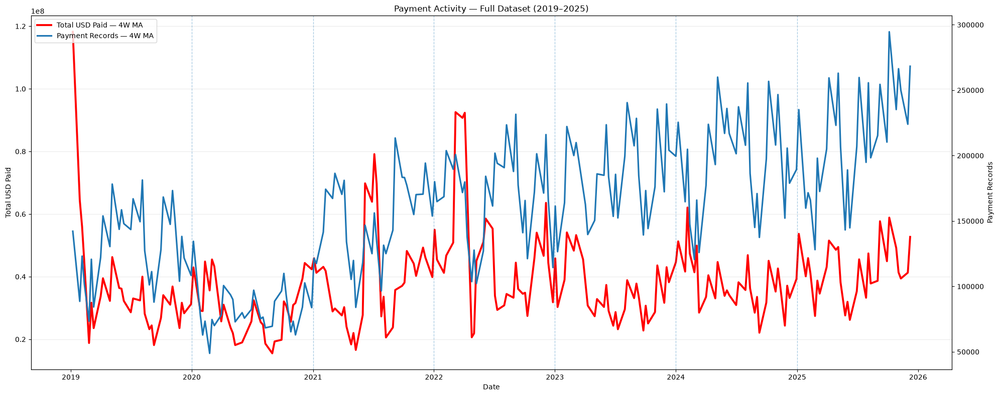

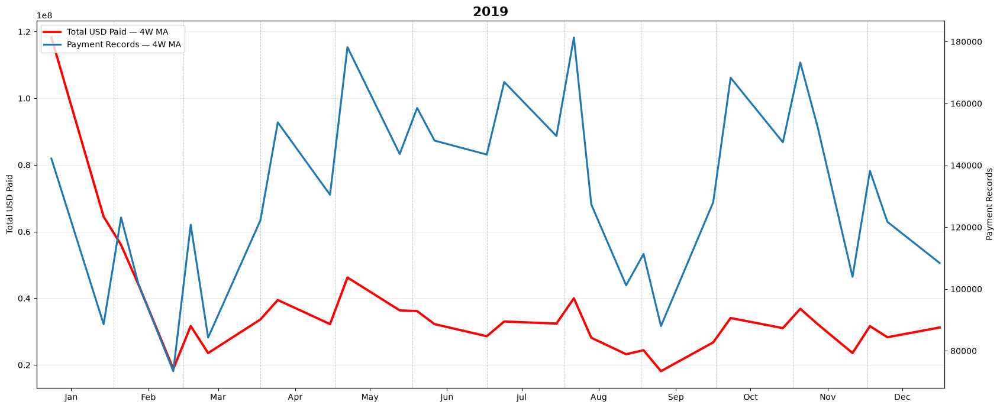

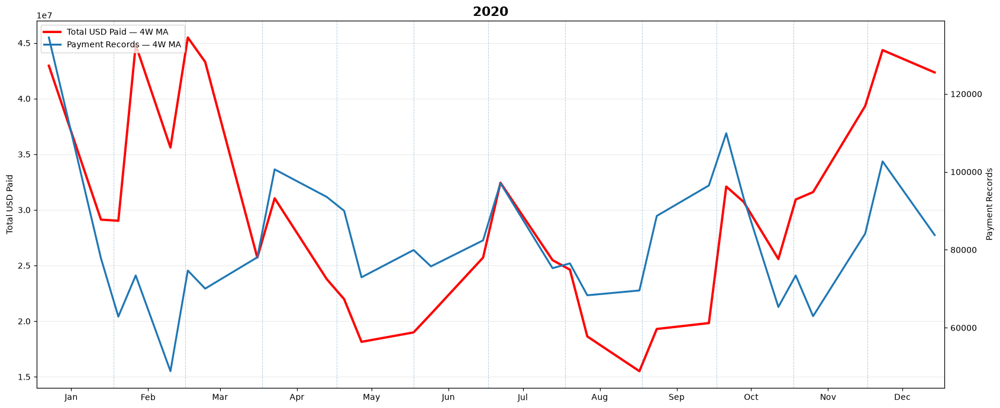

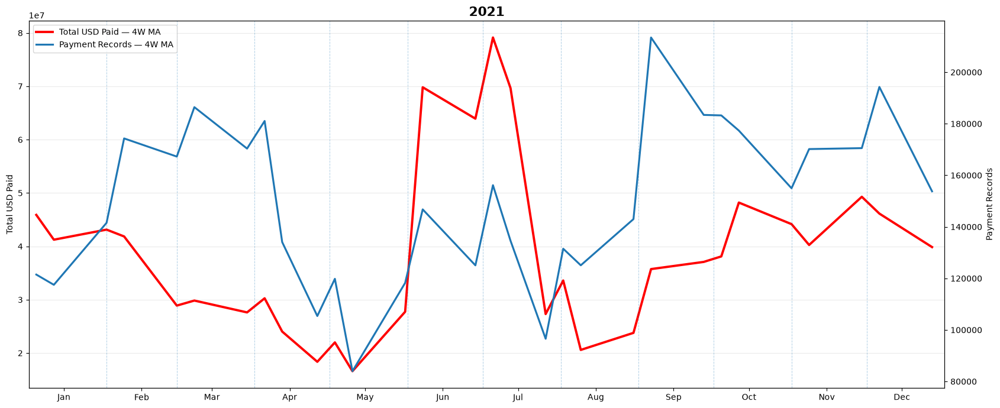

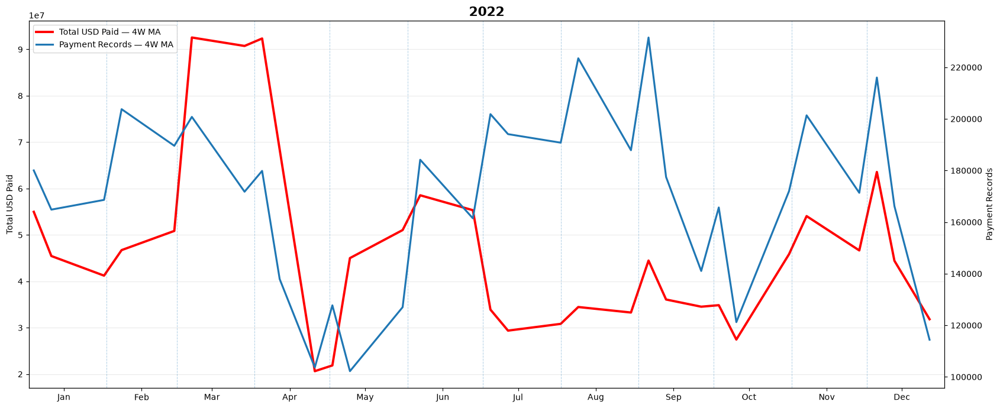

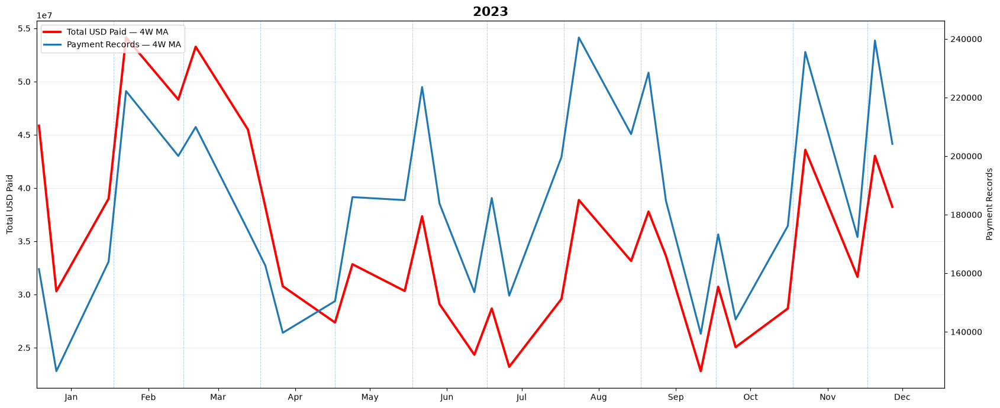

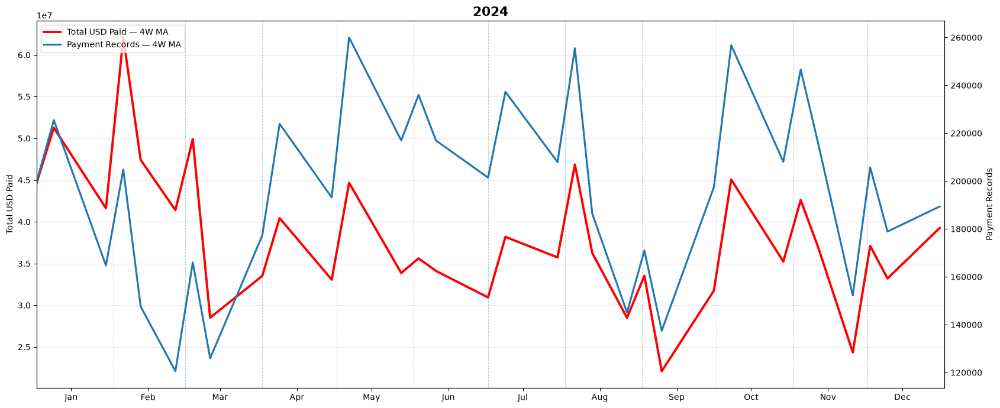

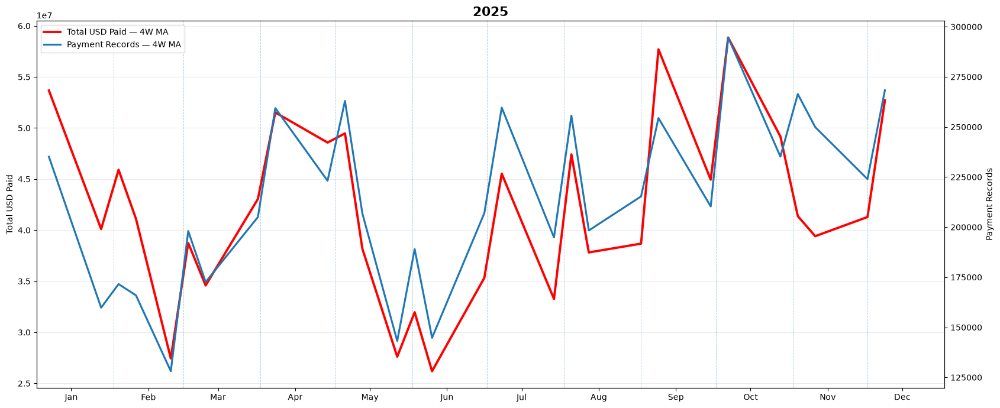

In [14]:
# Weekly time series — full dataset + individual yearly plots

payment_col = "Total_Amount_of_Payment_USDollars"
date_col = "Date_of_Payment"

MA_WINDOW = 4

# Calculate weekly metrics
weekly = (
    lf
    .filter(
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0) &
        pl.col(date_col).is_not_null()
    )
    .with_columns(
        pl.col(date_col).dt.truncate("1w").alias("Week")
    )
    .group_by("Week")
    .agg([
        pl.col(payment_col).sum().alias("Total_USD"),
        pl.len().alias("Payment_Records")
    ])
    .sort("Week")
    .collect()
)

# Keep only actual dataset years: 2019–2025
weekly = weekly.filter(
    (pl.col("Week") >= datetime(2019, 1, 1)) &
    (pl.col("Week") < datetime(2026, 1, 1))
)

# Add year and month
weekly = weekly.with_columns([
    pl.col("Week").dt.year().alias("Year"),
    pl.col("Week").dt.month().alias("Month")
])

# Moving averages
weekly = weekly.with_columns([
    pl.col("Total_USD")
    .rolling_mean(
        window_size=MA_WINDOW,
        min_samples=1
    )
    .alias("Total_USD_MA"),

    pl.col("Payment_Records")
    .rolling_mean(
        window_size=MA_WINDOW,
        min_samples=1
    )
    .alias("Payment_Records_MA")
])


# Get actual years present after filtering
years = (
    weekly["Year"]
    .unique()
    .sort()
    .to_list()
)


# Full dataset — 2019 to 2025

fig, ax1 = plt.subplots(figsize=(20, 8))

ax1.plot(
    weekly["Week"].to_list(),
    weekly["Total_USD_MA"].to_list(),
    color="red",
    linewidth=2.8,
    label="Total USD Paid — 4W MA"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Total USD Paid")

ax1.grid(
    axis="y",
    alpha=0.25
)

ax2 = ax1.twinx()

ax2.plot(
    weekly["Week"].to_list(),
    weekly["Payment_Records_MA"].to_list(),
    linewidth=2.3,
    label="Payment Records — 4W MA"
)

ax2.set_ylabel("Payment Records")

# Year separators
for year in years[1:]:
    ax1.axvline(
        datetime(year, 1, 1),
        linestyle="--",
        linewidth=0.9,
        alpha=0.4
    )

ax1.set_title(
    "Payment Activity — Full Dataset (2019–2025)"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Individual yearly plots

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

for year in years:

    # Explicitly restrict to the requested year
    year_data = (
        weekly
        .filter(pl.col("Year") == year)
        .sort("Week")
    )

    dates = year_data["Week"].to_list()

    fig, ax1 = plt.subplots(figsize=(17, 7))

    # Total USD — red
    ax1.plot(
        dates,
        year_data["Total_USD_MA"].to_list(),
        color="red",
        linewidth=2.8,
        label="Total USD Paid — 4W MA"
    )

    ax1.set_ylabel("Total USD Paid")

    ax1.grid(
        axis="y",
        alpha=0.25
    )

    # Payment records
    ax2 = ax1.twinx()

    ax2.plot(
        dates,
        year_data["Payment_Records_MA"].to_list(),
        linewidth=2.3,
        label="Payment Records — 4W MA"
    )

    ax2.set_ylabel("Payment Records")

    # Month separators
    for month in range(2, 13):
        ax1.axvline(
            datetime(year, month, 1),
            linestyle="--",
            linewidth=0.7,
            alpha=0.35
        )

    # Month labels
    month_positions = [
        datetime(year, month, 15)
        for month in range(1, 13)
    ]

    ax1.set_xticks(month_positions)
    ax1.set_xticklabels(months)

    ax1.set_xlim(
        datetime(year, 1, 1),
        datetime(year + 1, 1, 1)
    )

    # Year title
    ax1.set_title(
        str(year),
        fontsize=16,
        fontweight="bold"
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

## Payment Activity — Time-Series Findings

The weekly time-series analysis reveals a clear long-term increase in the number of reported payment records from 2019 through 2025. Payment-record activity is substantially higher in the later years, particularly 2024 and 2025, indicating a major increase in reporting volume over the study period.

Total payment value shows a very different pattern. Instead of following the steady increase in record volume, total USD paid is highly volatile, with several sharp peaks and declines throughout the study period. This indicates that changes in total payment value are strongly influenced by the magnitude and composition of payments rather than simply by the number of records.

### Recurring Patterns

#### Long-Term Increase in Payment Records

The payment-record volume shows a strong long-term upward shift:

- 2019 — relatively lower activity
- 2020 — lower and disrupted activity
- 2021 — recovery and higher activity
- 2022 — further increase
- 2023 — higher activity
- 2024 — very high activity
- 2025 — highest activity in the dataset

The increase in payment records is considerably more consistent than the increase in total payment value.

#### Total Payment Value and Record Count Do Not Move Proportionally

There are many periods where total USD paid and payment-record volume increase or decrease together. However, there are also many periods where they diverge.

Examples include periods where:

- Payment records increase substantially while total USD remains moderate.
- Total USD increases sharply while payment-record volume increases only modestly.
- Payment records decrease without an equally large decrease in total USD.

This indicates that the number of payment records and the financial magnitude of payments are related, but not proportional.

#### Repeated Intra-Year Activity Waves

Several years show recurring wave-like patterns:

**rise → peak → decline → recovery → peak → decline**

This behavior can be seen across multiple years, including 2019, 2021, 2022, 2023, 2024, and 2025.

The exact timing and magnitude of the peaks vary between years, so this is better described as recurring intra-year variation rather than strong fixed seasonality.

#### Elevated Late-Year Activity

Across several years, payment-record activity tends to become elevated during the later part of the year, particularly around October–December.

This pattern is visible in multiple years, including 2021 through 2025. However, the exact timing and magnitude vary between years, so stronger statistical testing would be required before describing this as definite seasonality.

#### Major Mid-Year Turning Points

Several years contain substantial changes around the middle of the year, particularly during approximately May–August.

Examples include:

- 2021 — major total-payment increase around June–July
- 2022 — major transition around April–July
- 2023 — substantial movement around June–August
- 2024 — strong movement around July–August
- 2025 — several large movements from June through September

The middle of the year therefore frequently contains important changes in either payment value, payment-record volume, or both.

#### Total USD Is More Volatile Than Payment-Record Volume

The total USD line shows much larger spikes and declines than the payment-record line.

This indicates that aggregate payment value is more sensitive to the size and composition of individual payments. A relatively small number of large-value payments can substantially change the total USD value without producing an equally large change in the number of payment records.

This is consistent with the earlier distribution analysis, which showed that payment amounts are strongly right-skewed.

#### 2020 Represents a Major Disruption

The year 2020 stands out clearly from the other years.

Both payment-record activity and total payment value decline substantially during the early-to-middle portion of the year, followed by recovery during the later months.

The time series demonstrates the timing and magnitude of this disruption, but the graph alone cannot establish its cause.

#### 2022 Appears to Be an Important Transition Period

The structure of the time series changes noticeably around 2022.

Before 2022, payment-record activity is generally lower and large dollar spikes are more visually dominant.

From 2022 onward, payment-record activity becomes substantially higher and remains elevated during the following years.

This makes 2022 a potentially important transition or change-point period for further investigation.

#### 2023–2025 Represent a Higher-Volume Regime

The period from 2023 through 2025 appears visually different from the earlier part of the dataset.

Payment-record activity remains substantially higher, particularly during 2024 and 2025.

However, total payment value does not show an equivalent permanent increase. Instead, it continues to fluctuate considerably.

This suggests a later period characterized by much higher reporting volume combined with comparatively variable aggregate payment value.

#### Repeated Sharp Drops Followed by Recoveries

Several years contain a recurring pattern of:

**high activity → sharp decline → recovery → higher activity**

This can be observed at different points across 2020–2025.

The repeated appearance of this pattern suggests temporary contractions followed by recovery rather than a perfectly smooth long-term trend.

However, the time-series plots alone cannot determine the causes of these changes.

#### Increasing Divergence Between Payment Volume and Financial Magnitude

A subtle but important pattern becomes more visible in the later years.

In earlier periods, the total USD and payment-record lines frequently move in similar directions.

During 2023–2025, there are more periods where the two measures diverge:

- Payment-record volume changes substantially while total USD changes relatively little.
- Total USD changes substantially while payment-record volume changes less dramatically.

This indicates that the relationship between payment volume and financial magnitude depends strongly on payment size and payment composition.

Potential explanatory variables include:

- `Nature_of_Payment_or_Transfer_of_Value`
- `Covered_Recipient_Type`
- `Product_Category_or_Therapeutic_Area_1`
- `Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1`
- `Related_Product_Indicator`
- `Third_Party_Payment_Recipient_Indicator`

These variables can help explain why the number of records and total payment value sometimes move differently.

### Overall Time-Series Pattern

The central pattern in the 2019–2025 time series is the divergence between payment-record volume and total payment value.

Payment-record activity shows a relatively clear long-term upward trend, with the highest sustained levels occurring in 2024 and 2025. In contrast, total payment value remains substantially more volatile, with repeated spikes and declines and no equally smooth long-term increase.

Therefore, the number of payment records alone is not sufficient to explain the financial magnitude of payments. The size and composition of individual payments appear to play an important role in determining changes in aggregate payment value.

### Further Analysis Suggested by the Time Series

The time-series patterns raise several useful questions for further analysis.

#### Why did payment-record volume increase so much after 2021?

The increase can be broken down by:

`Covered_Recipient_Type`

This can help determine whether the increase is primarily associated with physicians, non-physician practitioners, teaching hospitals, or other recipient groups.

#### Why do some weeks have very high USD totals without equally high record counts?

Total payment value can be decomposed by:

`Nature_of_Payment_or_Transfer_of_Value`

This can help determine whether categories such as Royalty/License, Consulting, Compensation, Honoraria, or other payment types contribute disproportionately to high-value periods.

#### Why does the relationship between total USD and payment records change over time?

A useful derived metric is:

**Average Payment per Record = Total USD Paid / Number of Payment Records**

Calculating this value for every week can directly show whether changes in total payment value are being driven primarily by:

- changes in the number of records,
- changes in the average payment size,
- or both.

This would help explain the divergence between the total-payment and payment-record time series.

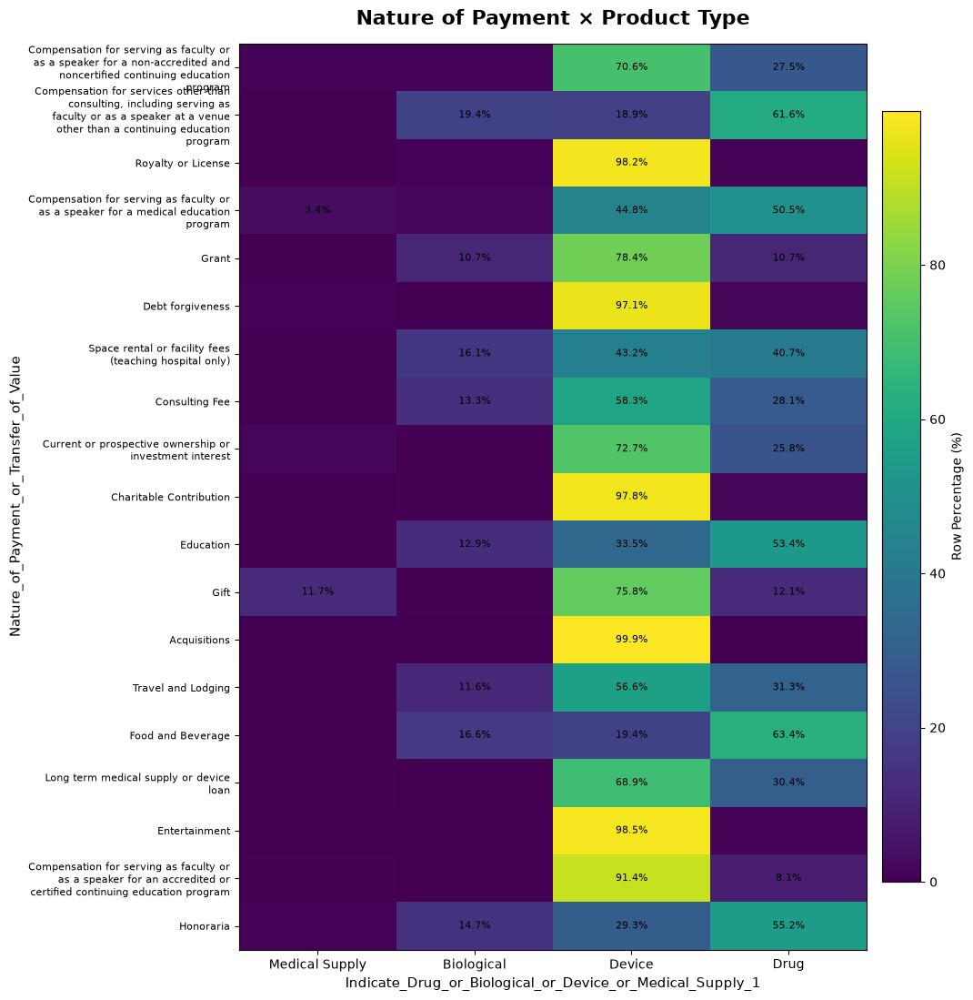

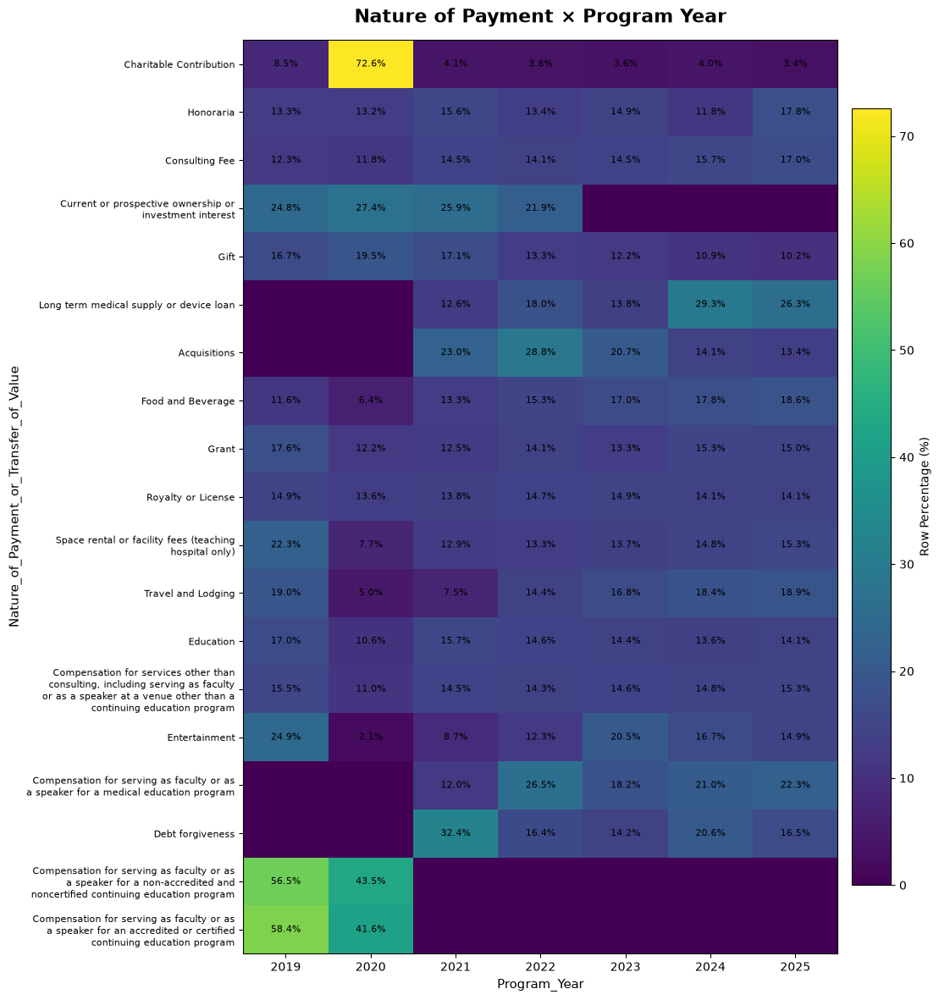

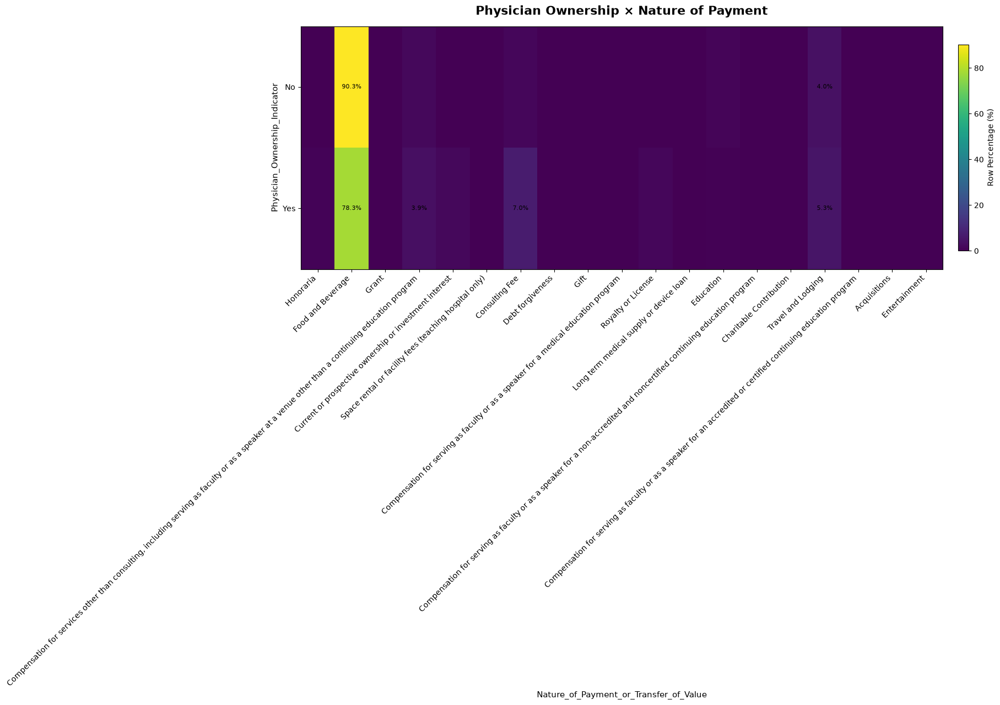

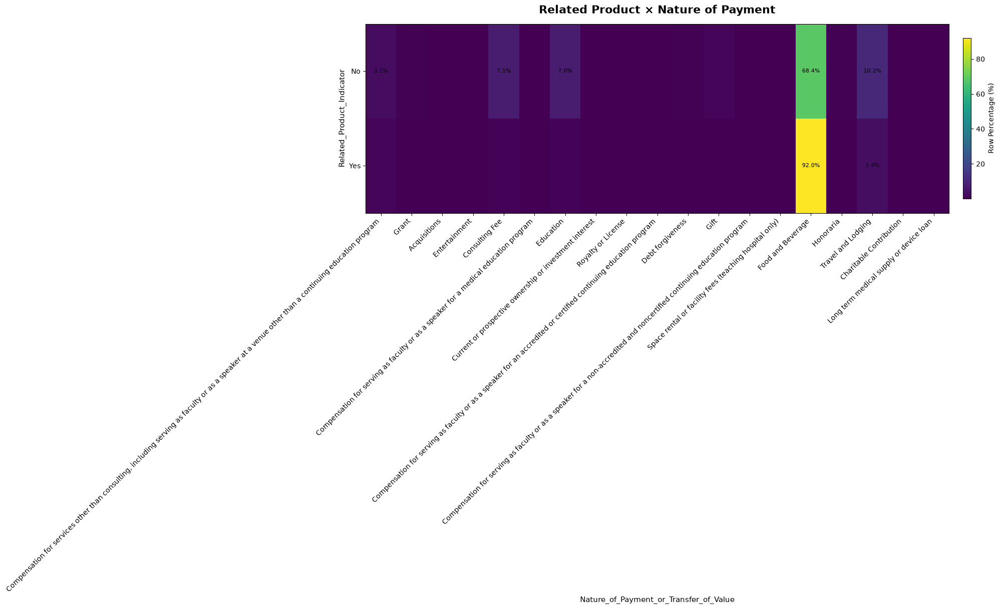

In [21]:
# Categorical heatmaps — all required graphs

import textwrap

nature_col = "Nature_of_Payment_or_Transfer_of_Value"
product_col = "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
year_col = "Program_Year"
ownership_col = "Physician_Ownership_Indicator"
related_col = "Related_Product_Indicator"


def create_percentage_matrix(data, row_col, col_col):

    counts = (
        data
        .group_by([row_col, col_col])
        .agg(pl.len().alias("Count"))
        .collect()
    )

    matrix = (
        counts
        .pivot(
            on=col_col,
            index=row_col,
            values="Count",
            aggregate_function="sum"
        )
        .fill_null(0)
    )

    row_values = matrix[row_col].to_list()

    column_values = [
        col for col in matrix.columns
        if col != row_col
    ]

    # Sort numeric-looking columns
    if all(str(x).isdigit() for x in column_values):
        column_values = sorted(
            column_values,
            key=lambda x: int(x)
        )

        matrix = matrix.select(
            [row_col] + column_values
        )

    counts_array = (
        matrix
        .select(column_values)
        .to_numpy()
        .astype(float)
    )

    row_totals = counts_array.sum(
        axis=1,
        keepdims=True
    )

    percentages = np.divide(
        counts_array * 100,
        row_totals,
        out=np.zeros_like(counts_array),
        where=row_totals != 0
    )

    return (
        row_values,
        column_values,
        percentages
    )


def plot_heatmap(
    data,
    row_col,
    col_col,
    title,
    figsize,
    row_wrap=35,
    col_rotation=45,
    annotate_threshold=2,
    fontsize=8,
    left_margin=0.30,
    bottom_margin=0.16
):

    row_values, column_values, percentages = (
        create_percentage_matrix(
            data,
            row_col,
            col_col
        )
    )

    wrapped_rows = [
        "\n".join(
            textwrap.wrap(
                str(value),
                width=row_wrap
            )
        )
        for value in row_values
    ]

    fig, ax = plt.subplots(
        figsize=figsize
    )

    im = ax.imshow(
        percentages,
        aspect="auto",
        interpolation="nearest"
    )

    # X-axis
    ax.set_xticks(
        np.arange(len(column_values))
    )

    ax.set_xticklabels(
        [str(x) for x in column_values],
        rotation=col_rotation,
        ha="right" if col_rotation else "center",
        fontsize=10
    )

    # Y-axis
    ax.set_yticks(
        np.arange(len(wrapped_rows))
    )

    ax.set_yticklabels(
        wrapped_rows,
        fontsize=fontsize
    )

    ax.set_xlabel(
        col_col,
        fontsize=11
    )

    ax.set_ylabel(
        row_col,
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    # Percentage annotations
    for i in range(percentages.shape[0]):
        for j in range(percentages.shape[1]):

            value = percentages[i, j]

            if value >= annotate_threshold:
                ax.text(
                    j,
                    i,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    # Colorbar
    cbar = fig.colorbar(
        im,
        ax=ax,
        shrink=0.85,
        pad=0.02
    )

    cbar.set_label(
        "Row Percentage (%)",
        fontsize=10
    )

    # Manual layout instead of constrained_layout
    fig.subplots_adjust(
        left=left_margin,
        right=0.94,
        bottom=bottom_margin,
        top=0.93
    )

    plt.show()


# Prepare datasets

nature_product_data = (
    lf
    .select([
        nature_col,
        product_col
    ])
    .filter(
        pl.col(nature_col).is_not_null() &
        pl.col(product_col).is_not_null()
    )
)

nature_year_data = (
    lf
    .select([
        nature_col,
        year_col
    ])
    .filter(
        pl.col(nature_col).is_not_null() &
        pl.col(year_col).is_not_null()
    )
)

ownership_nature_data = (
    lf
    .select([
        ownership_col,
        nature_col
    ])
    .filter(
        pl.col(ownership_col).is_not_null() &
        pl.col(nature_col).is_not_null()
    )
)

related_nature_data = (
    lf
    .select([
        related_col,
        nature_col
    ])
    .filter(
        pl.col(related_col).is_not_null() &
        pl.col(nature_col).is_not_null()
    )
)


# Nature of Payment × Product Type

plot_heatmap(
    nature_product_data,
    nature_col,
    product_col,
    "Nature of Payment × Product Type",
    figsize=(16, 12),
    row_wrap=38,
    col_rotation=0,
    annotate_threshold=2,
    fontsize=8,
    left_margin=0.42,
    bottom_margin=0.10
)


# Nature of Payment × Program Year

plot_heatmap(
    nature_year_data,
    nature_col,
    year_col,
    "Nature of Payment × Program Year",
    figsize=(18, 13),
    row_wrap=42,
    col_rotation=0,
    annotate_threshold=2,
    fontsize=8,
    left_margin=0.47,
    bottom_margin=0.10
)


# Physician Ownership × Nature of Payment

plot_heatmap(
    ownership_nature_data,
    ownership_col,
    nature_col,
    "Physician Ownership × Nature of Payment",
    figsize=(18, 7),
    row_wrap=20,
    col_rotation=45,
    annotate_threshold=2,
    fontsize=10,
    left_margin=0.16,
    bottom_margin=0.30
)


# Related Product × Nature of Payment

plot_heatmap(
    related_nature_data,
    related_col,
    nature_col,
    "Related Product × Nature of Payment",
    figsize=(18, 6),
    row_wrap=20,
    col_rotation=45,
    annotate_threshold=2,
    fontsize=10,
    left_margin=0.16,
    bottom_margin=0.30
)

# Categorical Heatmap Analysis

The categorical heatmaps were used to examine how different categorical variables are distributed relative to one another. Unlike raw count heatmaps, these plots use **row-wise percentages**, so each row represents 100% of the observations belonging to that category.

This makes it possible to compare the composition of different categories even when their total numbers of observations are very different.

The analysis focuses on:

- Nature of Payment × Product Type
- Nature of Payment × Program Year
- Physician Ownership × Nature of Payment
- Related Product × Nature of Payment

A key limitation is that these heatmaps describe the **composition of payment records**, not the composition of the total dollar value. A category can contain a small percentage of records but still represent a large share of payment value if its individual payments are large.

---

# Nature of Payment × Product Type

The Nature of Payment × Product Type heatmap shows a strong relationship between the reason for the payment and the associated product type.

Several payment categories are highly concentrated in a single product type.

### Strong Device concentration

Several payment categories are overwhelmingly associated with **Device** records:

- Royalty or License: **98.2% Device**
- Acquisitions: **99.9% Device**
- Debt forgiveness: **97.1% Device**
- Charitable Contribution: **97.8% Device**
- Entertainment: **98.5% Device**
- Grant: **78.4% Device**
- Current or prospective ownership or investment interest: **72.7% Device**
- Long term medical supply or device loan: **68.9% Device**

This indicates that these payment categories are not distributed evenly across product types. Device-related records dominate their composition.

### Mixed payment categories

Some payment types have a much more balanced product-type composition.

**Consulting Fee**:

- Device: **58.3%**
- Drug: **28.1%**
- Biological: **13.3%**

**Travel and Lodging**:

- Device: **56.6%**
- Drug: **31.3%**
- Biological: **11.6%**

**Food and Beverage**:

- Drug: **63.4%**
- Device: **19.4%**
- Biological: **16.6%**

**Honoraria**:

- Drug: **55.2%**
- Device: **29.3%**
- Biological: **14.7%**

These categories are therefore more heterogeneous than categories such as Acquisitions or Royalty or License.

### Education-related payments

Education has a different composition:

- Drug: **53.4%**
- Device: **33.5%**
- Biological: **12.9%**

The Drug share is substantially larger than the Device share for Education, unlike many of the other payment categories.

The continuing-education compensation categories also show different compositions. For example:

- Compensation for serving as faculty or speaker for an accredited or certified continuing education program:
  - Device: **91.4%**
  - Drug: **8.1%**

- Compensation for serving as faculty or speaker for a medical education program:
  - Device: **44.8%**
  - Drug: **50.5%**
  - Medical Supply: **3.4%**

- Compensation for serving as faculty or speaker for a non-accredited and noncertified continuing education program:
  - Device: **70.6%**
  - Drug: **27.5%**

These differences show that even closely related payment categories can have different product-type compositions.

### Overall interpretation

The heatmap provides strong visual evidence that **Nature of Payment and Product Type are highly associated**.

This is consistent with the earlier categorical statistical analysis, where the relationship produced a **Cramér's V of approximately 0.766**.

The association is therefore not simply caused by one or two categories. Multiple payment categories show strong concentration in particular product types.

However, this is an association between categorical variables. It does not establish that one variable causes the other.

---

# Nature of Payment × Program Year

The Nature of Payment × Program Year heatmap examines how observations belonging to each payment category are distributed across the years 2019–2025.

Because the percentages are calculated row-wise, each payment category sums to approximately 100% across all program years.

This means the interpretation is:

> Among all records belonging to a particular payment category, what percentage occurred in each year?

It does **not** directly represent the percentage composition of each year's entire Open Payments dataset.

---

## Relatively stable payment categories

Several payment categories show relatively balanced distributions across the seven years.

### Royalty or License

The distribution remains relatively stable:

- 2019: **14.9%**
- 2020: **13.6%**
- 2021: **13.8%**
- 2022: **14.7%**
- 2023: **14.9%**
- 2024: **14.1%**
- 2025: **14.1%**

There is no strong concentration in one particular year.

### Consulting Fee

Consulting Fee is also relatively distributed across the full period:

- 2019: **12.3%**
- 2020: **11.8%**
- 2021: **14.5%**
- 2022: **14.1%**
- 2023: **14.5%**
- 2024: **15.7%**
- 2025: **17.0%**

There is some movement toward later years, but the category is present throughout the entire period.

### Honoraria

Honoraria is similarly distributed:

- 2019: **13.3%**
- 2020: **13.2%**
- 2021: **15.6%**
- 2022: **13.4%**
- 2023: **14.9%**
- 2024: **11.8%**
- 2025: **17.8%**

The distribution fluctuates but does not exhibit the extreme concentration seen in some other payment categories.

### Education

Education also remains relatively distributed:

- 2019: **17.0%**
- 2020: **10.6%**
- 2021: **15.7%**
- 2022: **14.6%**
- 2023: **14.4%**
- 2024: **13.6%**
- 2025: **14.1%**

---

# Payment categories with strong year concentration

Some categories show much stronger temporal concentration.

## Charitable Contribution

Charitable Contribution has a particularly unusual distribution:

- 2019: **8.5%**
- 2020: **72.6%**
- 2021: **4.1%**
- 2022: **3.8%**
- 2023: **3.6%**
- 2024: **4.0%**
- 2025: **3.4%**

More than two-thirds of the records in this payment category occur in 2020.

This makes 2020 a clear outlier for this particular payment category.

The result should not be interpreted as saying that 72.6% of all payments in 2020 were charitable contributions. The denominator is the total number of **Charitable Contribution records across all years**.

---

## Entertainment

Entertainment also shows a substantial change:

- 2019: **24.9%**
- 2020: **2.1%**
- 2021: **8.7%**
- 2022: **12.3%**
- 2023: **20.5%**
- 2024: **16.7%**
- 2025: **14.9%**

The very low 2020 share is followed by a gradual recovery in subsequent years.

---

## Travel and Lodging

Travel and Lodging shows a similar disruption:

- 2019: **19.0%**
- 2020: **5.0%**
- 2021: **7.5%**
- 2022: **14.4%**
- 2023: **16.8%**
- 2024: **18.4%**
- 2025: **18.9%**

The pattern shows a strong reduction around 2020–2021 followed by recovery in later years.

This is consistent with the broader time-series analysis, where 2020 appeared as a major disruption to payment activity.

---

## Long term medical supply or device loan

This category becomes more concentrated in later years:

- 2021: **12.6%**
- 2022: **18.0%**
- 2023: **13.8%**
- 2024: **29.3%**
- 2025: **26.3%**

The largest shares occur in 2024 and 2025.

---

## Special continuing-education categories

Two continuing-education categories show very strong concentration in the early years.

For example:

**Compensation for serving as faculty or as a speaker for an accredited or certified continuing education program**

- 2019: **58.4%**
- 2020: **41.6%**
- Later years: essentially absent

Similarly:

**Compensation for serving as faculty or as a speaker for a non-accredited and noncertified continuing education program**

- 2019: **56.5%**
- 2020: **43.5%**
- Later years: essentially absent

These patterns suggest that these particular categories changed substantially over the observation period or were used differently after 2020.

---

# Physician Ownership × Nature of Payment

The Physician Ownership × Nature of Payment heatmap compares the composition of payment categories between records where the Physician Ownership Indicator is **Yes** and **No**.

The most striking feature is the dominance of **Food and Beverage** in both groups.

### Physician Ownership = Yes

The largest categories are:

- Food and Beverage: **78.3%**
- Consulting Fee: **7.0%**
- Travel and Lodging: **5.3%**
- Entertainment: **3.9%**

The remaining payment categories individually contribute relatively small shares.

### Physician Ownership = No

The distribution is even more concentrated:

- Food and Beverage: **90.3%**
- Travel and Lodging: **4.0%**
- Consulting Fee: approximately a small share
- Other categories: individually small

### Comparison

The major difference is the concentration of Food and Beverage:

- Ownership = Yes: **78.3%**
- Ownership = No: **90.3%**

Therefore, the ownership-Yes group has a more distributed payment composition, while the ownership-No group is more heavily concentrated in Food and Beverage.

The difference is visible, but the heatmap should not be interpreted as evidence that physician ownership causes a particular payment type.

It only shows that the observed payment-type composition differs between the two ownership categories.

---

# Related Product × Nature of Payment

The Related Product × Nature of Payment heatmap shows a strong difference between records marked **Yes** and **No** for the Related Product Indicator.

## Related Product = Yes

The distribution is extremely concentrated:

- Food and Beverage: **92.0%**
- Travel and Lodging: **3.4%**
- Most other payment categories: very small shares

Thus, nearly the entire row is dominated by Food and Beverage.

## Related Product = No

The distribution is substantially more diverse:

- Food and Beverage: **68.4%**
- Travel and Lodging: **10.2%**
- Consulting Fee: **7.1%**
- Education: **7.0%**
- Compensation for services other than consulting: **3.1%**
- Other categories: smaller shares

### Comparison

The difference in Food and Beverage composition is particularly large:

- Related Product = Yes: **92.0%**
- Related Product = No: **68.4%**

At the same time, several other categories have noticeably larger shares among Related Product = No.

For example:

- Travel and Lodging: **10.2% vs 3.4%**
- Consulting Fee: **7.1% vs very small**
- Education: **7.0% vs very small**

This produces a clear difference in the categorical composition of the two groups.

The earlier statistical analysis also identified a meaningful association between Related Product and Nature of Payment, with **Cramér's V ≈ 0.222**.

---

## Comparison of the Four Heatmaps

The four heatmaps reveal different levels and types of structure.

| Relationship | Main pattern |
|---|---|
| Nature of Payment × Product Type | Very strong specialization of payment categories into product types |
| Nature of Payment × Program Year | Some categories are stable while others are strongly concentrated in particular years |
| Physician Ownership × Nature of Payment | Both groups are dominated by Food and Beverage, but ownership = Yes has a more diverse composition |
| Related Product × Nature of Payment | Related Product = Yes is extremely concentrated in Food and Beverage |

The **Nature of Payment × Product Type** relationship is the most visually structured of these four. Many rows are dominated by one product type, and this agrees with the very high Cramér's V observed in the categorical statistical analysis.

The **Nature of Payment × Program Year** heatmap is particularly useful for detecting temporal changes and unusual years. The strong 2020 concentration in several categories is one of the most obvious patterns.

The **Physician Ownership × Nature of Payment** relationship is dominated by Food and Beverage in both groups, although the degree of concentration differs.

The **Related Product × Nature of Payment** relationship shows a much stronger compositional difference between the Yes and No groups.

---

## Important Interpretation Limitation

These heatmaps use **record counts converted into percentages**.

Therefore, they answer questions about:

> **How many records belong to each category?**

They do not answer:

> **How much money was transferred in each category?**

For example, a payment category could represent only 2% of records but contain extremely large individual payments. Conversely, a category could contain 50% of records while representing a relatively small fraction of the total dollar value.

This is especially important for this dataset because the payment amount distribution is highly right-skewed.

Therefore, the categorical heatmaps should be considered a **record-composition analysis**.

A complementary analysis using **payment amount** would provide a different perspective.

---

## Overall Findings

The categorical heatmaps demonstrate that the Open Payments data contains substantial structure across several categorical dimensions.

The strongest observed pattern is the relationship between **Nature of Payment and Product Type**. Many payment categories show strong concentration in specific product types, particularly Device-related records. This is consistent with the previously calculated Cramér's V of approximately **0.766**.

The **Nature of Payment × Program Year** heatmap demonstrates that not every payment category follows the same temporal pattern. Some categories are relatively stable from 2019–2025, while others are highly concentrated in particular years. 2020 is especially unusual for categories such as Charitable Contribution, Entertainment, Travel and Lodging, and several continuing-education categories.

The **Physician Ownership × Nature of Payment** heatmap shows that Food and Beverage dominates both ownership groups, but the ownership-Yes group has a somewhat more diverse payment composition.

The **Related Product × Nature of Payment** heatmap shows a strong concentration of Food and Beverage among Related Product = Yes records, where it accounts for approximately **92%** of the row. Related Product = No has a much broader distribution across payment categories.

Overall, these heatmaps provide evidence that payment records are not distributed randomly across the categorical variables. The strongest structure occurs between **payment nature and product type**, while temporal effects and indicator variables reveal additional differences in the composition of payment records.

These relationships should be interpreted as **associations rather than causal relationships**. The heatmaps describe the observed structure of the dataset and do not establish why these patterns occur.

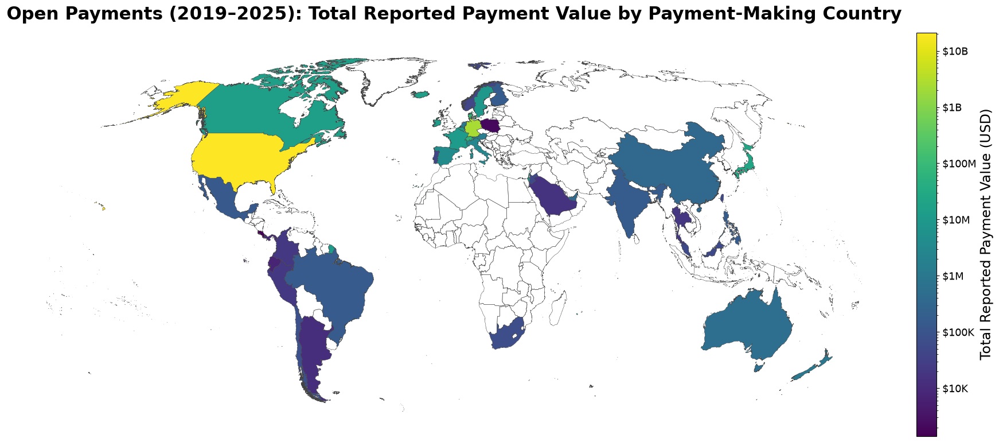

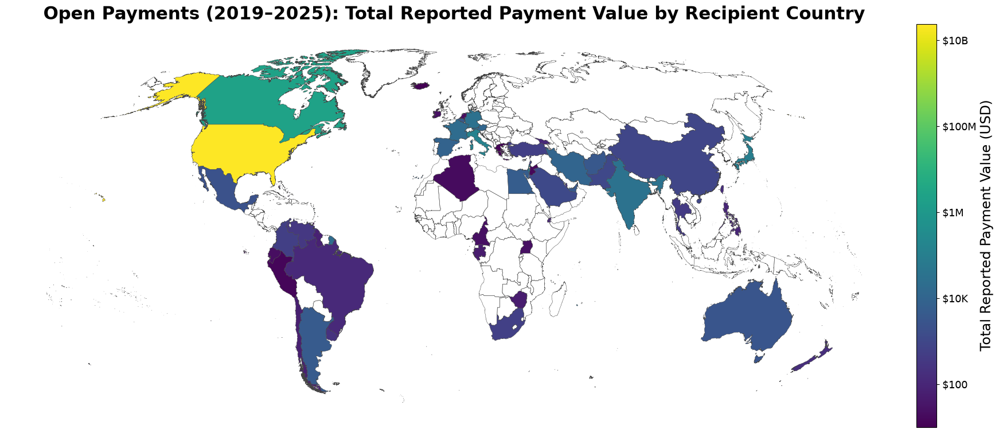


Saved:
geographical_plots/world_payment_making_2K.png
geographical_plots/world_recipient_2K.png

Jupyter display size:
18 × 10.125 inches

Saved image:
Approximately 2560 × 1440 pixels


In [39]:
# World geographical maps — payment makers vs recipients
# Large Jupyter display + 2K saved PNG

from pathlib import Path

import polars as pl
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter


payment_col = "Total_Amount_of_Payment_USDollars"

payer_country_col = (
    "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country"
)

recipient_country_col = "Recipient_Country"

output_dir = Path("geographical_plots")
output_dir.mkdir(parents=True, exist_ok=True)

# Large figure for Jupyter display
FIG_WIDTH = 18
FIG_HEIGHT = 10.125

# Save approximately 2560 × 1440
SAVE_DPI = 142.222


# Load detailed world boundaries
world_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_0_countries.zip"
)

world = gpd.read_file(world_url)

# Remove Antarctica
world = world[
    world["CONTINENT"].astype(str).str.upper() != "ANTARCTICA"
].copy()

# Robinson projection
world = world.to_crs("ESRI:54030")

# Normalize Natural Earth country names
world["MAP_COUNTRY"] = (
    world["NAME"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# Country-name aliases
country_aliases = {
    "USA": "UNITED STATES OF AMERICA",
    "US": "UNITED STATES OF AMERICA",
    "UNITED STATES": "UNITED STATES OF AMERICA",

    "UK": "UNITED KINGDOM",
    "GREAT BRITAIN": "UNITED KINGDOM",

    "RUSSIA": "RUSSIAN FEDERATION",

    "CZECH REPUBLIC": "CZECHIA",

    "VIET NAM": "VIETNAM",

    "UAE": "UNITED ARAB EMIRATES",

    "REPUBLIC OF KOREA": "SOUTH KOREA",
}


def prepare_country_data(country_column):

    return (
        lf
        .select([
            pl.col(country_column),
            pl.col(payment_col)
        ])
        .filter(
            pl.col(country_column).is_not_null() &
            pl.col(payment_col).is_not_null() &
            (pl.col(payment_col) > 0)
        )
        .with_columns(
            pl.col(country_column)
            .cast(pl.String)
            .str.strip_chars()
            .str.to_uppercase()
            .alias("Country")
        )
        .filter(
            pl.col("Country").str.len_chars() > 0
        )
        .group_by("Country")
        .agg(
            pl.col(payment_col)
            .sum()
            .alias("Total_Payment_USD")
        )
        .sort(
            "Total_Payment_USD",
            descending=True
        )
        .collect()
    )


def make_world_map(
    data,
    title,
    output_file
):

    # Only the tiny aggregated table becomes pandas
    data_pd = data.to_pandas()

    data_pd["MAP_COUNTRY"] = (
        data_pd["Country"]
        .replace(country_aliases)
    )

    # Merge payment data with geographical boundaries
    map_df = world.merge(
        data_pd[
            [
                "MAP_COUNTRY",
                "Total_Payment_USD"
            ]
        ],
        on="MAP_COUNTRY",
        how="left"
    )

    map_df["Total_Payment_USD"] = (
        map_df["Total_Payment_USD"]
        .fillna(0)
    )

    # Positive values for logarithmic scale
    positive_values = map_df.loc[
        map_df["Total_Payment_USD"] > 0,
        "Total_Payment_USD"
    ]

    vmin = positive_values.min()
    vmax = positive_values.max()

    # Large figure for Jupyter
    fig, ax = plt.subplots(
        figsize=(
            FIG_WIDTH,
            FIG_HEIGHT
        )
    )

    ax.set_facecolor("#F7F7F7")

    # Plot countries
    map_df.plot(
        ax=ax,
        column="Total_Payment_USD",
        cmap="viridis",
        norm=LogNorm(
            vmin=vmin,
            vmax=vmax
        ),
        edgecolor="#444444",
        linewidth=0.35,
        missing_kwds={
            "color": "#EEEEEE",
            "edgecolor": "#BBBBBB"
        }
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(
        norm=LogNorm(
            vmin=vmin,
            vmax=vmax
        ),
        cmap="viridis"
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.025,
        pad=0.015,
        shrink=0.78
    )

    cbar.set_label(
        "Total Reported Payment Value (USD)",
        fontsize=17
    )

    cbar.ax.tick_params(
        labelsize=13
    )

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: (
                f"${x/1e9:.0f}B"
                if x >= 1e9
                else
                f"${x/1e6:.0f}M"
                if x >= 1e6
                else
                f"${x/1e3:.0f}K"
                if x >= 1e3
                else
                f"${x:.0f}"
            )
        )
    )

    # Title
    ax.set_title(
        title,
        fontsize=22,
        fontweight="bold",
        pad=15
    )

    ax.axis("off")

    fig.subplots_adjust(
        left=0.015,
        right=0.92,
        bottom=0.02,
        top=0.91
    )

    # Save at approximately 2560 × 1440
    fig.savefig(
        output_file,
        dpi=SAVE_DPI,
        facecolor="white"
    )

    # Large Jupyter output
    plt.show()

    plt.close(fig)


# ------------------------------------------------------------
# Map 1 — Who is paying
# ------------------------------------------------------------

payer_data = prepare_country_data(
    payer_country_col
)

make_world_map(
    payer_data,
    "Open Payments (2019–2025): Total Reported Payment Value by Payment-Making Country",
    output_dir / "world_payment_making_2K.png"
)


# ------------------------------------------------------------
# Map 2 — Who is receiving
# ------------------------------------------------------------

recipient_data = prepare_country_data(
    recipient_country_col
)

make_world_map(
    recipient_data,
    "Open Payments (2019–2025): Total Reported Payment Value by Recipient Country",
    output_dir / "world_recipient_2K.png"
)


print()
print("Saved:")
print(output_dir / "world_payment_making_2K.png")
print(output_dir / "world_recipient_2K.png")
print()
print("Jupyter display size:")
print(f"{FIG_WIDTH} × {FIG_HEIGHT} inches")

print()
print("Saved image:")
print("Approximately 2560 × 1440 pixels")

# Geographical Analysis

The geographical analysis compares the global distribution of Open Payments using two complementary maps:

- **Payment-Making Country** — geographic location associated with the applicable manufacturer or GPO making the reported payment.
- **Recipient Country** — geographic location associated with the covered recipient receiving the reported payment.

Both maps use the same measure:

> **Total Reported Payment Value (USD)**

The maps cover **2019–2025** and use a **logarithmic color scale**, which is appropriate because payment values vary by several orders of magnitude.

## Payment-Making Country

The payment-making map shows a strong concentration of reported payment value in a relatively small number of countries.

The **United States** is the most visually prominent payment-making country, occupying the highest range of the color scale. This indicates that reporting entities located in the United States account for a very large share of the total reported payment value in the dataset.

**Canada** also shows a substantial payment-making value, although clearly below the United States.

Several European countries show meaningful payment-making activity, particularly countries in Western and Northern Europe. The distribution is not uniform across Europe, with some countries showing substantially higher values than others.

Countries in **East and South Asia** also appear in the payment-making map. **China and India** are visible, along with several countries in Southeast Asia and the Middle East.

**Australia** also shows a relatively substantial payment-making value compared with many countries.

A large portion of **Africa** and some regions of Central Asia show little or no visible reported payment value on this map. However, because the map represents Open Payments records rather than the entire global pharmaceutical or medical-device economy, an uncolored country should not automatically be interpreted as having no financial activity of any kind.

## Recipient Country

The recipient map shows a noticeably different geographical pattern.

Again, the **United States is the dominant recipient country** by total reported payment value. This is consistent with the large volume of covered-recipient records represented in the Open Payments dataset.

**Canada** also has a substantial recipient-side value.

A broad group of countries across **Europe, Asia, the Middle East, Australia, and parts of South America and Africa** have recipient-side payment values represented in the dataset.

The recipient map shows particularly visible activity across:

- Western and Northern Europe
- China
- India
- Japan
- South Korea
- Southeast Asia
- Middle Eastern countries
- Australia
- Selected countries in Africa
- Several countries in South America

The geographical distribution of recipients is therefore broader than simply a US-only pattern, although the United States remains visually dominant.

## Payment-Making vs Recipient Geography

The two maps provide different perspectives on the same reported financial relationships.

The **payment-making map** answers:

> Where are the entities making the reported payments located?

The **recipient map** answers:

> Where are the covered recipients receiving those reported payments located?

The geographical patterns are not identical.

For example, some countries appear relatively prominent on the payment-making map but less prominent on the recipient map, while other countries show the opposite pattern. This indicates that the geographic distribution of reporting entities and the geographic distribution of covered recipients are not the same.

This distinction is important because the maps should **not be interpreted as a direct international money-flow map**. They aggregate payment values separately by the location of the payment-making entity and by the location of the recipient.

## Strong Geographic Concentration

The maps demonstrate a strong concentration of reported payment value in a limited number of countries.

The United States is particularly dominant on both sides of the reported relationship:

- It has a very high payment-making value.
- It also has a very high recipient value.

This makes the United States the major geographic center of the Open Payments records represented in this dataset.

Other countries contribute substantially smaller amounts, producing the long geographic tail visible across the maps.

## Logarithmic Scale

The colorbars use a **logarithmic scale**.

This is important when interpreting the maps because the difference between colors does not represent equal linear increases in payment value.

For example, moving from one major color interval to another represents approximately an order-of-magnitude change rather than a fixed dollar increment.

This allows countries with relatively small payment values to remain visible while still representing countries with extremely large aggregate payment values.

A linear color scale would likely cause most countries to appear nearly identical because of the very large payment-value range.

## Countries Without Visible Values

Countries shown in white do not necessarily mean that the country has no economic relationship with pharmaceutical, medical-device, or healthcare companies.

They indicate that the map did not have a **positive reported payment value matched to that country** under the geographic field being plotted.

Therefore, these maps describe the geographical distribution **within the Open Payments dataset**, rather than measuring total healthcare-related financial activity worldwide.

## Important Interpretation

These maps represent **aggregated reported payments from 2019–2025**.

They should therefore be interpreted as:

> **Geographical distribution of reported Open Payments transaction value**

rather than:

> **Total pharmaceutical/medical industry spending by country**

The distinction matters because Open Payments covers specific reportable relationships between applicable manufacturers/GPOs and covered recipients.

## Overall Geographical Pattern

The two maps reveal several broad patterns:

- **The United States is the dominant country on both the payment-making and recipient sides.**
- **Canada has substantial activity on both sides**, although below the United States.
- **Europe contains multiple countries with significant reported payment values**, rather than activity being concentrated in only one European country.
- **Asia has substantial representation**, particularly China, India, Japan, South Korea, and several Southeast Asian and Middle Eastern countries.
- **Australia is clearly represented** in both geographical perspectives.
- The **recipient distribution is geographically broader** across the visible map than the highest-value payment-making distribution.
- The payment-making and recipient maps are **not mirror images**, showing that the locations of reporting entities and recipients differ.
- The very wide range of payment values makes the **logarithmic scale essential** for meaningful geographical comparison.
- The maps describe **reported Open Payments relationships**, not general global healthcare spending or international capital flows.

## Key Finding

The geographical analysis shows that Open Payments is **strongly concentrated around the United States**, while also revealing a broader international network of payment-making entities and recipients across Europe, Asia, the Middle East, Australia, Africa, and South America.

Comparing the two maps is particularly useful because it separates the geography of **where reported payments originate from the reporting-entity side** from the geography of **where those reported payments are received by covered recipients**.

# 13. Hypothesis Generation

After completing the exploratory data analysis, several patterns were identified that are suitable for formal statistical testing.

The hypotheses below were developed from the observed numerical distributions, categorical relationships, multivariate patterns, time-series behavior, and geographical analysis of the 2019–2025 CMS Open Payments dataset.

Because `Total_Amount_of_Payment_USDollars` is highly right-skewed, non-parametric methods such as Mann–Whitney U and Kruskal–Wallis are generally appropriate for direct comparisons of payment distributions. For very large samples, statistical significance should be interpreted together with effect sizes and confidence intervals.

---

## Payment Amount and Number of Payments

The exploratory analysis showed an extremely dense concentration at `Number_of_Payments_Included_in_Total_Amount = 1`, while payment amounts span a very large range.

The previous correlation analysis produced:

- Pearson correlation ≈ 0.000638
- Spearman correlation ≈ 0.0515
- Kendall correlation ≈ 0.0406

These results suggest that the relationship, if present, is very weak.

### H₀

There is no association between `Total_Amount_of_Payment_USDollars` and `Number_of_Payments_Included_in_Total_Amount`.

### H₁

There is an association between `Total_Amount_of_Payment_USDollars` and `Number_of_Payments_Included_in_Total_Amount`.

### Statistical Test

- Pearson correlation
- Spearman correlation
- Kendall correlation

---

## Payment Amount and Nature of Payment

The exploratory analysis showed substantial differences in payment distributions across different Nature-of-Payment categories.

Categories such as Royalty/License, Honoraria, and Consulting/Compensation-related payments showed higher typical payment levels, while categories such as Food/Beverage, Travel/Lodging, Education, and Gift generally showed lower typical payment levels.

### H₀

There is no difference in payment amount distributions among Nature-of-Payment categories.

### H₁

Payment amount distributions differ among Nature-of-Payment categories.

### Statistical Test

Kruskal–Wallis H test.

If the null hypothesis is rejected, post-hoc pairwise comparisons should be performed using Dunn's test with an appropriate multiple-testing correction.

---

## Payment Amount and Covered Recipient Type

The exploratory analysis showed differences in payment distributions among Physicians, Non-Physician Practitioners, and Teaching Hospitals.

Teaching Hospitals displayed noticeably different and often more volatile payment patterns in several Nature-of-Payment categories.

### H₀

Payment amount distributions are the same across Covered Recipient Types.

### H₁

At least one Covered Recipient Type has a different payment amount distribution.

### Statistical Test

Kruskal–Wallis H test followed by post-hoc pairwise comparisons.

---

## Payment Amount and Third-Party Payment Recipient Status

The visual analysis showed clear differences between payments associated with entities, individuals, and cases with no third-party payment recipient.

The Entity category showed substantially higher typical payment values and a wider distribution.

### H₀

Payment amount distributions do not differ according to `Third_Party_Payment_Recipient_Indicator`.

### H₁

Payment amount distributions differ according to `Third_Party_Payment_Recipient_Indicator`.

### Statistical Test

Kruskal–Wallis H test followed by pairwise post-hoc comparisons.

---

## Payment Amount and Related Product Status

The exploratory analysis showed that records with `Related_Product_Indicator = No` generally had a higher typical payment level than records with `Related_Product_Indicator = Yes`.

### H₀

Payment amount distributions are identical between Related Product = Yes and Related Product = No.

### H₁

Payment amount distributions differ between Related Product = Yes and Related Product = No.

### Statistical Test

Mann–Whitney U test.

The analysis should also report a rank-biserial effect size and confidence interval.

---

## Payment Amount and Physician Ownership

The exploratory analysis showed relatively close payment distributions between Physician Ownership = Yes and Physician Ownership = No, with the Yes group showing somewhat broader variation.

### H₀

Payment amount distributions are identical for Physician Ownership = Yes and Physician Ownership = No.

### H₁

Payment amount distributions differ between Physician Ownership = Yes and Physician Ownership = No.

### Statistical Test

Mann–Whitney U test.

Effect size should be reported alongside the p-value.

---

## Payment Amount and Product Type

The exploratory analysis showed differences in payment distributions across Drug, Biological, Device, and Medical Supply categories.

### H₀

Payment amount distributions are identical across Product Types.

### H₁

Payment amount distributions differ among Product Types.

### Statistical Test

Kruskal–Wallis H test followed by Dunn's post-hoc comparisons.

---

## Payment Amount and Product Category

The categorical–numerical analysis showed differences in typical payment levels across Product Category/Therapeutic Area groups, including categories such as Ophthalmology, Oncology, Neurology/Neuroscience, Immunology, CNS, Cardiovascular, Vaccines, and Endocrinology.

### H₀

Payment amount distributions are identical across Product Categories.

### H₁

At least one Product Category has a different payment amount distribution.

### Statistical Test

Kruskal–Wallis H test followed by post-hoc pairwise comparisons.

Product-category capitalization should be normalized before testing, because the exploratory analysis identified duplicate representations such as `Immunology` and `IMMUNOLOGY`.

---

## Nature of Payment × Covered Recipient Type and Payment Amount

The multivariate analysis showed that the payment-size pattern associated with a particular Nature of Payment can differ according to Covered Recipient Type.

### H₀

The relationship between Nature of Payment and payment amount does not differ by Covered Recipient Type.

### H₁

The relationship between Nature of Payment and payment amount differs by Covered Recipient Type.

### Statistical Test

A two-factor model using log-transformed payment amount:

`log10(Payment Amount) ~ Nature of Payment + Covered Recipient Type + Nature × Covered Recipient Type`

The interaction term is the primary quantity of interest.

---

## Nature of Payment × Product Type and Payment Amount

The heatmap showed strong differences in Product Type composition among Nature-of-Payment categories.

Some categories were heavily concentrated in Device transactions, while categories such as Consulting, Travel/Lodging, Food/Beverage, Honoraria, and Education showed more mixed Product Type distributions.

### H₀

The relationship between Product Type and payment amount does not differ by Nature of Payment.

### H₁

The relationship between Product Type and payment amount differs by Nature of Payment.

### Statistical Test

A log-payment interaction model:

`log10(Payment Amount) ~ Nature of Payment + Product Type + Nature × Product Type`

The interaction term should be examined to determine whether payment-size differences vary across combinations of Nature and Product Type.

---

## Nature of Payment × Covered Recipient Type

The categorical analysis showed clear differences in the composition of Nature-of-Payment categories across Physicians, Non-Physician Practitioners, and Teaching Hospitals.

### H₀

Nature of Payment and Covered Recipient Type are independent.

### H₁

Nature of Payment and Covered Recipient Type are associated.

### Statistical Test

Chi-square test of independence with Cramér's V as the effect size.

The previous analysis produced a Cramér's V of approximately 0.458, indicating a substantial categorical association.

---

## Product Category × Product Type

The categorical analysis showed a very strong relationship between Product Category/Therapeutic Area and Product Type.

The previous full-data analysis produced a Cramér's V of approximately 0.766.

### H₀

Product Category and Product Type are independent.

### H₁

Product Category and Product Type are associated.

### Statistical Test

Chi-square test of independence with Cramér's V.

Standardized residuals should be examined to identify which category combinations contribute most strongly to the association.

---

## Nature of Payment × Form of Payment

The exploratory heatmaps indicated that different payment forms are distributed differently across Nature-of-Payment categories.

### H₀

Nature of Payment and Form of Payment are independent.

### H₁

Nature of Payment and Form of Payment are associated.

### Statistical Test

Chi-square test of independence with Cramér's V.

The previous analysis produced a Cramér's V of approximately 0.254.

---

## Related Product × Nature of Payment

The exploratory analysis showed a different Nature-of-Payment composition between Related Product = Yes and Related Product = No.

Related Product = Yes was strongly concentrated in Food/Beverage, whereas Related Product = No was more distributed across Food/Beverage, Travel/Lodging, Consulting, Education, and other categories.

### H₀

Related Product status and Nature of Payment are independent.

### H₁

Related Product status and Nature of Payment are associated.

### Statistical Test

Chi-square test of independence with Cramér's V.

The previous analysis produced a Cramér's V of approximately 0.222.

---

## Physician Ownership × Covered Recipient Type

The categorical analysis showed an association between Physician Ownership Indicator and Covered Recipient Type.

### H₀

Physician Ownership Indicator and Covered Recipient Type are independent.

### H₁

Physician Ownership Indicator and Covered Recipient Type are associated.

### Statistical Test

Chi-square test of independence with Cramér's V.

The previous analysis produced a statistically detectable relationship but a small Cramér's V of approximately 0.016, illustrating the difference between statistical significance and practical effect size in a very large dataset.

---

## Physician Ownership × Nature of Payment

The heatmap showed that the distribution of payment natures differed between Physician Ownership = Yes and Physician Ownership = No.

The Ownership = Yes group appeared somewhat more diverse, while the Ownership = No group was more strongly concentrated in Food/Beverage.

### H₀

Nature of Payment and Physician Ownership are independent.

### H₁

Nature of Payment and Physician Ownership are associated.

### Statistical Test

Chi-square test of independence with Cramér's V and standardized residuals.

---

## Nature of Payment × Program Year

The temporal heatmap showed changes in the relative composition of Nature-of-Payment categories across 2019–2025.

Examples included changes in Charitable Contribution, Entertainment, Travel/Lodging, and Long-Term Device Loan categories.

### H₀

Nature of Payment is independent of Program Year.

### H₁

The distribution of Nature of Payment changes across Program Years.

### Statistical Test

Chi-square test of independence with Cramér's V and standardized residuals.

---

## Payment Amount and Program Year

The annual median payment increased over the study period:

- 2019: approximately 16.5
- 2020: approximately 17.0
- 2021: approximately 16.9
- 2022: approximately 18.4
- 2023: approximately 19.5
- 2024: approximately 20.4
- 2025: approximately 21.2

The exploratory time-series analysis therefore suggests an increase in typical payment size, particularly after 2021.

### H₀

There is no systematic difference in payment amount distributions across Program Years.

### H₁

Payment amount distributions differ across Program Years.

### Statistical Test

- Kruskal–Wallis H test across years
- Spearman correlation between Program Year and payment amount for a monotonic trend
- Quantile regression or log-transformed regression for a more detailed trend analysis

The underlying transaction-level observations should be used rather than testing only the seven annual medians.

---

## Payment Record Volume and Payment Value

The time-series analysis showed that the number of reported records and total payment value do not follow the same pattern.

Annual record volume increased substantially after 2020, while total reported payment value remained considerably more volatile.

### H₀

The growth in the number of reported payment records is proportional to the growth in total reported payment value.

### H₁

Record volume and total payment value follow different temporal patterns.

### Statistical Analysis

Calculate:

`Average Payment per Reported Record = Total Payment Value / Number of Reported Payment Records`

and compare its movement over time using:

- annual analysis
- monthly analysis
- rolling averages
- trend analysis

Median payment per record should also be examined because payment amounts are strongly right-skewed.

---

## Monthly Seasonality in Payment Activity

The monthly time-series analysis showed stronger seasonal variation in payment-record volume than in payment size.

Activity was relatively low around February, increased during the year, reached high levels around November, and showed some decline in December.

### H₀

The number of reported payment records is independent of calendar month.

### H₁

The number of reported payment records differs systematically by calendar month.

### Statistical Test

Possible approaches include:

- Chi-square analysis of monthly counts
- Month × Year analysis
- Negative Binomial regression for transaction counts

A count-based model is preferable if overdispersion is present.

---

## Monthly Seasonality in Payment Size

The monthly median payment analysis showed relatively weak seasonal variation in payment size compared with the stronger variation observed in transaction volume.

### H₀

Payment-size distributions are identical across calendar months.

### H₁

Payment-size distributions differ across calendar months.

### Statistical Test

Kruskal–Wallis H test using transaction-level payment amounts.

---

## 2020 Disruption

The time-series analysis revealed a pronounced reduction in reported activity during 2020.

Reported records decreased from approximately 10.6 million in 2019 to approximately 5.9 million in 2020, while total reported payment value also declined.

### H₀

Payment activity and payment-size distributions in 2020 do not differ from the surrounding period.

### H₁

Payment activity and/or payment-size distributions in 2020 differ from the surrounding period.

### Statistical Test

Possible comparisons include:

- Mann–Whitney U for payment distributions
- Kruskal–Wallis across multiple years
- Chi-square or count-based models for record volume

A structural-break analysis can also be used if the 2020 period is treated as a potential change point.

---

## 2022 as a Potential Change Point

The time series showed a transition toward higher typical payment amounts beginning around 2022.

Annual median payment increased from approximately 16.9 in 2021 to approximately 18.4 in 2022 and continued upward through 2025.

### H₀

There is no structural change in the payment-size distribution around 2022.

### H₁

The payment-size distribution changes around 2022.

### Statistical Test

Possible approaches include:

- Mann–Whitney U comparing 2019–2021 with 2022–2025
- Segmented regression
- Formal change-point detection
- Time-series structural-break analysis

---

## Payment-Size Volatility Over Time

The rolling 12-month volatility analysis showed:

- relatively low volatility during 2019–2021
- increased volatility around 2022
- elevated volatility during 2023–2024
- declining volatility during 2025

### H₀

Payment-size volatility is constant throughout the study period.

### H₁

Payment-size volatility changes over time.

### Statistical Analysis

Possible approaches include:

- Rolling variance comparison
- Levene's test
- Brown–Forsythe test
- Variance comparison across predefined periods

---

## Recipient Geography and Payment Amount

The recipient-state visualizations showed differences in median payment values across states, although the distributions overlapped substantially.

### H₀

Payment amount distribution is independent of Recipient State.

### H₁

Payment amount distribution differs across Recipient States.

### Statistical Test

Kruskal–Wallis H test followed by appropriate post-hoc comparisons.

Effect size should be emphasized because the large sample size can make very small geographic differences statistically significant.

---

## State of Travel and Payment Amount

The State-of-Travel visualizations showed relatively similar median payment values across major travel states with substantial overlap.

### H₀

Payment amount distributions do not differ by State of Travel.

### H₁

Payment amount distributions differ by State of Travel.

### Statistical Test

Kruskal–Wallis H test.

---

## Payment-Making Country and Recipient Country Totals

The two geographical maps provide separate measures of:

- Total payment value associated with payment-making countries
- Total payment value associated with recipient countries

These distributions are visibly related but are not identical.

### H₀

Country-level payment-making totals and recipient totals are not associated.

### H₁

Country-level payment-making totals and recipient totals are associated.

### Statistical Test

Construct a country-level dataset containing:

- Country
- Payment-Making Total USD
- Recipient Total USD

Then calculate:

- Pearson correlation
- Spearman correlation
- Kendall correlation

Log-transformed totals should also be considered because country-level payment values are highly skewed.

---

## Geographic Concentration of Payment Value

The geographical maps showed a strong concentration of reported payment value in a limited number of countries, particularly the United States.

### H₀

Reported payment value is relatively evenly distributed across countries.

### H₁

Reported payment value is concentrated among a relatively small number of countries.

### Statistical Analysis

This hypothesis is better evaluated using concentration measures rather than a conventional significance test.

Calculate separately for payment-making and recipient countries:

- Top 1 country share
- Top 5 country share
- Top 10 country share
- Herfindahl–Hirschman Index (HHI)
- Gini coefficient

---

## Payment-Making Geography vs Recipient Geography

The geographical maps suggest that countries serving as major payment-making locations do not necessarily have identical recipient-side totals.

### H₀

The geographical distributions of payment-making value and recipient value are identical.

### H₁

The geographical distributions of payment-making value and recipient value differ.

### Statistical Analysis

Create a country-level table containing:

- Country
- Payment-Making USD
- Recipient USD

Then compare the two sides using:

- correlation analysis
- log-transformed paired comparisons
- country-level ratios
- concentration measures

A useful derived measure is:

`Payment-Making USD / Recipient USD`

---

## Zero-Value Records

The data-quality analysis found a very small number of zero-payment and zero-payment-count records.

There were 3 records with zero payment amount and 10 records with zero payment count. The records involving both zero amount and zero count appeared to be normal CMS records rather than obvious errors.

### H₀

Zero-value records occur independently of transaction characteristics.

### H₁

Zero-value records are systematically associated with particular transaction characteristics.

### Statistical Test

Compare zero-value and positive-value records using:

- Chi-square tests for categorical variables
- Mann–Whitney U for payment-related numerical variables
- Cross-tabulations of Nature of Payment
- Cross-tabulations of Recipient Type
- Product-related indicators

Because the number of zero-value records is extremely small, this should primarily be treated as a data-quality investigation.

---

## Missing Recipient IDs

The data-quality analysis identified approximately 262,411 records with null recipient IDs.

### H₀

Missing recipient ID status is independent of payment and transaction characteristics.

### H₁

Records with missing recipient IDs have different payment or transaction characteristics from records with identified recipients.

### Statistical Test

For categorical variables:

- Chi-square test of independence

For payment amounts:

- Mann–Whitney U test

This analysis can identify whether missing recipient identifiers are concentrated within particular payment or transaction categories.

---

## Product Category Capitalization Consistency

The exploratory analysis identified multiple capitalization variants of apparently identical Product Categories, such as:

- `Immunology` and `IMMUNOLOGY`
- `Neuroscience` and `NEUROSCIENCE`
- `Oncology` and `ONCOLOGY`

### H₀

Capitalization variants represent genuinely different Product Categories.

### H₁

Capitalization variants represent the same underlying Product Category and differ only in formatting.

### Statistical Analysis

This is primarily a data-cleaning hypothesis rather than a conventional inferential hypothesis.

Normalize:

- capitalization
- leading and trailing whitespace
- other formatting variations

Then determine whether apparently different categories collapse into the same conceptual category.

This normalization should be completed before formal statistical testing involving Product Category.

---

## Summary of Hypotheses

The main hypotheses generated from the exploratory analysis can be grouped into four broad areas.

### Payment Characteristics

- Payment amount is associated with the number of payments included in a record.
- Payment amount differs by Nature of Payment.
- Payment amount differs by Covered Recipient Type.
- Payment amount differs by Third-Party Payment Recipient status.
- Payment amount differs by Related Product status.
- Payment amount differs by Physician Ownership status.
- Payment amount differs by Product Type.
- Payment amount differs by Product Category.

### Categorical Relationships

- Nature of Payment is associated with Covered Recipient Type.
- Nature of Payment is associated with Product Type.
- Product Category is associated with Product Type.
- Nature of Payment is associated with Form of Payment.
- Related Product status is associated with Nature of Payment.
- Physician Ownership is associated with Covered Recipient Type.
- Physician Ownership is associated with Nature of Payment.
- Nature of Payment is associated with Program Year.

### Temporal Patterns

- Payment distributions differ across Program Years.
- Payment activity varies by month.
- Payment size varies by month.
- 2020 represents a potential disruption or structural change.
- 2022 represents a potential change point in typical payment size.
- Payment-size volatility changes over time.
- Record volume and payment value follow different temporal patterns.

### Geographical and Data-Quality Patterns

- Payment amount differs across Recipient States.
- Payment amount differs across States of Travel.
- Payment-making country totals are associated with recipient-country totals.
- Reported payment value is geographically concentrated.
- Payment-making and recipient geographical distributions differ.
- Zero-value records may be associated with particular transaction characteristics.
- Missing recipient IDs may be associated with particular transaction characteristics.
- Product Category capitalization variants represent formatting differences rather than distinct categories.

---

## Overall Research Direction

The exploratory analysis suggests that the most important hypotheses for formal testing concern the relationships between:

`Nature of Payment`

`Covered Recipient Type`

`Product Type`

`Product Category`

`Program Year`

and

`Total Amount of Payment`

The categorical analysis also identified particularly strong associations between Product Category and Product Type, and between Nature of Payment and Covered Recipient Type.

The time-series analysis suggests additional hypotheses involving the 2020 disruption, the apparent shift beginning around 2022, increasing payment-record volume, and the difference between transaction activity and total financial value.

The geographical analysis provides another dimension by separating the locations of payment-making entities from the locations of recipients.

All hypothesis tests should be interpreted using both statistical significance and practical effect size, particularly because the dataset contains approximately 87.7 million valid positive-payment records.

# 14. Hypothesis Testing
- H1: Nature of Payment → Payment Amount
- H2: Covered Recipient Type → Payment Amount
- H3: Product Type → Payment Amount
- H4: Related Product → Payment Amount
- H5: Physician Ownership → Payment Amount
- H6: Nature of Payment ↔ Covered Recipient Type
- H7: Product Category ↔ Product Type
- H8: Nature of Payment ↔ Form of Payment
- H9: Related Product ↔ Nature of Payment
- H10: Nature of Payment ↔ Program Year
- H11: Program Year → Payment Amount
- H12: Payment Amount ↔ Number of Payments
- H13: Monthly Payment Activity
- H14: 2020 Activity Change
- H15: 2022 Change in Payment Activity
- H16: Payment-Making Country ↔ Recipient Country
- H17: Geographic Payment Concentration

In [6]:
# Full hypothesis-testing pipeline

from scipy.stats import chi2_contingency

# Configuration

payment_col = "Total_Amount_of_Payment_USDollars"
count_col = "Number_of_Payments_Included_in_Total_Amount"
date_col = "Date_of_Payment"
year_col = "Program_Year"

nature_col = "Nature_of_Payment_or_Transfer_of_Value"
recipient_type_col = "Covered_Recipient_Type"
product_type_col = "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
product_category_col = "Product_Category_or_Therapeutic_Area_1"
form_col = "Form_of_Payment_or_Transfer_of_Value"

related_col = "Related_Product_Indicator"
ownership_col = "Physician_Ownership_Indicator"

recipient_country_col = "Recipient_Country"
payment_country_col = "Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country"

SAMPLE_MOD = 100
SEED = 42

results = []

# Helper functions

def decision(p):
    if p < 0.05:
        return "Reject H0"
    return "Fail to reject H0"


def add_result(hypothesis, test, statistic, p_value, effect=None):
    results.append({
        "Hypothesis": hypothesis,
        "Test": test,
        "Statistic": statistic,
        "P_Value": p_value,
        "Effect_Size": effect,
        "Decision": decision(p_value)
    })


def cramers_v_from_matrix(matrix):
    chi2, p, dof, expected = chi2_contingency(matrix)

    n = matrix.sum()
    rows, cols = matrix.shape

    if n == 0 or min(rows - 1, cols - 1) == 0:
        return chi2, p, dof, np.nan

    v = np.sqrt(
        chi2 / (n * min(rows - 1, cols - 1))
    )

    return chi2, p, dof, v


def print_result(name, test, statistic, p_value, effect=None):
    print("\n" + "-" * 100)
    print(name)
    print("-" * 100)
    print(f"Test: {test}")
    print(f"Statistic: {statistic:,.6f}")

    if p_value < 1e-300:
        print("p-value: < 1e-300")
    else:
        print(f"p-value: {p_value:.6e}")

    if effect is not None:
        print(f"Effect size: {effect:.6f}")

    print(f"Decision: {decision(p_value)}")


# H1 — Nature of Payment → Payment Amount

data = (
    lf
    .select([nature_col, payment_col])
    .filter(
        pl.col(nature_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .collect()
)

groups = []

for category in data[nature_col].unique().sort().to_list():
    values = (
        data
        .filter(pl.col(nature_col) == category)[payment_col]
        .to_numpy()
    )

    if len(values) >= 5:
        groups.append((category, values))

H, p = stats.kruskal(*[x[1] for x in groups])

print_result(
    "H1 — Nature of Payment → Payment Amount",
    "Kruskal-Wallis",
    H,
    p
)

add_result(
    "H1",
    "Kruskal-Wallis",
    H,
    p
)


# H2 — Covered Recipient Type → Payment Amount

data = (
    lf
    .select([recipient_type_col, payment_col])
    .filter(
        pl.col(recipient_type_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .collect()
)

groups = []

for category in data[recipient_type_col].unique().sort().to_list():
    values = (
        data
        .filter(pl.col(recipient_type_col) == category)[payment_col]
        .to_numpy()
    )

    if len(values) >= 5:
        groups.append((category, values))

H, p = stats.kruskal(*[x[1] for x in groups])

print_result(
    "H2 — Covered Recipient Type → Payment Amount",
    "Kruskal-Wallis",
    H,
    p
)

add_result(
    "H2",
    "Kruskal-Wallis",
    H,
    p
)


# H3 — Product Type → Payment Amount

data = (
    lf
    .select([product_type_col, payment_col])
    .filter(
        pl.col(product_type_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .collect()
)

groups = []

for category in data[product_type_col].unique().sort().to_list():
    values = (
        data
        .filter(pl.col(product_type_col) == category)[payment_col]
        .to_numpy()
    )

    if len(values) >= 5:
        groups.append((category, values))

H, p = stats.kruskal(*[x[1] for x in groups])

print_result(
    "H3 — Product Type → Payment Amount",
    "Kruskal-Wallis",
    H,
    p
)

add_result(
    "H3",
    "Kruskal-Wallis",
    H,
    p
)


# H4 — Related Product → Payment Amount

data = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null() &
        pl.col(related_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .filter(
        pl.col("Record_ID").hash(seed=SEED) % SAMPLE_MOD == 0
    )
    .select([related_col, payment_col])
    .collect()
)

groups = data[related_col].unique().sort().to_list()

if len(groups) == 2:

    g1 = (
        data
        .filter(pl.col(related_col) == groups[0])[payment_col]
        .to_numpy()
    )

    g2 = (
        data
        .filter(pl.col(related_col) == groups[1])[payment_col]
        .to_numpy()
    )

    U, p = stats.mannwhitneyu(
        g1,
        g2,
        alternative="two-sided",
        method="asymptotic"
    )

    n1 = len(g1)
    n2 = len(g2)

    rank_biserial = (
        2 * U / (n1 * n2)
    ) - 1

    print_result(
        "H4 — Related Product → Payment Amount",
        "Mann-Whitney U",
        U,
        p,
        rank_biserial
    )

    add_result(
        "H4",
        "Mann-Whitney U",
        U,
        p,
        rank_biserial
    )


# H5 — Physician Ownership → Payment Amount

data = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null() &
        pl.col(ownership_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .filter(
        pl.col("Record_ID").hash(seed=SEED) % SAMPLE_MOD == 0
    )
    .select([ownership_col, payment_col])
    .collect()
)

groups = data[ownership_col].unique().sort().to_list()

if len(groups) == 2:

    g1 = (
        data
        .filter(pl.col(ownership_col) == groups[0])[payment_col]
        .to_numpy()
    )

    g2 = (
        data
        .filter(pl.col(ownership_col) == groups[1])[payment_col]
        .to_numpy()
    )

    U, p = stats.mannwhitneyu(
        g1,
        g2,
        alternative="two-sided",
        method="asymptotic"
    )

    n1 = len(g1)
    n2 = len(g2)

    rank_biserial = (
        2 * U / (n1 * n2)
    ) - 1

    print_result(
        "H5 — Physician Ownership → Payment Amount",
        "Mann-Whitney U",
        U,
        p,
        rank_biserial
    )

    add_result(
        "H5",
        "Mann-Whitney U",
        U,
        p,
        rank_biserial
    )


# H6 — Nature of Payment ↔ Covered Recipient Type

data = (
    lf
    .select([nature_col, recipient_type_col])
    .filter(
        pl.col(nature_col).is_not_null() &
        pl.col(recipient_type_col).is_not_null()
    )
    .group_by([nature_col, recipient_type_col])
    .agg(pl.len().alias("Count"))
    .collect()
)

table = (
    data
    .pivot(
        on=recipient_type_col,
        index=nature_col,
        values="Count",
        aggregate_function="sum"
    )
    .fill_null(0)
)

matrix = table.drop(nature_col).to_numpy()

chi2, p, dof, v = cramers_v_from_matrix(matrix)

print_result(
    "H6 — Nature of Payment ↔ Covered Recipient Type",
    "Chi-square",
    chi2,
    p,
    v
)

add_result(
    "H6",
    "Chi-square",
    chi2,
    p,
    v
)


# H7 — Product Category ↔ Product Type

data = (
    lf
    .select([product_category_col, product_type_col])
    .filter(
        pl.col(product_category_col).is_not_null() &
        pl.col(product_type_col).is_not_null()
    )
    .group_by([product_category_col, product_type_col])
    .agg(pl.len().alias("Count"))
    .collect()
)

table = (
    data
    .pivot(
        on=product_type_col,
        index=product_category_col,
        values="Count",
        aggregate_function="sum"
    )
    .fill_null(0)
)

matrix = table.drop(product_category_col).to_numpy()

chi2, p, dof, v = cramers_v_from_matrix(matrix)

print_result(
    "H7 — Product Category ↔ Product Type",
    "Chi-square",
    chi2,
    p,
    v
)

add_result(
    "H7",
    "Chi-square",
    chi2,
    p,
    v
)


# H8 — Nature of Payment ↔ Form of Payment

data = (
    lf
    .select([nature_col, form_col])
    .filter(
        pl.col(nature_col).is_not_null() &
        pl.col(form_col).is_not_null()
    )
    .group_by([nature_col, form_col])
    .agg(pl.len().alias("Count"))
    .collect()
)

table = (
    data
    .pivot(
        on=form_col,
        index=nature_col,
        values="Count",
        aggregate_function="sum"
    )
    .fill_null(0)
)

matrix = table.drop(nature_col).to_numpy()

chi2, p, dof, v = cramers_v_from_matrix(matrix)

print_result(
    "H8 — Nature of Payment ↔ Form of Payment",
    "Chi-square",
    chi2,
    p,
    v
)

add_result(
    "H8",
    "Chi-square",
    chi2,
    p,
    v
)


# H9 — Related Product ↔ Nature of Payment

data = (
    lf
    .select([related_col, nature_col])
    .filter(
        pl.col(related_col).is_not_null() &
        pl.col(nature_col).is_not_null()
    )
    .group_by([related_col, nature_col])
    .agg(pl.len().alias("Count"))
    .collect()
)

table = (
    data
    .pivot(
        on=nature_col,
        index=related_col,
        values="Count",
        aggregate_function="sum"
    )
    .fill_null(0)
)

matrix = table.drop(related_col).to_numpy()

chi2, p, dof, v = cramers_v_from_matrix(matrix)

print_result(
    "H9 — Related Product ↔ Nature of Payment",
    "Chi-square",
    chi2,
    p,
    v
)

add_result(
    "H9",
    "Chi-square",
    chi2,
    p,
    v
)


# H10 — Nature of Payment ↔ Program Year

data = (
    lf
    .select([nature_col, year_col])
    .filter(
        pl.col(nature_col).is_not_null() &
        pl.col(year_col).is_not_null()
    )
    .group_by([nature_col, year_col])
    .agg(pl.len().alias("Count"))
    .collect()
)

table = (
    data
    .pivot(
        on=year_col,
        index=nature_col,
        values="Count",
        aggregate_function="sum"
    )
    .fill_null(0)
)

matrix = table.drop(nature_col).to_numpy()

chi2, p, dof, v = cramers_v_from_matrix(matrix)

print_result(
    "H10 — Nature of Payment ↔ Program Year",
    "Chi-square",
    chi2,
    p,
    v
)

add_result(
    "H10",
    "Chi-square",
    chi2,
    p,
    v
)


# H11 — Program Year → Payment Amount

data = (
    lf
    .select([year_col, payment_col])
    .filter(
        pl.col(year_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .collect()
)

groups = []

for year in data[year_col].unique().sort().to_list():

    values = (
        data
        .filter(pl.col(year_col) == year)[payment_col]
        .to_numpy()
    )

    if len(values) >= 5:
        groups.append((year, values))

H, p = stats.kruskal(*[x[1] for x in groups])

print_result(
    "H11 — Program Year → Payment Amount",
    "Kruskal-Wallis",
    H,
    p
)

add_result(
    "H11",
    "Kruskal-Wallis",
    H,
    p
)


# H12 — Payment Amount ↔ Number of Payments

data = (
    lf
    .select([payment_col, count_col])
    .filter(
        pl.col(payment_col).is_not_null() &
        pl.col(count_col).is_not_null() &
        (pl.col(payment_col) > 0) &
        (pl.col(count_col) > 0)
    )
    .collect()
)

x = data[payment_col].to_numpy()
y = data[count_col].to_numpy()

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

sample = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null() &
        pl.col(payment_col).is_not_null() &
        pl.col(count_col).is_not_null() &
        (pl.col(payment_col) > 0) &
        (pl.col(count_col) > 0)
    )
    .filter(
        pl.col("Record_ID").hash(seed=SEED) % SAMPLE_MOD == 0
    )
    .select([payment_col, count_col])
    .collect()
)

kx = sample[payment_col].to_numpy()
ky = sample[count_col].to_numpy()

kendall_r, kendall_p = stats.kendalltau(kx, ky)

print("\n" + "-" * 100)
print("H12 — Payment Amount ↔ Number of Payments")
print("-" * 100)
print(f"Pearson r:  {pearson_r:.6f}")
print(f"Pearson p:  {pearson_p:.6e}")
print(f"Spearman ρ: {spearman_r:.6f}")
print(f"Spearman p: {spearman_p:.6e}")
print(f"Kendall τ:  {kendall_r:.6f}")
print(f"Kendall p:  {kendall_p:.6e}")

add_result(
    "H12-Pearson",
    "Pearson correlation",
    pearson_r,
    pearson_p,
    pearson_r
)

add_result(
    "H12-Spearman",
    "Spearman correlation",
    spearman_r,
    spearman_p,
    spearman_r
)

add_result(
    "H12-Kendall",
    "Kendall correlation",
    kendall_r,
    kendall_p,
    kendall_r
)


# H13 — Monthly Activity

data = (
    lf
    .select([date_col])
    .filter(pl.col(date_col).is_not_null())
    .with_columns(
        pl.col(date_col).dt.month().alias("Month")
    )
    .group_by("Month")
    .agg(pl.len().alias("Count"))
    .sort("Month")
    .collect()
)

observed = data["Count"].to_numpy()

expected = np.full(
    len(observed),
    observed.sum() / len(observed)
)

chi2, p = stats.chisquare(
    observed,
    f_exp=expected
)

print_result(
    "H13 — Monthly Activity",
    "Chi-square goodness-of-fit",
    chi2,
    p
)

add_result(
    "H13",
    "Chi-square goodness-of-fit",
    chi2,
    p
)


# H14 — 2020 Activity Change

data = (
    lf
    .select([year_col])
    .filter(pl.col(year_col).is_in([2019, 2020]))
    .group_by(year_col)
    .agg(pl.len().alias("Records"))
    .sort(year_col)
    .collect()
)

records_2019 = (
    data
    .filter(pl.col(year_col) == 2019)["Records"][0]
)

records_2020 = (
    data
    .filter(pl.col(year_col) == 2020)["Records"][0]
)

change_pct = (
    (records_2020 - records_2019)
    / records_2019
    * 100
)

print("\n" + "-" * 100)
print("H14 — 2020 Activity Change")
print("-" * 100)
print(f"2019 records: {records_2019:,}")
print(f"2020 records: {records_2020:,}")
print(f"Change: {change_pct:.2f}%")

# Descriptive comparison rather than a significance test
results.append({
    "Hypothesis": "H14",
    "Test": "Descriptive 2019 vs 2020 comparison",
    "Statistic": change_pct,
    "P_Value": np.nan,
    "Effect_Size": change_pct,
    "Decision": "Descriptive"
})


# H15 — 2022 Change

data = (
    lf
    .select([year_col, payment_col])
    .filter(
        pl.col(year_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .group_by(year_col)
    .agg([
        pl.len().alias("Records"),
        pl.col(payment_col).sum().alias("Total_USD"),
        pl.col(payment_col).median().alias("Median_USD")
    ])
    .sort(year_col)
    .collect()
)

data = data.with_columns([
    (
        pl.col("Records")
        .pct_change() * 100
    ).alias("Records_YoY_Percent"),

    (
        pl.col("Total_USD")
        .pct_change() * 100
    ).alias("Total_USD_YoY_Percent"),

    (
        pl.col("Median_USD")
        .pct_change() * 100
    ).alias("Median_YoY_Percent")
])

print("\n" + "-" * 100)
print("H15 — 2022 Change")
print("-" * 100)
print(data)

# Descriptive/change analysis rather than a single significance test
results.append({
    "Hypothesis": "H15",
    "Test": "Year-over-year change analysis",
    "Statistic": np.nan,
    "P_Value": np.nan,
    "Effect_Size": np.nan,
    "Decision": "Descriptive"
})


# H16 — Payment-Making Country ↔ Recipient Country

payer = (
    lf
    .select([payment_country_col, payment_col])
    .filter(
        pl.col(payment_country_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .group_by(payment_country_col)
    .agg(
        pl.col(payment_col).sum().alias("Payer_Total_USD")
    )
    .collect()
    .rename({
        payment_country_col: "Country"
    })
)

recipient = (
    lf

    .select([recipient_country_col, payment_col])
    .filter(
        pl.col(recipient_country_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .group_by(recipient_country_col)
    .agg(
        pl.col(payment_col).sum().alias("Recipient_Total_USD")
    )
    .collect()
    .rename({
        recipient_country_col: "Country"
    })
)

geo = payer.join(
    recipient,
    on="Country",
    how="inner"
)

if len(geo) >= 3:

    x = geo["Payer_Total_USD"].to_numpy()
    y = geo["Recipient_Total_USD"].to_numpy()

    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)

    print("\n" + "-" * 100)
    print("H16 — Payment-Making Country ↔ Recipient Country")
    print("-" * 100)
    print(f"Countries compared: {len(geo):,}")
    print(f"Pearson r: {pearson_r:.6f}")
    print(f"Pearson p: {pearson_p:.6e}")
    print(f"Spearman ρ: {spearman_r:.6f}")
    print(f"Spearman p: {spearman_p:.6e}")

    add_result(
        "H16-Pearson",
        "Geographic Pearson correlation",
        pearson_r,
        pearson_p,
        pearson_r
    )

    add_result(
        "H16-Spearman",
        "Geographic Spearman correlation",
        spearman_r,
        spearman_p,
        spearman_r
    )


# H17 — Geographic Concentration

country_data = (
    lf
    .select([recipient_country_col, payment_col])
    .filter(
        pl.col(recipient_country_col).is_not_null() &
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .group_by(recipient_country_col)
    .agg(
        pl.col(payment_col).sum().alias("Total_USD")
    )
    .sort("Total_USD", descending=True)
    .collect()
)

total = country_data["Total_USD"].sum()

country_data = country_data.with_columns(
    (
        pl.col("Total_USD") / total
    ).alias("Share")
)

hhi = (
    country_data
    .select(
        (pl.col("Share") ** 2).sum()
    )
    .item()
)

top_5_share = (
    country_data
    .head(5)
    .select(pl.col("Share").sum())
    .item()
)

top_10_share = (
    country_data
        
    .head(10)
    .select(pl.col("Share").sum())
    .item()
)

print("\n" + "-" * 100)
print("H17 — Geographic Concentration")
print("-" * 100)
print(f"Countries: {len(country_data):,}")
print(f"HHI: {hhi:.6f}")
print(f"Top 5 share: {top_5_share * 100:.2f}%")
print(f"Top 10 share: {top_10_share * 100:.2f}%")

print("\nTop 10 recipient countries:")
print(
    country_data
    .head(10)
    .with_columns(
        (pl.col("Share") * 100).alias("Share_Percent")
    )
    .select([
        recipient_country_col,
        "Total_USD",
        "Share_Percent"
    ])
)

results.append({
    "Hypothesis": "H17",
    "Test": "Geographic concentration",
    "Statistic": hhi,
    "P_Value": np.nan,
    "Effect_Size": top_10_share,
    "Decision": "Descriptive"
})


# Final results table

results_df = pl.DataFrame(results)

print("\n")
print("=" * 100)
print("FINAL HYPOTHESIS TESTING SUMMARY")
print("=" * 100)

print(
    results_df
    .with_columns([
        pl.col("Statistic").cast(pl.Float64),
        pl.col("P_Value").cast(pl.Float64),
        pl.col("Effect_Size").cast(pl.Float64)
    ])
)




----------------------------------------------------------------------------------------------------
H1 — Nature of Payment → Payment Amount
----------------------------------------------------------------------------------------------------
Test: Kruskal-Wallis
Statistic: 14,679,158.470509
p-value: < 1e-300
Decision: Reject H0

----------------------------------------------------------------------------------------------------
H2 — Covered Recipient Type → Payment Amount
----------------------------------------------------------------------------------------------------
Test: Kruskal-Wallis
Statistic: 1,039,123.367972
p-value: < 1e-300
Decision: Reject H0

----------------------------------------------------------------------------------------------------
H3 — Product Type → Payment Amount
----------------------------------------------------------------------------------------------------
Test: Kruskal-Wallis
Statistic: 5,045,447.368316
p-value: < 1e-300
Decision: Reject H0

--------

## Results
Hypothesis testing was performed to statistically evaluate the relationships identified during the exploratory data analysis. The analysis was conducted using the Open Payments dataset containing approximately 87.7 million records.

Because of the extremely large sample size, statistical significance alone is not sufficient to determine practical importance. Therefore, the results are interpreted using the test statistic, p-value, effect size where applicable, and the patterns observed during the previous EDA stages.

## H1 — Nature of Payment → Payment Amount

**Null Hypothesis (H₀):**  
Payment amounts have the same distribution across the different natures of payment.

**Alternative Hypothesis (H₁):**  
Payment amounts differ across at least one nature-of-payment category.

**Statistical Test:** Kruskal–Wallis test

**Result:**

- Kruskal–Wallis statistic: **14,679,158.47**
- p-value: **< 1 × 10⁻³⁰⁰**
- Decision: **Reject H₀**

The result provides strong statistical evidence that payment amounts are not distributed identically across the different natures of payment.

This is consistent with the earlier exploratory analysis, where different payment categories showed visibly different payment distributions. Categories such as royalty/license and certain compensation-related payments showed substantially different payment levels compared with categories such as food/beverage, travel/lodging, and education.

Because the dataset is extremely large, the very small p-value should not by itself be interpreted as evidence of a large practical difference.

## H2 — Covered Recipient Type → Payment Amount

**Null Hypothesis (H₀):**  
Payment amounts have the same distribution across covered recipient types.

**Alternative Hypothesis (H₁):**  
Payment amounts differ across covered recipient types.

**Statistical Test:** Kruskal–Wallis test

**Result:**

- Kruskal–Wallis statistic: **1,039,123.37**
- p-value: **< 1 × 10⁻³⁰⁰**
- Decision: **Reject H₀**

The result indicates that payment amounts differ statistically across covered recipient types.

This supports the patterns observed during the earlier multivariate analysis, where physicians, non-physician practitioners, and teaching hospitals showed different payment distributions and different relationships with payment nature and product type.

The result establishes a statistical difference in distributions, but does not establish that recipient type causes a particular payment amount.

## H3 — Product Type → Payment Amount

**Null Hypothesis (H₀):**  
Payment amounts have the same distribution across product types.

**Alternative Hypothesis (H₁):**  
Payment amounts differ across product types.

**Statistical Test:** Kruskal–Wallis test

**Result:**

- Kruskal–Wallis statistic: **5,045,447.37**
- p-value: **< 1 × 10⁻³⁰⁰**
- Decision: **Reject H₀**

The result indicates a statistically significant difference in payment distributions among drug, biological, device, and medical-supply related categories.

This agrees with the earlier categorical heatmap analysis, where particular natures of payment showed strong concentrations toward particular product types.

## H4 — Related Product → Payment Amount

**Null Hypothesis (H₀):**  
Payment amount distributions are the same for records with and without a related product.

**Alternative Hypothesis (H₁):**  
Payment amount distributions differ between the two groups.

**Statistical Test:** Mann–Whitney U test

**Result:**

- Mann–Whitney U: **26,829,281,472**
- p-value: **< 1 × 10⁻³⁰⁰**
- Rank-biserial effect size: **0.318171**
- Decision: **Reject H₀**

The result indicates a statistically significant difference between the two payment distributions.

The rank-biserial effect size of approximately **0.318** indicates a noticeable distributional difference. Therefore, the observed difference is not simply a consequence of the enormous sample size.

However, this remains an association and should not be interpreted as evidence that having a related product causes higher or lower payments.

## H5 — Physician Ownership → Payment Amount

**Null Hypothesis (H₀):**  
Payment amount distributions are the same for records with different physician-ownership indicators.

**Alternative Hypothesis (H₁):**  
Payment amount distributions differ between the ownership groups.

**Statistical Test:** Mann–Whitney U test

**Result:**

- Mann–Whitney U: **405,231,265**
- p-value: **2.66 × 10⁻³³**
- Rank-biserial effect size: **−0.193218**
- Decision: **Reject H₀**

The result indicates a statistically significant difference between the payment distributions associated with the physician-ownership categories.

The magnitude of the rank-biserial effect is smaller than the effect observed for H4, indicating a more moderate distributional difference.

The negative sign represents the direction determined by the ordering of the two groups in the calculation.

## H6 — Nature of Payment ↔ Covered Recipient Type

**Null Hypothesis (H₀):**  
Nature of payment and covered recipient type are independent.

**Alternative Hypothesis (H₁):**  
Nature of payment and covered recipient type are associated.

**Statistical Test:** Chi-square test of independence

**Result:**

- Chi-square statistic: **36,791,967.31**
- p-value: **< 1 × 10⁻³⁰⁰**
- Cramér's V: **0.458112**
- Decision: **Reject H₀**

The result provides strong statistical evidence of an association between the nature of payment and the type of covered recipient.

The Cramér's V of approximately **0.458** indicates a substantial association.

This agrees with the earlier EDA, where the composition of payment categories differed across physicians, non-physician practitioners, and teaching hospitals.

## H7 — Product Category ↔ Product Type

**Null Hypothesis (H₀):**  
Product category and product type are independent.

**Alternative Hypothesis (H₁):**  
Product category and product type are associated.

**Statistical Test:** Chi-square test of independence

**Result:**

- Chi-square statistic: **142,494,752.63**
- p-value: **< 1 × 10⁻³⁰⁰**
- Cramér's V: **0.765643**
- Decision: **Reject H₀**

This produced the strongest categorical association among the relationships tested.

A Cramér's V of approximately **0.766** indicates a very strong association between product category and product type.

This agrees closely with the categorical heatmap analysis. Several product categories were heavily concentrated within particular product types.

The relationship therefore represents substantial categorical structure rather than merely a consequence of the very large sample size.

## H8 — Nature of Payment ↔ Form of Payment

**Null Hypothesis (H₀):**  
Nature of payment and form of payment are independent.

**Alternative Hypothesis (H₁):**  
Nature of payment and form of payment are associated.

**Statistical Test:** Chi-square test of independence

**Result:**

- Chi-square statistic: **28,357,102.06**
- p-value: **< 1 × 10⁻³⁰⁰**
- Cramér's V: **0.254364**
- Decision: **Reject H₀**

The result indicates a statistically significant association between the nature of payment and the form through which the payment or transfer of value was made.

The Cramér's V of approximately **0.254** indicates a moderate association.

This is consistent with the earlier EDA showing that particular payment natures were more concentrated in particular payment forms.

## H9 — Related Product ↔ Nature of Payment

**Null Hypothesis (H₀):**  
Related-product status and nature of payment are independent.

**Alternative Hypothesis (H₁):**  
Related-product status and nature of payment are associated.

**Statistical Test:** Chi-square test of independence

**Result:**

- Chi-square statistic: **4,332,955.17**
- p-value: **< 1 × 10⁻³⁰⁰**
- Cramér's V: **0.222332**
- Decision: **Reject H₀**

The analysis indicates a statistically significant association between whether a payment is related to a product and the nature of that payment.

The Cramér's V of approximately **0.222** indicates a moderate but weaker association compared with H6 and H7.

The earlier heatmap also showed different distributions of payment nature between related-product and non-related-product records.

## H10 — Nature of Payment ↔ Program Year

**Null Hypothesis (H₀):**  
Nature of payment and program year are independent.

**Alternative Hypothesis (H₁):**  
The distribution of payment nature varies across program years.

**Statistical Test:** Chi-square test of independence

**Result:**

- Chi-square statistic: **897,690.96**
- p-value: **< 1 × 10⁻³⁰⁰**
- Cramér's V: **0.041314**
- Decision: **Reject H₀**

The result indicates that the composition of payment categories changed across program years.

However, the effect size is **small**. A Cramér's V of approximately **0.041** indicates that although the association is statistically detectable, the overall relationship between nature of payment and year is weak.

This is an important example of why p-values alone should not be used with a dataset of this size.

## H11 — Program Year → Payment Amount

**Null Hypothesis (H₀):**  
Payment amounts have the same distribution across program years.

**Alternative Hypothesis (H₁):**  
Payment amount distributions differ across program years.

**Statistical Test:** Kruskal–Wallis test

**Result:**

- Kruskal–Wallis statistic: **1,775,928.28**
- p-value: **< 1 × 10⁻³⁰⁰**
- Decision: **Reject H₀**

The result indicates that payment distributions changed across the 2019–2025 period.

This is consistent with the time-series analysis, which showed a gradual increase in typical payment values after 2021, particularly from 2022 onward.

## H12 — Payment Amount ↔ Number of Payments

Three correlation measures were used because the variables have different distributions.

### Pearson Correlation

- Pearson **r = 0.000638**
- p-value = **2.389 × 10⁻⁹**

### Spearman Correlation

- Spearman **ρ = 0.051507**
- p-value ≈ **0**

### Kendall Correlation

- Kendall **τ = 0.042719**
- p-value ≈ **0**

The three measures lead to an important conclusion.

Pearson correlation is essentially zero, indicating almost no linear relationship between payment amount and number of payments.

Spearman and Kendall correlations are positive and statistically significant, but their coefficients are still very small. Therefore, a weak monotonic relationship exists, but its practical magnitude is limited.

This is consistent with the earlier scatter plot, where a very large concentration of observations occurred around a payment count of one.

The enormous sample size allows extremely small correlations to become statistically significant.

## H13 — Monthly Payment Activity

**Null Hypothesis (H₀):**  
Payment records are uniformly distributed across the months of the year.

**Alternative Hypothesis (H₁):**  
Payment activity differs across months.

**Statistical Test:** Chi-square goodness-of-fit

**Result:**

- Chi-square statistic: **197,520.89**
- p-value: **< 1 × 10⁻³⁰⁰**
- Decision: **Reject H₀**

The result indicates that payment-record activity is not uniformly distributed throughout the year.

This supports the earlier time-series analysis, where monthly activity showed recurring variation.

However, statistical significance alone does not establish a strong or fixed seasonal pattern. The earlier visualization showed that activity varied across the year, but the exact pattern differed between individual years.

## H14 — 2020 Activity Change

This hypothesis was evaluated descriptively rather than with a simple significance test.

The number of reported records changed from:

- **2019:** 10,558,933 records
- **2020:** 5,851,438 records
- **Change:** −44.58%

The corresponding annual payment-value analysis showed:

- Total payment value decreased by approximately **41.03%**
- Median payment increased by approximately **2.85%**

This distinction is important because the number of records and total payment value decreased substantially, while the median payment did not decrease in the same way.

The analysis describes the observed change but does not establish a particular external cause.

## H15 — 2022 Change in Payment Activity

The annual results show an important change in the observed payment environment around 2022.

| Year | Records | Total Payment Value | Median Payment | Records YoY | Total USD YoY | Median YoY |
|---|---:|---:|---:|---:|---:|---:|
| 2019 | 10,558,933 | $3.719B | $16.52 | — | — | — |
| 2020 | 5,851,438 | $2.193B | $16.99 | −44.58% | −41.03% | +2.85% |
| 2021 | 11,558,469 | $3.271B | $16.94 | +97.53% | +49.12% | −0.29% |
| 2022 | 13,322,266 | $3.846B | $18.41 | +15.26% | +17.57% | +8.68% |
| 2023 | 14,734,118 | $3.328B | $19.48 | +10.60% | −13.46% | +5.81% |
| 2024 | 15,498,687 | $3.424B | $20.39 | +5.19% | +2.89% | +4.67% |
| 2025 | 16,131,856 | $3.924B | $21.16 | +4.09% | +14.58% | +3.78% |

The most notable observation is the simultaneous increase in record volume and median payment size beginning around 2022.

From 2022 onward:

- Record counts continued increasing.
- Median payment increased every year.
- Median payment increased from **$18.41 in 2022 to $21.16 in 2025**.
- Total payment value fluctuated rather than increasing monotonically.

This supports treating 2022 as an important period in the dataset's temporal evolution. The analysis is descriptive and does not identify a causal reason for the change.

## H16 — Payment-Making Country ↔ Recipient Country

The geographic analysis compared aggregate payment values associated with payment-making countries and recipient countries.

There were **37 countries** common to the two aggregated datasets.

### Pearson Correlation

- Pearson **r = 0.993683**
- p-value = **7.628 × 10⁻³⁵**

### Spearman Correlation

- Spearman **ρ = 0.537221**
- p-value = **6.070 × 10⁻⁴**

The Pearson correlation is extremely high, indicating that aggregate payment values of payment-making countries and recipient countries are strongly aligned in the analyzed country-level data.

The Spearman correlation is lower but remains positive and statistically significant, indicating a positive relationship between the country-level rankings.

However, this should **not** be interpreted as a direct international money-flow correlation.

The two geographical measures represent different dimensions of the Open Payments data:

- Payment-making country represents the country associated with the entity making the reported payment.
- Recipient country represents the country associated with the covered recipient.

Therefore, this analysis identifies an association between the two aggregated geographical views rather than tracking individual cross-border transactions.

## H17 — Geographic Payment Concentration

The geographic concentration analysis used recipient-country payment totals.

The dataset contained **68 countries** with positive payment values in this aggregation.

The calculated concentration measures were:

- **HHI:** 0.999572
- **Top 5 country share:** 100.00%
- **Top 10 country share:** 100.00%

The country-level distribution is overwhelmingly concentrated in the United States.

The top recipient countries were:

| Recipient Country | Total Payment Value | Share |
|---|---:|---:|
| United States | ~$23.700B | 99.9786% |
| Canada | ~$2.500M | 0.010545% |
| Great Britain (UK) | ~$1.911M | 0.008063% |
| Italy | ~$143.9K | 0.000607% |
| United States Minor Outlying Islands | ~$138.5K | 0.000584% |
| Japan | ~$97.4K | 0.000411% |
| Israel | ~$68.9K | 0.000291% |
| Russian Federation | ~$44.1K | 0.000186% |
| India | ~$33.3K | 0.000140% |
| Germany | ~$31.5K | 0.000133% |

The extreme concentration explains why the United States overwhelmingly dominated the earlier world geographical visualization.

# Overall Hypothesis Testing Findings

The hypothesis tests generally support the major relationships identified during the exploratory analysis.

### Stronger relationships

The strongest categorical relationship tested was:

- **Product Category ↔ Product Type**
- Cramér's V = **0.765643**

Another substantial categorical relationship was:

- **Nature of Payment ↔ Covered Recipient Type**
- Cramér's V = **0.458112**

The **Related Product → Payment Amount** comparison also showed a measurable distributional effect:

- Rank-biserial effect = **0.318171**

### Moderate relationships

Several relationships showed moderate association:

- Nature of Payment ↔ Form of Payment: **Cramér's V = 0.254364**
- Related Product ↔ Nature of Payment: **Cramér's V = 0.222332**
- Physician Ownership → Payment Amount: **rank-biserial effect = −0.193218**

### Statistically significant but weak relationships

Nature of Payment ↔ Program Year produced:

- Cramér's V = **0.041314**

Although statistically significant, the effect size indicates that the overall association is weak.

Similarly, Payment Amount ↔ Number of Payments produced:

- Pearson **r = 0.000638**
- Spearman **ρ = 0.051507**
- Kendall **τ = 0.042719**

These coefficients indicate that the relationship is statistically detectable but practically weak.

# Statistical Significance vs Practical Significance

The dataset contains approximately **87.7 million records**. With a sample of this magnitude, extremely small effects can produce extremely small p-values.

Therefore, the interpretation of the statistical tests should follow:

**p-value → Is there evidence of a statistical relationship?**

**Effect size → How large is the relationship?**

**EDA and visualization → What does the relationship look like?**

**Confidence interval → How precisely is the effect estimated?**

This prevents statistically significant but practically negligible relationships from being interpreted as major findings.

# Final Interpretation

The hypothesis-testing stage generally confirms the major patterns identified during the exploratory data analysis.

The strongest structural relationship is between **product category and product type**, followed by the relationship between **nature of payment and covered recipient type**.

Payment amounts also differ across nature of payment, covered recipient type, product type, and program year.

The relationship between payment amount and number of payments is much weaker. Although the rank-based correlations are statistically significant, their coefficients remain small.

The temporal analysis shows substantial changes across the 2019–2025 period, particularly the sharp reduction in 2020, strong recovery in 2021, and continued increases in record volume and median payment from 2022 onward.

The geographical analysis reveals an extremely concentrated recipient-country distribution, with the United States accounting for approximately **99.98% of the aggregated payment value** in the analyzed data.

Overall, the hypothesis-testing results provide statistical support for the major relationships identified during EDA while demonstrating why **effect size and practical interpretation are essential when analyzing a dataset of this scale**.

# 15. Validate and Sensitivity Analysis



In [14]:
from scipy.stats import chi2_contingency

# Configuration

payment_col = "Total_Amount_of_Payment_USDollars"
count_col = "Number_of_Payments_Included_in_Total_Amount"
date_col = "Date_of_Payment"
year_col = "Program_Year"

nature_col = "Nature_of_Payment_or_Transfer_of_Value"
recipient_type_col = "Covered_Recipient_Type"
product_type_col = "Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1"
product_category_col = "Product_Category_or_Therapeutic_Area_1"
form_col = "Form_of_Payment_or_Transfer_of_Value"

related_col = "Related_Product_Indicator"
ownership_col = "Physician_Ownership_Indicator"

SAMPLE_MOD = 100
SAMPLE_SEEDS = [42, 123, 456, 789]

results = []


# Helper functions

def add_result(
    hypothesis,
    condition,
    statistic,
    p_value,
    effect_size=np.nan,
    direction=np.nan
):
    results.append({
        "Hypothesis": hypothesis,
        "Condition": condition,
        "Statistic": statistic,
        "P_Value": p_value,
        "Effect_Size": effect_size,
        "Direction": direction
    })


def cramers_v(matrix):

    chi2, p, dof, expected = chi2_contingency(matrix)

    n = matrix.sum()
    r, c = matrix.shape

    if n == 0 or min(r - 1, c - 1) == 0:
        return chi2, p, np.nan

    v = np.sqrt(
        chi2 / (n * min(r - 1, c - 1))
    )

    return chi2, p, v


def run_kruskal(
    data,
    group_col,
    value_col,
    hypothesis,
    condition
):

    clean_data = data.filter(
        pl.col(group_col).is_not_null() &
        pl.col(value_col).is_not_null()
    )

    categories = (
        clean_data[group_col]
        .unique()
        .drop_nulls()
        .sort()
        .to_list()
    )

    groups = []

    for category in categories:

        values = (
            clean_data
            .filter(
                pl.col(group_col).eq(category)
            )[value_col]
            .drop_nulls()
            .to_numpy()
        )

        if len(values) >= 5:
            groups.append(values)

    if len(groups) < 2:
        return

    H, p = stats.kruskal(*groups)

    N = sum(len(group) for group in groups)
    k = len(groups)

    # Kruskal-Wallis epsilon-squared
    if N > k:
        epsilon_squared = (
            H - k + 1
        ) / (
            N - k
        )

        epsilon_squared = max(
            0.0,
            min(1.0, epsilon_squared)
        )

    else:
        epsilon_squared = np.nan

    add_result(
        hypothesis,
        condition,
        H,
        p,
        epsilon_squared
    )


def run_mann_whitney(
    data,
    group_col,
    value_col,
    hypothesis,
    condition
):

    clean_data = data.filter(
        pl.col(group_col).is_not_null() &
        pl.col(value_col).is_not_null()
    )

    categories = (
        clean_data[group_col]
        .unique()
        .drop_nulls()
        .sort()
        .to_list()
    )

    if len(categories) != 2:
        return

    g1 = (
        clean_data
        .filter(
            pl.col(group_col).eq(categories[0])
        )[value_col]
        .drop_nulls()
        .to_numpy()
    )

    g2 = (
        clean_data
        .filter(
            pl.col(group_col).eq(categories[1])
        )[value_col]
        .drop_nulls()
        .to_numpy()
    )

    if len(g1) == 0 or len(g2) == 0:
        return

    U, p = stats.mannwhitneyu(
        g1,
        g2,
        alternative="two-sided",
        method="asymptotic"
    )

    rank_biserial = (
        2 * U / (len(g1) * len(g2))
    ) - 1

    add_result(
        hypothesis,
        condition,
        U,
        p,
        rank_biserial,
        np.sign(rank_biserial)
    )


def run_chisquare(
    data,
    row_col,
    col_col,
    hypothesis,
    condition
):

    clean_data = data.filter(
        pl.col(row_col).is_not_null() &
        pl.col(col_col).is_not_null()
    )

    counts = (
        clean_data
        .group_by([row_col, col_col])
        .agg(pl.len().alias("Count"))
        .collect()
    )

    if len(counts) == 0:
        return

    matrix_table = (
        counts
        .pivot(
            on=col_col,
            index=row_col,
            values="Count",
            aggregate_function="sum"
        )
        .fill_null(0)
    )

    if len(matrix_table.columns) < 3:
        return

    matrix = (
        matrix_table
        .drop(row_col)
        .to_numpy()
    )

    if matrix.shape[0] < 2 or matrix.shape[1] < 2:
        return

    chi2, p, v = cramers_v(matrix)

    add_result(
        hypothesis,
        condition,
        chi2,
        p,
        v
    )


# PART A — DIFFERENT SAMPLES

print("=" * 110)
print("PART A — DIFFERENT SAMPLES")
print("=" * 110)

for seed in SAMPLE_SEEDS:

    print(f"\nRunning sample with seed = {seed}")

    sample = (
        lf
        .filter(
            pl.col("Record_ID").is_not_null()
        )
        .filter(
            pl.col("Record_ID").hash(seed=seed) % SAMPLE_MOD == 0
        )
        .select([
            payment_col,
            count_col,
            nature_col,
            recipient_type_col,
            product_type_col,
            product_category_col,
            form_col,
            related_col,
            ownership_col,
            year_col
        ])
        .collect()
    )

    payment_sample = sample.filter(
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )

    # H1
    run_kruskal(
        payment_sample,
        nature_col,
        payment_col,
        "H1",
        f"Sample seed {seed}"
    )

    # H2
    run_kruskal(
        payment_sample,
        recipient_type_col,
        payment_col,
        "H2",
        f"Sample seed {seed}"
    )

    # H3
    run_kruskal(
        payment_sample,
        product_type_col,
        payment_col,
        "H3",
        f"Sample seed {seed}"
    )

    # H4
    run_mann_whitney(
        payment_sample,
        related_col,
        payment_col,
        "H4",
        f"Sample seed {seed}"
    )

    # H5
    run_mann_whitney(
        payment_sample,
        ownership_col,
        payment_col,
        "H5",
        f"Sample seed {seed}"
    )

    # H6
    categorical_sample = sample.filter(
        pl.col(nature_col).is_not_null() &
        pl.col(recipient_type_col).is_not_null()
    )

    run_chisquare(
        categorical_sample.lazy(),
        nature_col,
        recipient_type_col,
        "H6",
        f"Sample seed {seed}"
    )

    # H7
    categorical_sample = sample.filter(
        pl.col(product_category_col).is_not_null() &
        pl.col(product_type_col).is_not_null()
    )

    run_chisquare(
        categorical_sample.lazy(),
        product_category_col,
        product_type_col,
        "H7",
        f"Sample seed {seed}"
    )

    # H8
    categorical_sample = sample.filter(
        pl.col(nature_col).is_not_null() &
        pl.col(form_col).is_not_null()
    )

    run_chisquare(
        categorical_sample.lazy(),
        nature_col,
        form_col,
        "H8",
        f"Sample seed {seed}"
    )

    # H9
    categorical_sample = sample.filter(
        pl.col(related_col).is_not_null() &
        pl.col(nature_col).is_not_null()
    )

    run_chisquare(
        categorical_sample.lazy(),
        related_col,
        nature_col,
        "H9",
        f"Sample seed {seed}"
    )

    # H10
    categorical_sample = sample.filter(
        pl.col(nature_col).is_not_null() &
        pl.col(year_col).is_not_null()
    )

    run_chisquare(
        categorical_sample.lazy(),
        nature_col,
        year_col,
        "H10",
        f"Sample seed {seed}"
    )


# PART B — DIFFERENT TIME PERIODS

print("\n")
print("=" * 110)
print("PART B — DIFFERENT TIME PERIODS")
print("=" * 110)

periods = {
    "2019-2021": [2019, 2020, 2021],
    "2022-2025": [2022, 2023, 2024, 2025],
    "2019-2025": [2019, 2020, 2021, 2022, 2023, 2024, 2025]
}

for period_name, years in periods.items():

    print(f"\nRunning period: {period_name}")

    period_data = (
        lf
        .filter(
            pl.col(year_col).is_in(years)
        )
        .filter(
            pl.col("Record_ID").is_not_null()
        )
        .filter(
            pl.col("Record_ID").hash(seed=42) % SAMPLE_MOD == 0
        )
        .select([
            payment_col,
            nature_col,
            recipient_type_col,
            product_type_col,
            related_col,
            year_col
        ])
        .collect()
    )

    payment_period = period_data.filter(
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )

    # H1
    run_kruskal(
        payment_period,
        nature_col,
        payment_col,
        "H1",
        f"Period {period_name}"
    )

    # H2
    run_kruskal(
        payment_period,
        recipient_type_col,
        payment_col,
        "H2",
        f"Period {period_name}"
    )

    # H3
    run_kruskal(
        payment_period,
        product_type_col,
        payment_col,
        "H3",
        f"Period {period_name}"
    )

    # H4
    run_mann_whitney(
        payment_period,
        related_col,
        payment_col,
        "H4",
        f"Period {period_name}"
    )

    # H6
    categorical_period = period_data.filter(
        pl.col(nature_col).is_not_null() &
        pl.col(recipient_type_col).is_not_null()
    )

    run_chisquare(
        categorical_period.lazy(),
        nature_col,
        recipient_type_col,
        "H6",
        f"Period {period_name}"
    )

    # H7-Time
    categorical_period = period_data.filter(
        pl.col(product_type_col).is_not_null() &
        pl.col(year_col).is_not_null()
    )

    run_chisquare(
        categorical_period.lazy(),
        product_type_col,
        year_col,
        "H7-Time",
        f"Period {period_name}"
    )


# PART C — DIFFERENT CLEANING CHOICES

print("\n")
print("=" * 110)
print("PART C — DIFFERENT CLEANING CHOICES")
print("=" * 110)

cleaning_rules = [
    (
        "Payment > 0",
        pl.col(payment_col) > 0
    ),
    (
        "Payment >= 0",
        pl.col(payment_col) >= 0
    )
]

for cleaning_name, condition in cleaning_rules:

    print(f"\nCleaning rule: {cleaning_name}")

    data = (
        lf
        .filter(
            pl.col("Record_ID").is_not_null()
        )
        .filter(
            pl.col("Record_ID").hash(seed=42) % SAMPLE_MOD == 0
        )
        .filter(
            pl.col(payment_col).is_not_null()
        )
        .filter(condition)
        .select([
            payment_col,
            nature_col,
            recipient_type_col,
            product_type_col,
            related_col,
            ownership_col
        ])
        .collect()
    )

    # H1
    run_kruskal(
        data,
        nature_col,
        payment_col,
        "H1",
        cleaning_name
    )

    # H2
    run_kruskal(
        data,
        recipient_type_col,
        payment_col,
        "H2",
        cleaning_name
    )

    # H3
    run_kruskal(
        data,
        product_type_col,
        payment_col,
        "H3",
        cleaning_name
    )

    # H4
    run_mann_whitney(
        data,
        related_col,
        payment_col,
        "H4",
        cleaning_name
    )

    # H5
    run_mann_whitney(
        data,
        ownership_col,
        payment_col,
        "H5",
        cleaning_name
    )


# PART D — RAW PAYMENT VS LOG10 PAYMENT

print("\n")
print("=" * 110)
print("PART D — RAW PAYMENT VS LOG10 PAYMENT")
print("=" * 110)

log_data = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null()
    )
    .filter(
        pl.col("Record_ID").hash(seed=42) % SAMPLE_MOD == 0
    )
    .filter(
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .select([
        payment_col,
        nature_col,
        recipient_type_col,
        product_type_col,
        related_col,
        ownership_col,
        count_col
    ])
    .collect()
    .with_columns(
        pl.col(payment_col)
        .log10()
        .alias("Log_Payment")
    )
)

# H1
run_kruskal(
    log_data,
    nature_col,
    payment_col,
    "H1",
    "Raw Payment"
)

run_kruskal(
    log_data,
    nature_col,
    "Log_Payment",
    "H1",
    "Log10 Payment"
)

# H2
run_kruskal(
    log_data,
    recipient_type_col,
    payment_col,
    "H2",
    "Raw Payment"
)

run_kruskal(
    log_data,
    recipient_type_col,
    "Log_Payment",
    "H2",
    "Log10 Payment"
)

# H3
run_kruskal(
    log_data,
    product_type_col,
    payment_col,
    "H3",
    "Raw Payment"
)

run_kruskal(
    log_data,
    product_type_col,
    "Log_Payment",
    "H3",
    "Log10 Payment"
)

# H4
run_mann_whitney(
    log_data,
    related_col,
    payment_col,
    "H4",
    "Raw Payment"
)

run_mann_whitney(
    log_data,
    related_col,
    "Log_Payment",
    "H4",
    "Log10 Payment"
)

# H5
run_mann_whitney(
    log_data,
    ownership_col,
    payment_col,
    "H5",
    "Raw Payment"
)

run_mann_whitney(
    log_data,
    ownership_col,
    "Log_Payment",
    "H5",
    "Log10 Payment"
)


# PART E — DIFFERENT STATISTICAL METHODS

print("\n")
print("=" * 110)
print("PART E — DIFFERENT STATISTICAL METHODS")
print("=" * 110)

correlation_data = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null()
    )
    .filter(
        pl.col("Record_ID").hash(seed=42) % SAMPLE_MOD == 0
    )
    .filter(
        pl.col(payment_col).is_not_null() &
        pl.col(count_col).is_not_null() &
        (pl.col(payment_col) > 0) &
        (pl.col(count_col) > 0)
    )
    .select([
        payment_col,
        count_col
    ])
    .collect()
)

x = correlation_data[payment_col].to_numpy()
y = correlation_data[count_col].to_numpy()

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)
kendall_r, kendall_p = stats.kendalltau(x, y)

print("\nH12 — Raw Payment Amount vs Number of Payments")

print("\nPearson:")
print(f"  r = {pearson_r:.6f}")
print(f"  p = {pearson_p:.6e}")

print("\nSpearman:")
print(f"  rho = {spearman_r:.6f}")
print(f"  p = {spearman_p:.6e}")

print("\nKendall:")
print(f"  tau = {kendall_r:.6f}")
print(f"  p = {kendall_p:.6e}")

add_result(
    "H12",
    "Pearson",
    pearson_r,
    pearson_p,
    pearson_r,
    np.sign(pearson_r)
)

add_result(
    "H12",
    "Spearman",
    spearman_r,
    spearman_p,
    spearman_r,
    np.sign(spearman_r)
)

add_result(
    "H12",
    "Kendall",
    kendall_r,
    kendall_p,
    kendall_r,
    np.sign(kendall_r)
)


# PART F — EXTREME VALUE SENSITIVITY

print("\n")
print("=" * 110)
print("PART F — EXTREME VALUE SENSITIVITY")
print("=" * 110)

trim_data = (
    lf
    .filter(
        pl.col("Record_ID").is_not_null()
    )
    .filter(
        pl.col("Record_ID").hash(seed=42) % SAMPLE_MOD == 0
    )
    .filter(
        pl.col(payment_col).is_not_null() &
        (pl.col(payment_col) > 0)
    )
    .select([
        payment_col,
        nature_col,
        recipient_type_col,
        product_type_col,
        related_col,
        ownership_col
    ])
    .collect()
)

q999 = (
    trim_data
    .select(
        pl.col(payment_col).quantile(0.999)
    )
    .item()
)

trimmed = trim_data.filter(
    pl.col(payment_col) <= q999
)

print(f"99.9th percentile payment: ${q999:,.2f}")
print(f"Original sample size: {len(trim_data):,}")
print(f"Trimmed sample size: {len(trimmed):,}")
print(
    f"Removed observations: "
    f"{len(trim_data) - len(trimmed):,}"
)

# H1
run_kruskal(
    trimmed,
    nature_col,
    payment_col,
    "H1",
    "Exclude >99.9th percentile"
)

# H2
run_kruskal(
    trimmed,
    recipient_type_col,
    payment_col,
    "H2",
    "Exclude >99.9th percentile"
)

# H3
run_kruskal(
    trimmed,
    product_type_col,
    payment_col,
    "H3",
    "Exclude >99.9th percentile"
)

# H4
run_mann_whitney(
    trimmed,
    related_col,
    payment_col,
    "H4",
    "Exclude >99.9th percentile"
)

# H5
run_mann_whitney(
    trimmed,
    ownership_col,
    payment_col,
    "H5",
    "Exclude >99.9th percentile"
)


# PART G — VALIDATION RESULTS

results_df = pl.DataFrame(results)

print("\n")
print("=" * 110)
print("VALIDATION RESULTS")
print("=" * 110)

pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(10)
pl.Config.set_fmt_str_lengths(100)

print(
    results_df
    .sort(["Hypothesis", "Condition"])
)


# PART H — ROBUSTNESS SUMMARY

print("\n")
print("=" * 110)
print("ROBUSTNESS SUMMARY")
print("=" * 110)

for hypothesis in sorted(
    results_df["Hypothesis"].unique().to_list()
):

    subset = results_df.filter(
        pl.col("Hypothesis") == hypothesis
    )

    valid_effects = (
        subset
        .filter(
            pl.col("Effect_Size").is_not_null()
        )["Effect_Size"]
        .to_numpy()
    )

    valid_effects = valid_effects[
        np.isfinite(valid_effects)
    ]

    valid_p = (
        subset
        .filter(
            pl.col("P_Value").is_not_null()
        )["P_Value"]
        .to_numpy()
    )

    valid_p = valid_p[
        np.isfinite(valid_p)
    ]

    print(f"\n{hypothesis}")

    if len(valid_effects) > 0:

        effect_min = np.min(valid_effects)
        effect_max = np.max(valid_effects)

        print(
            f"  Effect range: "
            f"{effect_min:.6f} → {effect_max:.6f}"
        )

    else:

        print(
            "  Effect range: "
            "Not calculated for this test"
        )

    if len(valid_p) > 0:

        significant_count = np.sum(
            valid_p < 0.05
        )

        print(
            f"  Significant tests: "
            f"{significant_count}/{len(valid_p)}"
        )

    else:

        print(
            "  Significant tests: "
            "No valid p-values"
        )


# FINAL OBJECT

validation_results = results_df

print("\n")
print("=" * 110)
print("VALIDATION COMPLETE")
print("=" * 110)

pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(10)
pl.Config.set_fmt_str_lengths(100)

validation_results.sort(
    ["Hypothesis", "Condition"]
)

PART A — DIFFERENT SAMPLES

Running sample with seed = 42

Running sample with seed = 123

Running sample with seed = 456

Running sample with seed = 789


PART B — DIFFERENT TIME PERIODS

Running period: 2019-2021

Running period: 2022-2025

Running period: 2019-2025


PART C — DIFFERENT CLEANING CHOICES

Cleaning rule: Payment > 0

Cleaning rule: Payment >= 0


PART D — RAW PAYMENT VS LOG10 PAYMENT


PART E — DIFFERENT STATISTICAL METHODS

H12 — Raw Payment Amount vs Number of Payments

Pearson:
  r = 0.000225
  p = 8.334613e-01

Spearman:
  rho = 0.052348
  p = 0.000000e+00

Kendall:
  tau = 0.042719
  p = 0.000000e+00


PART F — EXTREME VALUE SENSITIVITY
99.9th percentile payment: $15,250.00
Original sample size: 875,706
Trimmed sample size: 874,830
Removed observations: 876


VALIDATION RESULTS
shape: (86, 6)
┌────────────┬────────────────────────────┬───────────────┬─────────────┬─────────────┬───────────┐
│ Hypothesis ┆ Condition                  ┆ Statistic     ┆ P_Value     ┆ 

Hypothesis,Condition,Statistic,P_Value,Effect_Size,Direction
str,str,f64,f64,f64,f64
"""H1""","""Exclude >99.9th percentile""",144496.761536,0.0,0.165154,NaN
"""H1""","""Log10 Payment""",146769.071413,0.0,0.167584,NaN
"""H1""","""Payment > 0""",146769.071413,0.0,0.167584,NaN
"""H1""","""Payment >= 0""",146769.071413,0.0,0.167584,NaN
"""H1""","""Period 2019-2021""",54552.710534,0.0,0.194683,NaN
"""H1""","""Period 2019-2025""",146769.071413,0.0,0.167584,NaN
"""H1""","""Period 2022-2025""",92821.279666,0.0,0.155831,NaN
"""H1""","""Raw Payment""",146769.071413,0.0,0.167584,NaN
"""H1""","""Sample seed 123""",147377.467436,0.0,0.168105,NaN


The hypothesis tests in Section 14 were performed on a very large dataset containing approximately 87.7 million valid payment records. With such a large sample size, very small effects can produce extremely small p-values. Therefore, statistical significance alone is not sufficient to establish that the observed findings are stable or practically meaningful.

Validation and sensitivity analysis were therefore performed by changing several reasonable aspects of the analysis:

- deterministic samples with different seeds
- different time periods
- different payment cleaning rules
- raw versus log-transformed payment amounts
- different statistical methods
- removal of extreme payment values

The objective was to determine whether the direction, statistical significance, and effect-size magnitude of the major findings remained reasonably stable.

## Different Samples

Four deterministic samples were evaluated using different hash seeds: 42, 123, 456, and 789. This tests whether the findings depend strongly on a particular subset of observations.

### H1 — Nature of Payment → Payment Amount

The Kruskal–Wallis effect size remained between approximately **0.167 and 0.168** across the four samples. All sample-based tests were statistically significant.

The effect size therefore remained highly stable across different samples, indicating that the relationship between Nature of Payment and Payment Amount is not dependent on one particular sample.

### H2 — Covered Recipient Type → Payment Amount

The Kruskal–Wallis effect size remained approximately **0.0118–0.0120** across the four samples.

The statistical significance remained unchanged, while the effect size remained small and stable. This indicates that differences in payment distributions across recipient types are detectable but relatively small in magnitude.

### H3 — Product Type → Payment Amount

The Kruskal–Wallis effect size remained approximately **0.0611–0.0634** across the four samples.

The effect size changed only slightly between samples, while all tests remained statistically significant. This indicates that the relationship between product type and payment amount is stable across different samples.

### H4 — Related Product → Payment Amount

The rank-biserial effect size remained approximately **0.309–0.318** across the four samples.

The direction remained positive in every sample and all tests were statistically significant. The consistency of both direction and magnitude indicates that the observed relationship is robust to sample selection.

### H5 — Physician Ownership → Payment Amount

The rank-biserial effect size remained negative across all samples, approximately **−0.193 to −0.226**.

The direction therefore did not change between samples, and all tests remained statistically significant. The magnitude varied somewhat more than H4 but remained within the same general range.

### H6 — Nature of Payment ↔ Covered Recipient Type

Cramér's V remained approximately **0.460–0.468** across the four samples.

This indicates a strong and highly stable categorical association. The result is not dependent on a particular random or deterministic sample.

### H7 — Product Category ↔ Product Type

Cramér's V remained between approximately **0.764 and 0.767** across the four samples.

The extremely narrow range demonstrates exceptional stability. This is one of the strongest robustness results in the analysis.

### H8 — Nature of Payment ↔ Form of Payment

Cramér's V remained approximately **0.255–0.291** across the four samples.

The association remained statistically significant in every sample and stayed within a similar magnitude range.

### H9 — Related Product ↔ Nature of Payment

Cramér's V remained approximately **0.221–0.224** across all four samples.

The very narrow range indicates that this association is particularly stable with respect to sample selection.

### H10 — Nature of Payment ↔ Program Year

Cramér's V remained approximately **0.041–0.042** across the four samples.

The association remained statistically significant, but its effect size was small. Thus, the existence of a relationship with year is stable, while its magnitude is limited.

## Different Time Periods

The analysis was repeated for:

- 2019–2021
- 2022–2025
- 2019–2025

This evaluates whether the observed relationships are specific to a particular period of the Open Payments data.

### Payment Amount Relationships

The relationship between Nature of Payment and Payment Amount remained statistically significant across all three periods. The effect size ranged from approximately **0.156 to 0.195**.

The relationship between Covered Recipient Type and Payment Amount also remained statistically significant, with effect sizes ranging from approximately **0.012 to 0.021**.

The relationship between Product Type and Payment Amount remained statistically significant, with effect sizes ranging from approximately **0.058 to 0.064**.

The Related Product → Payment Amount relationship also remained positive across the periods, with rank-biserial effects ranging from approximately **0.290 to 0.369**.

These results indicate that the major payment-amount relationships are not restricted to a single time period.

### Nature of Payment ↔ Covered Recipient Type

Cramér's V ranged from approximately **0.440 to 0.485** across the three time periods.

The relationship therefore remained strong throughout the examined periods, with some variation in magnitude.

### Product Type ↔ Program Year

The product-type/year association remained statistically significant in all three periods.

The effect size ranged from approximately **0.014 to 0.040**.

Although the relationship is consistently detectable, its effect size is relatively small compared with the much stronger structural relationships identified elsewhere in the analysis.

## Different Cleaning Choices

Two reasonable payment filters were compared:

- Payment Amount > 0
- Payment Amount ≥ 0

The results were effectively unchanged.

For example, the H1 effect size remained **0.167584** under both cleaning rules. H2 remained **0.011751**, H3 remained **0.061102**, and H4 remained **0.318171**.

The similarity is expected because the dataset contains very few zero-payment observations relative to the total number of records.

Therefore, the major findings are not sensitive to whether zero-payment observations are included or excluded.

## Raw Payment Amount Versus Log-Transformed Payment Amount

Because Payment Amount is strongly right-skewed, the analysis was also repeated using a `log10` transformation.

The main relationships remained statistically significant and their effect sizes remained similar.

For example:

- H1: approximately **0.168**
- H2: approximately **0.0118**
- H3: approximately **0.0611**
- H4: approximately **0.318**
- H5: approximately **−0.193**

The consistency between raw and log-transformed analyses indicates that the major conclusions are not being produced solely by the extreme right tail of the payment distribution.

## Extreme-Value Sensitivity

The upper 0.1% of payment amounts were removed and the major payment-related hypotheses were recalculated.

The 99.9th percentile payment amount in the validation sample was **$15,250**. Removing observations above this threshold removed **876 observations** from a sample of **875,706**, leaving **874,830 observations**.

The resulting effect sizes remained close to the original results:

- H1: **0.165154**
- H2: **0.010942**
- H3: **0.060425**
- H4: **0.315708**
- H5: **−0.182204**

The direction of the H4 and H5 effects remained unchanged, and the Kruskal–Wallis relationships remained statistically significant.

This indicates that the principal payment-related findings are not being driven solely by the most extreme payment observations.

## Different Statistical Methods — Payment Amount and Number of Payments

H12 was evaluated using three different correlation measures:

- Pearson correlation
- Spearman correlation
- Kendall correlation

The validation results were:

| Method | Coefficient | p-value |
|---|---:|---:|
| Pearson | 0.000225 | 0.833461 |
| Spearman | 0.052348 | < 0.001 |
| Kendall | 0.042719 | < 0.001 |

The Pearson result remains essentially zero and is not statistically significant.

Spearman and Kendall both identify a statistically significant positive monotonic relationship, but the coefficients remain very small.

Therefore, the conclusion is consistent across methods:

> Payment Amount and Number of Payments have essentially no meaningful linear relationship, while a very weak monotonic association can be detected with rank-based methods.

This distinction is important because the extremely large sample size makes even very small rank correlations statistically detectable.

## Stability of Effect Sizes

The validation results demonstrate different levels of robustness across the hypotheses.

The strongest and most stable categorical relationship is:

**Product Category ↔ Product Type**

with Cramér's V approximately **0.764–0.767** across the tested samples.

The Nature of Payment ↔ Covered Recipient Type relationship is also highly stable, with Cramér's V approximately **0.440–0.485**.

The following relationships also remain consistently detectable:

- Related Product → Payment Amount: approximately **0.290–0.369**
- Nature of Payment ↔ Form of Payment: approximately **0.255–0.291**
- Related Product ↔ Nature of Payment: approximately **0.221–0.224**
- Nature of Payment → Payment Amount: approximately **0.156–0.195**
- Product Type → Payment Amount: approximately **0.058–0.064**

Other relationships have substantially smaller effect sizes:

- Covered Recipient Type → Payment Amount: approximately **0.011–0.021**
- Nature of Payment ↔ Program Year: approximately **0.041–0.042**
- Product Type ↔ Program Year: approximately **0.014–0.040**

Thus, statistical significance should not be interpreted as meaning that all relationships have comparable practical magnitude.

## Statistical Significance Versus Practical Significance

The validation confirms an important property of this dataset.

With tens of millions of records, extremely small effects can produce extremely small p-values. Consequently, p-values alone are not sufficient for interpreting the results.

The sensitivity analysis therefore places greater emphasis on:

- effect-size magnitude
- stability of effect size
- stability of direction
- consistency across samples
- consistency across time periods
- consistency under different cleaning rules
- sensitivity to extreme values
- agreement between different statistical methods

This provides a more reliable basis for interpreting the findings than statistical significance alone.

## Overall Validation Findings

The major conclusions from the hypothesis testing remain stable under the sensitivity analyses performed.

The strongest structural relationships, particularly Product Category ↔ Product Type and Nature of Payment ↔ Covered Recipient Type, remain highly consistent across different samples.

The payment-amount relationships involving Nature of Payment, Product Type, Covered Recipient Type, and Related Product also remain statistically significant and retain similar effect-size magnitudes under different sampling, time-period, transformation, cleaning, and extreme-value conditions.

The weaker relationships remain weaker after validation. In particular, the relationship between Payment Amount and Number of Payments remains extremely small regardless of the correlation method used.

Overall, the validation analysis indicates that the principal findings are **not artifacts of one particular sample, time period, payment transformation, cleaning rule, or extreme-value treatment**. However, the magnitude of individual relationships varies considerably, so statistical significance and practical importance must continue to be distinguished throughout the interpretation.

# 16. Communicate the Findings

## Executive Summary

This analysis examined the CMS Open Payments General Dataset covering **2019–2025**, containing **87,655,770 reported records and 91 variables**.

The analysis shows that the dataset is dominated by relatively small payment records, but the payment distribution has an extremely long upper tail. Most records represent routine, low-dollar transfers of value, while a much smaller number of records contain substantially larger payments.

The most important findings are not simply that many relationships are statistically significant. Because the dataset contains tens of millions of observations, statistical significance is expected even for very small effects. The more important result is that several relationships remain stable when the sample, time period, payment transformation, cleaning rule, and extreme-value treatment are changed.

The strongest structural relationship identified is between **Product Category and Product Type**, followed by the relationship between **Nature of Payment and Covered Recipient Type**.

The analysis also shows that **payment activity changed substantially over time**, particularly around 2020, while the typical payment amount increased gradually from 2022 onward.

At the same time, several parts of the original analytical objective have not yet been fully answered. In particular, the notebook does not yet provide a complete manufacturer-level ranking of total payment share, a dedicated specialty-level aggregate funding analysis, or a formal dollar-share decomposition by transaction category.

---

# What Did We Find?

## The Payment Distribution Is Extremely Right-Skewed

`Total_Amount_of_Payment_USDollars` is highly non-normal and strongly right-skewed.

The full-data numerical summary shows:

| Statistic | Payment Amount |
|---|---:|
| Mean | **$270.43** |
| Median | **$18.94** |
| Mode | **$125.00** |
| Q1 | **$14.08** |
| Q3 | **$27.43** |
| IQR | **$13.35** |
| Standard deviation | **$84,284.28** |
| Maximum | **$400,000,000** |
| Skewness | **2873.19** |
| Kurtosis | **10,275,000+** |

The difference between the mean and median is particularly important. The median is only about $18.94, while the mean is $270.43 because a relatively small number of very large payments pull the average upward.

The percentile analysis further demonstrates the long tail:

| Percentile | Payment Amount |
|---|---:|
| P1 | $1.49 |
| P5 | $5.21 |
| P10 | $8.83 |
| P25 | $14.08 |
| P50 | $18.94 |
| P75 | $27.43 |
| P90 | $119.70 |
| P95 | $300.00 |
| P99 | $3,200.00 |
| P99.9 | $15,120.00 |

The histogram, ECDF, and violin plot all show the same underlying structure: a very dense lower range followed by a long upper tail extending across several orders of magnitude.

This explains why medians, logarithmic visualizations, and non-parametric statistical methods were more appropriate than relying only on means and normal-theory methods.

---

## Most Payment Records Contain Only One Payment

`Number_of_Payments_Included_in_Total_Amount` is even more concentrated.

| Statistic | Number of Payments |
|---|---:|
| Mean | **1.0209** |
| Median | **1** |
| Mode | **1** |
| Q1 | **1** |
| Q3 | **1** |
| Maximum | **898** |

The fact that the median, mode, Q1, and Q3 are all equal to 1 means that the overwhelming majority of records contain a single payment.

This also explains an important statistical result later in the analysis: there is essentially no meaningful linear relationship between payment amount and the number of payments included in the record.

---

## The Dataset Is Dominated by Routine Payment Categories

The categorical analysis shows a highly concentrated record-level structure.

Among payment records:

- **Food and Beverage:** approximately **90.70%**
- **Travel and Lodging:** approximately **3.77%**
- Compensation other than consulting: approximately **1.86%**
- Consulting Fee: approximately **1.37%**
- Education: approximately **1.31%**

For payment form:

- **In-kind items or services:** approximately **85.87%**
- **Cash or cash equivalent:** approximately **14.12%**

For Product Type 1:

- **Drug:** approximately **61.57%**
- **Device:** approximately **21.53%**
- **Biological:** approximately **16.35%**
- **Medical Supply:** approximately **0.55%**

For the Related Product indicator:

- **Yes:** approximately **94.39%**
- **No:** approximately **5.61%**

For physician ownership:

- **No:** approximately **99.83%**
- **Yes:** approximately **0.17%**

For third-party payment recipient status:

- **No Third Party:** approximately **98.98%**
- Entity: approximately **0.78%**
- Individual: approximately **0.24%**

These are **record-frequency percentages**, not percentages of total dollars.

That distinction is important. A category can account for most records without accounting for most of the total financial value.

---

# What Relationships Did We Find?

## Nature of Payment Is Associated With Payment Amount

The strongest numerical relationship involving payment amount was the relationship between **Nature of Payment** and the payment distribution.

The full-data Kruskal–Wallis statistic was approximately:

**H = 14,679,158**

with a p-value below the numerical reporting precision.

More importantly, the validation analysis produced an epsilon-squared effect ranging from approximately:

**0.156 to 0.195**

across different samples, time periods, transformations, cleaning choices, and extreme-value treatment.

Therefore, the relationship is not dependent on one particular analytical configuration.

The visual analysis explains the statistical result. Payment categories such as **Royalty or License, Consulting Fee, Honoraria, and compensation-related payments** have substantially higher typical payment amounts than categories such as **Food and Beverage, Travel and Lodging, Education, and Gifts**.

Thus, payment purpose is an important structural component of the payment distribution.

---

## Covered Recipient Type Is Associated With Payment Amount, but the Effect Is Small

The relationship between `Covered_Recipient_Type` and payment amount is statistically very strong because of the enormous sample size.

The full-data Kruskal–Wallis statistic was approximately:

**H = 1,039,123**

The validated epsilon-squared effect remained approximately:

**0.011–0.021**

This is considerably smaller than the Nature of Payment effect.

The EDA showed that teaching-hospital records tend to have substantially higher and wider payment distributions than physician and non-physician practitioner records.

However, the effect-size analysis indicates that recipient type alone explains only a relatively small portion of payment-distribution variation.

---

## Product Type Is Associated With Payment Amount

Product Type also shows a stable relationship with payment amount.

The full-data Kruskal–Wallis statistic was approximately:

**H = 5,045,447**

The validation analysis produced epsilon-squared values of approximately:

**0.058–0.064**

The direction and magnitude were stable across different samples and time periods.

The EDA showed that device-related payments generally have higher central payment values than drug-related payments, although the distributions overlap substantially.

---

## Related Product Is Associated With Payment Amount

The relationship between `Related_Product_Indicator` and payment amount was consistently detected.

The validated rank-biserial effect ranged approximately from:

**0.290 to 0.369**

The direction remained positive across the validation scenarios.

The categorical distribution is highly imbalanced because roughly 94% of records have `Related Product = Yes`, while only about 6% have `No`.

Interestingly, the smaller `No` group had a higher median payment in the bivariate analysis.

This means that a relatively uncommon category can still exhibit a substantially different payment distribution.

---

## Physician Ownership Shows a Smaller but Stable Relationship

The Physician Ownership analysis produced a consistent negative rank-biserial effect of approximately:

**−0.182 to −0.226**

across the validation samples.

The relationship was statistically significant, but the `Yes` category itself represents only about 0.17% of records.

Consequently, the result should be interpreted together with the extreme category imbalance rather than as evidence of a large population-wide difference.

---

# What Are the Strongest Categorical Relationships?

## Product Category ↔ Product Type

This is the strongest categorical relationship in the notebook.

Cramér's V was approximately:

**0.766**

and remained between approximately:

**0.764 and 0.767**

across different validation samples.

This is exceptionally stable.

The heatmaps provide a direct explanation for the strength of the relationship. Several Nature-of-Payment and Product-Category combinations are highly concentrated within a particular product type.

Examples include very high Device concentrations for categories such as:

- Royalty or License
- Acquisitions
- Debt forgiveness
- Charitable Contribution
- Entertainment
- several grant-related categories

Other payment categories, particularly Food and Beverage and Honoraria, have much stronger Drug representation.

This shows that the product classification system is highly structured rather than randomly distributed across transactions.

---

## Nature of Payment ↔ Covered Recipient Type

Cramér's V was approximately:

**0.458**

and remained between approximately **0.440 and 0.485** during validation.

This is the second major categorical relationship.

The three recipient groups do not receive the same mixture of payment categories.

The multivariate visualizations showed particularly distinctive patterns for teaching hospitals. Their median payments were substantially higher and more volatile for several categories, including:

- Consulting Fee
- Travel and Lodging
- Education
- Gifts

By contrast, physician and non-physician practitioner payment medians were generally much lower and more stable within many of the same categories.

---

## Nature of Payment ↔ Form of Payment

Cramér's V was approximately:

**0.255–0.291**

The stacked-bar visualizations show that payment method is not independent of payment purpose.

Many routine categories are dominated by in-kind transfers, while certain higher-value financial arrangements are much more closely associated with cash or particular ownership-related payment forms.

Therefore, the type of transaction and the mechanism through which value is transferred are structurally related.

---

## Related Product ↔ Nature of Payment

Cramér's V was approximately:

**0.221–0.224**

The heatmap shows a particularly strong concentration of the `Related Product = Yes` group in **Food and Beverage**, while the `No` group has a broader composition.

This indicates that the Related Product indicator is related to the type of payment being recorded.

---

# What Did We Learn From the Multivariate Analysis?

The multivariate analysis showed that looking at one variable at a time hides important structure.

The payment amount associated with a particular Nature of Payment can change substantially depending on the recipient type.

The same payment category can also have different typical payment values depending on Product Type.

The three-way analysis of:

**Nature of Payment × Product Type × Covered Recipient Type**

showed distinct composition patterns for:

- physicians
- non-physician practitioners
- teaching hospitals

For physicians, Drugs dominate many payment categories, while Device representation becomes especially prominent in categories such as Gifts, Consulting, and Royalty or License.

For non-physician practitioners, Drugs also dominate many categories, while Royalty or License is strongly Device-oriented and Travel/Lodging is more mixed.

For teaching hospitals, Device-related payments dominate many categories, particularly Travel/Lodging, Gifts, and Royalty or License.

These results indicate that payment structure cannot be fully understood from one categorical variable alone.

The combination of **Nature of Payment, Product Type, and Recipient Type** provides a much more informative description of the observed payment patterns.

---

# What Did We Learn About Geography?

The geographical analysis compared two different dimensions:

- the country associated with the applicable manufacturer or GPO making the payment
- the recipient country associated with the covered recipient

Both maps used **total reported payment value in USD**.

The maps show strong concentration in the United States, while also showing reported payment activity associated with Canada, Europe, Asia, Australia, and other regions.

The recipient-country concentration was particularly extreme.

The notebook calculated:

- **68 recipient countries**
- **HHI = 0.999572**
- **Top 5 share ≈ 100%**
- **Top 10 share ≈ 100%**
- **United States ≈ 99.9786%**
- **Canada ≈ 0.0105%**
- **Great Britain ≈ 0.0081%**

This indicates an extremely concentrated recipient geography.

The country-level payer and recipient totals were also highly correlated for the **37 countries present in both aggregates**:

- Pearson correlation: **0.993683**
- Spearman correlation: **0.537221**

However, this result must be interpreted carefully.

It is a correlation between **country-level aggregate totals**, not a transaction-level measure showing that a particular country directly paid another particular country. The high Pearson value is also strongly influenced by the enormous dominance of the United States.

The maps therefore describe geographic concentration rather than direct international money flows.

---

# What Happened Over Time?

## 2020 Was a Major Disruption in Payment Activity

The number of reported payment records changed sharply between 2019 and 2020.

| Year | Payment Records | Total Reported USD | Median Payment |
|---|---:|---:|---:|
| 2019 | 10.56M | $3.719B | $16.52 |
| 2020 | 5.85M | $2.193B | $16.99 |
| 2021 | 11.56M | $3.271B | $16.94 |
| 2022 | 13.32M | $3.846B | $18.41 |
| 2023 | 14.73M | $3.328B | $19.48 |
| 2024 | 15.50M | $3.424B | $20.39 |
| 2025 | 16.13M | $3.924B | $21.16 |

From 2019 to 2020:

- payment records decreased by approximately **44.58%**
- total reported payment value decreased by approximately **41.03%**
- median payment increased by approximately **2.85%**

This is important because the reduction in total payment value was primarily associated with a reduction in activity rather than a collapse in the typical payment amount.

---

## Activity Recovered After 2020

The time-series analysis shows a sharp recovery in activity during 2021.

After that recovery, the number of reported payment records continued to increase through 2025.

The yearly record counts rose from:

**5.85 million in 2020 → 16.13 million in 2025**

while total reported payment value fluctuated considerably more than record volume.

This means that the volume of reporting and the total financial magnitude did not move proportionally.

---

## Typical Payment Size Increased From 2022 Onward

The annual median payment was relatively stable around $16–$17 from 2019 through 2021.

A clearer upward shift appears from 2022:

**$16.94 → $18.41 → $19.48 → $20.39 → $21.16**

between 2021 and 2025.

The quarterly plots reinforce this pattern.

The rolling-average plots also show a sustained upward movement in the typical payment level after 2022.

---

## Total Payment Value Is Much More Volatile Than the Median

Total annual payment value does not follow a smooth trend:

- 2019: **$3.72B**
- 2020: **$2.19B**
- 2021: **$3.27B**
- 2022: **$3.85B**
- 2023: **$3.33B**
- 2024: **$3.42B**
- 2025: **$3.92B**

The maximum annual total occurred in 2025, slightly above the previous 2022 peak.

This difference between the total and median is consistent with the highly right-skewed payment distribution.

A relatively small number of large transactions can influence the total much more strongly than the median.

---

## Monthly Seasonality Is Weak for Payment Size but Stronger for Activity

The monthly median payment varied only within a relatively narrow range of approximately **$18.45–$18.70**.

Therefore, the typical payment size does not show strong monthly seasonality.

The number of payment records exhibits a more pronounced monthly pattern.

Activity generally rises from the beginning of the year toward the later months, with **November** appearing near the highest level before a slight decline in December.

The monthly-growth plot is much more volatile because month-to-month percentage changes amplify relatively small changes in the denominator.

---

# What Did the Statistical Tests Tell Us?

The hypothesis testing provides the following overall picture:

| Hypothesis | Relationship | Main Result |
|---|---|---|
| H1 | Nature of Payment → Payment Amount | Strong, stable association; ε² ≈ **0.156–0.195** |
| H2 | Recipient Type → Payment Amount | Statistically clear but small; ε² ≈ **0.011–0.021** |
| H3 | Product Type → Payment Amount | Stable moderate-sized association; ε² ≈ **0.058–0.064** |
| H4 | Related Product → Payment Amount | Stable rank effect; ≈ **0.290–0.369** |
| H5 | Physician Ownership → Payment Amount | Stable negative rank effect; ≈ **−0.182 to −0.226** |
| H6 | Nature ↔ Recipient Type | Strong categorical association; V ≈ **0.440–0.485** |
| H7 | Product Category ↔ Product Type | Very strong association; V ≈ **0.764–0.767** |
| H8 | Nature ↔ Form | Clear categorical association; V ≈ **0.255–0.291** |
| H9 | Related Product ↔ Nature | Clear categorical association; V ≈ **0.221–0.224** |
| H10 | Nature ↔ Year | Stable but small; V ≈ **0.041–0.042** |
| H11 | Year → Payment Amount | Statistically significant distributional differences |
| H12 | Payment Amount ↔ Number of Payments | Pearson ≈ **0**; rank correlations only ≈ **0.04–0.05** |
| H13 | Monthly Activity | Strong evidence of non-uniform monthly activity |
| H14 | 2020 Activity Change | **−44.58%** records |
| H15 | Post-2022 change | Higher activity and rising median payments |
| H16 | Payer-country total ↔ Recipient-country total | Pearson **0.9937**, Spearman **0.5372** |
| H17 | Geographic Concentration | HHI **0.999572**; recipient value overwhelmingly concentrated in U.S. |

The effect-size measures in this table are not directly interchangeable. Cramér's V, epsilon-squared, and rank-biserial correlation describe different types of relationships and should be compared within their respective statistical frameworks rather than treated as one common scale.

---

# How Certain Are We?

## The Major Findings Are Robust

The validation analysis deliberately changed several parts of the methodology.

It used:

- four deterministic samples with different seeds
- different time periods
- `> 0` versus `>= 0` payment filtering
- raw versus `log10` payment amounts
- removal of the upper 0.1% of payment observations
- Pearson, Spearman, and Kendall correlation methods where appropriate

The major conclusions survived these changes.

### Highly stable findings

Product Category ↔ Product Type remained approximately:

**V = 0.764–0.767**

Nature of Payment ↔ Covered Recipient Type remained approximately:

**V = 0.440–0.485**

Related Product ↔ Nature remained approximately:

**V = 0.221–0.224**

Nature of Payment → Payment Amount remained approximately:

**ε² = 0.156–0.195**

Product Type → Payment Amount remained approximately:

**ε² = 0.058–0.064**

These narrow ranges indicate that the observed relationships are not artifacts of one particular sample.

---

## Extreme Values Do Not Explain the Main Association Results

The upper 0.1% of payment values were removed as a sensitivity test.

After trimming those extreme observations, the major effects remained similar:

- H1: **0.165**
- H2: **0.0109**
- H3: **0.0604**
- H4: **0.316**
- H5: **−0.182**

Therefore, the main statistical relationships are not being generated solely by the extreme right tail.

This does not mean that extreme observations are irrelevant to aggregate dollar totals. Extremely large transactions can still have substantial influence on total financial value even when they do not determine the main association results.

---

## The Payment Amount ↔ Payment Count Result Requires the Most Care

Three different correlation methods produced different answers:

| Method | Correlation |
|---|---:|
| Pearson | **0.000225** in validation |
| Spearman | **0.052348** |
| Kendall | **0.042719** |

Pearson does not detect a linear association.

Spearman and Kendall detect a statistically significant positive association, but their magnitudes are extremely small.

The correct interpretation is therefore:

> Payment Amount and Number of Payments have essentially no meaningful linear relationship, while a very weak monotonic relationship can still be detected.

This is precisely the type of situation where an enormous dataset can produce highly significant p-values for effects that are practically very small.

---

# What Explains the Observed Patterns?

## Transaction Structure

Different Nature-of-Payment categories represent fundamentally different kinds of transfers of value.

The notebook consistently shows that categories such as Royalty or License, Consulting, Compensation, and Honoraria occupy a very different payment-value range from Food and Beverage, Travel and Lodging, Education, and Gifts.

This naturally produces strong differences between payment distributions.

---

## Product Classification

The extremely high Product Category ↔ Product Type association suggests that product classification is highly structured.

Many categories are overwhelmingly concentrated within Drugs, Biologicals, Devices, or Medical Supplies.

This explains why Cramér's V is much higher for this pair than for many of the other categorical relationships.

---

## Recipient Composition

Different recipient types participate in different mixes of payment categories.

The multivariate plots show that teaching hospitals have very different payment profiles in several categories compared with physicians and non-physician practitioners.

Thus, recipient type changes not only the amount distribution but also the composition of the types of payments being recorded.

---

## Extreme Right-Tail Structure

The payment distribution contains a very large number of low-value records and a small number of extremely large transactions.

This helps explain:

- the enormous difference between mean and median
- the extremely high skewness
- the huge standard deviation
- the instability of simple mean-based comparisons
- the volatility of total annual dollar values
- the relatively stable behavior of medians

---

## The Number-of-Payments Structure

Most records contain exactly one payment.

Because there is so little variation in the payment-count variable, there is very little statistical room for a strong relationship between payment count and total payment amount.

This provides a straightforward structural explanation for the near-zero Pearson correlation.

---

## Temporal Structure

The time-series plots suggest that the dataset experienced a major disruption in 2020, followed by recovery and a sustained increase in reporting activity.

From 2022 onward, the typical payment amount also increased.

The two trends therefore appear to represent different dimensions:

- **record activity** increased strongly after 2020
- **typical payment size** increased more gradually after 2022
- **total payment value** remained substantially more volatile

---

# What Limitations Exist?

## The Analysis Is Associational, Not Causal

The statistical tests identify relationships between variables.

They do not establish that Nature of Payment, Product Type, Recipient Type, geography, or another observed variable causes payment amount to change.

The observed patterns may reflect multiple underlying mechanisms and differences in the composition of the records.

---

## Huge Sample Size Inflates Statistical Power

With approximately 87.7 million records, even extremely small effects can produce very small p-values.

Therefore, the analysis should prioritize:

- effect size
- effect-size stability
- direction
- distributional differences
- sensitivity analysis

rather than p-values alone.

---

## Several Categories Are Extremely Imbalanced

Some categories contain very few observations.

Examples include:

- Physician Ownership = Yes
- Charity = Yes
- Dispute Status = Yes
- certain payment forms involving stock or ownership
- some foreign payment-making countries
- teaching-hospital records relative to physician records

A statistically detectable result involving a very small category does not automatically imply that its estimated median or distribution is highly precise.

---

## Missingness Limits Some Variables

The core transaction fields are highly complete, but many specialized variables are sparse.

Important examples include:

- `Date_of_Payment`: approximately **53 million missing**
- teaching-hospital-specific fields: approximately **87.4 million missing**
- travel information: missing for roughly **84 million records**
- later product slots: extremely sparse
- `Payment_Publication_Date`: entirely missing
- recipient Profile ID: **262,411 null**
- recipient NPI: **301,399 native nulls**

Therefore, not every variable supports equally broad inference across the full dataset.

---

## Zero and Extreme Values Require Context

There are:

- **0 negative payment amounts**
- **3 zero payment amounts**
- **0 negative payment counts**
- **10 zero payment counts**
- maximum payment amount: **$400 million**
- maximum payment count: **898**

The extreme values were retained rather than automatically classified as errors.

That is appropriate for a financial dataset because an unusually large legitimate payment should not be removed simply because it is statistically unusual.

---

## The Analysis Does Not Fully Answer Every Original Objective

The initial project objectives included:

- identifying manufacturers with the largest share of total transfers
- measuring corporate spending shifts by manufacturer
- identifying specialties with the largest aggregate funding
- measuring recipient-level payment frequency
- calculating percentage shares of total USD across transaction categories

The notebook establishes a strong foundation for these questions, but it does **not yet provide a complete manufacturer-ranking analysis or dedicated specialty-level aggregate funding analysis**.

Likewise, many categorical percentages shown in the EDA are **record shares**, not **shares of total payment dollars**.

Therefore, those objectives should not be considered fully answered yet.

---

## No Formal Causal or Predictive Model Was Established

The notebook focuses on:

- EDA
- association analysis
- hypothesis testing
- time-series description
- visualization
- robustness checks

It does not establish a causal model.

It also does not yet provide a predictive model for payment amount or recipient-level behavior.

---

## Some Temporal Results Are Descriptive Rather Than Formal Change-Point Tests

The 2020 and 2022 findings are clearly visible in the time-series analysis and annual comparisons.

However, the notebook treats these as descriptive changes rather than applying a formal structural-break or change-point model.

Therefore, the language should remain:

> "a major change is observed around 2020"

rather than claiming that a formal causal or statistical change-point mechanism has been established.

---

## No Multiple-Testing Correction Was Applied

The hypothesis-testing section evaluates many relationships.

The enormous sample size already produces extremely high statistical power, and no formal multiple-comparison correction such as Benjamini–Hochberg FDR was applied in the current notebook.

Consequently, effect-size interpretation is particularly important.

---

# What Should Be Investigated Next?

## Manufacturer-Level Payment Concentration

The original objective specifically asks which pharmaceutical and medical-device manufacturers account for the largest share of total reported transfers.

The next analysis should aggregate:

- manufacturer/GPO
- total payment value
- number of records
- median payment
- mean payment
- number of recipients
- yearly totals
- share of total USD

This should distinguish between **number of reported records** and **financial value**.

A manufacturer may dominate record count without dominating total dollars, or vice versa.

---

## Specialty-Level Funding

The notebook identifies primary recipient types and product categories, but a dedicated specialty-level analysis should be performed.

For each specialty, calculate:

- total USD
- number of records
- unique recipients
- median payment
- average payment
- yearly trend
- percentage of total USD

This would directly answer one of the original project questions.

---

## Dollar Share by Nature of Payment

The current categorical EDA primarily describes the **frequency of records**.

The next analysis should calculate both:

**Record Share (%)**

and

**Total USD Share (%)**

for every Nature of Payment category.

This would directly answer the question of whether the dominant number of small transactions is also responsible for the majority of financial value.

This distinction is especially important because Food and Beverage represents approximately 90.7% of records, while high-value categories such as Royalty or License occur much less frequently.

---

## Recipient-Level Concentration

The next stage should identify whether payment value is broadly distributed or concentrated among a relatively small number of recipients.

Useful measures include:

- top 1% recipient share
- top 5% recipient share
- top 10% recipient share
- HHI
- Gini coefficient
- number of unique recipients
- yearly recipient turnover

This would complement the geographic concentration analysis.

---

## Manufacturer-to-Recipient Concentration

A bipartite analysis between reporting entities and recipients could reveal whether:

- a small number of manufacturers account for a large share of payments
- a small number of recipients receive payments from many manufacturers
- certain manufacturers specialize in particular recipient groups
- particular manufacturer-recipient relationships persist over multiple years

This would move the analysis from simple aggregation toward network structure.

---

## Extreme Payment Investigation

The extreme right tail should be analyzed separately.

The largest payments should be grouped by:

- Nature of Payment
- Product Type
- Product Category
- Recipient Type
- Manufacturer/GPO
- Recipient
- Year
- geography

The objective would be to determine what transaction structures are responsible for the highest-value observations.

---

## Longitudinal Entity Analysis

A panel dataset could be constructed for:

- manufacturers
- recipients
- specialties
- product categories

This would allow the analysis to distinguish between:

**changes in the overall dataset**

and

**changes occurring within the same entities over time**.

That distinction is important because yearly changes can result either from genuine behavioral changes or from changes in which entities contribute records.

---

## Investigate 2020 and the Post-2022 Regime Separately

A more formal temporal analysis should investigate:

- the 2020 activity decline
- the 2021 recovery
- the 2022 increase in typical payment amount
- the continued activity growth through 2025
- the 2023 decline in total annual dollars
- the 2025 return to the highest annual total

A formal change-point or segmented time-series model could test whether these visual turning points represent statistically distinct regimes.

---

## Normalize Product Categories

The EDA identified capitalization inconsistencies such as:

- `Immunology`
- `IMMUNOLOGY`
- `Neuroscience`
- `NEUROSCIENCE`
- `Oncology`
- `ONCOLOGY`

These should be standardized before producing final category-level rankings.

Otherwise, the same conceptual category can be split into multiple labels and dilute aggregate results.

---

## Investigate Missing Recipient and Date Information

The missingness analysis identified substantial gaps in:

- recipient identifiers
- payment dates
- travel information
- teaching-hospital fields
- later product slots

The effect of missing identifiers on recipient-level concentration should be quantified separately.

Similarly, because more than half of `Date_of_Payment` values are missing, any future analysis based on transaction date should clearly define whether it uses `Program_Year`, available payment dates, or another temporal field.

---

# Final Conclusion

The analysis demonstrates that the 2019–2025 CMS Open Payments dataset is characterized by **extreme payment-value inequality, highly structured transaction categories, strong categorical relationships, substantial temporal changes in reporting activity, and extreme geographic concentration**.

The central numerical finding is that payment amounts are overwhelmingly concentrated at the lower end of the distribution. The median reported payment is approximately **$18.94**, while the mean is approximately **$270.43**, and the maximum reaches **$400 million**. Most records contain exactly one payment.

The central structural finding is that the payment system is not composed of independent categorical dimensions.

**Product Category and Product Type** exhibit an extremely strong and highly stable relationship, with Cramér's V around **0.766**.

**Nature of Payment and Covered Recipient Type** also exhibit a strong relationship, with Cramér's V around **0.46**.

Other structural relationships, including Nature of Payment with Form of Payment and Related Product with Nature of Payment, are also consistently present.

For payment amount itself, **Nature of Payment is one of the most important observed categorical factors**, with a validated epsilon-squared around **0.16–0.20**. Product Type shows a smaller but still stable effect, while Covered Recipient Type has a statistically detectable but relatively small effect.

The time-series analysis reveals a major disruption in activity in **2020**, followed by recovery in 2021 and sustained growth in reported record volume through 2025. The number of records increased from approximately **5.85 million in 2020 to 16.13 million in 2025**. At the same time, the median payment increased from approximately **$16.94 in 2021 to $21.16 in 2025**, while total annual payment value remained considerably more volatile.

The geographical analysis shows that reported recipient payment value is extraordinarily concentrated in the United States, with approximately **99.98% of recipient-country payment value attributed to the United States** in the notebook's aggregate calculation.

The validation stage provides additional confidence in the principal findings because the major relationships remained stable under different samples, time periods, transformations, cleaning rules, and extreme-value treatment.

However, the results remain **associational rather than causal**. In addition, extremely large sample size means that p-values alone can exaggerate the apparent importance of weak relationships.

The most important next step is therefore not simply to perform more hypothesis tests. It is to move toward **entity-level and dollar-level analysis**:

**Which manufacturers account for the largest dollar share? Which specialties receive the largest aggregate funding? Which recipients and manufacturers are most concentrated? Which payment categories generate most of the dollars rather than most of the records? How do these relationships change within the same entities over time?**

Answering those questions would extend the current analysis from a strong description of the Open Payments dataset into a more detailed analysis of **financial concentration, industry-recipient relationships, and longitudinal changes in reported transfers of value**.

## Data Source and Ownership

This analysis uses publicly available data from the **CMS Open Payments Program**.

The underlying dataset is **not owned or created by the author of this analysis**. All data rights, ownership, and attribution remain with the original data provider.

This project independently analyzes and visualizes the publicly available data. The findings, interpretations, visualizations, and statistical analyses presented in this notebook are the author's own work and should not be interpreted as an official publication, endorsement, or statement by CMS.